<img src="https://i.ibb.co/F4tpB7ZZ/Screenshot-2025-12-16-115230.png" alt="Flight Delay Prediction Dashboard" width="800">

# **Predicción del retraso de las salidas y llegadas de las líneas aéreas**

## Objetivo

Desarrollar una solución de Inteligencia Artificial con interfaz gráfica y disponible en la web, que prediga de forma inmediata y personalizada la predicción de los retrasos que las líneas aéreas (*) tienen a la hora de salir y llegar en los distintos aeropuertos.

El dataset puede ser personalizado según se requiera, así como la cantidad de aerolíneas y demás datos que a fecha de hoy hemos podido recolectar en los distintos dataset que usaremos a lo largo del proyecto.

## Finalidad

Utilizando una plataforma inteligente basada en modelos avanzados de Machine Learning desarrollados en Python y ofreciendo acceso a través de una interfaz gráfica publicada en Hugging Face, para predecir los retrasos de los vuelos tanto en las salidas como las llegadas, beneficia a los clientes y a las aerolíneas

## Descripcion de los datos
|Reg   |Campo|Descripción|
|------|---|---|
|01|    FlightDate|Fecha del vuelo|
|02|	Day_Of_Week|        	    	    Dia de la semana del vuelo|
|03|	Airline|		                    Nombre Aerolínea|
|04|	Tail_Number|	    	            ID del vuelo|
|5-6|	Dep_Airport	- Arr_Airport|	        Código Aeropuerto de salida y llegada|
|7-8|	Dep_CityName - Arr_CityName|	    Ciudad de salida y llegada|
|09|	DepTime_label|  		            Hora original de salida|
|10-11|	Dep_Delay - Arr_Delay|	            Retraso salida y llegada|
|12|	Dep_Delay_Tag|		                Marca retraso salida|
|13-14|	Dep_Delay_Type - Arr_Delay_Type|	Tipo de retraso salida y llegada|
|15|	Flight_Duration|    		        Duración del vuelo|
|16|	Distance_type|          		    Distancia|
|17|	Delay_Carrier|		                Retraso por el carrier|
|18|	Delay_Weather|		                Retraso por condiciones meteo|
|19|	Delay_NAS (*)|          	        Retraso por National Airspace System|
|20|	Delay_Security|              		Retraso por seguridad|
|21|	Delay_LastAircraft|	    	        Retraso por el avión|
|22|	Manufacturer|		                Fabricante del avión|
|23|	Model|              		        Modelo del avión|
|24|	Aicraft_age|            		    Antigüedad del avión|
|25-26|	Dep_AIRPORT - Arr_AIRPORT|    	    Nombre Aeropuerto de salida y llegada|
|27-28|	Dep_CITY - Arr_CITY|	            Ciudad de salida y llegada|
|29-30|	Dep_STATE - Arr_STATE|      	    Estado de salida y llegada|
|31-32|	Dep_COUNTRY - Arr_COUNTRY|    	    País de salida y llegada|
|33-34|	Dep_LATITUDE - Arr_LATITUDE|   	Latitud de salida y llegada|
|35-36|	Dep_LONGITUDE - Arr_LONGITUDE|	    Longitud de salida y llegada|
|37-38|	Dep_tavg - Arr_tavg|              	Temperatura promedio en salida y llegada|
|39-40|	Dep_tmin - Arr_tmin|           	Temperatura mínima en salida y llegada|
|41-42|	Dep_tmax - Arr_tmax|       	    Temperatura máxima en salida y llegada|
|43-44|	Dep_prcp - Arr_prcp|   	        Precipitación en salida y llegada|
|45-46|	Dep_snow - Arr_snow|	            Cantidad de nieve en salida y llegada|
|47-48|	Dep_wdir - Arr_wdir|	            Dirección del viento en salida y llegada|
|29-50|	Dep_wspd - Arr_wspd|	            Velocidad del viento en salida y llegada|
|51-52|	Dep_pres - Arr_pres|	            Presión barométrica en salida y llegada|

- Reg 10..11 son los campos a predecir.
- Reg 02..03-22..26 son los campos que se podrán modificar en la interfaz por parte del usuario.
- (*) Retraso NAS se refiere a los retrasos en el sistema nacional aeroespacial, en sus siglas en inglés NAS (National Airspace System), 

# **Importing the necessary libraries**

In [1]:
# ====================================
# 0 Libraries
# ====================================

import time
time_ini = time.time()

import warnings
warnings.filterwarnings("ignore")

import shap, subprocess, io, base64, traceback
import networkx as nx

# Libraries to help with reading and manipulating data
import numpy as np, pandas as pd
from datetime import datetime

# Removes the limit for the number of displayed columns and rows
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# os related functionalities
import os, sys
from pathlib import Path
import traceback #print errors with details

# GUI with Tkinter
import tkinter as tk
from tkinter import ttk

import sklearn
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn import clone

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline, Pipeline

# Libraries different ensemble classifiers
from sklearn.ensemble import (RandomForestRegressor,
                              GradientBoostingRegressor, 
                              AdaBoostRegressor,
                              ExtraTreesRegressor,
                              BaggingRegressor)

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# Libraries to get different metric scores
from sklearn.metrics import (confusion_matrix,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             mean_squared_error,
                             mean_absolute_error,
                             r2_score,
                             mean_absolute_percentage_error)

import xgboost
from xgboost import XGBRegressor

import werkzeug, flask, gunicorn, streamlit
from importlib.metadata import version

# to copy files between directories
import shutil, glob

# To serialize the model
import joblib

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi, create_repo

# obtener la distancia entre las coordenadas gps
from haversine import haversine

# to create correlation network graphs
import networkx as nx

# Manual autocorrelation calculation (without statsmodels)
from scipy import stats  # Usually comes with scipy

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from gradio.themes import Soft
import gradio as gr

# MS Word >>> reports
from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT

# Modelos

In [2]:
# ============================================================================
# 1 Configuration flags (will be set by menu selection)
# ============================================================================
global FULL_DF, FULL_MODEL_MAP, MODEL_MAP, VUELOS, MODEL_FILES, DF_PATH, PRETRAINED_MODE, \
       df_Full, df_Red, DEFAULT_LABEL, \
       DIR_ff, DIR_fr, DIR_rf, DIR_rr, MODEL_METRICS, WEIGHT_METHOD, EDA, \
       DIR_models_dep, DIR_models_arr, DIR_models_shared, DIR_csv, DIR_txt, DIR_png, DIR_doc, DIR_eda
       
df_Full = "df_cleaned.csv"
df_Red  = "df_cleaned_reduced.csv"
DIR_ff  = "./df-full_mod-full_ff/"
DIR_fr  = "./df-full_mod-reduced_fr/"
DIR_rf  = "./df-reduced_mod-full_rf/"
DIR_rr  = "./df-reduced_mod-reduced_rr/"
FULL_DF = False         # Will be set to True/False based on menu choice
FULL_MODEL_MAP = False  # False uses few models; this value is for testing only, otherwise use True to use every single model
MODEL_MAP = ""          
VUELOS = ""
MODEL_FILES = ""
EDA = ""
DF_PATH = "./dataset/"
WEIGHT_METHOD = "none" # Default weight method
DEFAULT_LABEL = "── Best model (default) ──"

MODEL_METRICS = ['Model',
                 'MAE',
                 'MSE',
                 'RMSE',
                 'R²',
                 'MAPE',
                 'SMAPE',
                 'Train Time (s)',
                 'Pred Time (s)',
                 'Predictions/sec']

PRETRAINED_MODE = True # Flag for pretrained mode

# Create organized subdirectories
DIR_models_dep    = ""
DIR_models_arr    = ""
DIR_models_shared = ""
DIR_csv           = ""
DIR_txt           = ""
DIR_png           = ""
DIR_doc           = ""
DIR_eda           = ""

In [3]:
# =========================================================================
# 2 Define all file paths based on FULL_DF and FULL_MODEL_MAP flag
# =========================================================================
def define_paths():
    global VUELOS, MODEL_FILES, MODEL_MAP  # py needs this line to prevent accidental modification of global vars
    
    # define los direcotiros en donde se guardan los modelos entrenados
    configs = {(True, True):   {'vuelos': DF_PATH + df_Full,
                                'model_files': DIR_ff,
                                'model_map': "ff",
                                'desc': "FULL df and 13 models"},
               (True, False):  {'vuelos': DF_PATH + df_Full,
                                'model_files': DIR_fr,
                                'model_map': "fr",
                                'desc': "FULL df and 4 models"},
               (False, True):  {'vuelos': DF_PATH + df_Red,
                                'model_files': DIR_rf,
                                'model_map': "rf",
                                'desc': "Reduced df and 13 models"},
               (False, False): {'vuelos': DF_PATH + df_Red,
                                'model_files': DIR_rr,
                                'model_map': "rr",
                                'desc': "Reduced df and 4 models"}}
    
    # Get configuration based on flags
    key = (FULL_DF, FULL_MODEL_MAP)
    config = configs[key]
    
    # actualización de las variables globales según selección de modelos y dataset a usar
    VUELOS = config['vuelos']
    MODEL_FILES = config['model_files']
    MODEL_MAP = config['model_map']
    
    # Return all defined paths
    return {'folder_path':    DF_PATH,
            'vuelos':         VUELOS,
            'model_files':    MODEL_FILES,
            'FULL_MODEL_MAP': FULL_MODEL_MAP,
            'FULL_DF':        FULL_DF,
            'model_map':      MODEL_MAP,
            'desc':           config['desc']}

In [4]:
# ============================================================================
# 3.0 Verifying files exist
# ============================================================================
def load_folders():
    global DIR_models_dep, DIR_models_arr, DIR_models_shared, \
        DIR_csv, DIR_txt, DIR_png, DIR_doc, DIR_eda
    
    DIR_models_dep    = MODEL_FILES + 'models_dep/'
    DIR_models_arr    = MODEL_FILES + 'models_arr/'
    DIR_models_shared = MODEL_FILES + 'models_shared/'
    DIR_csv           = MODEL_FILES + 'mod_csv/'
    DIR_txt           = MODEL_FILES + 'mod_txt/'
    DIR_png           = MODEL_FILES + 'mod_png/'
    DIR_doc           = MODEL_FILES + 'mod_doc/'
    DIR_eda           = MODEL_FILES + 'eda_graphs/'

    if not PRETRAINED_MODE:
        # Create directories if they don't exist
        os.makedirs(DIR_models_dep,    exist_ok=True)
        os.makedirs(DIR_models_arr,    exist_ok=True)
        os.makedirs(DIR_models_shared, exist_ok=True)
        os.makedirs(DIR_csv,           exist_ok=True)
        os.makedirs(DIR_txt,           exist_ok=True)
        os.makedirs(DIR_png,           exist_ok=True)
        os.makedirs(DIR_doc,           exist_ok=True)
        os.makedirs(DIR_eda,           exist_ok=True)

In [5]:
# ============================================================================
# 3.1 Verifying files exist
# ============================================================================
def verify_files(paths):
    global DIR_models_dep, DIR_models_arr, DIR_models_shared, \
        DIR_csv, DIR_txt, DIR_png, DIR_doc, DIR_eda
    """Verify that the selected files and directories exist"""
    print("\nVERIFICATION:")
    print("-" * 40)
    
    all_exist = True
    
    # Check dataset file
    if os.path.exists(VUELOS):
        print(f"✓ Dataset file exists: {VUELOS}")
        try:
            # Try to get file size
            size = os.path.getsize(VUELOS)
            print(f"  File size: {size:,} bytes ({size/1024/1024:.2f} MB)")
        except:
            pass
    else:
        print(f"✗ Dataset file NOT FOUND: {VUELOS}")
        all_exist = False
    
    os.makedirs(MODEL_FILES, exist_ok=True)  # exist_ok=True evita error si ya existe
    
    load_folders()  # Define los directorios globales
    
    print("-" * 40)
    
    if all_exist:
        print("✓ All required files found!")
    else:
        print("⚠ Some files/directories are missing")
    
    return all_exist

In [6]:
# ============================================================================
# 4 Full or reduced mode options
# ============================================================================
def select_df_model_map(full_model_map, full_df, dataset_info):
    global FULL_DF, FULL_MODEL_MAP, PRETRAINED_MODE
    PRETRAINED_MODE = False # to avoid part of the code while testing --- IGNORE ---
    """Select mode"""
    
    # Selecciona si se quiere usar el dataset de 6.7M o el de 136K registgros
    if full_df:
        FULL_DF = True
    else:
        FULL_DF = False
    
    # Selecciona si se quieren usar todos los modelos o un grupo reducido
    if full_model_map:
        FULL_MODEL_MAP = True
    else:
        FULL_MODEL_MAP = False
    
    paths = define_paths()
    
    print("\n" + "="*60)
    print("df and model map selection:")
    print("="*60)
    print(f"Description............. {paths['desc']}")
    print(f"Dataset................. {VUELOS} {dataset_info}")
    print(f"Model files directory... {MODEL_FILES}")
    print(f"Full df flag............ {FULL_DF}")
    print(f"Full Model Map.......... {FULL_MODEL_MAP}")
    if MODEL_MAP == 'ff':
        print(f"Model Map............... Full-Full")
    elif MODEL_MAP == 'fr':
        print(f"Model Map............... Full-Reduced")
    elif MODEL_MAP == 'rf':
        print(f"Model Map............... Reduced-Full")
    else:
        print(f"Model Map............... Reduced-Reduced")
        
    print("="*60)
    print("ff: Full    - Full    ---> dataset full (6.7M rows) - models full ")
    print("fr: Full    - Reduced ---> dataset full (6.7M rows) - models reduced")
    print("rf: Reduced - Full    ---> dataset full (136K rows) - models full ")
    print("rr: Reduced - Reduced ---> dataset full (136K rows) - models reduced ")
    
    # Verify files exist
    verify_files(paths)
    
    return paths

In [7]:
# ============================================================================
# 5.0 Load Pre-trained Models
# ============================================================================
def load_pretrained_models(options):

    """Load pre-trained models based on GUI selection.
    
    Supports:
    - Default mode: loads best_model_dep.pkl / best_model_arr.pkl
    - Custom mode:  loads a specific model from models_dep/ or models_arr/
                    as chosen in the GUI dropdowns.
    """
    print("\n" + "="*60)
    print("🔄 LOADING PRE-TRAINED MODELS")
    print("="*60)

    model_set = options["pretrained_set"]

    # Map radio button values to directories
    model_dir_map = {"full-full":       DIR_ff,
                     "full-reduced":    DIR_fr,
                     "reduced-full":    DIR_rf,
                     "reduced-reduced": DIR_rr,
                     "custom":          options.get("custom_path", "").strip()}

    if model_set in model_dir_map:
        MODEL_FILES = model_dir_map[model_set]
        if model_set == "custom":
            if not MODEL_FILES:
                print("❌ Custom path is empty!")
                return None
            print(f"✓ Loading models from custom path: {MODEL_FILES}")
        else:
            descriptions = {"full-full":        "Full dataset (6.7M rows) with 13 models",
                            "full-reduced":     "Full dataset (6.7M rows) with 4 models",
                            "reduced-full":     "Reduced dataset (136K rows) with 13 models",
                            "reduced-reduced":  "Reduced dataset (136K rows) with 4 models"}
            print(f"✓ Loading: {descriptions.get(model_set, model_set)}")
            print(f"   Directory: {MODEL_FILES}")
    else:
        print(f"❌ Unknown model set: {model_set}")
        return None

    if not os.path.exists(MODEL_FILES):
        print(f"❌ Model directory not found: {MODEL_FILES}")
        return None

    # ------------------------------------------------------------------
    # Resolve subfolders
    # ------------------------------------------------------------------
    dep_subdir = os.path.join(MODEL_FILES, 'models_dep/')
    arr_subdir = os.path.join(MODEL_FILES, 'models_arr/')

    # ------------------------------------------------------------------
    # Determine whether user picked a custom model or the default best
    # ------------------------------------------------------------------
    dep_model_choice = options.get("custom_model_dep", "best_model_dep.pkl")
    arr_model_choice = options.get("custom_model_arr", "best_model_arr.pkl")

    dep_is_custom = dep_model_choice not in ("best_model_dep.pkl", DEFAULT_LABEL, "", None)
    arr_is_custom = arr_model_choice not in ("best_model_arr.pkl", DEFAULT_LABEL, "", None)

    # Stem = filename without .pkl  e.g. "elasticnet_1" from "elasticnet_1.pkl"
    dep_stem = os.path.splitext(dep_model_choice)[0] if dep_is_custom else None
    arr_stem = os.path.splitext(arr_model_choice)[0] if arr_is_custom else None

    # ------------------------------------------------------------------
    # Build all file paths
    # ------------------------------------------------------------------
    if dep_is_custom:
        dep_model_path        = os.path.join(dep_subdir, f"{dep_stem}.pkl")
        dep_lbl_enc_path      = os.path.join(dep_subdir, f"{dep_stem}_lbl_enc.pkl")
        dep_features_enc_path = os.path.join(dep_subdir, f"{dep_stem}_features_enc.pkl")
        dep_metadata_path     = os.path.join(dep_subdir, f"{dep_stem}_metadata.pkl")
    else:
        dep_model_path        = os.path.join(MODEL_FILES, "best_model_dep.pkl")
        dep_lbl_enc_path      = os.path.join(MODEL_FILES, "best_lbl_enc.pkl")
        dep_features_enc_path = os.path.join(MODEL_FILES, "best_features_enc_dep.pkl")
        dep_metadata_path     = os.path.join(MODEL_FILES, "best_metadata_dep.pkl")   # root metadata

    if arr_is_custom:
        arr_model_path        = os.path.join(arr_subdir, f"{arr_stem}.pkl")
        arr_lbl_enc_path      = os.path.join(arr_subdir, f"{arr_stem}_lbl_enc.pkl")
        arr_features_enc_path = os.path.join(arr_subdir, f"{arr_stem}_features_enc.pkl")
        arr_metadata_path     = os.path.join(arr_subdir, f"{arr_stem}_metadata.pkl")
    else:
        arr_model_path        = os.path.join(MODEL_FILES, "best_model_arr.pkl")
        arr_lbl_enc_path      = os.path.join(MODEL_FILES, "best_lbl_enc.pkl")
        arr_features_enc_path = os.path.join(MODEL_FILES, "best_features_enc_arr.pkl")
        arr_metadata_path     = os.path.join(MODEL_FILES, "best_metadata_arr.pkl")   # root metadata

    print(f"\n📂 File paths resolved:")
    print(f"   🛫 Departure model    : {dep_model_path}")
    print(f"   🛫 Departure lbl_enc  : {dep_lbl_enc_path}")
    print(f"   🛫 Departure features : {dep_features_enc_path}")
    print(f"   🛫 Departure metadata : {dep_metadata_path}")
    print(f"   🛬 Arrival model      : {arr_model_path}")
    print(f"   🛬 Arrival lbl_enc    : {arr_lbl_enc_path}")
    print(f"   🛬 Arrival features   : {arr_features_enc_path}")
    print(f"   🛬 Arrival metadata   : {arr_metadata_path}")

    # ------------------------------------------------------------------
    # Verify required files (prediction cannot work without these)
    # ------------------------------------------------------------------
    required_files = [dep_model_path,
                      dep_lbl_enc_path,
                      dep_features_enc_path,
                      arr_model_path,
                      arr_lbl_enc_path,
                      arr_features_enc_path]

    missing_required = [p for p in required_files if not os.path.exists(p)]

    if missing_required:
        print(f"\n❌ Missing required files (prediction will fail):")
        for m in missing_required:
            print(f"   • {m}")
        return None

    # Verify optional metadata files (metrics display only)
    missing_metadata = [p for p in [dep_metadata_path, arr_metadata_path]
                        if not os.path.exists(p)]

    if missing_metadata:
        print(f"\n⚠️  Missing metadata files (metrics display will use fallbacks):")
        for m in missing_metadata:
            print(f"   • {m}")
    else:
        print(f"\n✅ All required and metadata files found!")

    # ------------------------------------------------------------------
    # Load all files
    # ------------------------------------------------------------------
    try:
        print("\nLoading files into memory...")

        best_model_dep        = joblib.load(dep_model_path)
        best_lbl_enc          = joblib.load(dep_lbl_enc_path)
        best_features_enc_dep = joblib.load(dep_features_enc_path)

        best_model_arr        = joblib.load(arr_model_path)
        # arr lbl_enc is the same encoder set — only load if it differs from dep
        if arr_lbl_enc_path != dep_lbl_enc_path:
            joblib.load(arr_lbl_enc_path)   # validate it exists & is readable
        best_features_enc_arr = joblib.load(arr_features_enc_path)

        print(f"   ✅ Models loaded")
        print(f"   ✅ Label encoders loaded")
        print(f"   ✅ Feature lists loaded ---> dep={len(best_features_enc_dep)} | arr={len(best_features_enc_arr)}")

    except Exception as e:
        print(f"❌ Error loading model files: {e}")
        traceback.print_exc()
        return None

    # ------------------------------------------------------------------
    # Derive model names from the loaded objects
    # ------------------------------------------------------------------
    def model_name_from_stem(stem, loaded_model, csv_path=None):
        """
        Priority:
        1. Stem from filename  (custom model selected)
        2. First row of comparison CSV  (default best model)
        3. Class name of loaded object  (fallback)
        """
        if stem:
            return stem.replace('_', ' ').title()

        # Try reading the CSV to get the real model name
        if csv_path and os.path.exists(csv_path):
            try:
                df_csv = pd.read_csv(csv_path).sort_values('MAE')
                name = df_csv.iloc[0]['Model']
                print(f"   ✅ Model name from CSV: {name}")
                return name
            except Exception as e:
                print(f"   ⚠️  Could not read CSV for model name: {e}")

        # Final fallback: class name
        type_name = type(loaded_model).__name__
        if type_name not in ('Pipeline', 'NoneType'):
            return type_name
        return "Unknown"

    #dep_csv = os.path.join(MODEL_FILES, 'mod_csv', '_model_comparison_dep.csv')
    #arr_csv = os.path.join(MODEL_FILES, 'mod_csv', '_model_comparison_arr.csv')

    #dep_name = model_name_from_stem(dep_stem, best_model_dep, csv_path=dep_csv)
    #arr_name = model_name_from_stem(arr_stem, best_model_arr, csv_path=arr_csv)

    # ------------------------------------------------------------------
    # Load metadata and extract per-model metrics for Gradio UI
    # ------------------------------------------------------------------
    def load_metrics_from_metadata(metadata_path, model_key): #, fallback_name):
        """
        Load metrics from a metadata .pkl file.

        Handles two formats:
        - Per-model sidecar  (elasticnet_1_metadata.pkl):
              keys: 'model_name', 'metrics': {mae, mse, rmse, r2, mape, smape},
                    'timing': {train_time_seconds, pred_time_seconds, predictions_per_second}
        - Root metadata file for best metadata:
              keys: 'dep_delay': {...}, 'arr_delay': {...}
              sub-keys: 'best_mae', 'best_mse', ... (flat structure)
        """
        defaults = {'model_name':     'No Name', #fallback_name,
                    'best_mae':        0.0,
                    'best_mse':        0.0,
                    'best_rmse':       0.0,
                    'best_r2':         0.0,
                    'best_mape':       float('nan'),
                    'best_smape':      float('nan'),
                    'best_train_time': 0.0,
                    'best_pred_time':  0.0,
                    'best_predxsec':   0.0}

        if not os.path.exists(metadata_path):
            print('Format 0')
            print(f"   ⚠️  Metadata not found, using defaults: {metadata_path}")
            return defaults

        try:
            meta = joblib.load(metadata_path)
            print(f'metadata structure from {metadata_path}\n{meta}')
            # ── Format 1: per-model file ──────────────────────────────
            if 'metrics' in meta and 'timing' in meta:
                print('Format 1')
                m = meta.get('metrics', {})
                t = meta.get('timing',   {})
                return {'model_name':      meta.get('model_name',          defaults['model_name']), #fallback_name),
                        'best_mae':        m.get('mae',                    defaults['best_mae']),
                        'best_mse':        m.get('mse',                    defaults['best_mse']),
                        'best_rmse':       m.get('rmse',                   defaults['best_rmse']),
                        'best_r2':         m.get('r2',                     defaults['best_r2']),
                        'best_mape':       m.get('mape',                   defaults['best_mape']),
                        'best_smape':      m.get('smape',                  defaults['best_smape']),
                        'best_train_time': t.get('train_time_seconds',     defaults['best_train_time']),
                        'best_pred_time':  t.get('pred_time_seconds',      defaults['best_pred_time']),
                        'best_predxsec':   t.get('predictions_per_second', defaults['best_predxsec'])}

            # ── Format 2: best model in root folder ────────────────────────
            if model_key in meta:
                print('Format 1')
                m = meta[model_key]
                return {'model_name':      m.get('model_name',      defaults['model_name']), #fallback_name),
                        'best_mae':        m.get('best_mae',        defaults['best_mae']),
                        'best_mse':        m.get('best_mse',        defaults['best_mse']),
                        'best_rmse':       m.get('best_rmse',       defaults['best_rmse']),
                        'best_r2':         m.get('best_r2',         defaults['best_r2']),
                        'best_mape':       m.get('best_mape',       defaults['best_mape']),
                        'best_smape':      m.get('best_smape',      defaults['best_smape']),
                        'best_train_time': m.get('best_train_time', defaults['best_train_time']),
                        'best_pred_time':  m.get('best_pred_time',  defaults['best_pred_time']),
                        'best_predxsec':   m.get('best_predxsec',   defaults['best_predxsec'])}

            print(f"   ⚠️ Unrecognised metadata format in {metadata_path}, using defaults")
            return defaults

        except Exception as e:
            print(f"   ⚠️ Could not read metadata {metadata_path}: {e}")
            return defaults

    # Load metrics for both models
    print('\nLoading dep metadata')
    dep_metrics = load_metrics_from_metadata(dep_metadata_path,
                                             model_key='dep_delay')
                                             #fallback_name=dep_name)

    print('\nLoading arr metadata')
    arr_metrics = load_metrics_from_metadata(arr_metadata_path,
                                             model_key='arr_delay')
                                             #fallback_name=arr_name)

    # Override model name with what we derived from the filename/class
    #dep_metrics['model_name'] = dep_name
    #arr_metrics['model_name'] = arr_name

    # ------------------------------------------------------------------
    # Build the unified metadata dict (same structure as training mode)
    # ------------------------------------------------------------------
    model_metadata = {'best_model_name_dep': dep_metrics['model_name'], #dep_name,
                      'best_mae_dep':        dep_metrics['best_mae'],
                      'best_mse_dep':        dep_metrics['best_mse'],
                      'best_rmse_dep':       dep_metrics['best_rmse'],
                      'best_r2_dep':         dep_metrics['best_r2'],
                      'best_mape_dep':       dep_metrics['best_mape'],
                      'best_smape_dep':      dep_metrics['best_smape'],
                      'best_train_time_dep': dep_metrics['best_train_time'],
                      'best_pred_time_dep':  dep_metrics['best_pred_time'],
                      'best_predxsec_dep':   dep_metrics['best_predxsec'],

                      'best_model_name_arr': arr_metrics['model_name'], #arr_name,
                      'best_mae_arr':        arr_metrics['best_mae'],
                      'best_mse_arr':        arr_metrics['best_mse'],
                      'best_rmse_arr':       arr_metrics['best_rmse'],
                      'best_r2_arr':         arr_metrics['best_r2'],
                      'best_mape_arr':       arr_metrics['best_mape'],
                      'best_smape_arr':      arr_metrics['best_smape'],
                      'best_train_time_arr': arr_metrics['best_train_time'],
                      'best_pred_time_arr':  arr_metrics['best_pred_time'],
                      'best_predxsec_arr':   arr_metrics['best_predxsec'],

                      # nested dicts (used by sidecar_metrics fallback paths elsewhere)
                      'dep_delay': dep_metrics,
                      'arr_delay': arr_metrics,}

    # ------------------------------------------------------------------
    # Final console summary
    # ------------------------------------------------------------------
    print(f"\n✅ Models loaded successfully!")
    print(f"   🛫 Departure : {dep_metrics['model_name']}")
    print(f"      MAE: {dep_metrics['best_mae']:.4f} | R²: {dep_metrics['best_r2']:.4f} | RMSE: {dep_metrics['best_rmse']:.4f}")
    print(f"   🛬 Arrival   : {arr_metrics['model_name']}")
    print(f"      MAE: {arr_metrics['best_mae']:.4f} | R²: {arr_metrics['best_r2']:.4f} | RMSE: {arr_metrics['best_rmse']:.4f}")

    global PRETRAINED_MODE
    PRETRAINED_MODE = True

    return {"mode":      "pretrained",
            "model_dir": MODEL_FILES,
            "model_set": model_set,
            "models": {"best_model_dep":         best_model_dep,
                        "best_model_arr":        best_model_arr,
                        "best_lbl_enc":          best_lbl_enc,
                        "best_features_enc_dep": best_features_enc_dep,
                        "best_features_enc_arr": best_features_enc_arr},
                        "metadata":              model_metadata}

In [8]:
# ============================================================================
# 5.1 Diccionario de logos de aerolíneas
# ============================================================================

# Diccionario de URL de aerolíneas
airline_url = {'American Airlines Inc.': 'https://i.ibb.co/DPKtsN5k/AA.png',
               'Alaska Airlines Inc.': 'https://i.ibb.co/G4D1Y2pf/Alaska.png',
               'Allegiant Air': 'https://i.ibb.co/rfmxKnV8/Allegiant.png',
               'Delta Air Lines Inc': 'https://i.ibb.co/1GQCztGX/Delta.png',
               'American Eagle Airlines Inc.': 'https://i.ibb.co/Y4y9rtMq/Eagle.png',
               'Endeavor Air': 'https://i.ibb.co/8ghWnJ5x/Endeavor.png',
               'Frontier Airlines Inc.': 'https://i.ibb.co/mrNqt6fr/Frontier.png',
               'Hawaiian Airlines Inc.': 'https://i.ibb.co/YTJ0PtBy/Hawaiian.png',
               'JetBlue Airways': 'https://i.ibb.co/nqLQpR5K/Jet-Blue.png',
               'PSA Airlines': 'https://i.ibb.co/k6X6MNFT/PSA.png',
               'Republic Airways': 'https://i.ibb.co/7tQdB7dS/Republic.png',
               'Skywest Airlines Inc.': 'https://i.ibb.co/4RShVXw3/Sky-West.png',
               'Southwest Airlines Co.': 'https://i.ibb.co/Xr5bRyGd/South-West.png',
               'Spirit Air Lines': 'https://i.ibb.co/Xxdrd3jy/Sprint.png',
               'United Air Lines Inc.': 'https://i.ibb.co/v6vK5mLJ/United.png'}

def get_airline_logo(airline_name, size_w=50, size_h=50):
    """Obtiene logo con tamaño específico"""
    # Tu lógica para obtener el logo (base64 o URL)
    logo_url = airline_url.get(airline_name)
    
    # Forzar tamaño específico
    #return f'<img src="{logo_url}" width="{size_w}" height="{size_h}" style="border-radius: 4px; object-fit: fill; vertical-align: middle;">'
    return f'''<div style="
                   width: {size_w}px;
                   height: {size_h}px;
                   border-radius: 4px;
                   background-image: url('{logo_url}');
                   background-size: 100% 100%;  /* Stretches to fill */ : cover;
                   background-position: center;
                   background-repeat: no-repeat;
                   display: inline-block;
                   vertical-align: middle;
                   overflow: hidden;">
               </div>'''
               
               

In [9]:
# ============================================================================
# 6.0 model and path utilities
# ============================================================================
def get_available_models(folder_path, subdir_name, default_label="── Best model (default) ──"):
    """
    Scan folder_path/subdir_name/ for .pkl files that look like trained models
    (excludes _metadata, _lbl_enc, _features_enc sidecars).
    Returns a list starting with the default label.
    """
    subdir = os.path.join(folder_path, subdir_name)
    if not os.path.isdir(subdir):
        return [default_label]

    exclude_suffixes = ('_metadata.pkl', '_lbl_enc.pkl', '_features_enc.pkl')
    files = sorted([f for f in os.listdir(subdir)
                    if f.endswith('.pkl') and not any(f.endswith(s) for s in exclude_suffixes)])
    
    return [default_label] + files

In [10]:
# ============================================================================
# 6.1 GUI for model, df, adn EDA Graphs selection window
# ============================================================================
def window_menu():
    
    """Create a window for selecting mode options — with custom model override."""

    cancelled = [False]

    results = {"red_model":        False,
               "red_df":           False,
               "info_df":          'Model and df sizes',
               "eda_graphs":       'eda_no',
               "use_pretrained":   False,
               "pretrained_set":   None,
               "custom_model_dep": "best_model_dep.pkl",
               "custom_model_arr": "best_model_arr.pkl"}

    root = tk.Tk()
    root.title("Mode Selection")
    root.geometry("1000x750")  # Fixed typo: should be "1000x750"
    root.resizable(True, True)

    main_frame = ttk.Frame(root, padding="20")
    main_frame.pack(fill=tk.BOTH, expand=True)

    # Title
    ttk.Label(main_frame,
              text="Flight Delay Prediction - Mode Selection",
              font=('Arial', 16, 'bold')).pack(pady=(0, 20))

    # =========================================================================
    # Use Grid Layout for main sections (2 columns)
    # =========================================================================
    content_frame = ttk.Frame(main_frame)
    content_frame.pack(fill=tk.BOTH, expand=True)
    
    # Configure grid columns
    content_frame.columnconfigure(0, weight=1, pad=10)
    content_frame.columnconfigure(1, weight=1, pad=10)
    
    # Left column
    left_frame = ttk.Frame(content_frame)
    left_frame.grid(row=0, column=0, sticky='nsew', padx=(0, 10))
    
    # Right column
    right_frame = ttk.Frame(content_frame)
    right_frame.grid(row=0, column=1, sticky='nsew', padx=(10, 0))

    # =========================================================================
    # SECTION 0: Mode (Left Column)
    # =========================================================================
    mode_frame = ttk.LabelFrame(left_frame, text="0. EDA Graphs", padding="10")
    mode_frame.pack(fill=tk.X, pady=(0, 10))

    eda_var = tk.StringVar(value="eda_no")

    # Create a horizontal frame for the radio buttons
    radio_frame = ttk.Frame(mode_frame)
    radio_frame.pack(fill=tk.X, pady=1)

    ttk.Radiobutton(radio_frame, text="With EDA graphs",    variable=eda_var, value="eda").pack(side=tk.LEFT, padx=5)
    ttk.Radiobutton(radio_frame, text="Without EDA graphs", variable=eda_var, value="eda_no").pack(side=tk.LEFT, padx=5)
    ttk.Radiobutton(radio_frame, text="EDA graphs only",    variable=eda_var, value="eda_only").pack(side=tk.LEFT, padx=5)

    # =========================================================================
    # SECTION 1: Mode (Left Column)
    # =========================================================================
    mode_frame = ttk.LabelFrame(left_frame, text="1. Select Mode", padding="10")
    mode_frame.pack(fill=tk.X, pady=(0, 10))

    mode_var = tk.StringVar(value="train")

    ttk.Radiobutton(mode_frame, text="Train New Models",                       variable=mode_var, value="train").pack(anchor=tk.W, pady=(0, 6))
    ttk.Radiobutton(mode_frame, text="Use Pre-trained Models (Skip Training)", variable=mode_var, value="pretrained").pack(anchor=tk.W)

    # =========================================================================
    # SECTION 2: Training Options (Left Column)
    # =========================================================================
    options_frame = ttk.LabelFrame(left_frame, text="2. Training Options", padding="15")
    options_frame.pack(fill=tk.X, pady=(0, 10))

    red_model_var = tk.BooleanVar(value=False)
    red_df_var    = tk.BooleanVar(value=False)

    red_model_cb = ttk.Checkbutton(options_frame,
                                   text="Use Every Model (13 models)",
                                   variable=red_model_var,
                                   onvalue=True, offvalue=False)
    red_model_cb.pack(anchor=tk.W, pady=(0, 6))

    red_df_cb = ttk.Checkbutton(options_frame,
                                text="Use Full DataFrame (~6.7M rows)",
                                variable=red_df_var,
                                onvalue=True, offvalue=False)
    red_df_cb.pack(anchor=tk.W)

    # =========================================================================
    # SECTION 3: Weight Method (Left Column)
    # =========================================================================
    weight_frame = ttk.LabelFrame(left_frame,
                                  text="3. Weight Method Selection",
                                  padding="10")
    weight_frame.pack(fill=tk.X, pady=(0, 10))

    weight_row = ttk.Frame(weight_frame)
    weight_row.pack(fill=tk.X, pady=(0, 8))
    ttk.Label(weight_row, text="Method:", font=('Arial', 10, 'bold')).pack(side=tk.LEFT, padx=(0, 8))
    weight_var      = tk.StringVar(value="none")
    weight_dropdown = ttk.Combobox(weight_row, textvariable=weight_var,
                                   values=["none", "tiered", "linear", "exponential", "sqrt"],
                                   state="readonly", width=20)
    weight_dropdown.pack(side=tk.LEFT)

    desc_box = tk.Text(weight_frame, height=4, width=40, wrap=tk.WORD,
                       font=('Arial', 9), bg='#f5f5f5', relief=tk.FLAT)
    desc_box.pack(fill=tk.X, pady=(4, 0))

    # =========================================================================
    # SECTION 4: Additional Info (Left Column)
    # =========================================================================
    info_frame = ttk.LabelFrame(left_frame, text="4. Additional Info", padding="10")
    info_frame.pack(fill=tk.X, pady=(0, 10))

    ttk.Label(info_frame, text="Info/Notes:", font=('Arial', 10)).pack(anchor=tk.W, pady=(0, 4))
    info_df_var  = tk.StringVar(value="")
    info_entry   = ttk.Entry(info_frame, textvariable=info_df_var, width=45, font=('Arial', 10))
    info_entry.pack(fill=tk.X, pady=(0, 6))

    config_info_text = tk.StringVar(value="Current config: ~136K rows - <13 models")
    ttk.Label(info_frame, textvariable=config_info_text,
              font=('Arial', 9, 'italic'), foreground='#0066CC').pack(anchor=tk.W)

    # =========================================================================
    # SECTION 5: Pre-trained Model Set (Right Column)
    # =========================================================================
    model_set_frame = ttk.LabelFrame(right_frame,
                                     text="5. Select Pre-trained Model Set",
                                     padding="12")
    model_set_frame.pack(fill=tk.X, pady=(0, 10))

    model_set_var = tk.StringVar(value="reduced-reduced")

    set_options = [("Full df - 13 Models (~6.7M rows trained)",      "full-full"),
                   ("Full df - < 13 Models (~6.7M rows trained)",    "full-reduced"),
                   ("Reduced df - 13 Models (~136K rows trained)",   "reduced-full"),
                   ("Reduced df - < 13 Models (~136K rows trained)", "reduced-reduced"),
                   ("Custom Path",                                   "custom")]

    for label, val in set_options:
        ttk.Radiobutton(model_set_frame,
                        text=label,
                        variable=model_set_var,
                        value=val).pack(anchor=tk.W, pady=2)

    custom_path_var   = tk.StringVar(value="./")
    custom_path_entry = ttk.Entry(model_set_frame,
                                  textvariable=custom_path_var,
                                  width=50,
                                  state='disabled')
    custom_path_entry.pack(anchor=tk.W, pady=(4, 0), fill=tk.X)

    # ── 5b: Model Override sub-panel ─────────────────────────────────────────
    override_frame = ttk.LabelFrame(model_set_frame,
                                    text="  Model Override (optional)",
                                    padding="8")
    override_frame.pack(fill=tk.X, pady=(10, 0))

    ttk.Label(override_frame,
              text="Leave as default to use the best model from each folder.\n"
                   "Select a specific model to override.",
              font=('Arial', 8, 'italic'),
              foreground='#555555').pack(anchor=tk.W, pady=(0, 6))

    # Departure override
    dep_override_row = ttk.Frame(override_frame)
    dep_override_row.pack(fill=tk.X, pady=(0, 4))
    ttk.Label(dep_override_row, text="🛫 Departure model:", width=22).pack(side=tk.LEFT)
    dep_model_var     = tk.StringVar(value="── Best model (default) ──")
    dep_model_combo   = ttk.Combobox(dep_override_row, textvariable=dep_model_var,
                                     values=["── Best model (default) ──"],
                                     state='readonly', width=30)
    dep_model_combo.pack(side=tk.LEFT, padx=(4, 0))

    # Arrival override
    arr_override_row = ttk.Frame(override_frame)
    arr_override_row.pack(fill=tk.X, pady=(0, 2))
    ttk.Label(arr_override_row, text="🛬 Arrival model:", width=22).pack(side=tk.LEFT)
    arr_model_var   = tk.StringVar(value="── Best model (default) ──")
    arr_model_combo = ttk.Combobox(arr_override_row, textvariable=arr_model_var,
                                   values=["── Best model (default) ──"],
                                   state='readonly', width=30)
    arr_model_combo.pack(side=tk.LEFT, padx=(4, 0))

    # Refresh label under the combos
    refresh_label = ttk.Label(override_frame, text="", font=('Arial', 8, 'italic'),
                               foreground='#888888')
    refresh_label.pack(anchor=tk.W, pady=(4, 0))

    def refresh_model_lists(*args):
        """Scan the selected folder and populate the override dropdowns."""
        selected_set = model_set_var.get()
       
        dir_map = {"full-full":       DIR_ff,
                   "full-reduced":    DIR_fr,
                   "reduced-full":    DIR_rf,
                   "reduced-reduced": DIR_rr,
                   "custom":          custom_path_var.get().strip()}

        folder = dir_map.get(selected_set, "")

        dep_choices = get_available_models(folder, "models_dep")
        arr_choices = get_available_models(folder, "models_arr")

        dep_model_combo['values'] = dep_choices
        arr_model_combo['values'] = arr_choices

        dep_model_var.set(dep_choices[0])
        arr_model_var.set(arr_choices[0])

        dep_count = len(dep_choices) - 1   # exclude default label
        arr_count = len(arr_choices) - 1
        refresh_label.config(text=f"Found {dep_count} dep model(s) and {arr_count} arr model(s) in folder")

    # refresh whenever the set or custom path changes
    model_set_var.trace('w', refresh_model_lists)
    custom_path_var.trace('w', refresh_model_lists)

    def update_weight_description(*args):
        desc_box.delete(1.0, tk.END)
        descriptions = {"none":        "• Standard training\n• All flights weighted equally\n• Best for general purpose",
                        "tiered":      "• Based on delay categories: 15,60,120,180,300+ min\n• Linear scaling within each tier\n• Most operationally meaningful",
                        "linear":      "• Penalty starts at 60 min\n• Grows linearly with delay\n• Balanced approach",
                        "exponential": "• Exponential growth after 60 min\n• Very aggressive for extreme delays\n• Use when severe delays are critical",
                        "sqrt":        "• Fast initial growth, then tapers\n• Square root scaling\n• Good for moderate focus on extremes"}
        desc_box.insert(1.0, descriptions.get(weight_var.get(), ""))

    weight_var.trace('w', update_weight_description)
    update_weight_description()

    # =========================================================================
    # Mode-change logic (enable/disable sections based on mode)
    # =========================================================================
    def on_mode_change(*args):
        if mode_var.get() == "pretrained":
            # Disable training-related sections
            for child in options_frame.winfo_children():
                if isinstance(child, ttk.Checkbutton):
                    child.config(state='disabled')
            
            for child in weight_frame.winfo_children():
                if isinstance(child, ttk.Combobox):
                    child.config(state='disabled')
                elif isinstance(child, tk.Text):
                    child.config(state='disabled')
                elif isinstance(child, ttk.Frame):
                    for subchild in child.winfo_children():
                        if isinstance(subchild, ttk.Combobox):
                            subchild.config(state='disabled')
            
            # Enable pre-trained model section
            for child in model_set_frame.winfo_children():
                if isinstance(child, ttk.Radiobutton):
                    child.config(state='normal')
                elif isinstance(child, ttk.Entry):
                    child.config(state='normal' if model_set_var.get() == "custom" else 'readonly')
                elif isinstance(child, ttk.LabelFrame):  # Override frame
                    for override_child in child.winfo_children():
                        if isinstance(override_child, ttk.Combobox):
                            override_child.config(state='readonly')
                        elif isinstance(override_child, ttk.Frame):
                            for combo_child in override_child.winfo_children():
                                if isinstance(combo_child, ttk.Combobox):
                                    combo_child.config(state='readonly')
            
            refresh_model_lists()
            
        else:  # train mode
            # Enable training-related sections
            for child in options_frame.winfo_children():
                if isinstance(child, ttk.Checkbutton):
                    child.config(state='normal')
            
            for child in weight_frame.winfo_children():
                if isinstance(child, ttk.Combobox):
                    child.config(state='readonly')
                elif isinstance(child, tk.Text):
                    child.config(state='normal')
                elif isinstance(child, ttk.Frame):
                    for subchild in child.winfo_children():
                        if isinstance(subchild, ttk.Combobox):
                            subchild.config(state='readonly')
            
            # Disable pre-trained model section
            for child in model_set_frame.winfo_children():
                if isinstance(child, ttk.Radiobutton):
                    child.config(state='disabled')
                elif isinstance(child, ttk.Entry):
                    child.config(state='disabled')
                elif isinstance(child, ttk.LabelFrame):  # Override frame
                    for override_child in child.winfo_children():
                        if isinstance(override_child, ttk.Combobox):
                            override_child.config(state='disabled')
                        elif isinstance(override_child, ttk.Frame):
                            for combo_child in override_child.winfo_children():
                                if isinstance(combo_child, ttk.Combobox):
                                    combo_child.config(state='disabled')
                        elif isinstance(override_child, ttk.Label):
                            # Keep labels enabled but they're just text
                            pass

    def on_model_set_change(*args):
        if model_set_var.get() == "custom":
            custom_path_entry.config(state='normal')
        else:
            custom_path_entry.config(state='readonly')
        refresh_model_lists()

    model_set_var.trace('w', on_model_set_change)
    mode_var.trace('w', on_mode_change)

    # config info helpers
    def update_config_info(*args):
        if mode_var.get() == "pretrained":
            config_info_text.set("Current config: pre-trained models")
        elif red_model_var.get() and red_df_var.get():
            config_info_text.set("Current config: ~6.7M rows - 13 models")
        elif red_model_var.get():
            config_info_text.set("Current config: ~136K rows - 13 models")
        elif red_df_var.get():
            config_info_text.set("Current config: ~6.7M rows - <13 models")
        else:
            config_info_text.set("Current config: ~136K rows - <13 models")

    red_model_var.trace('w', update_config_info)
    red_df_var.trace('w',    update_config_info)

    # =========================================================================
    # Initialize state based on default mode
    # =========================================================================
    # Set initial states
    on_mode_change()  # This will set proper states for the default "train" mode
    
    # Since we're in train mode by default, disable pre-trained section
    for child in model_set_frame.winfo_children():
        if isinstance(child, ttk.Radiobutton):
            child.config(state='disabled')
        elif isinstance(child, ttk.Entry):
            child.config(state='disabled')
        elif isinstance(child, ttk.LabelFrame):  # Override frame
            for override_child in child.winfo_children():
                if isinstance(override_child, ttk.Combobox):
                    override_child.config(state='disabled')
                elif isinstance(override_child, ttk.Frame):
                    for combo_child in override_child.winfo_children():
                        if isinstance(combo_child, ttk.Combobox):
                            combo_child.config(state='disabled')

    # =========================================================================
    # Buttons (Bottom of window)
    # =========================================================================
    button_frame = tk.Frame(main_frame)
    button_frame.pack(pady=(20, 0))

    def on_ok():
        try:
            info_val = info_df_var.get().strip()
            if mode_var.get() == "pretrained":
                results["use_pretrained"]   = True
                results["pretrained_set"]   = model_set_var.get()
                results["custom_model_dep"] = dep_model_var.get()
                results["custom_model_arr"] = arr_model_var.get()
                if model_set_var.get() == "custom":
                    results["custom_path"] = custom_path_var.get().strip()
                results["info_df"] = ("Pre-trained mode: " + info_val if info_val else "Using pre-trained models")
            else:
                results["use_pretrained"]   = False
                results["red_model"]        = red_model_var.get()
                results["red_df"]           = red_df_var.get()
                results["info_df"]          = info_val if info_val else 'Model & df sizes'
                results["weight_method"]    = weight_var.get()

            cancelled[0] = False

            print(f"\nSelected options:")
            if results["use_pretrained"]:
                print(f"  Mode............... Pre-trained Models")
                print(f"  Model Set.......... {results['pretrained_set']}")
                dep_choice = results['custom_model_dep']
                arr_choice = results['custom_model_arr']
                default_lbl = "── Best model (default) ──"
                print(f"  Departure model.... {'best_model_dep.pkl (default)' if dep_choice == default_lbl else dep_choice}")
                print(f"  Arrival model...... {'best_model_arr.pkl (default)' if arr_choice == default_lbl else arr_choice}")
            else:
                print(f"  Mode............... Train New Models")
                print(f"  Weight Method...... {results['weight_method']}")
                print(f"  Full Model......... {results['red_model']}")
                print(f"  Full df............ {results['red_df']}")
            
            results['eda_graphs'] = eda_var.get()
            print(f"  Info............... {results['info_df']}")
            print(f"  EDA graphs......... {results['eda_graphs']}")

        except Exception as e:
            print(f"Error: {e}")
        finally:
            root.destroy()

    def on_cancel():
        print("Operation cancelled")
        results.clear()
        cancelled[0] = True
        root.destroy()

    def on_reset():
        eda_var.set("eda_no")
        mode_var.set("train")
        red_model_var.set(True)
        red_df_var.set(True)
        weight_var.set("none")
        model_set_var.set("reduced-reduced")
        custom_path_var.set("")
        dep_model_var.set("── Best model (default) ──")
        arr_model_var.set("── Best model (default) ──")
        info_df_var.set("")
        info_entry.focus()
        update_config_info()
        on_mode_change()  # Reset all widget states
        print("Options reset to default")

    font_btn = 'Arial'
    
    tk.Button(button_frame,
              text="OK",
              command=on_ok,
              font=(font_btn, 11, 'bold'),
              bg="#10DE43", fg='white',
              padx=40,
              pady=8,
              cursor='hand2').pack(side=tk.LEFT, padx=10)
    
    tk.Button(button_frame, text="Reset",
              command=on_reset,
              font=(font_btn, 11),
              bg='#FFFFFF',
              fg='black',
              padx=30,
              pady=8,
              cursor='hand2').pack(side=tk.LEFT, padx=10)
    
    tk.Button(button_frame,
              text="Cancel",
              command=on_cancel,
              font=(font_btn, 11),
              bg="#F30606",
              fg='black',
              padx=30,
              pady=8,
              cursor='hand2').pack(side=tk.LEFT, padx=10)

    root.protocol("WM_DELETE_WINDOW", on_cancel) # Handle window close button, the X on the title bar
    root.bind('<Escape>', lambda e: on_cancel())
    root.bind('<Return>', lambda e: on_ok())
    info_entry.bind('<Return>', lambda e: on_ok())
    info_entry.focus()
    root.eval('tk::PlaceWindow . center')
    root.mainloop()

    if cancelled[0]:
        return None
    return results

In [11]:
# ============================================================================
# 7 Open the mode selection window
# ============================================================================
selected_options = window_menu()
pretrained_results = False

# Cancelled
if selected_options is None:
    print("Code cancelled.")
    sys.exit(0)

if selected_options["eda_graphs"] == 'eda_no':
    EDA = "eda_no"
elif selected_options["eda_graphs"] == 'eda_only':
    EDA = "eda_only"

if selected_options["use_pretrained"]:
    print("\nConfiguring pretrained model mode...")
    pretrained_results = load_pretrained_models(selected_options)
else:
# Training mode - set weight method from selection
    WEIGHT_METHOD = selected_options.get("weight_method", "none")
    print(f"\n📊 Weight method selected: {WEIGHT_METHOD}")

if pretrained_results:
    print(f"\nPre-trained models loaded from: {pretrained_results['model_dir']}")
    MODEL_FILES = pretrained_results['model_dir']
    if pretrained_results['model_set'][0] == 'r':
        VUELOS = DF_PATH + df_Red
    else:
        VUELOS = DF_PATH + df_Full
    
    best_model_dep        = pretrained_results['models']['best_model_dep']        # This is the model        
    best_features_enc_dep = pretrained_results['models']['best_features_enc_dep']
    best_model_name_dep   = pretrained_results['metadata']['best_model_name_dep'] # This the model name, it is a str type
    best_mae_dep          = pretrained_results['metadata']['best_mae_dep']
    best_mse_dep          = pretrained_results['metadata']['best_mse_dep']
    best_rmse_dep         = pretrained_results['metadata']['best_rmse_dep']
    best_r2_dep           = pretrained_results['metadata']['best_r2_dep']
    best_mape_dep         = pretrained_results['metadata']['best_mape_dep']
    best_smape_dep        = pretrained_results['metadata']['best_smape_dep']
    best_train_time_dep   = pretrained_results['metadata']['best_train_time_dep']
    best_pred_time_dep    = pretrained_results['metadata']['best_pred_time_dep']
    best_predxsec_dep     = pretrained_results['metadata']['best_predxsec_dep']
    
    best_model_arr        = pretrained_results['models']['best_model_arr']        # This is the model
    best_features_enc_arr = pretrained_results['models']['best_features_enc_arr']
    best_model_name_arr   = pretrained_results['metadata']['best_model_name_arr'] # This the model name, it is a str type
    best_mae_arr          = pretrained_results['metadata']['best_mae_arr']
    best_mse_arr          = pretrained_results['metadata']['best_mse_arr']
    best_rmse_arr         = pretrained_results['metadata']['best_rmse_arr']
    best_r2_arr           = pretrained_results['metadata']['best_r2_arr']
    best_mape_arr         = pretrained_results['metadata']['best_mape_arr']
    best_smape_arr        = pretrained_results['metadata']['best_smape_arr']
    best_train_time_arr   = pretrained_results['metadata']['best_train_time_arr']
    best_pred_time_arr    = pretrained_results['metadata']['best_pred_time_arr']
    best_predxsec_arr     = pretrained_results['metadata']['best_predxsec_arr']
    
    best_lbl_enc          = pretrained_results['models']['best_lbl_enc']
    
    # Load comparison data from CSV files
    #print("\n" + "="*60)
    #print("📊 LOADING MODEL COMPARISON DATA FROM CSV")
    #print("="*60)
    
    # Check if CSV files exist
    load_folders()  # Ensure directories are defined
    dep_csv_path = DIR_csv + '_model_comparison_dep.csv'
    arr_csv_path = DIR_csv + '_model_comparison_arr.csv'

    #dep_choice = pretrained_results.get('model_set', '')  # not used directly
    dep_custom = selected_options.get("custom_model_dep", DEFAULT_LABEL)
    arr_custom = selected_options.get("custom_model_arr", DEFAULT_LABEL)

    dep_is_default = dep_custom in (DEFAULT_LABEL, "best_model_dep.pkl", "", None)
    arr_is_default = arr_custom in (DEFAULT_LABEL, "best_model_arr.pkl", "", None)

    #if os.path.exists(dep_csv_path) and os.path.exists(arr_csv_path):
    #print(f"✓ Loading comparison data from:")
    #print(f"  - {dep_csv_path}")
    #print(f"  - {arr_csv_path}")
    
    # Load the CSV files
    df_results_dep = pd.read_csv(dep_csv_path)
    df_results_arr = pd.read_csv(arr_csv_path)
    
    #print(f"✓ Loaded {len(df_results_dep)} departure models, {len(df_results_arr)} arrival models")
    
    # Verify the loaded data has the expected structure
    #print(f"\n📊 Loaded Data Preview:")
    #print(f"Departure columns: {list(df_results_dep.columns)}")
    #print(f"Arrival columns: {list(df_results_arr.columns)}")
    
    #if dep_is_default and arr_is_default:
        # Sort by MAE to match the original training logic
    #    df_results_dep = df_results_dep.sort_values('MAE')
    #    df_results_arr = df_results_arr.sort_values('MAE')
        
        # Get the best model row (should match what we loaded from metadata)
    #    best_row_dep = df_results_dep.iloc[0]
    #    best_row_arr = df_results_arr.iloc[0]
    #else:
        # Filter to selected model only
    df_results_dep = df_results_dep[df_results_dep['Model'].str.lower() == best_model_name_dep.lower()]
    df_results_arr = df_results_arr[df_results_arr['Model'].str.lower() == best_model_name_arr.lower()]
    
    #print(f"\n✅ Best models from CSV match metadata:")
    #print(f"\n📊 CSV best vs selected model:")

    # Verify the loaded data has the expected structure
    print(f"\n📊 Loaded Data Preview:")
    print(f"Pretained: {pretrained_results['models']})")
    

    print(f"  Selected departure : {best_model_name_dep} (MAE: {best_mae_dep:.2f})")
    print(f"  Selected arrival   : {best_model_name_arr} (MAE: {best_mae_arr:.2f})")

    #print('1:--->', df_results_dep['Model'])
    print('dep:--->', best_model_name_dep)
    print('arr:--->', best_model_name_arr)

    display(df_results_dep)
    display(df_results_arr)
else:
    final_results = select_df_model_map(selected_options["red_model"],
                                        selected_options["red_df"],
                                        selected_options["info_df"])
    print(f"\nFinal results from select_df_model_map: {final_results}")


Selected options:
  Mode............... Train New Models
  Weight Method...... none
  Full Model......... True
  Full df............ True
  Info............... Model & df sizes
  EDA graphs......... eda

📊 Weight method selected: none

df and model map selection:
Description............. FULL df and 13 models
Dataset................. ./dataset/df_cleaned.csv Model & df sizes
Model files directory... ./df-full_mod-full_ff/
Full df flag............ True
Full Model Map.......... True
Model Map............... Full-Full
ff: Full    - Full    ---> dataset full (6.7M rows) - models full 
fr: Full    - Reduced ---> dataset full (6.7M rows) - models reduced
rf: Reduced - Full    ---> dataset full (136K rows) - models full 
rr: Reduced - Reduced ---> dataset full (136K rows) - models reduced 

VERIFICATION:
----------------------------------------
✓ Dataset file exists: ./dataset/df_cleaned.csv
  File size: 2,859,054,125 bytes (2726.61 MB)
----------------------------------------
✓ All required

In [12]:
if PRETRAINED_MODE:
    print(DEFAULT_LABEL)
    print(dep_is_default)
    print(arr_is_default)
    #print(dep_choice)
    #print(arr_choice)
    print(dep_custom)
    print(arr_custom)

In [13]:
if PRETRAINED_MODE:
    print('Departure: ', best_model_dep)

In [14]:
if PRETRAINED_MODE:
    print('Arrival: ', best_model_arr)

In [15]:
print(f"\nGeneral information:")

num_model_map = '13' if FULL_MODEL_MAP else '4'
num_df = '6.7M rows'if FULL_DF else '136K rows'

print("Dataset:", VUELOS)
if PRETRAINED_MODE:
    str_desc = "The model was trained using"
elif selected_options:
    info_df = selected_options["info_df"]
    print(f"df................ {info_df}")
    str_desc = "The code will use"
print(f"Model files dir... {MODEL_FILES}")    
print(f"{str_desc} {num_df}, comparing {num_model_map} models.")

print("\nMoving on with the program...")


General information:
Dataset: ./dataset/df_cleaned.csv
df................ Model & df sizes
Model files dir... ./df-full_mod-full_ff/
The code will use 6.7M rows, comparing 13 models.

Moving on with the program...


In [16]:
# setting start time for models
time_model_ini = time.time()
# Flight Delay Prediction System - Model Comparison & Selection

# ============================================================================
# 8.0 SETUP SATARTS HERE
# ============================================================================

print("✅ Prediction System Setup Started")
print(f"⏰ {time.strftime('%Y-%m-%d %H:%M:%S')}")

print("✅ Path Setup Completed")
print(f"    dataset file ... {VUELOS}")
print(f"    Models files ... {MODEL_FILES}")
if FULL_MODEL_MAP:
    print("    Models Map ..... Full version (13 models)")
else:
    print("    Models Map ..... Lite version (4 models)")

✅ Prediction System Setup Started
⏰ 2026-02-28 22:13:12
✅ Path Setup Completed
    dataset file ... ./dataset/df_cleaned.csv
    Models files ... ./df-full_mod-full_ff/
    Models Map ..... Full version (13 models)


In [17]:
print(PRETRAINED_MODE)
print(VUELOS)

False
./dataset/df_cleaned.csv


# **Loading the dataset**

In [18]:
# ============================================================================
# 8.1 Loading the DATASET
# ============================================================================

print(f"✅ Loading the dataset...")

# Leer archivos CSV
data_cleaned = pd.read_csv(VUELOS)

✅ Loading the dataset...


# **Data Overview**
## https://www.transportation.gov/airconsumer/flight-delays

In [19]:
print(f'{data_cleaned['dep_delay_min'].mean():,.2f}')
print(f'{data_cleaned['arr_delay_min'].mean():,.2f}')
print(f"{data_cleaned[data_cleaned['dep_delay_min'] > 30]['dep_delay_min'].mean():,.2f}")
print(f"{data_cleaned[data_cleaned['arr_delay_min'] > 30]['arr_delay_min'].mean():,.2f}")

12.20
6.63
98.42
98.13


In [20]:
# Calculate flights with arrival delays
dist = 8
value_min = 72 # 3 hours

# Compare with and without extremes
print('Overall')
print(f"Mean.............. {data_cleaned['arr_delay_min'].mean():>{dist}.2f}")
print(f"Mean <{value_min} min...) {data_cleaned[data_cleaned['arr_delay_min'] < value_min]['arr_delay_min'].mean():>{dist}.2f}")
print(f"Median............ {data_cleaned['arr_delay_min'].median():>{dist}.2f}")
print(f"min......... {data_cleaned['dep_delay_min'].min():>{dist},.2f} min")
print(f"min >={value_min} min.... {data_cleaned[data_cleaned['dep_delay_min'] >= value_min]['dep_delay_min'].min():>{dist},.2f} min")
print(f"max......... {data_cleaned['dep_delay_min'].max():>{dist},.2f} min")
print(f"mean........ {data_cleaned[data_cleaned['dep_delay_min'] >= value_min]['dep_delay_min'].mean():>{dist},.2f} min")
print(f"median...... {data_cleaned[data_cleaned['dep_delay_min'] > value_min]['dep_delay_min'].median():>{dist},.2f} min")
pct_gt = (data_cleaned[data_cleaned['arr_delay_min'] > value_min].shape[0] / data_cleaned.shape[0]) * 100
print(f'Del total... {pct_gt:>{dist}.2f} %')


Overall
Mean..............     6.63
Mean <72 min...)    -2.66
Median............    -6.00
min.........   -99.00 min
min >=72 min....    72.00 min
max......... 4,413.00 min
mean........   165.17 min
median......   118.00 min
Del total...     5.45 %


In [21]:
if EDA != 'eda_no':
    print(f"✅ Cleaned dataset loaded from {VUELOS}")

    print(f"\n📊 Dataset loaded: {data_cleaned.shape[0]:,} rows, {data_cleaned.shape[1]} columns")
    print("📋 Dataset Info:")
    print(f"   - Memory usage:{data_cleaned.memory_usage(deep=True).sum() / 1024**2:>10,.2f} MB")
    print(f"   - Missing values:{data_cleaned.isnull().sum().sum():>5}")
    print(f"   - Duplicates:{data_cleaned.duplicated().sum():>9}")

✅ Cleaned dataset loaded from ./dataset/df_cleaned.csv

📊 Dataset loaded: 6,743,373 rows, 54 columns
📋 Dataset Info:
   - Memory usage: 10,087.27 MB
   - Missing values:    0
   - Duplicates:        0


In [22]:
if EDA != 'eda_no':
    data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6743373 entries, 0 to 6743372
Data columns (total 54 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   flight_date              object 
 1   day_of_week_num          int64  
 2   airline_name             object 
 3   aircraft_tail_num        object 
 4   dep_airport_code         object 
 5   dep_city_name            object 
 6   dep_time_label           object 
 7   dep_delay_min            int64  
 8   dep_delay_tag            int64  
 9   dep_delay_type           object 
 10  arr_airport_code         object 
 11  arr_city_name            object 
 12  arr_delay_min            int64  
 13  arr_delay_type           object 
 14  flight_duration_min      int64  
 15  flight_distance_type     object 
 16  delay_carrier_min        int64  
 17  delay_weather_min        int64  
 18  delay_nas_min            int64  
 19  delay_security_min       int64  
 20  delay_last_aircraft_min  int64  
 21  aircraft

In [23]:
# displaying 5 lines
if EDA != 'eda_no':
    display('1st 5 lines\n', data_cleaned.head(5))

'1st 5 lines\n'

,flight_date,day_of_week_num,airline_name,aircraft_tail_num,dep_airport_code,dep_city_name,dep_time_label,dep_delay_min,dep_delay_tag,dep_delay_type,arr_airport_code,arr_city_name,arr_delay_min,arr_delay_type,flight_duration_min,flight_distance_type,delay_carrier_min,delay_weather_min,delay_nas_min,delay_security_min,delay_last_aircraft_min,aircraft_manufacturer,aircraft_model,aircraft_age_years,dep_airport_name,dep_city,dep_state,dep_country,dep_latitude,dep_longitude,arr_airport_name,arr_city,arr_state,arr_country,arr_latitude,arr_longitude,dep_temp_avg,dep_temp_min,dep_temp_max,dep_precip,dep_snow,dep_wind_dir,dep_wind_speed,dep_pressure,arr_temp_avg,arr_temp_min,arr_temp_max,arr_precip,arr_snow,arr_wind_dir,arr_wind_speed,arr_pressure,day_of_week_name,route_distance_km
0,2023-01-02,1,Endeavor Air,N605LR,BDL,"Hartford, CT",Morning,-3,0,Low <5min,LGA,"New York, NY",-12,Low <5min,56,Short Haul >1500Mi,0,0,0,0,0,CANADAIR REGIONAL JET,CRJ,16,Bradley International Airport,Windsor Locks,CT,USA,41.93887,-72.68323,LaGuardia Airport (Marine Air Terminal),New York,NY,USA,40.77724,-73.87261,2.9,-2.1,8.3,0.0,0.0,338.0,3.2,1019.1,11.4,9.4,13.3,0.5,0.0,265.0,6.8,1019.7,Monday,162.902294
1,2023-01-03,2,Endeavor Air,N605LR,BDL,"Hartford, CT",Morning,-5,0,Low <5min,LGA,"New York, NY",-8,Low <5min,62,Short Haul >1500Mi,0,0,0,0,0,CANADAIR REGIONAL JET,CRJ,16,Bradley International Airport,Windsor Locks,CT,USA,41.93887,-72.68323,LaGuardia Airport (Marine Air Terminal),New York,NY,USA,40.77724,-73.87261,1.8,-1.6,4.4,10.7,0.0,3.0,3.6,1015.2,11.2,8.0,14.0,9.6,0.0,165.0,7.9,1014.6,Tuesday,162.902294
2,2023-01-04,3,Endeavor Air,N331PQ,BDL,"Hartford, CT",Morning,-5,0,Low <5min,LGA,"New York, NY",-21,Low <5min,49,Short Haul >1500Mi,0,0,0,0,0,CANADAIR REGIONAL JET,CRJ,10,Bradley International Airport,Windsor Locks,CT,USA,41.93887,-72.68323,LaGuardia Airport (Marine Air Terminal),New York,NY,USA,40.77724,-73.87261,5.2,3.9,8.3,6.6,0.0,1.0,7.2,1011.1,14.5,9.4,19.0,9.9,0.0,208.0,8.9,1010.6,Wednesday,162.902294
3,2023-01-05,4,Endeavor Air,N906XJ,BDL,"Hartford, CT",Morning,-6,0,Low <5min,LGA,"New York, NY",-17,Low <5min,54,Short Haul >1500Mi,0,0,0,0,0,CANADAIR REGIONAL JET,CRJ,17,Bradley International Airport,Windsor Locks,CT,USA,41.93887,-72.68323,LaGuardia Airport (Marine Air Terminal),New York,NY,USA,40.77724,-73.87261,6.8,3.9,7.8,0.8,0.0,14.0,13.7,1014.8,8.7,7.0,10.0,0.4,0.0,54.0,8.1,1014.1,Thursday,162.902294
4,2023-01-06,5,Endeavor Air,N337PQ,BDL,"Hartford, CT",Morning,-1,0,Low <5min,LGA,"New York, NY",-16,Low <5min,50,Short Haul >1500Mi,0,0,0,0,0,CANADAIR REGIONAL JET,CRJ,10,Bradley International Airport,Windsor Locks,CT,USA,41.93887,-72.68323,LaGuardia Airport (Marine Air Terminal),New York,NY,USA,40.77724,-73.87261,3.3,0.0,3.9,9.7,0.0,0.0,5.8,1016.1,6.8,3.9,8.9,7.5,0.0,317.0,8.8,1016.0,Friday,162.902294


In [24]:
# displaying 5 lines
if EDA != 'eda_no':
    display('Last 5 lines\n', data_cleaned.tail(5))

'Last 5 lines\n'

,flight_date,day_of_week_num,airline_name,aircraft_tail_num,dep_airport_code,dep_city_name,dep_time_label,dep_delay_min,dep_delay_tag,dep_delay_type,arr_airport_code,arr_city_name,arr_delay_min,arr_delay_type,flight_duration_min,flight_distance_type,delay_carrier_min,delay_weather_min,delay_nas_min,delay_security_min,delay_last_aircraft_min,aircraft_manufacturer,aircraft_model,aircraft_age_years,dep_airport_name,dep_city,dep_state,dep_country,dep_latitude,dep_longitude,arr_airport_name,arr_city,arr_state,arr_country,arr_latitude,arr_longitude,dep_temp_avg,dep_temp_min,dep_temp_max,dep_precip,dep_snow,dep_wind_dir,dep_wind_speed,dep_pressure,arr_temp_avg,arr_temp_min,arr_temp_max,arr_precip,arr_snow,arr_wind_dir,arr_wind_speed,arr_pressure,day_of_week_name,route_distance_km
6743368,2023-12-31,7,JetBlue Airways,N903JB,SJU,"San Juan, PR",Morning,4,1,Low <5min,JFK,"New York, NY",-33,Low <5min,219,Medium Haul <3000Mi,0,0,0,0,0,AIRBUS,A321,11,Luis Muñoz Marín International Airport,San Juan,PR,USA,18.43942,-66.00183,John F. Kennedy International Airport (New Yor...,New York,NY,USA,40.63975,-73.77893,25.8,23.9,28.3,1.5,0.0,37.0,8.3,1017.8,5.1,3.3,6.1,0.0,0.0,297.0,19.4,1014.5,Sunday,2577.913737
6743369,2023-12-31,7,JetBlue Airways,N535JB,MCO,"Orlando, FL",Evening,113,1,Hight >60min,SJU,"San Juan, PR",100,Hight >60min,162,Short Haul >1500Mi,4,0,0,0,96,AIRBUS,A320,22,Orlando International Airport,Orlando,FL,USA,28.42889,-81.31603,Luis Muñoz Marín International Airport,San Juan,PR,USA,18.43942,-66.00183,12.4,6.1,18.9,0.0,0.0,325.0,5.6,1023.8,25.8,23.9,28.3,1.5,0.0,37.0,8.3,1017.8,Sunday,1913.878879
6743370,2023-12-31,7,JetBlue Airways,N354JB,PHL,"Philadelphia, PA",Afternoon,-11,0,Low <5min,BOS,"Boston, MA",-12,Low <5min,73,Short Haul >1500Mi,0,0,0,0,0,EMBRAER,190/195,11,Philadelphia International Airport,Philadelphia,PA,USA,39.87195,-75.24114,Gen. Edward Lawrence Logan International Airport,Boston,MA,USA,42.36435,-71.00518,6.1,2.8,8.3,0.0,0.0,286.0,9.7,1015.5,2.6,0.6,5.0,0.0,0.0,316.0,13.0,1012.3,Sunday,450.146087
6743371,2023-12-31,7,JetBlue Airways,N768JB,PBI,"West Palm Beach/Palm Beach, FL",Afternoon,-7,0,Low <5min,BDL,"Hartford, CT",-30,Low <5min,158,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A320,15,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559,Bradley International Airport,Windsor Locks,CT,USA,41.93887,-72.68323,14.2,8.3,21.1,0.0,0.0,335.0,4.0,1023.3,2.7,1.7,3.9,0.0,0.0,312.0,14.0,1013.3,Sunday,1826.010332
6743372,2023-12-31,7,JetBlue Airways,N547JB,BDL,"Hartford, CT",Morning,-8,0,Low <5min,PBI,"West Palm Beach/Palm Beach, FL",-24,Low <5min,173,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A320,22,Bradley International Airport,Windsor Locks,CT,USA,41.93887,-72.68323,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559,2.7,1.7,3.9,0.0,0.0,312.0,14.0,1013.3,14.2,8.3,21.1,0.0,0.0,335.0,4.0,1023.3,Sunday,1826.010332


In [25]:
# double checking for missing values
if EDA != 'eda_no':
    print(data_cleaned.isnull().sum())

flight_date                0
day_of_week_num            0
airline_name               0
aircraft_tail_num          0
dep_airport_code           0
dep_city_name              0
dep_time_label             0
dep_delay_min              0
dep_delay_tag              0
dep_delay_type             0
arr_airport_code           0
arr_city_name              0
arr_delay_min              0
arr_delay_type             0
flight_duration_min        0
flight_distance_type       0
delay_carrier_min          0
delay_weather_min          0
delay_nas_min              0
delay_security_min         0
delay_last_aircraft_min    0
aircraft_manufacturer      0
aircraft_model             0
aircraft_age_years         0
dep_airport_name           0
dep_city                   0
dep_state                  0
dep_country                0
dep_latitude               0
dep_longitude              0
arr_airport_name           0
arr_city                   0
arr_state                  0
arr_country                0
arr_latitude  

In [26]:
if EDA != 'eda_no':
    count_int = (data_cleaned.dtypes == 'int64').sum()
    count_flo = (data_cleaned.dtypes == 'float64').sum()
    count_obj = (data_cleaned.dtypes == 'object').sum()

    print(f"Number of int64 columns..... {count_int}")
    print(f"Number of float64 columns... {count_flo}")
    print(f"Number of object columns.... {count_obj}")

Number of int64 columns..... 11
Number of float64 columns... 21
Number of object columns.... 22


In [27]:
if EDA != 'eda_no':
    display(data_cleaned.describe().T)

,count,mean,std,min,25%,50%,75%,max
day_of_week_num,6743373.0,3.982794,2.001763,1.000000,2.000000,4.000000,6.000000,7.000000
dep_delay_min,6743373.0,12.201062,55.079476,-99.000000,-5.000000,-2.000000,9.000000,4413.000000
dep_delay_tag,6743373.0,0.379003,0.485139,0.000000,0.000000,0.000000,1.000000,1.000000
arr_delay_min,6743373.0,6.627235,57.079037,-119.000000,-15.000000,-6.000000,9.000000,4405.000000
flight_duration_min,6743373.0,140.298096,72.872159,0.000000,87.000000,124.000000,171.000000,795.000000
delay_carrier_min,6743373.0,5.169827,36.457406,0.000000,0.000000,0.000000,0.000000,3957.000000
delay_weather_min,6743373.0,0.742854,14.353961,0.000000,0.000000,0.000000,0.000000,1860.000000
delay_nas_min,6743373.0,2.566969,15.004876,0.000000,0.000000,0.000000,0.000000,1708.000000
delay_security_min,6743373.0,0.030649,1.628927,0.000000,0.000000,0.000000,0.000000,1460.000000
delay_last_aircraft_min,6743373.0,5.681134,30.446536,0.000000,0.000000,0.000000,0.000000,3581.000000


In [28]:
if EDA != 'eda_no':
    display(data_cleaned.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
flight_date,6743373,365,2023-11-26,20511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week_num,6743373.0,NaN,NaN,NaN,3.982794,2.001763,1.0,2.0,4.0,6.0,7.0
airline_name,6743373,15,Southwest Airlines Co.,1421229,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aircraft_tail_num,6743373,5963,N488HA,3327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dep_airport_code,6743373,350,ATL,332934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dep_city_name,6743373,344,"Chicago, IL",338766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dep_time_label,6743373,4,Morning,2611546,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dep_delay_min,6743373.0,NaN,NaN,NaN,12.201062,55.079476,-99.0,-5.0,-2.0,9.0,4413.0
dep_delay_tag,6743373.0,NaN,NaN,NaN,0.379003,0.485139,0.0,0.0,0.0,1.0,1.0
dep_delay_type,6743373,3,Low <5min,5409706,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Análisis Exploratorio de Datos (EDA)

# **Resumen Ejecutivo - Análisis de Datos de Vuelos**

## **📊 Descripción General del Dataset**
- **Total de registros**: 6,743,404 vuelos
- **Período**: 365 días (año 2023)
- **Fecha con más vuelos**: 26 de noviembre de 2023 (20,511 vuelos)

## **✈️ Información de Aerolíneas y Aviones**
- **Cantidad de Aerolíneas**: 15
- **Aerolínea líder**: Southwest Airlines Co. (1,421,238 vuelos - 21.1%)
- **Cantidad de TAGs**: 5,963
- **Avión más utilizado**: N488HA (3,327 vuelos)
- **Fabricantes**: 5 (BOEING domina con 3,122,320 vuelos - 46.3%)
- **Cantidad de modelos**: 21 (737 NG es el más común - 2,703,494 vuelos)
- **Edad promedio de los aviones**: 13.5 años (rango: 1-57 años)

## **🌍 Información Geográfica**
- **Cantidad de Aeropuertos**: 350
- **Cantidad de Ciudades**: 344
- **Cantidad de Estados**: 54 (CA es el más frecuente con ~730,000 vuelos)
- **Países**: Solo USA
- **Aeropuerto más transitado**: Hartsfield-Jackson Atlanta International (ATL)
- **Ciudad más conectada**: Chicago, IL

## **⏰ Características de Tiempo y Duración**
- **Día de semana promedio**: ~4 (miércoles/jueves) (este valor va de 1 al 7)
- **Horario de salida**: Morning es el más común (2,611,567 vuelos - 38.7%)
- **Duración promedio de vuelo**: 140.3 minutos (2.3 horas)
- **Tipo de distancia**: Domin el Short Haul (>1500Mi) (5,872,159 vuelos - 87.1%)

## **🚀 Retrasos en Vuelos**
### **Retrasos en Salida (dep_delay_min)**
- **Promedio**: 12.2 minutos
- **Desviación estándar**: 55.1 minutos (alta variabilidad)
- **Mediana**: -2 minutos (la mayoría sale antes de tiempo)
- **Rango**: -99 a 4,413 minutos
- **% de vuelos con retraso**: 37.9% (dep_delay_tag)

### **Retrasos en Llegada (arr_delay_min)**
- **Promedio**: 6.6 minutos (menor que salida)
- **Desviación estándar**: 57.1 minutos
- **Mediana**: -6 minutos (la mayoría llega antes de tiempo)
- **Rango**: -119 a 4,405 minutos
- **Tipo de retraso más común**: "Low <5min" (5,403,727 vuelos - 80.1%)

## **🔍 Causas de Retrasos (en minutos)**
1. **Aeronave anterior**: 5.68 min (principal causa)
2. **Aerolínea**: 5.17 min
3. **Sistema Nacional de Aviación**: 2.57 min
4. **Clima**: 0.74 min
5. **Seguridad**: 0.03 min

## **🌤️ Condiciones Meteorológicas**
### **Temperaturas (en °C)**
- **Promedio**: ~16.8°C
- **Mínima promedio**: ~11.8°C
- **Máxima promedio**: ~22.2°C
- **Extremos**: -76°C a 50°C

### **Precipitación y Nieve**
- **Precipitación promedio**: 2.44 mm
- **Nieve promedio**: 3.22 mm
- **Valores máximos**: 571.5 mm (precipitación), 1,780 mm (nieve)

### **Viento y Presión**
- **Dirección del viento promedio**: ~189° (sur-suroeste)
- **Velocidad del viento promedio**: 12.48 km/h
- **Presión atmosférica promedio**: 1015.73 hPa

## **🎯 Hallazgos Clave**

### **Positivos:**
1. **Eficiencia general**: La mediana de retrasos es negativa (los vuelos suelen ser puntuales o adelantados)
2. **Consistencia geográfica**: La distribución entre aeropuertos es balanceada
3. **Seguridad operacional**: Los retrasos por seguridad son mínimos (0.03 min promedio)

### **Áreas de Oportunidad:**
1. **Alta variabilidad en retrasos**: Hay desviaciones altas, inconsistencia o retrasos grandes muy puntuales
2. **Retrasos por aeronave anterior**: Esta es la principal causa de demoras (5.68 min promedio)
3. **Extremos climáticos**: Las condiciones meteorológicas extremas afectan las operaciones

### **Insights para Optimización:**
1. **Programación**: Mejorar la coordinación entre los vuelos consecutivos para reducir retrasos por aeronave anterior
2. **Mantenimiento**: Los aviones más viejos (hasta 57 años) pueden requerir una atención especial
3. **Clima**: Se requiere una buena planificación cuando las condiciones meteo son extremas (-76°C a 50°C)

## **📈 Metodología de Análisis**
El análisis considera datos completos (sin valores nulos) con:
- Estadísticas descriptivas para variables numéricas
- Conteos de frecuencia para variables categóricas
- Distribuciones temporales y geográficas
- Análisis de causas y efectos de retrasos

---

**Nota**: Este resumen se basa en estadísticas descriptivas de 6.74 millones de vuelos durante el 2023, proporcionando una visión general del desempeño operacional de la industria aérea en USA.

In [29]:
# checking for duplicated values
if EDA != 'eda_no':
    print('Duplicates:', data_cleaned.duplicated().sum())

Duplicates: 0


In [30]:
if EDA != 'eda_no':
    object_cols = data_cleaned.select_dtypes(include=['object']).columns.tolist()
    print("Object columns analysis:")
    print("="*60)

    categorical_candidates = []
    categorical_consinder = []
    keep_as_object = []

    for col in object_cols:
        unique_vals = data_cleaned[col].nunique()
        sample_vals = data_cleaned[col].dropna().unique()[:3] if unique_vals > 3 else data_cleaned[col].dropna().unique()
        
        print(f"\n{col}:")
        print(f"  Unique values: {unique_vals}")
        print(f"  Sample: {sample_vals}")
        print(f"  Null count: {data_cleaned[col].isnull().sum()}")
        
        # Decision logic
        if unique_vals <= 50:  # Good for categorical
            categorical_candidates.append(col)
            print(f"  ✅ RECOMMEND: Convert to categorical")
        elif unique_vals > 50 and unique_vals < 100:
            print(f"  ⚠️  CONSIDER: May benefit from categorical")
            categorical_consinder.append(col)
        else:
            keep_as_object.append(col)
            print(f"  ❌  KEEP AS OBJECT: Too many unique values")

    print(f"\nSummary:")
    print(f"Categorical candidates .... ({len(categorical_candidates)}): {categorical_candidates}")
    print(f"Categorical to consider ... ({len(categorical_consinder)}): {categorical_consinder}")
    print(f"Keep as object ............ ({len(keep_as_object)}): {keep_as_object}")

Object columns analysis:

flight_date:
  Unique values: 365
  Sample: ['2023-01-02' '2023-01-03' '2023-01-04']
  Null count: 0
  ❌  KEEP AS OBJECT: Too many unique values

airline_name:
  Unique values: 15
  Sample: ['Endeavor Air' 'American Airlines Inc.' 'Alaska Airlines Inc.']
  Null count: 0
  ✅ RECOMMEND: Convert to categorical

aircraft_tail_num:
  Unique values: 5963
  Sample: ['N605LR' 'N331PQ' 'N906XJ']
  Null count: 0
  ❌  KEEP AS OBJECT: Too many unique values

dep_airport_code:
  Unique values: 350
  Sample: ['BDL' 'LGA' 'DLH']
  Null count: 0
  ❌  KEEP AS OBJECT: Too many unique values

dep_city_name:
  Unique values: 344
  Sample: ['Hartford, CT' 'New York, NY' 'Duluth, MN']
  Null count: 0
  ❌  KEEP AS OBJECT: Too many unique values

dep_time_label:
  Unique values: 4
  Sample: ['Morning' 'Afternoon' 'Evening']
  Null count: 0
  ✅ RECOMMEND: Convert to categorical

dep_delay_type:
  Unique values: 3
  Sample: ['Low <5min' 'Medium >15min' 'Hight >60min']
  Null count: 0
 

In [31]:
def basic_field_analysis(df, target='dep_delay_min'):
    """
    Basic analysis of each field
    """

    if target=="dep":
        target="dep_delay_min"
    else:
        target="arr_delay_min"

    print("="*80)
    print("BASIC FIELD ANALYSIS for "+target)
    print("="*80)
    
    results = {}
    
    for column in df.columns:
        print(f"\n📊 {column}")
        print(f"   Dtype: {df[column].dtype}")
        print(f"   Missing: {df[column].isnull().sum():,} ({df[column].isnull().mean()*100:.2f}%)")
                
        # Numerical analysis
        if pd.api.types.is_numeric_dtype(df[column]):
            print(f"   Mean... {df[column].mean():.2f}")
            print(f"   Std.... {df[column].std():.2f}")
            print(f"   Min.... {df[column].min():.2f}")
            print(f"   Max.... {df[column].max():.2f}")
            
            # Correlation with target
            if column != target and target in df.columns:
                correlation = df[column].corr(df[target])
                print(f"   Correlation with {target}: {correlation:.3f}")
                
                # Store for later
                results[column] = {
                    'type': 'numeric',
                    'correlation': correlation,
                    'missing_pct': df[column].isnull().mean()
                }
        
        # Categorical analysis
        elif pd.api.types.is_categorical_dtype(df[column]) or df[column].dtype == 'object':
            unique_count = df[column].nunique()
            print(f"   Unique values: {unique_count}")
            
            if unique_count <= 10:
                print(f"   Value counts:")
                for val, count in df[column].value_counts().head(10).items():
                    print(f"     {val}: {count:,} ({count/len(df)*100:.1f}%)")
            
            # For categorical-target relationship
            if column != target and target in df.columns and unique_count <= 20:
                # Mean target by category
                mean_target = df.groupby(column)[target].mean()
                print(f"   Mean {target} by category:")
                for val, mean_val in mean_target.sort_values().items():
                    print(f"     {val}: {mean_val:.1f}")
                
                results[column] = {'type': 'categorical',
                                   'unique_count': unique_count,
                                   'target_variance': mean_target.std()}
    
    return results

In [32]:
# Run basic analysis for departure
if EDA != 'eda_no':
    basic_results = basic_field_analysis(data_cleaned, target='dep')

BASIC FIELD ANALYSIS for dep_delay_min

📊 flight_date
   Dtype: object
   Missing: 0 (0.00%)
   Unique values: 365

📊 day_of_week_num
   Dtype: int64
   Missing: 0 (0.00%)
   Mean... 3.98
   Std.... 2.00
   Min.... 1.00
   Max.... 7.00
   Correlation with dep_delay_min: 0.019

📊 airline_name
   Dtype: object
   Missing: 0 (0.00%)
   Unique values: 15
   Mean dep_delay_min by category:
     Republic Airways: 3.1
     Alaska Airlines Inc.: 6.1
     Endeavor Air: 7.0
     American Eagle Airlines Inc.: 7.1
     PSA Airlines: 7.4
     Skywest Airlines Inc.: 8.8
     Hawaiian Airlines Inc.: 9.6
     Delta Air Lines Inc: 10.2
     Southwest Airlines Co.: 11.7
     United Air Lines Inc.: 12.5
     Allegiant Air: 15.4
     American Airlines Inc.: 17.4
     Spirit Air Lines: 19.5
     Frontier Airlines Inc.: 22.2
     JetBlue Airways: 24.3

📊 aircraft_tail_num
   Dtype: object
   Missing: 0 (0.00%)
   Unique values: 5963

📊 dep_airport_code
   Dtype: object
   Missing: 0 (0.00%)
   Unique values

In [33]:
# Run basic analysis for departure
if EDA != 'eda_no':
    basic_results = basic_field_analysis(data_cleaned, target='arr')

BASIC FIELD ANALYSIS for arr_delay_min

📊 flight_date
   Dtype: object
   Missing: 0 (0.00%)
   Unique values: 365

📊 day_of_week_num
   Dtype: int64
   Missing: 0 (0.00%)
   Mean... 3.98
   Std.... 2.00
   Min.... 1.00
   Max.... 7.00
   Correlation with arr_delay_min: 0.021

📊 airline_name
   Dtype: object
   Missing: 0 (0.00%)
   Unique values: 15
   Mean arr_delay_min by category:
     Republic Airways: -3.4
     Endeavor Air: -1.2
     Delta Air Lines Inc: 2.4
     Alaska Airlines Inc.: 2.6
     PSA Airlines: 3.2
     American Eagle Airlines Inc.: 3.6
     Skywest Airlines Inc.: 4.5
     Southwest Airlines Co.: 5.8
     United Air Lines Inc.: 6.3
     Hawaiian Airlines Inc.: 9.8
     American Airlines Inc.: 12.3
     Allegiant Air: 14.1
     Spirit Air Lines: 14.7
     Frontier Airlines Inc.: 18.2
     JetBlue Airways: 18.5

📊 aircraft_tail_num
   Dtype: object
   Missing: 0 (0.00%)
   Unique values: 5963

📊 dep_airport_code
   Dtype: object
   Missing: 0 (0.00%)
   Unique values:

Found 32 numerical columns
✅ Saved: ./df-full_mod-full_ff/eda_graphs/corre_matrix_all_num_features.png


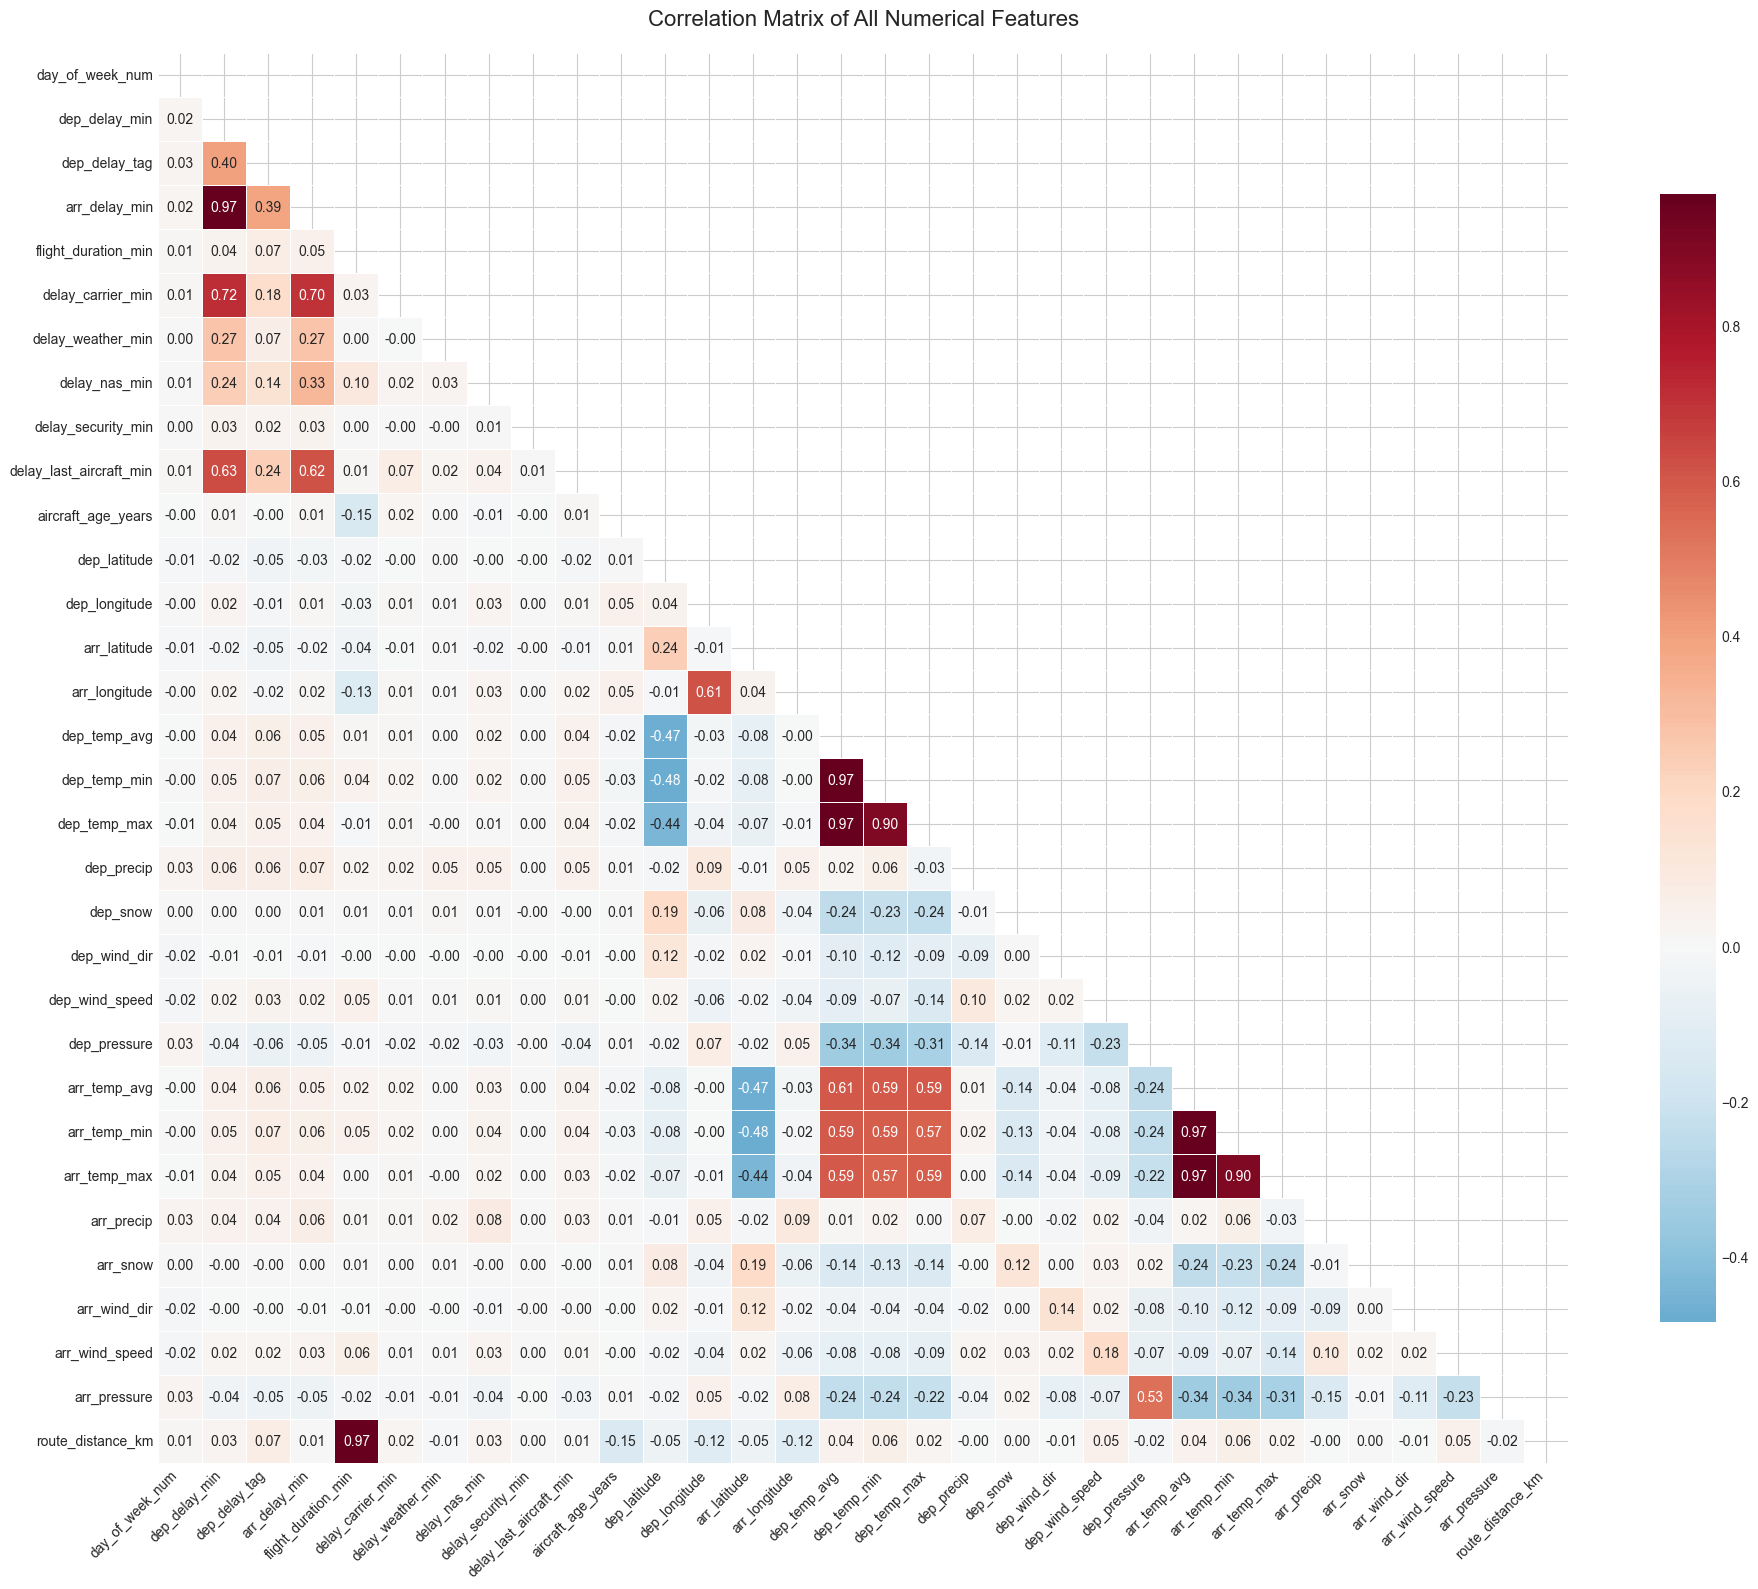

In [34]:
# Set style
if EDA != 'eda_no':
    plt.style.use('seaborn-v0_8-whitegrid')
    sns.set_palette("husl")

    # First, let's identify numerical columns
    numerical_cols = data_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
    print(f"Found {len(numerical_cols)} numerical columns")

    # Create correlation matrix
    corr_matrix = data_cleaned[numerical_cols].corr()

    # Plot heatmap
    plt.figure(figsize=(20, 16))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix,
                mask = mask,
                annot = True,
                fmt = '.2f',
                cmap = 'RdBu_r', 
                center = 0,
                square = True,
                linewidths = 0.5,
                cbar_kws = {"shrink": 0.8})

    plt.title('Correlation Matrix of All Numerical Features', fontsize=16, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    eda_fn = 'corre_matrix_all_num_features.png'
    plt.savefig(DIR_eda + eda_fn, 
                dpi=300, 
                bbox_inches='tight')
    print(f"✅ Saved: {DIR_eda}{eda_fn}")
    plt.show()

# Analisis de **correlation matrix**

---

## 1. Strongest Relationships (Expected & Important)

### 🔴 Delay-related variables

* **`dep_delay_min` ↔ `arr_delay_min` (~0.97)**
  → Extremely strong correlation. Departure delays almost fully propagate to arrival delays.

* **`dep_delay_min` ↔ `delay_carrier_min` (~0.72)**

* **`dep_delay_min` ↔ `delay_last_aircraft_min` (~0.63)**
  → Carrier issues and late inbound aircraft are major contributors to departure delays.

* **`arr_delay_min` ↔ `delay_carrier_min` (~0.70)**

* **`arr_delay_min` ↔ `delay_last_aircraft_min` (~0.62)**
  → Same causes strongly affect arrival delays.

📌 **Insight**: Delay cause variables are highly collinear with total delay minutes.

---

## 2. Delay Causes vs Each Other

* Moderate correlations among:

  * `delay_carrier_min`
  * `delay_weather_min`
  * `delay_nas_min`
  * `delay_last_aircraft_min`

But:

* **`delay_security_min` ≈ 0 correlation** with almost everything
  → Security delays are rare and mostly independent.

📌 **Insight**: Delay causes are related but not identical—useful for explanatory models, risky for linear models without regularization.

---

## 3. Weather Variables (Very High Collinearity)

### 🌡️ Temperature

* `dep_temp_avg`, `dep_temp_min`, `dep_temp_max`
  → Correlations ≈ **0.97**
* Same for arrival temperatures.

📌 **Insight**: These are essentially redundant. Keep **one** (usually avg or max).

### 🌬️ Wind

* `wind_speed` vs `wind_dir` → near zero correlation
* Wind has **weak correlation with delays** overall.

### 🌧️ Precipitation & Snow

* `precip` ↔ `snow`: small to moderate correlation
* **Weak correlation with delays** (generally < 0.1)

📌 **Insight**: Weather affects delays nonlinearly or conditionally (e.g., extreme events), not well captured by simple correlations.

---

## 4. Geographic Features

* `dep_latitude` ↔ `arr_latitude` (~0.24)
* `dep_longitude` ↔ `arr_longitude` (~0.61)

📌 **Insight**: Flights tend to operate within geographic corridors, but location alone does not strongly explain delays.

---

## 5. Aircraft Features

* **`aircraft_age_years`** shows:

  * Near-zero correlation with delays
  * Slight negative correlation with flight duration (~ -0.15)

📌 **Insight**: Older aircraft are not strongly associated with more delays in this dataset.

---

## 6. Flight Duration

* `flight_duration_min` has:

  * Weak correlation with delays (~0.05)
  * Slight negative correlation with aircraft age

📌 **Insight**: Longer flights are not necessarily more delayed.

---

## 7. Time Feature

* **`day_of_week_num` ≈ 0 correlation with everything**

📌 **Insight**: Day-of-week effects are likely **categorical and nonlinear**, not ordinal.

---

## 8. Modeling Implications (Key Takeaways)

### ⚠️ Multicollinearity risks

* Do **not** include together:

  * `dep_delay_min` + `arr_delay_min`
  * Multiple temperature variables
  * All delay cause variables without regularization

### ✅ Recommended strategies

* Use **regularized models** (Ridge, Lasso, ElasticNet)
* Or **tree-based models** (Random Forest, XGBoost)
* Feature selection:

  * Keep `dep_delay_min` OR delay causes, not both
  * Keep one temperature metric per location

---

## Summary

**What matters most:**

* Delay causes (carrier, last aircraft)
* Departure delay → arrival delay

**What matters least (linearly):**

* Weather (except extreme cases)
* Aircraft age
* Day of week

✅ Saved: ./df-full_mod-full_ff/eda_graphs/corre_dep.png


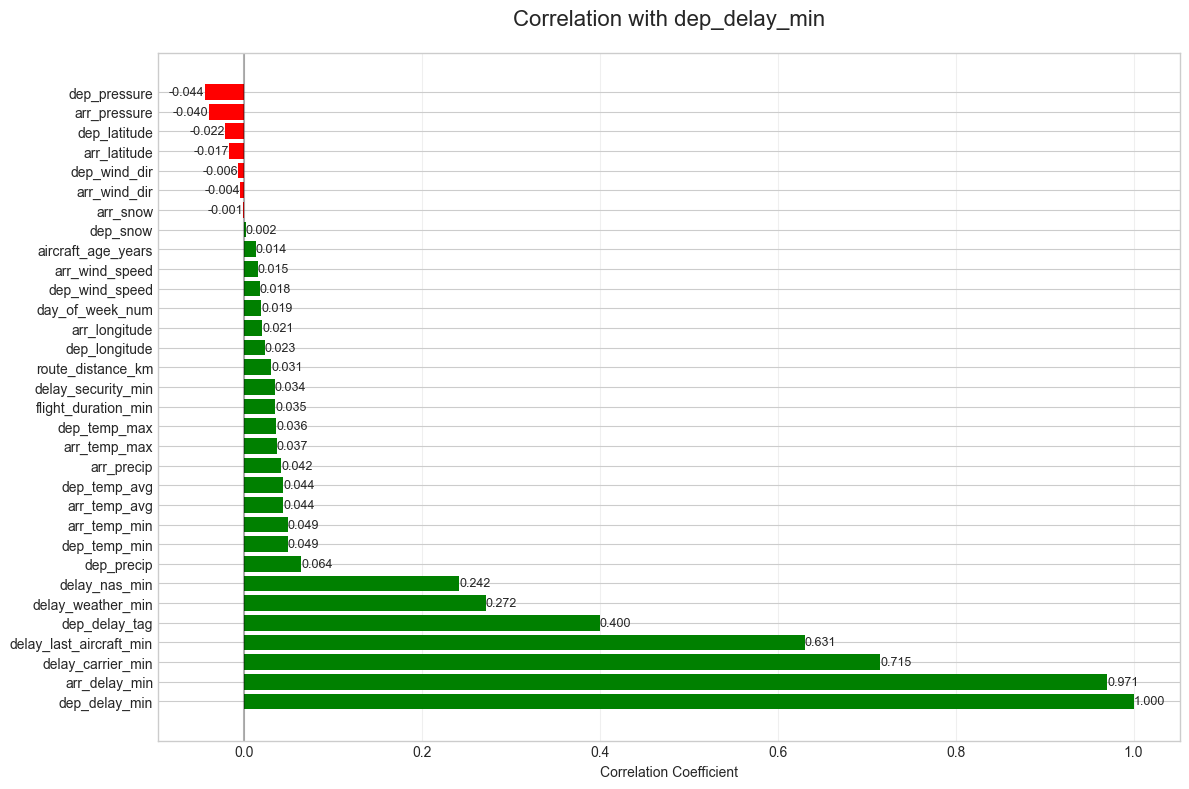


Top 10 Positive Correlations with dep_delay_min:
dep_delay_min              1.000000
arr_delay_min              0.970570
delay_carrier_min          0.715287
delay_last_aircraft_min    0.630675
dep_delay_tag              0.399728
delay_weather_min          0.271576
delay_nas_min              0.241763
dep_precip                 0.064223
dep_temp_min               0.049205
arr_temp_min               0.049056
Name: dep_delay_min, dtype: float64

Top 10 Negative Correlations with dep_delay_min:
arr_wind_speed        0.015475
aircraft_age_years    0.013544
dep_snow              0.001840
arr_snow             -0.000864
arr_wind_dir         -0.004460
dep_wind_dir         -0.006162
arr_latitude         -0.016848
dep_latitude         -0.021574
arr_pressure         -0.039733
dep_pressure         -0.044264
Name: dep_delay_min, dtype: float64


In [35]:
# Calculate correlation with target as dep_delay_min
if EDA != 'eda_no':
    target = 'dep_delay_min'  # or 'arr_delay_min'
    corr_with_target_dep = data_cleaned[numerical_cols].corr()[target].sort_values(ascending=False)

    # Create bar plot
    plt.figure(figsize=(12, 8))
    colors = ['red' if x < 0 else 'green' for x in corr_with_target_dep]
    bars = plt.barh(corr_with_target_dep.index, corr_with_target_dep.values, color=colors)
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.xlabel('Correlation Coefficient')
    plt.title(f'Correlation with {target}', fontsize=16, pad=20)
    plt.grid(axis='x', alpha=0.3)

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='left' if width >= 0 else 'right', 
                va='center', fontsize=9)

    plt.tight_layout()
    eda_fn = 'corre_dep.png'
    plt.savefig(DIR_eda + eda_fn, 
                dpi=300, 
                bbox_inches='tight')
    print(f"✅ Saved: {DIR_eda}{eda_fn}")
    plt.show()

    # Show top correlations
    print(f"\nTop 10 Positive Correlations with {target}:")
    print(corr_with_target_dep.head(10))
    print(f"\nTop 10 Negative Correlations with {target}:")
    print(corr_with_target_dep.tail(10))

Here’s a **clear, ML-focused analysis** of the **correlation with `dep_delay_min`** plot you shared, plus **what it means for your model and app**.

---

## 1. Big Picture (One Sentence)

> **Departure delay is dominated by operational delay causes and arrival delay, while weather, geography, aircraft, and calendar effects are weak in linear correlation.**

This is exactly what we expect in real airline data.

---

## 2. Very Strong Correlations (⚠️ Leakage Zone)

These features are **not usable for pre-departure prediction**.

| Feature                   | Corr     | Meaning                                      |
| ------------------------- | -------- | -------------------------------------------- |
| `arr_delay_min`           | **0.97** | Arrival delay almost mirrors departure delay |
| `delay_carrier_min`       | **0.72** | Airline operational issues                   |
| `delay_last_aircraft_min` | **0.63** | Late inbound aircraft                        |
| `dep_delay_tag`           | **0.40** | Engineered label derived from delay          |
| `delay_weather_min`       | **0.27** | Post-hoc weather attribution                 |
| `delay_nas_min`           | **0.24** | Air traffic control                          |

📌 **Conclusion**
These are **effects**, not causes. Including them = **label leakage**.

---

## 3. Weak but Legitimate Predictors (Keep for ML)

These have low correlation but **add value in nonlinear models**.

### 🌦️ Weather (Weak Linear Signal ≠ Useless)

| Feature      | Corr       |
| ------------ | ---------- |
| `dep_precip` | 0.06       |
| `dep_temp_*` | ~0.04–0.05 |
| `wind_speed` | ~0.02      |

✔ Useful for:

* Tree-based models
* Threshold-based features (snow, freezing, storms)

---

### 🛫 Flight & Aircraft

| Feature               | Corr  |
| --------------------- | ----- |
| `flight_duration_min` | 0.035 |
| `aircraft_age_years`  | 0.014 |

✔ Aircraft age is **weak globally**, but useful with:

* Airline interaction
* Aircraft model grouping

---

### 📍 Geography

| Feature    | Corr  |
| ---------- | ----- |
| Lat / Long | ~0.02 |

✔ Useful only when converted to:

* Airport-level congestion
* Route embeddings
* Distance

---

### 📅 Calendar

| Feature           | Corr  |
| ----------------- | ----- |
| `day_of_week_num` | 0.019 |

❌ Linear encoding is wrong
✔ Needs categorical or cyclical encoding

✅ Saved: ./df-full_mod-full_ff/eda_graphs/corre_arr.png


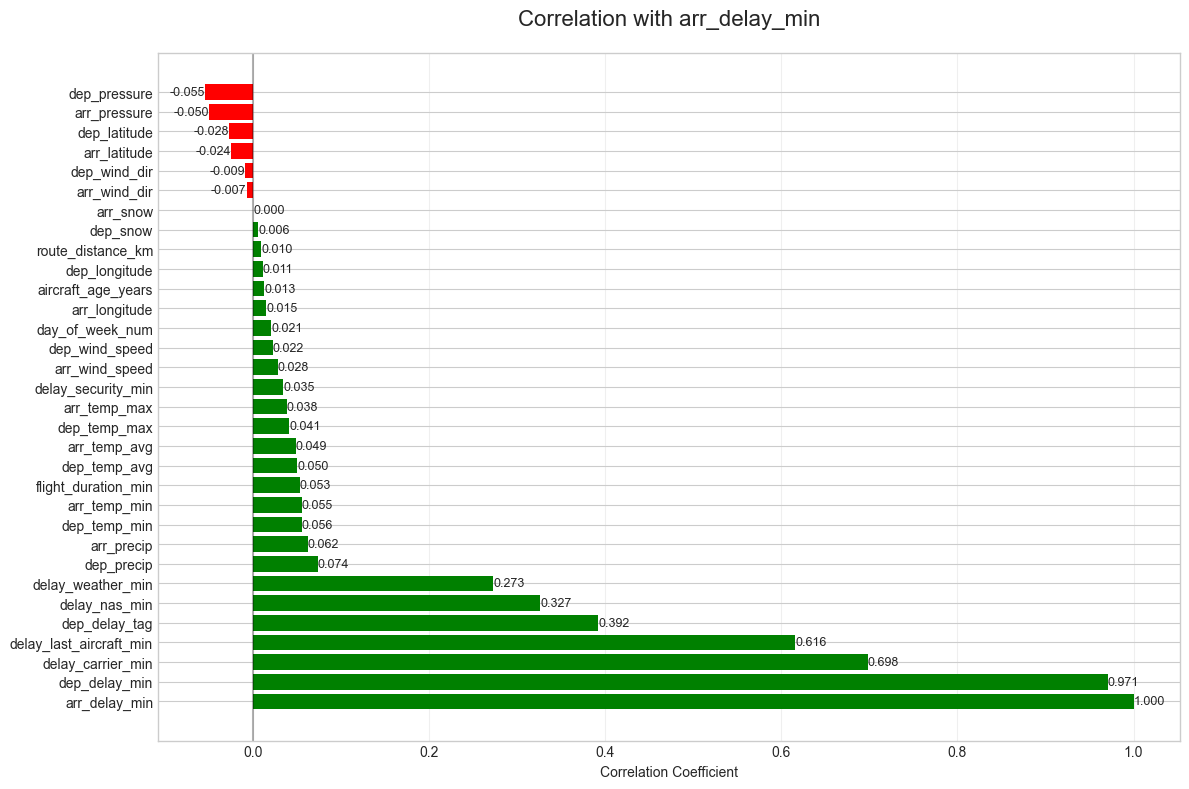


Top 10 Positive Correlations with arr_delay_min:
arr_delay_min              1.000000
dep_delay_min              0.970570
delay_carrier_min          0.698334
delay_last_aircraft_min    0.615877
dep_delay_tag              0.392045
delay_nas_min              0.326570
delay_weather_min          0.272736
dep_precip                 0.073981
arr_precip                 0.062414
dep_temp_min               0.055873
Name: arr_delay_min, dtype: float64

Top 10 Negative Correlations with arr_delay_min:
dep_longitude        0.011422
route_distance_km    0.009702
dep_snow             0.006124
arr_snow             0.000333
arr_wind_dir        -0.007084
dep_wind_dir        -0.008749
arr_latitude        -0.024326
dep_latitude        -0.027552
arr_pressure        -0.049889
dep_pressure        -0.054752
Name: arr_delay_min, dtype: float64


In [36]:
# Calculate correlation with target as arr_delay_min
if EDA != 'eda_no':
    target = 'arr_delay_min'  # or 'arr_delay_min'
    corr_with_target_arr = data_cleaned[numerical_cols].corr()[target].sort_values(ascending=False)

    # Create bar plot
    plt.figure(figsize=(12, 8))
    colors = ['red' if x < 0 else 'green' for x in corr_with_target_arr]
    bars = plt.barh(corr_with_target_arr.index, corr_with_target_arr.values, color=colors)
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.xlabel('Correlation Coefficient')
    plt.title(f'Correlation with {target}', fontsize=16, pad=20)
    plt.grid(axis='x', alpha=0.3)

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='left' if width >= 0 else 'right', 
                va='center', fontsize=9)

    plt.tight_layout()
    eda_fn = 'corre_arr.png'
    plt.savefig(DIR_eda + eda_fn, 
                dpi=300, 
                bbox_inches='tight')
    print(f"✅ Saved: {DIR_eda}{eda_fn}")
    plt.show()

    # Show top correlations
    print(f"\nTop 10 Positive Correlations with {target}:")
    print(corr_with_target_arr.head(10))
    print(f"\nTop 10 Negative Correlations with {target}:")
    print(corr_with_target_arr.tail(10))

This plot is **excellent confirmation** of everything we discussed. I’ll analyze it **specifically for predicting `arr_delay_min`**, and then give you **exact modeling rules** you should follow.

---

## 1. Big Picture

> **Arrival delay is overwhelmingly explained by departure delay and operational delay causes; weather, aircraft, geography, and calendar effects are weak in linear correlation.**

This is exactly what airlines see in practice.

---

## 2. Dominant Predictors (⚠️ Leakage Unless Timed Correctly)

| Feature                   | Corr     | Interpretation                          |
| ------------------------- | -------- | --------------------------------------- |
| `dep_delay_min`           | **0.97** | Departure delay almost fully propagates |
| `delay_carrier_min`       | **0.70** | Airline operational recovery            |
| `delay_last_aircraft_min` | **0.62** | Inbound aircraft delay                  |
| `dep_delay_tag`           | **0.39** | Engineered label                        |
| `delay_nas_min`           | **0.33** | ATC congestion                          |
| `delay_weather_min`       | **0.27** | Post-hoc weather attribution            |

📌 **Critical rule**

* These are **not available pre-departure**
* Using them early = **data leakage**

---

## 3. Legitimate Pre-Departure Signals (Weak but Real)

### 🌦️ Weather

| Feature      | Corr       |
| ------------ | ---------- |
| `dep_precip` | 0.074      |
| `arr_precip` | 0.062      |
| Temps        | ~0.05      |
| Wind         | ~0.02–0.03 |

✔ Weak linearly
✔ Strong in nonlinear trees and thresholds

---

### ✈️ Flight & Aircraft

| Feature               | Corr  |
| --------------------- | ----- |
| `flight_duration_min` | 0.053 |
| `aircraft_age_years`  | 0.013 |

✔ Duration matters more than age

---

### 📍 Geography

| Feature  | Corr       |
| -------- | ---------- |
| lat/long | ~0.01–0.02 |

✔ Needs aggregation to airport level

---

### 📅 Calendar

| Feature           | Corr  |
| ----------------- | ----- |
| `day_of_week_num` | 0.021 |

❌ Ordinal encoding wrong
✔ Use categorical/cyclical

✅ Saved: ./df-full_mod-full_ff/eda_graphs/corre_top_dep.png


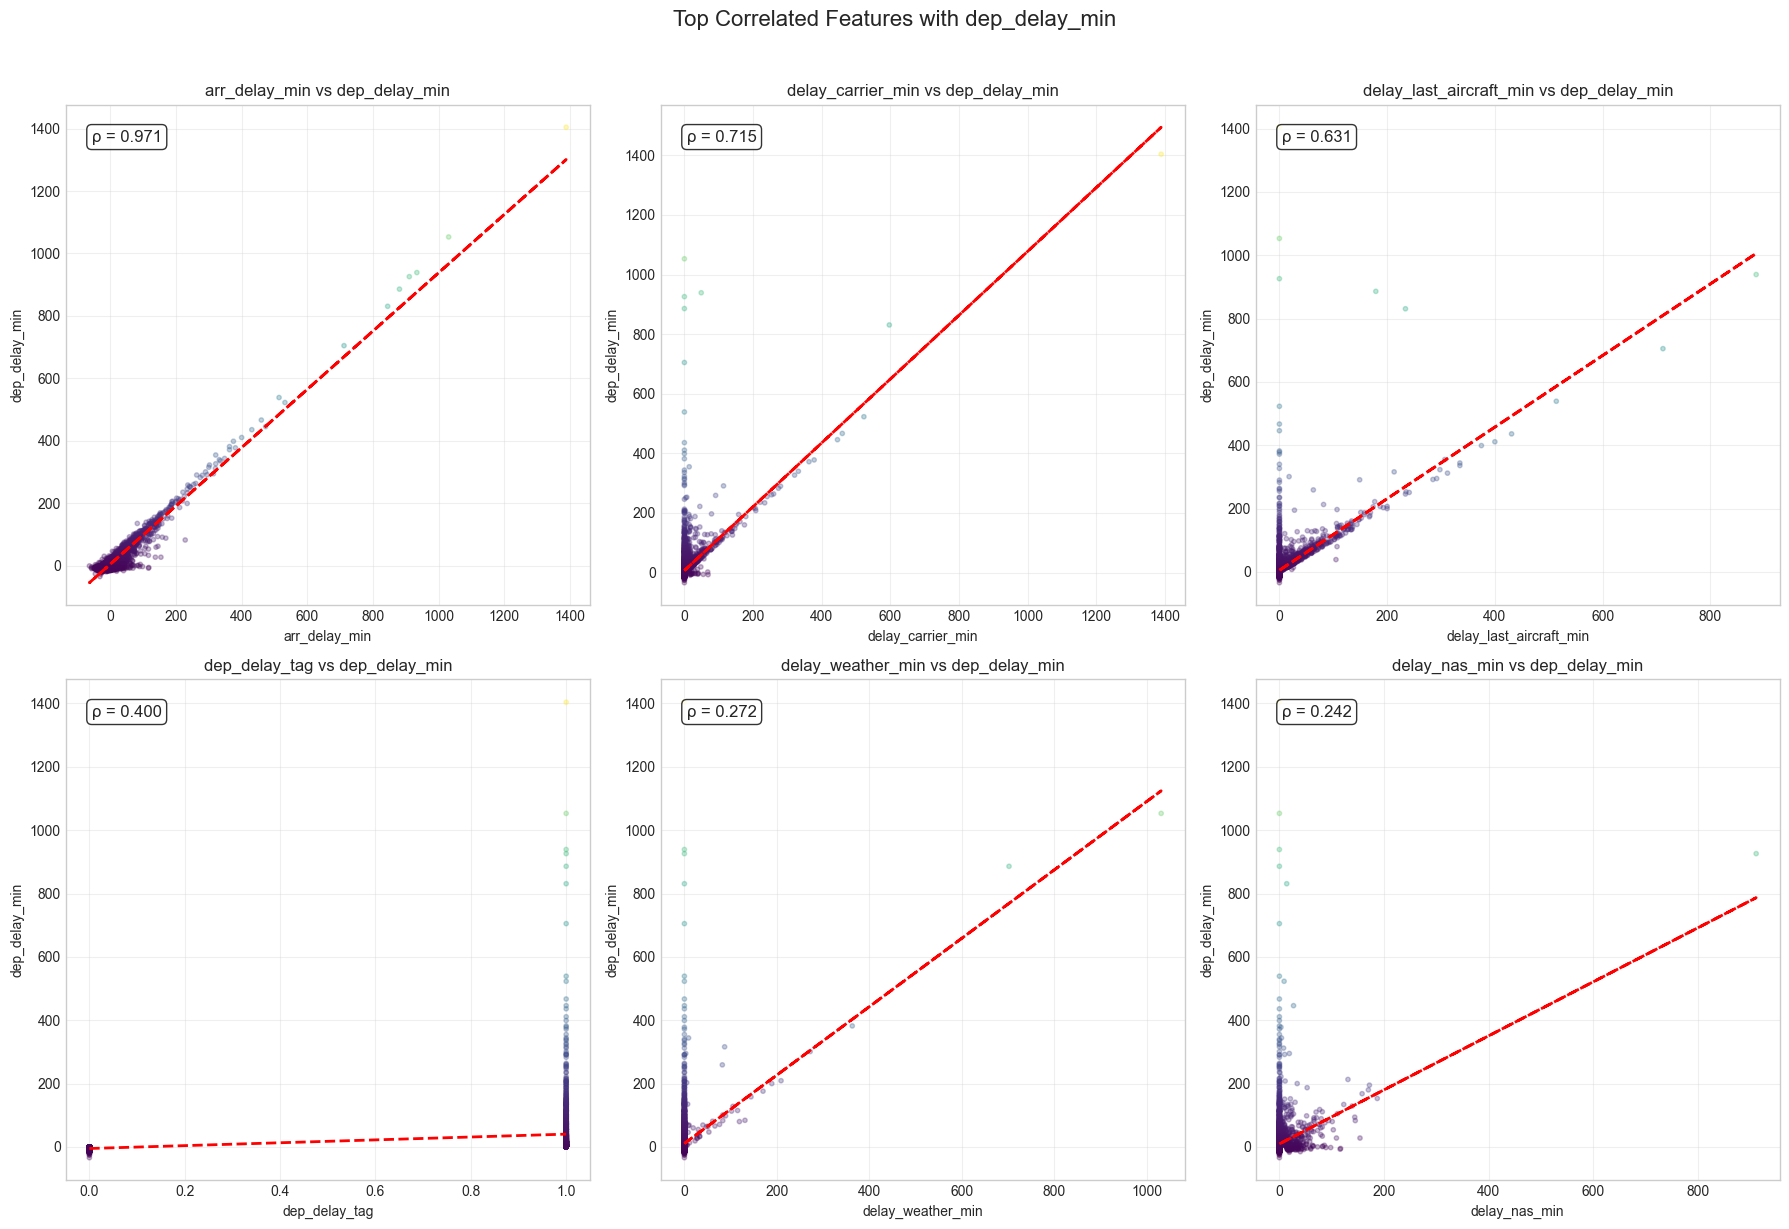

In [37]:
# Get top 6 correlated features (excluding target itself)
if EDA != 'eda_no':
    target="dep_delay_min"
    top_features = corr_with_target_dep.drop(target).abs().sort_values(ascending=False).head(6).index

    # Create scatter plots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for idx, feature in enumerate(top_features):
        ax = axes[idx]
        
        # Sample data for performance
        sample_size = min(5000, len(data_cleaned))
        sample_df = data_cleaned.sample(sample_size, random_state=42)
        
        # Scatter plot
        scatter = ax.scatter(sample_df[feature], sample_df[target], 
                            alpha=0.3, s=10, c=sample_df[target], 
                            cmap='viridis')
        
        # Add correlation line
        z = np.polyfit(sample_df[feature].dropna(), sample_df[target].dropna(), 1)
        p = np.poly1d(z)
        ax.plot(sample_df[feature], p(sample_df[feature]), "r--", linewidth=2)
        
        # Calculate and display correlation
        corr_value = data_cleaned[feature].corr(data_cleaned[target])
        ax.text(0.05, 0.95, f'ρ = {corr_value:.3f}', 
                transform=ax.transAxes, fontsize=12,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_xlabel(feature)
        ax.set_ylabel(target)
        ax.set_title(f'{feature} vs {target}')
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Top Correlated Features with {target}', fontsize=16, y=1.02)
    plt.tight_layout()
    eda_fn = 'corre_top_dep.png'
    plt.savefig(DIR_eda + eda_fn, 
                dpi=300, 
                bbox_inches='tight')
    print(f"✅ Saved: {DIR_eda}{eda_fn}")
    plt.show()

✅ Saved: ./df-full_mod-full_ff/eda_graphs/corre_top_arr.png


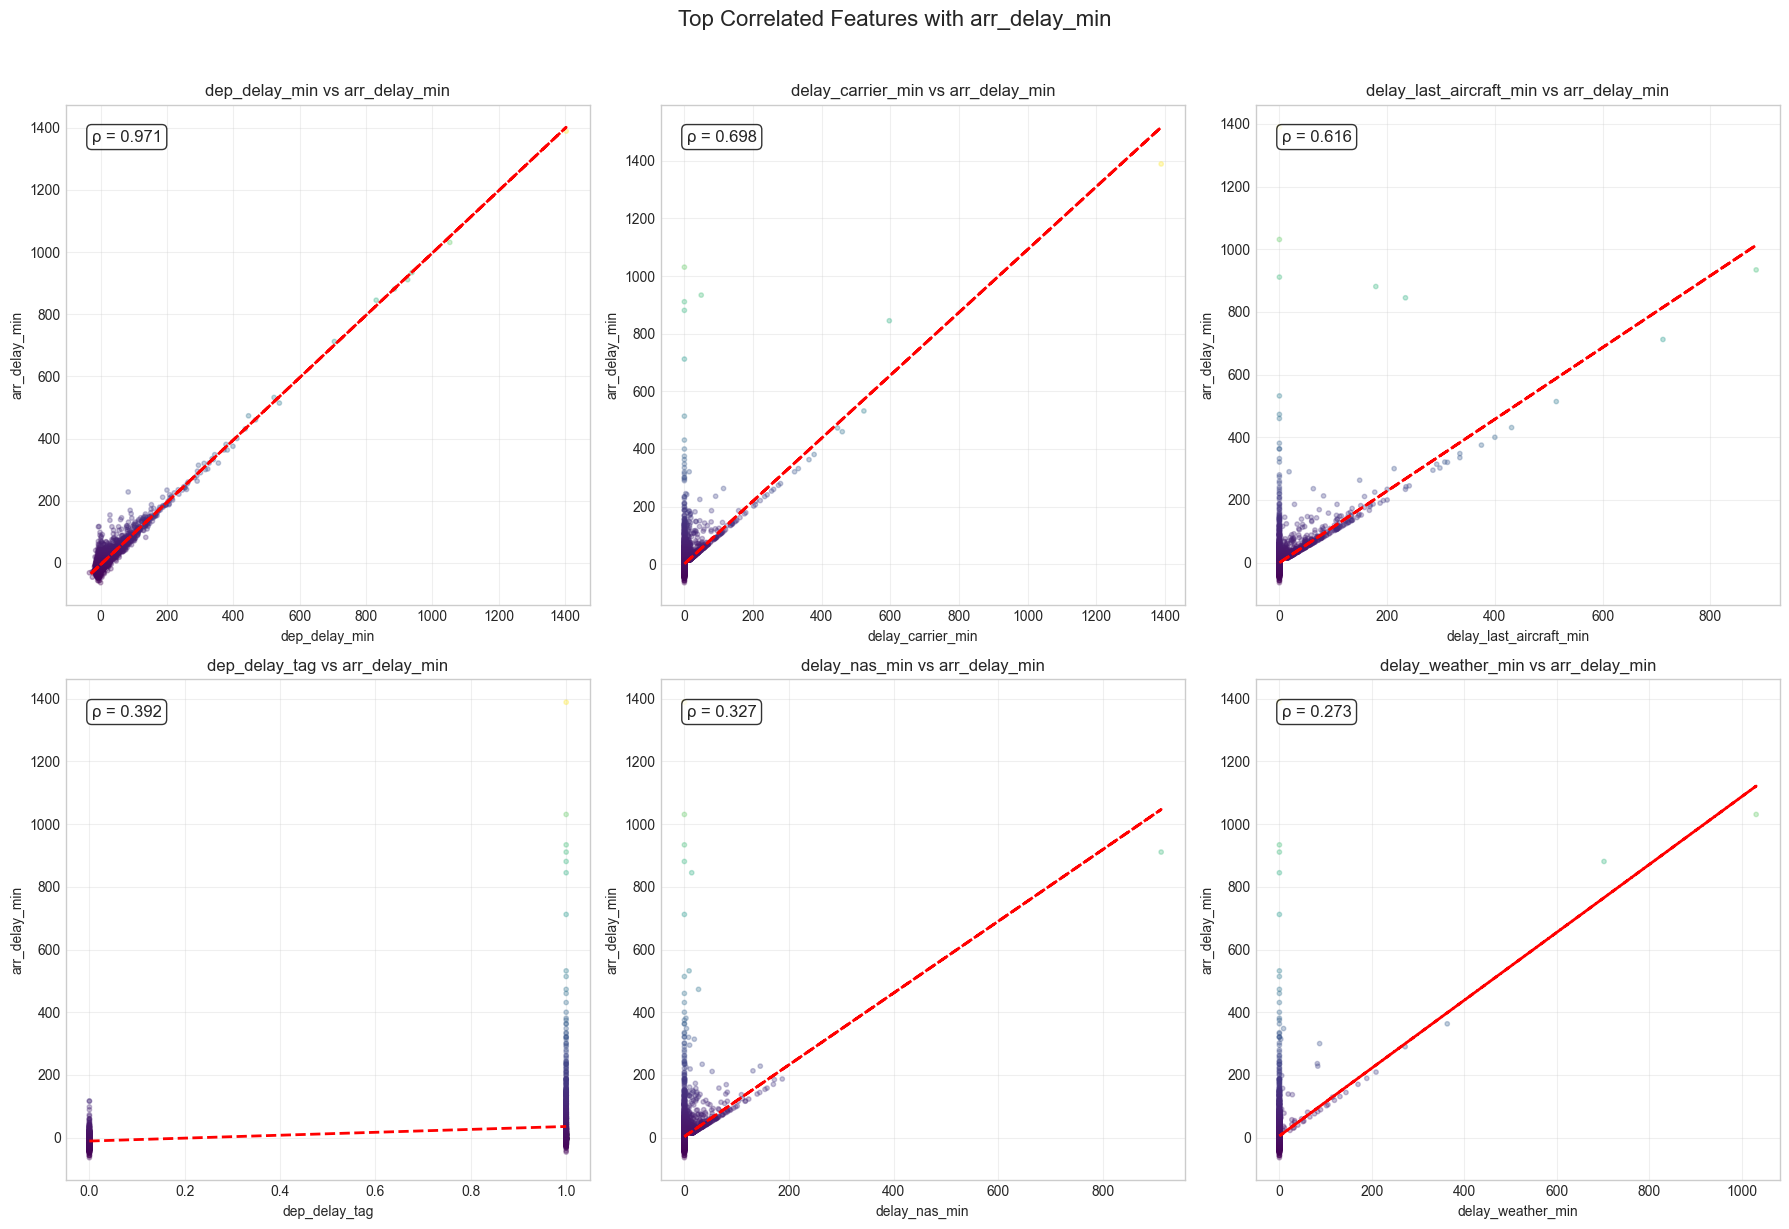

In [38]:
# Get top 6 correlated features (excluding target itself)
if EDA != 'eda_no':
    target="arr_delay_min"
    top_features = corr_with_target_arr.drop(target).abs().sort_values(ascending=False).head(6).index

    # Create scatter plots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for idx, feature in enumerate(top_features):
        ax = axes[idx]
        
        # Sample data for performance
        sample_size = min(5000, len(data_cleaned))
        sample_df = data_cleaned.sample(sample_size, random_state=42)
        
        # Scatter plot
        scatter = ax.scatter(sample_df[feature], sample_df[target], 
                            alpha=0.3, s=10, c=sample_df[target], 
                            cmap='viridis')
        
        # Add correlation line
        z = np.polyfit(sample_df[feature].dropna(), sample_df[target].dropna(), 1)
        p = np.poly1d(z)
        ax.plot(sample_df[feature], p(sample_df[feature]), "r--", linewidth=2)
        
        # Calculate and display correlation
        corr_value = data_cleaned[feature].corr(data_cleaned[target])
        ax.text(0.05, 0.95, f'ρ = {corr_value:.3f}', 
                transform=ax.transAxes, fontsize=12,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_xlabel(feature)
        ax.set_ylabel(target)
        ax.set_title(f'{feature} vs {target}')
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Top Correlated Features with {target}', fontsize=16, y=1.02)
    plt.tight_layout()
    eda_fn = 'corre_top_arr.png'
    plt.savefig(DIR_eda + eda_fn, 
                dpi=300, 
                bbox_inches='tight')
    print(f"✅ Saved: {DIR_eda}{eda_fn}")
    plt.show()

Creating pairplot for 7 delay features...
✅ Saved: ./df-full_mod-full_ff/eda_graphs/pairplot.png


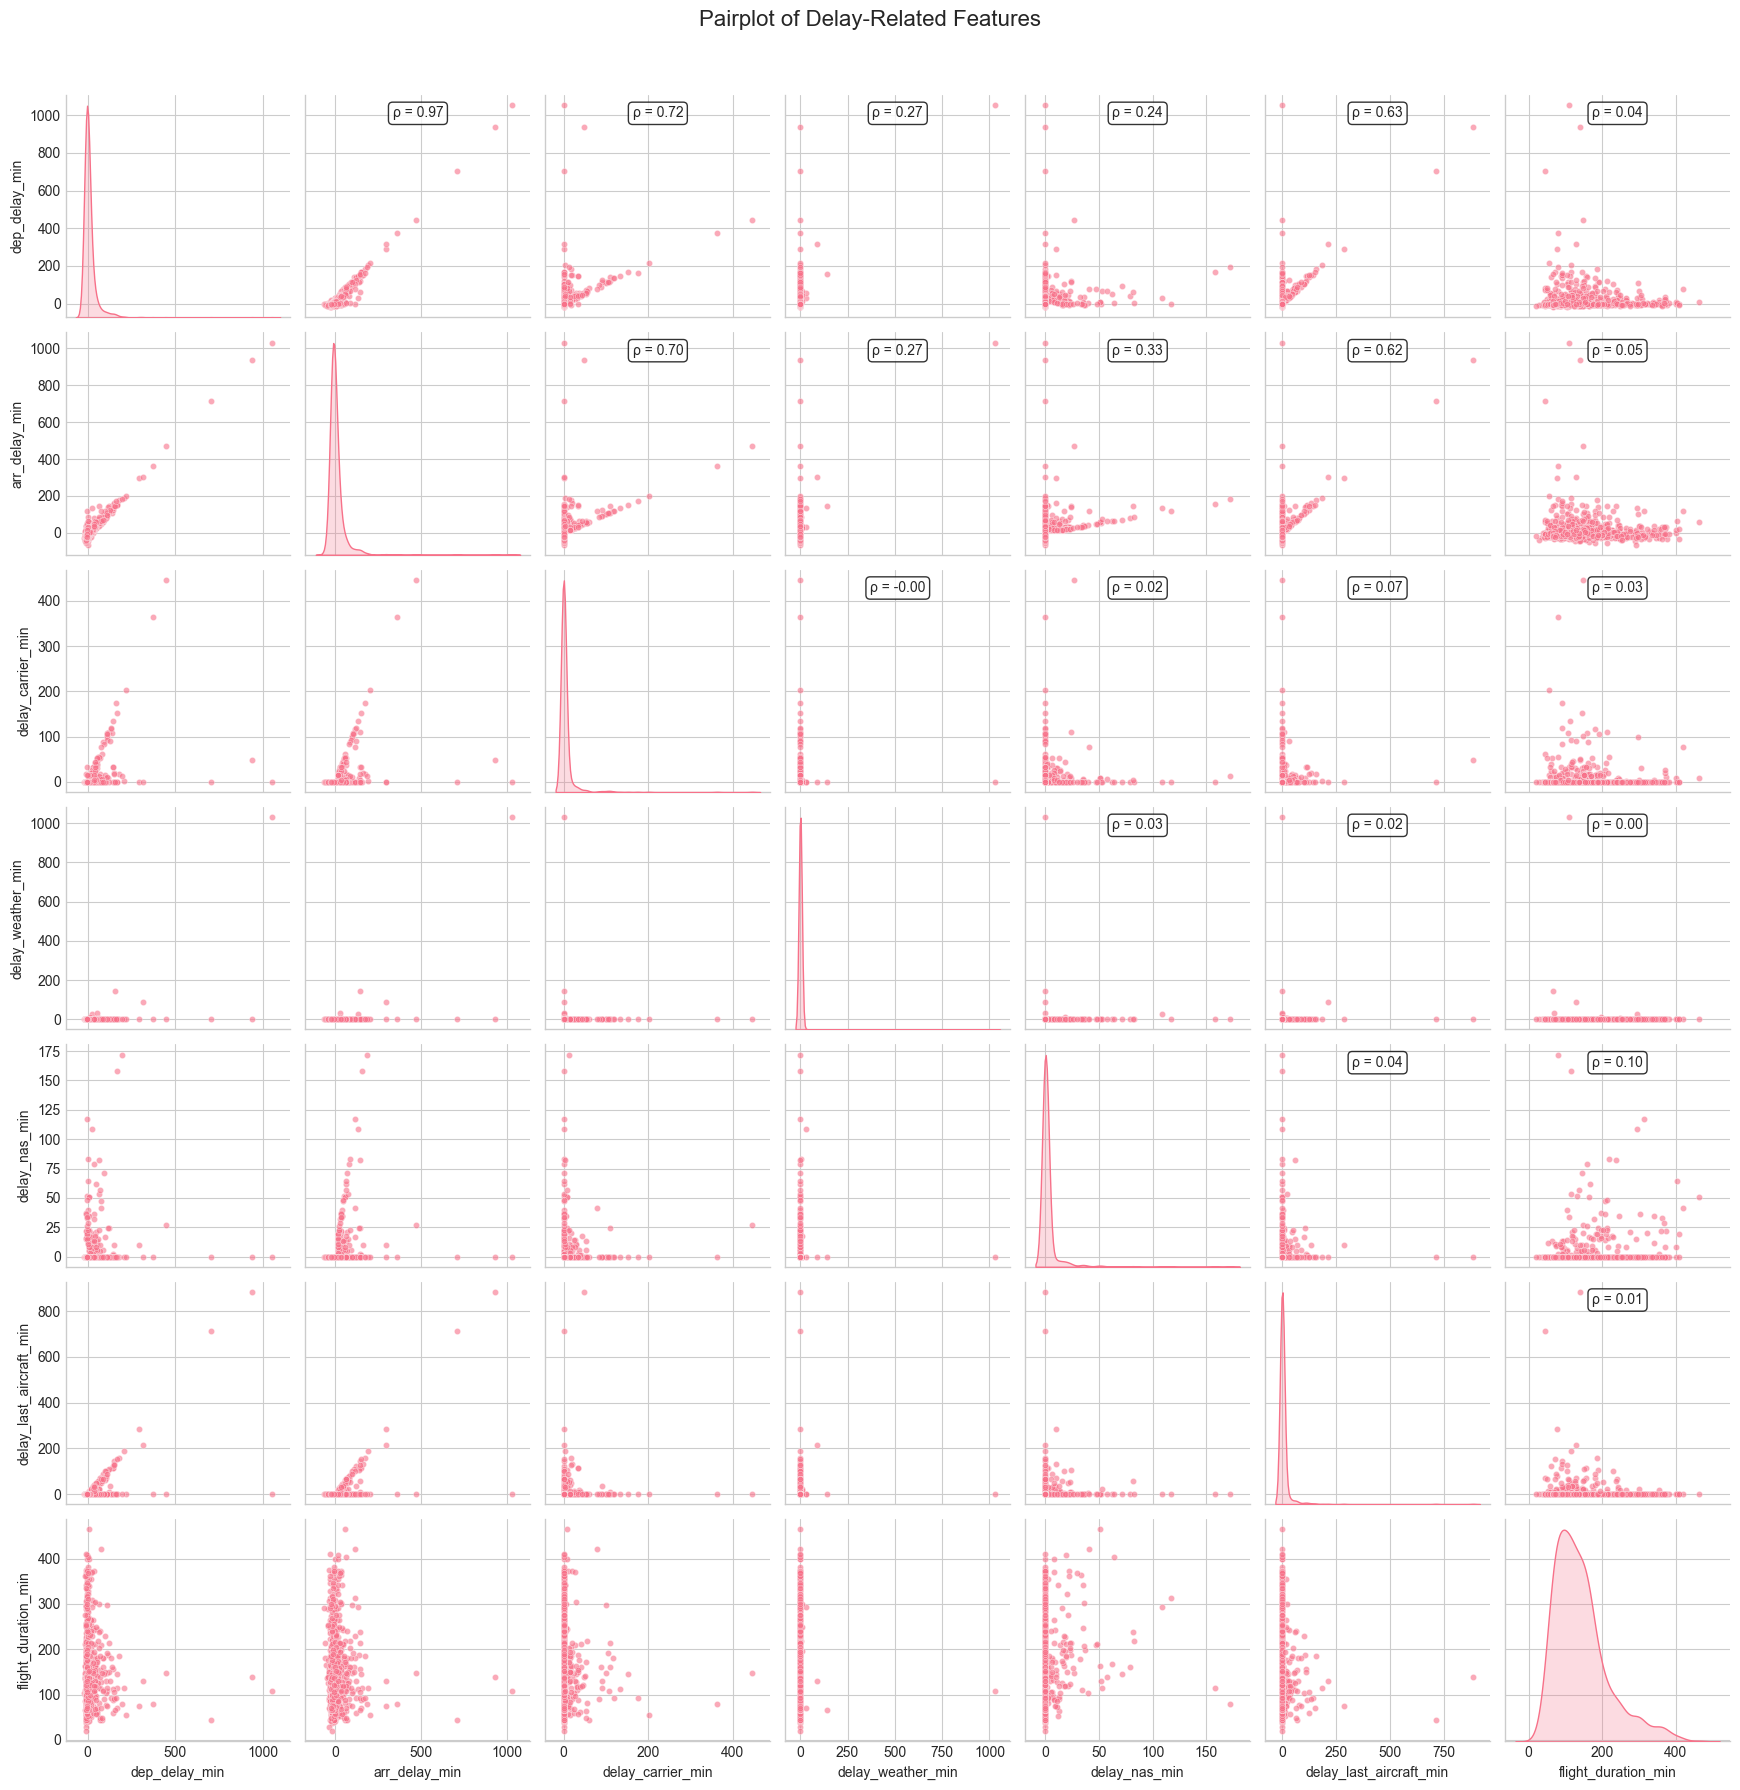

In [39]:
# Select key delay-related features
if EDA != 'eda_no':
    delay_features = ['dep_delay_min',
                      'arr_delay_min',
                      'delay_carrier_min',
                      'delay_weather_min',
                      'delay_nas_min',
                      'delay_last_aircraft_min',
                      'flight_duration_min']

    # Filter to existing columns
    delay_features = [f for f in delay_features if f in data_cleaned.columns]

    # Create pairplot
    print(f"Creating pairplot for {len(delay_features)} delay features...")
    sample_df = data_cleaned[delay_features].sample(min(1000, len(data_cleaned)), random_state=42)

    g = sns.pairplot(sample_df, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 20})
    g.fig.suptitle('Pairplot of Delay-Related Features', y=1.02, fontsize=16)

    # Add correlation coefficients to upper triangle
    for i, row in enumerate(g.axes):
        for j, col in enumerate(row):
            if i < j:  # Upper triangle
                x_feature = delay_features[j]
                y_feature = delay_features[i]
                corr = data_cleaned[x_feature].corr(data_cleaned[y_feature])
                col.text(0.5, 0.9, f'ρ = {corr:.2f}', 
                        transform=col.transAxes, ha='center',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    eda_fn = 'pairplot.png'
    plt.savefig(DIR_eda + eda_fn, 
                dpi=300, 
                bbox_inches='tight')
    print(f"✅ Saved: {DIR_eda}{eda_fn}")
    plt.show()

✅ Saved: ./df-full_mod-full_ff/eda_graphs/time_bas_dep.png


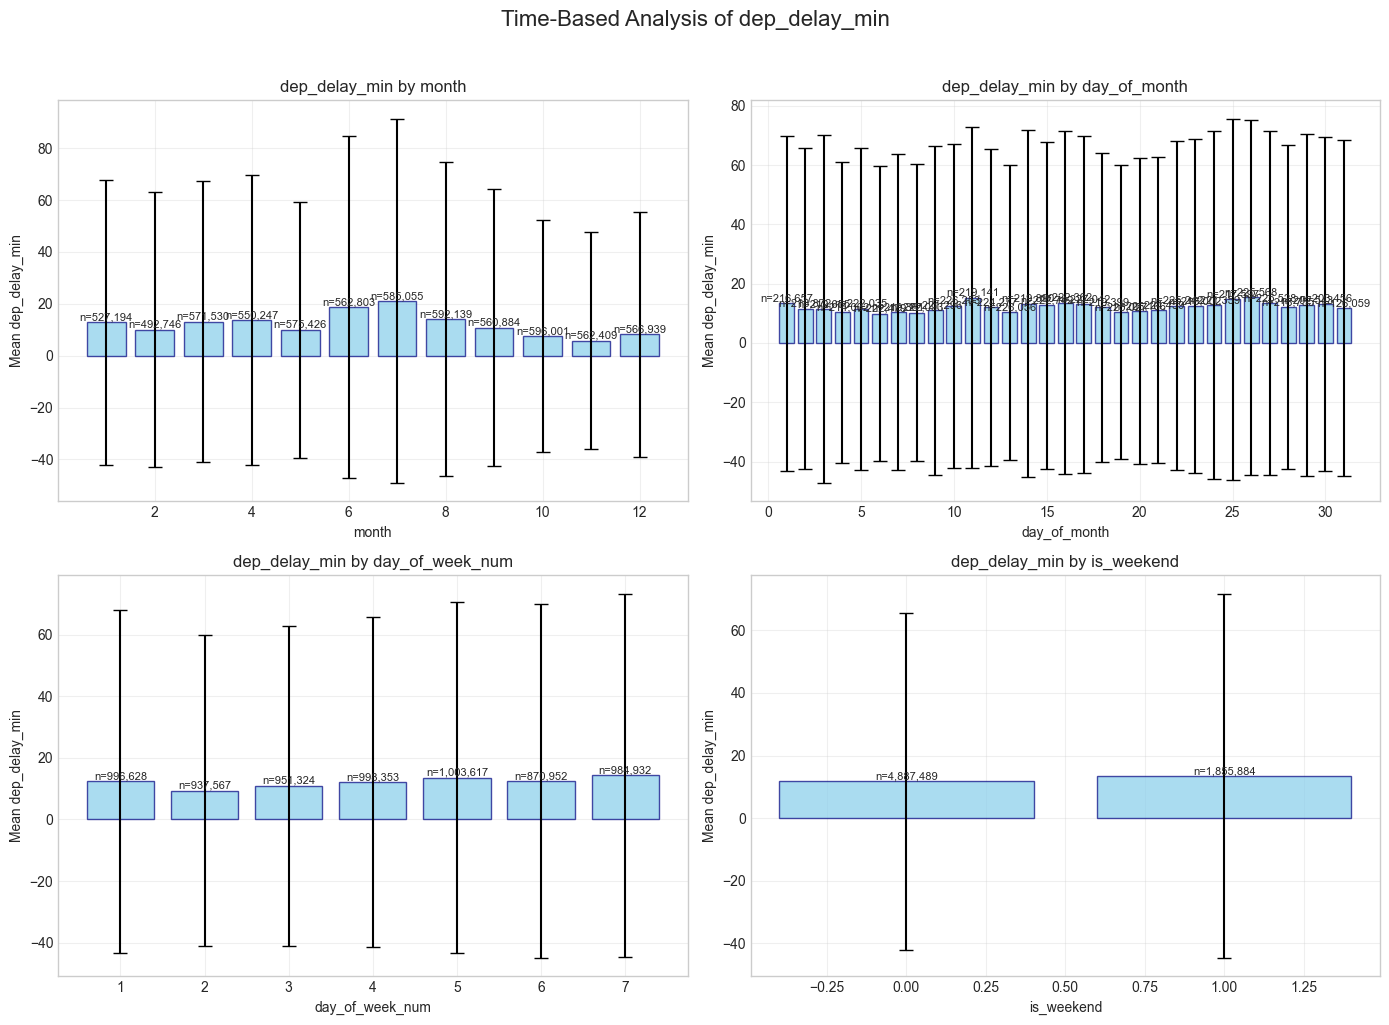

In [40]:
# Extract time features
if EDA != 'eda_no':
    df_time = data_cleaned.copy()
    target="dep_delay_min"

    # Convert flight_date to datetime if it's not already
    if 'flight_date' in df_time.columns and df_time['flight_date'].dtype == 'object':
        df_time['flight_date'] = pd.to_datetime(df_time['flight_date'])

    # Create time-based features
    if 'flight_date' in df_time.columns:
        df_time['month'] = df_time['flight_date'].dt.month
        df_time['day_of_month'] = df_time['flight_date'].dt.day
        df_time['is_weekend'] = (df_time['day_of_week_num'] >= 6).astype(int)
        
        # Analyze delay by time
        time_features = ['month', 'day_of_month', 'day_of_week_num', 'is_weekend']
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()
        
        for idx, feature in enumerate(time_features):
            if idx < len(axes):
                ax = axes[idx]
                
                # Calculate mean delay by time feature
                if df_time[feature].nunique() <= 31:  # Reasonable for boxplot
                    delay_by_feature = df_time.groupby(feature)[target].agg(['mean', 'std', 'count'])
                    
                    # Bar plot with error bars
                    bars = ax.bar(delay_by_feature.index, delay_by_feature['mean'], 
                                yerr=delay_by_feature['std'], 
                                capsize=5, alpha=0.7, 
                                color='skyblue', edgecolor='navy')
                    
                    ax.set_xlabel(feature)
                    ax.set_ylabel(f'Mean {target}')
                    ax.set_title(f'{target} by {feature}')
                    ax.grid(True, alpha=0.3)
                    
                    # Add count labels
                    for bar, count in zip(bars, delay_by_feature['count']):
                        height = bar.get_height()
                        ax.text(bar.get_x() + bar.get_width()/2, height,
                            f'n={int(count):,}', ha='center', va='bottom',
                            fontsize=8)
        
        plt.suptitle(f'Time-Based Analysis of {target}', fontsize=16, y=1.02)
        plt.tight_layout()
        eda_fn = 'time_bas_dep.png'
        plt.savefig(DIR_eda + eda_fn, 
                    dpi=300, 
                    bbox_inches='tight')
        print(f"✅ Saved: {DIR_eda}{eda_fn}")
        plt.show()

✅ Saved: ./df-full_mod-full_ff/eda_graphs/time_bas_arr.png


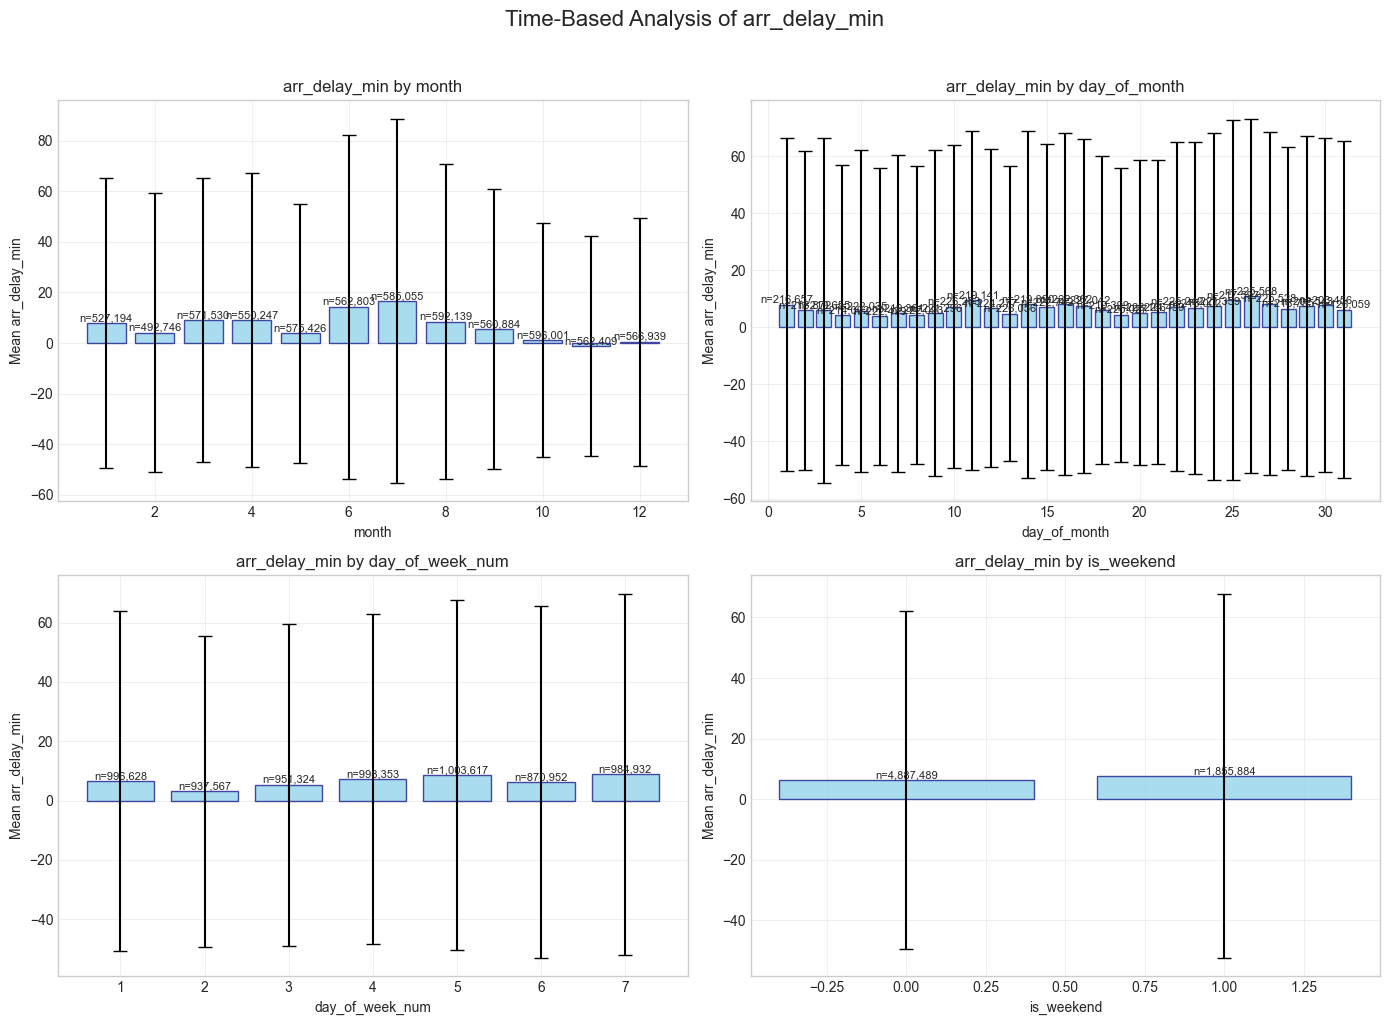

In [41]:
# Extract time features if not already done
if EDA != 'eda_no':
    df_time = data_cleaned.copy()
    target="arr_delay_min"

    # Convert flight_date to datetime if it's not already
    if 'flight_date' in df_time.columns and df_time['flight_date'].dtype == 'object':
        df_time['flight_date'] = pd.to_datetime(df_time['flight_date'])

    # Create time-based features
    if 'flight_date' in df_time.columns:
        df_time['month'] = df_time['flight_date'].dt.month
        df_time['day_of_month'] = df_time['flight_date'].dt.day
        df_time['is_weekend'] = (df_time['day_of_week_num'] >= 6).astype(int)
        
        # Analyze delay by time
        time_features = ['month', 'day_of_month', 'day_of_week_num', 'is_weekend']
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()
        
        for idx, feature in enumerate(time_features):
            if idx < len(axes):
                ax = axes[idx]
                
                # Calculate mean delay by time feature
                if df_time[feature].nunique() <= 31:  # Reasonable for boxplot
                    delay_by_feature = df_time.groupby(feature)[target].agg(['mean', 'std', 'count'])
                    
                    # Bar plot with error bars
                    bars = ax.bar(delay_by_feature.index, delay_by_feature['mean'], 
                                yerr=delay_by_feature['std'], 
                                capsize=5, alpha=0.7, 
                                color='skyblue', edgecolor='navy')
                    
                    ax.set_xlabel(feature)
                    ax.set_ylabel(f'Mean {target}')
                    ax.set_title(f'{target} by {feature}')
                    ax.grid(True, alpha=0.3)
                    
                    # Add count labels
                    for bar, count in zip(bars, delay_by_feature['count']):
                        height = bar.get_height()
                        ax.text(bar.get_x() + bar.get_width()/2, height,
                            f'n={int(count):,}', ha='center', va='bottom',
                            fontsize=8)
        
        plt.suptitle(f'Time-Based Analysis of {target}', fontsize=16, y=1.02)
        plt.tight_layout()
        eda_fn = 'time_bas_arr.png'
        plt.savefig(DIR_eda + eda_fn, 
                    dpi=300, 
                    bbox_inches='tight')
        print(f"✅ Saved: {DIR_eda}{eda_fn}")
        plt.show()

✅ Saved: ./df-full_mod-full_ff/eda_graphs/cat_feature_dep.png


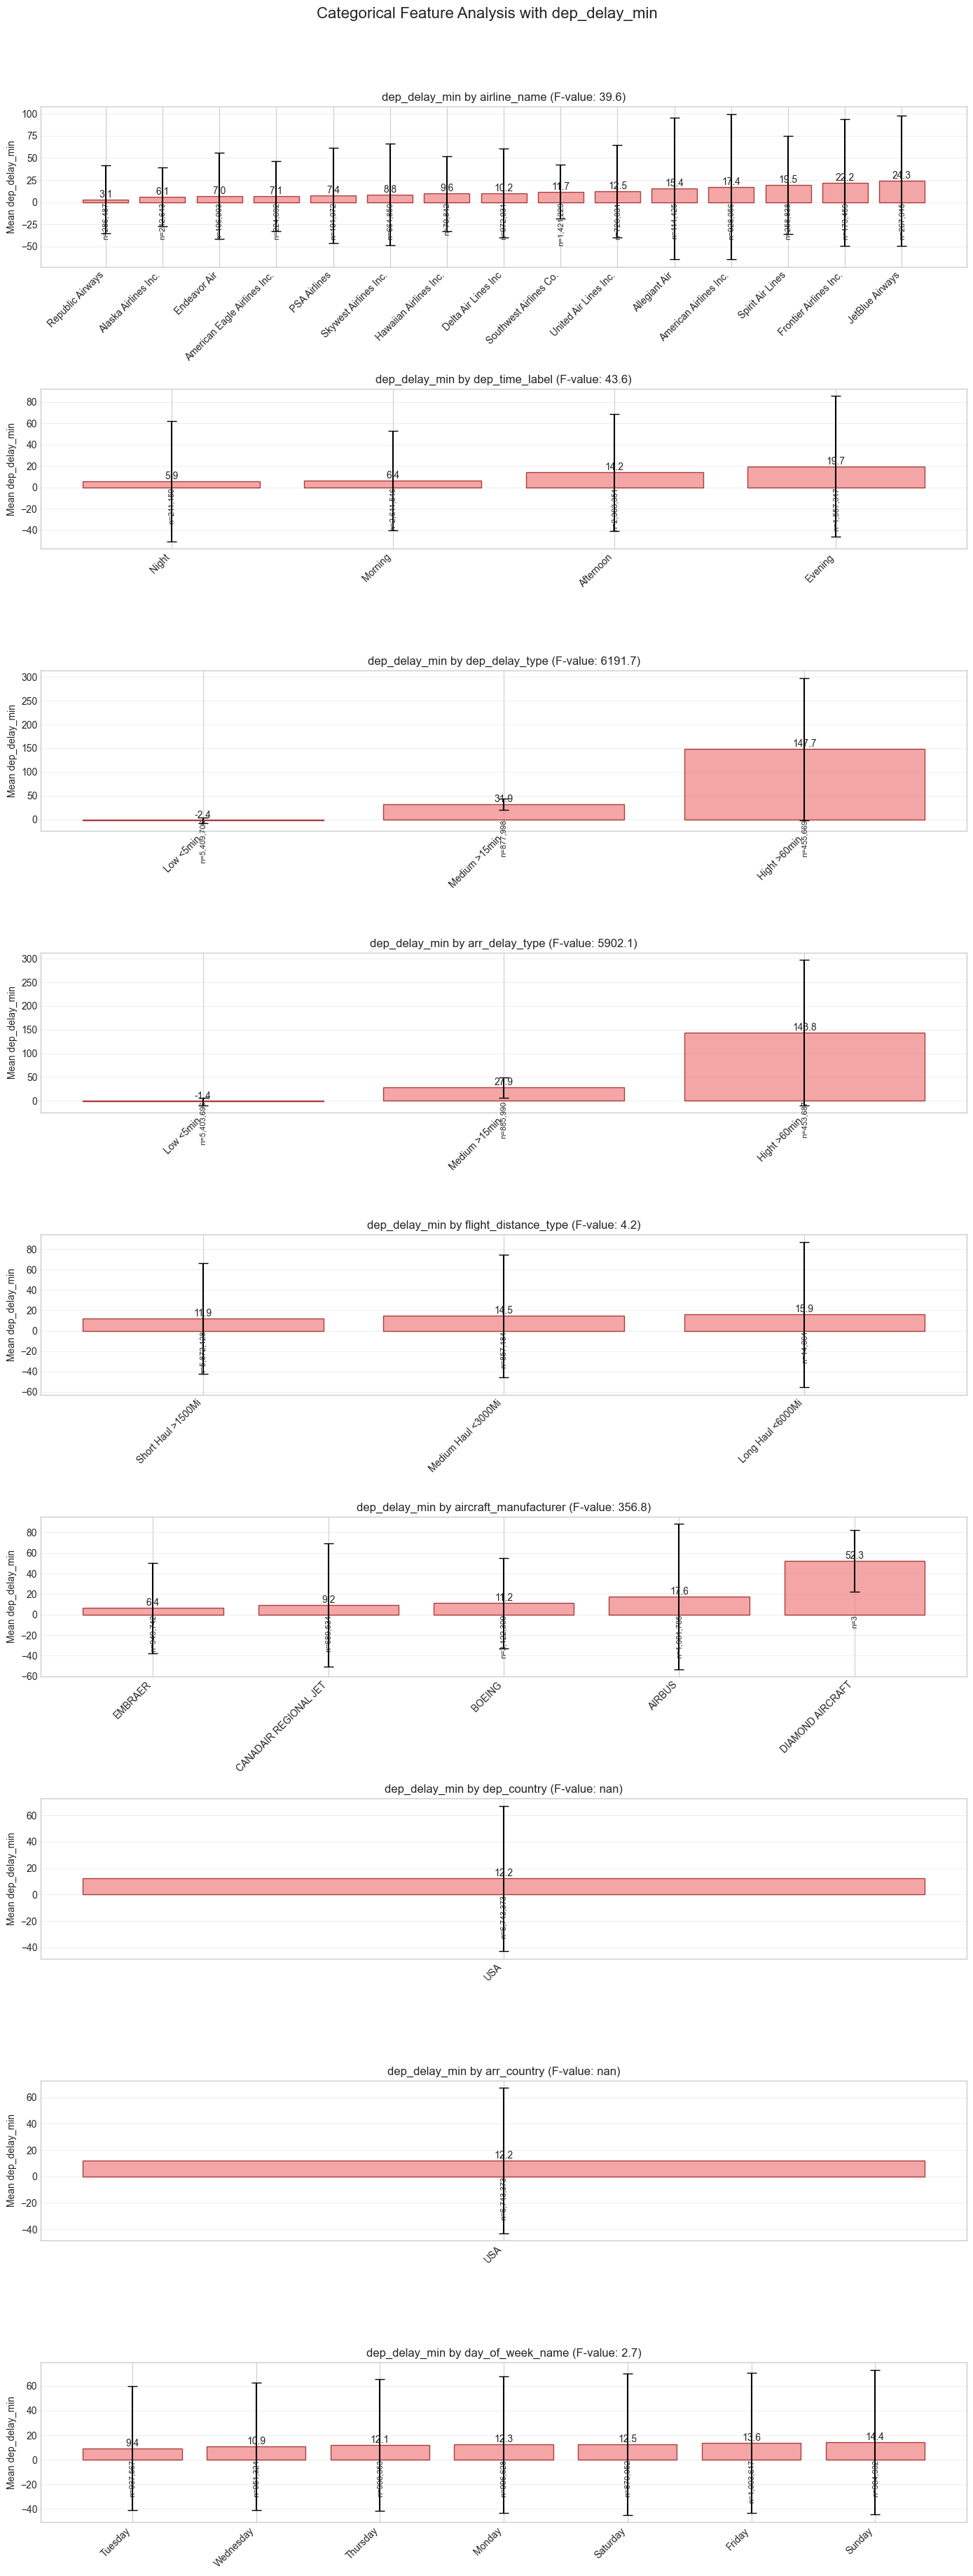

In [42]:
# Analyze categorical features
if EDA != 'eda_no':
    categorical_cols = data_cleaned.select_dtypes(include=['object', 'category']).columns.tolist()

    # Select categoricals with reasonable cardinality
    cat_features = [col for col in categorical_cols if data_cleaned[col].nunique() <= 20]

    target="dep_delay_min"

    if cat_features:
        # Calculate mean delay by category (ANOVA-like)
        fig, axes = plt.subplots(len(cat_features), 1, figsize=(14, 4*len(cat_features)))
        if len(cat_features) == 1:
            axes = [axes]
        
        for idx, feature in enumerate(cat_features):
            ax = axes[idx]
            
            # Calculate statistics
            stats_df = data_cleaned.groupby(feature)[target].agg(['mean', 'std', 'count']).sort_values('mean')
            
            # Create bar plot
            bars = ax.bar(range(len(stats_df)), stats_df['mean'], 
                        yerr=stats_df['std'], capsize=5,
                        color='lightcoral', edgecolor='darkred', alpha=0.7)
            
            ax.set_xticks(range(len(stats_df)))
            ax.set_xticklabels(stats_df.index, rotation=45, ha='right')
            ax.set_ylabel(f'Mean {target}')
            ax.set_title(f'{target} by {feature} (F-value: {stats_df["mean"].var():.1f})')
            ax.grid(True, alpha=0.3, axis='y')
            
            # Add value labels
            for i, (mean_val, count) in enumerate(zip(stats_df['mean'], stats_df['count'])):
                ax.text(i, mean_val, f'{mean_val:.1f}', ha='center', va='bottom')
                ax.text(i, 0, f'n={int(count):,}', ha='center', va='top', 
                    fontsize=8, rotation=90)
        
        plt.suptitle(f'Categorical Feature Analysis with {target}', fontsize=16, y=1.02)
        plt.tight_layout()
        eda_fn = 'cat_feature_dep.png'
        plt.savefig(DIR_eda + eda_fn, 
                    dpi=300, 
                    bbox_inches='tight')
        print(f"✅ Saved: {DIR_eda}{eda_fn}")
        plt.show()

✅ Saved: ./df-full_mod-full_ff/eda_graphs/corre_network_dep.png


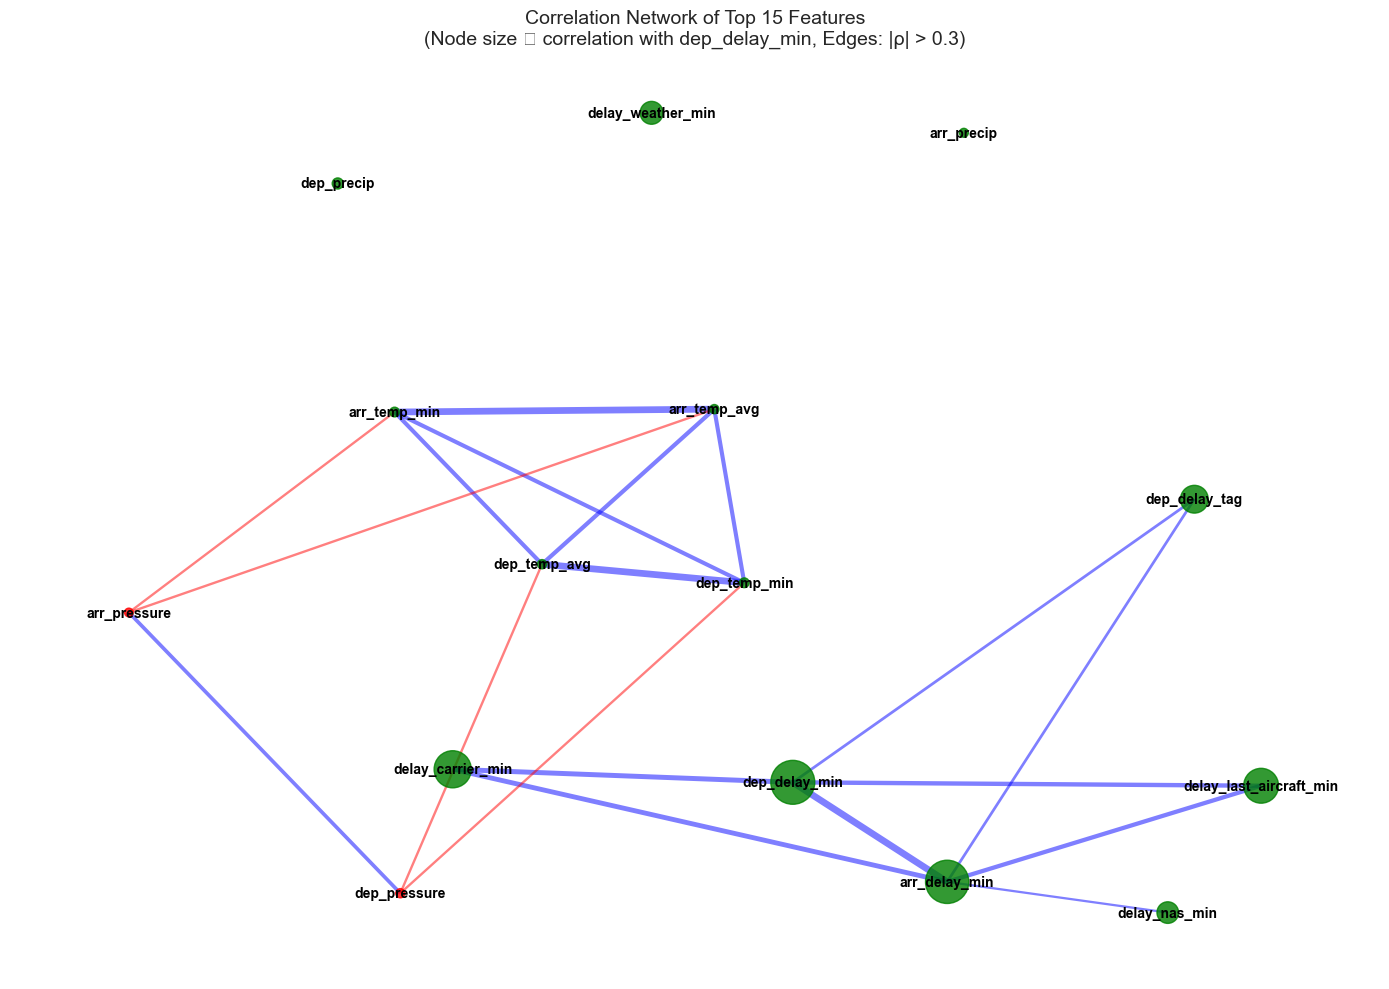

In [43]:
# Create correlation network for top features
if EDA != 'eda_no':
    top_n = 15
    top_features = corr_with_target_dep.abs().sort_values(ascending=False).head(top_n).index.tolist()

    # Create correlation matrix for top features
    top_corr = data_cleaned[top_features].corr()

    # Create graph
    G = nx.Graph()

    # Add nodes
    for feature in top_features:
        G.add_node(feature, size=abs(corr_with_target_dep[feature])*1000)

    # Add edges (only strong correlations)
    threshold = 0.3
    for i in range(len(top_features)):
        for j in range(i+1, len(top_features)):
            corr_value = top_corr.iloc[i, j]
            if abs(corr_value) > threshold:
                G.add_edge(top_features[i], top_features[j], 
                        weight=abs(corr_value)*5,
                        color='red' if corr_value < 0 else 'blue')

    # Plot network
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=2, iterations=50)

    # Node sizes based on correlation with target
    node_sizes = [G.nodes[node]['size'] for node in G.nodes()]
    node_colors = ['green' if corr_with_target_dep[node] > 0 else 'red' for node in G.nodes()]

    # Draw graph
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, 
                        node_color=node_colors, alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=[G[u][v]['weight'] for u, v in G.edges()],
                        edge_color=[G[u][v]['color'] for u, v in G.edges()],
                        alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    plt.title(f'Correlation Network of Top {top_n} Features\n'
            f'(Node size ∝ correlation with {target}, '
            f'Edges: |ρ| > {threshold})', fontsize=14, pad=20)
    plt.axis('off')
    plt.tight_layout()
    eda_fn = 'corre_network_dep.png'
    plt.savefig(DIR_eda + eda_fn, 
                dpi=300, 
                bbox_inches='tight')
    print(f"✅ Saved: {DIR_eda}{eda_fn}")
    plt.show()

In [44]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(n, n_nc, data, feature, figsize=(12, 7), kde=False, bins=13):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """

    # creating the 2 subplots
    f2, (ax_box2, ax_hist2) = plt.subplots(nrows = 2,  # Number of rows of the subplot grid= 2
                                           sharex = True,  # x-axis will be shared among all subplots
                                           gridspec_kw = {"height_ratios": (0.25, 0.75)},
                                           figsize = figsize)

    # boxplot will be created and a star will indicate the mean value of the column
    sns.boxplot(data = data,
                x = feature,
                ax = ax_box2,
                showmeans = True,
                color = "violet")

    # For histogram
    sns.histplot(data = data,
                 x = feature,
                 kde = kde,
                 ax = ax_hist2,
                 bins = bins,
                 palette = "winter") if bins else sns.histplot(data = data,
                                                               x = feature,
                                                               kde = kde,
                                                               ax = ax_hist2,
                                                               palette = "winter")

    # Add mean to the histogram
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--")

    # Add median to the histogram
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-")

    # Add legend
    ax_hist2.legend()
    
    # Add title
    plt.suptitle(f'Distribution of {feature}')
    
    # Save the figure
    eda_fn = 'dist_'+feature+'.png'
    plt.savefig(DIR_eda + eda_fn, 
                dpi=300, 
                bbox_inches='tight')
    print(f"{n}/{n_nc} ✅ Saved: {DIR_eda}{eda_fn}")
    
    plt.show()

1/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_day_of_week_num.png


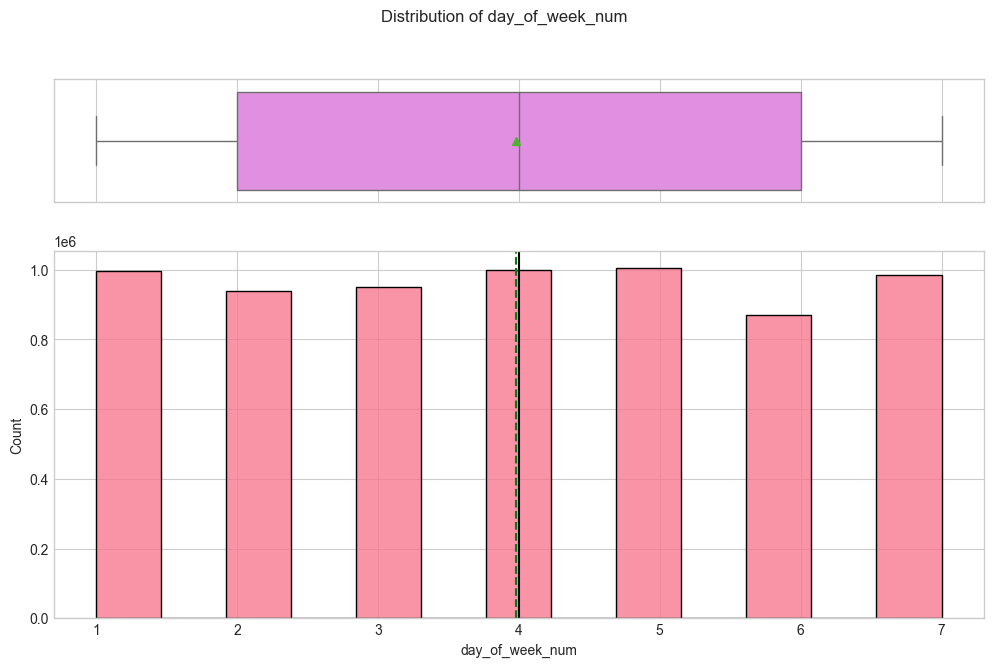

2/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_dep_delay_min.png


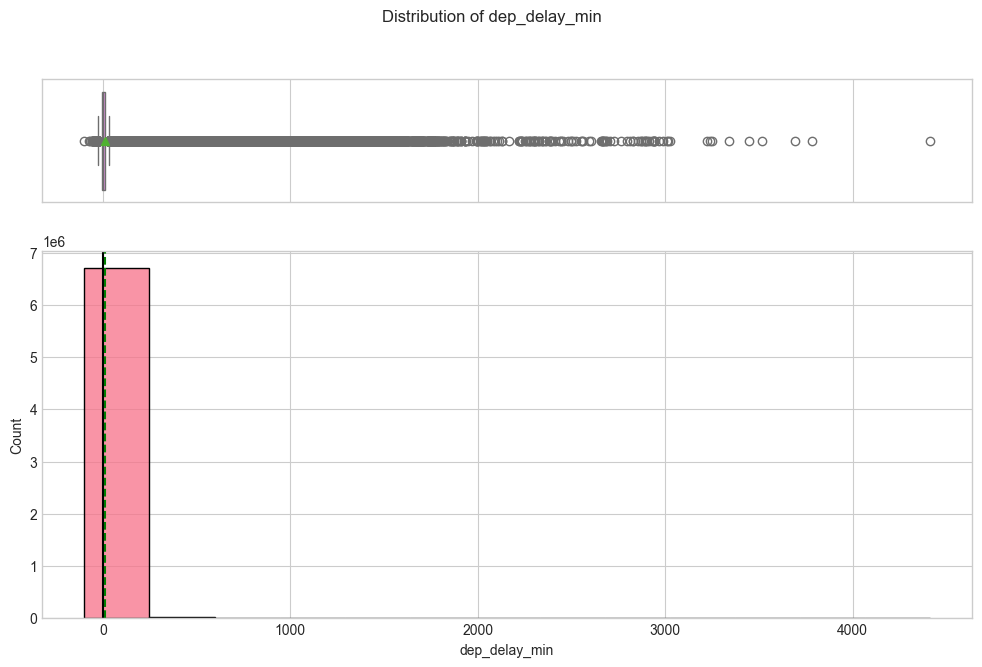

3/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_dep_delay_tag.png


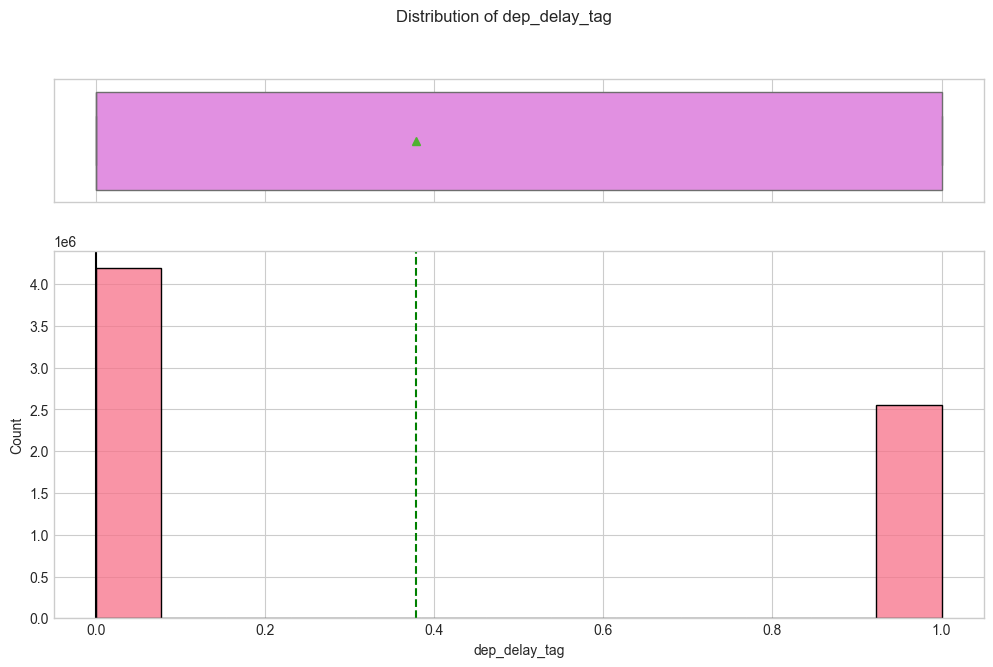

4/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_arr_delay_min.png


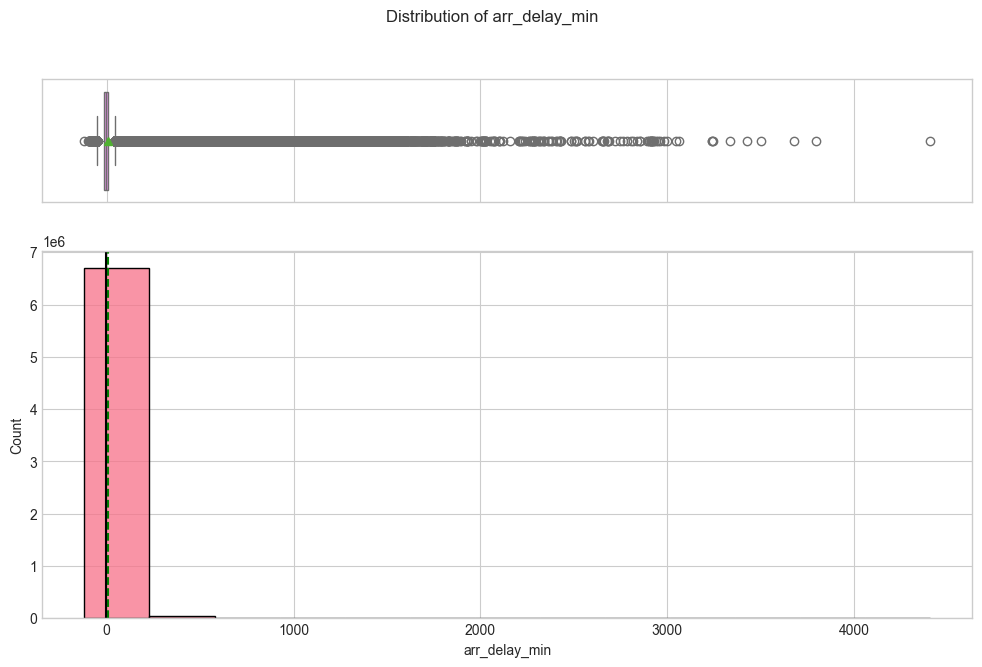

5/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_flight_duration_min.png


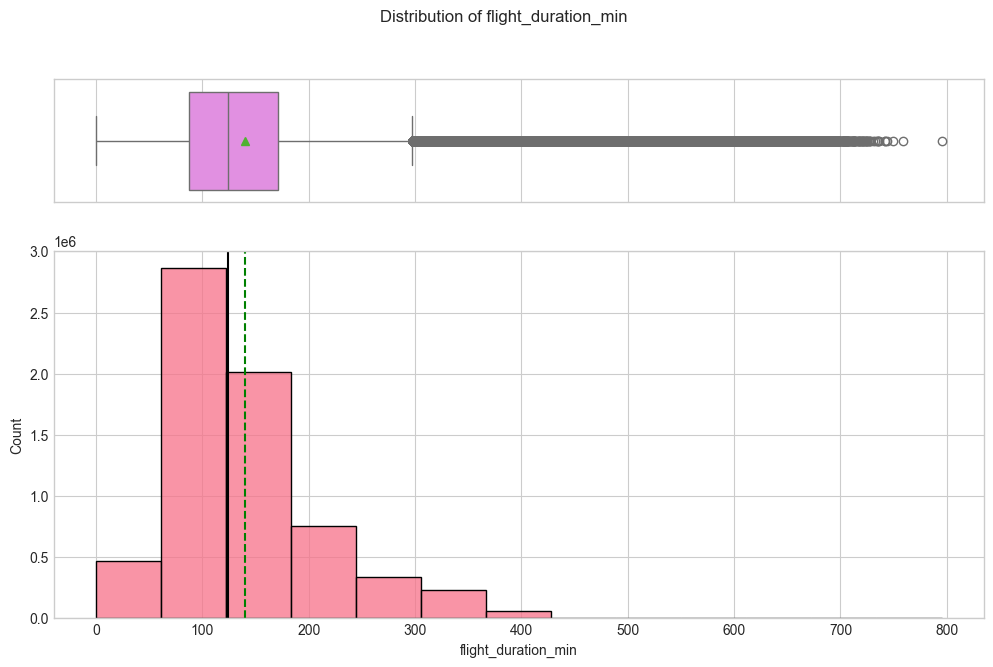

6/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_delay_carrier_min.png


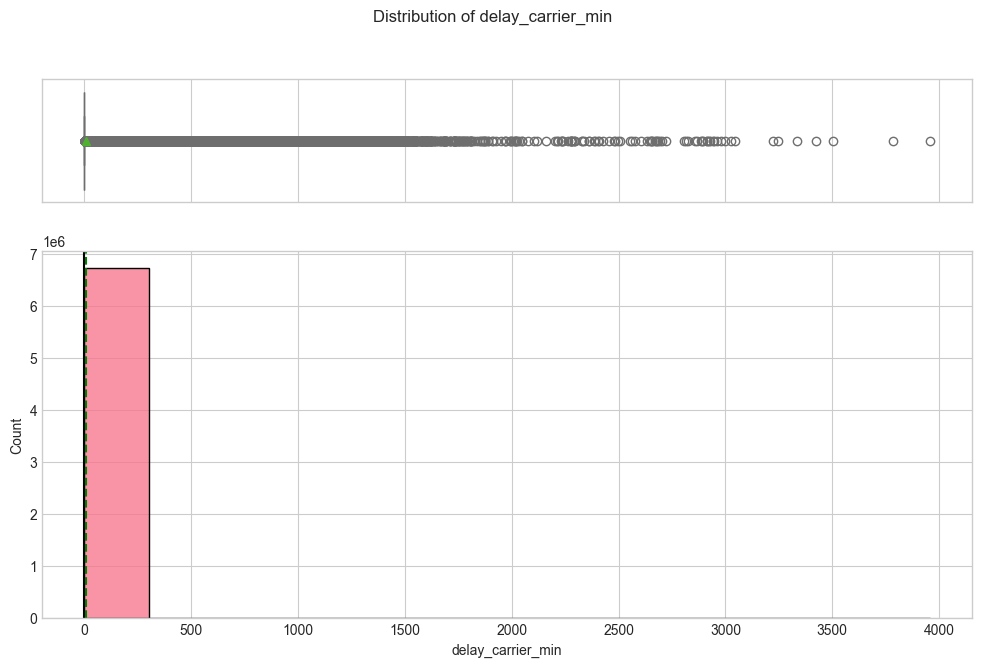

7/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_delay_weather_min.png


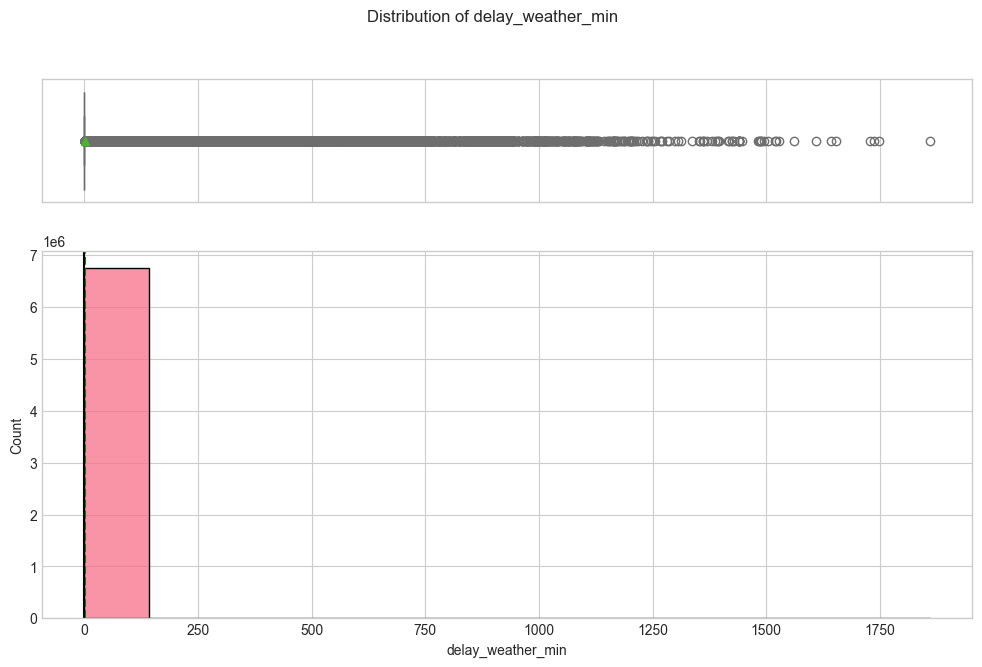

8/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_delay_nas_min.png


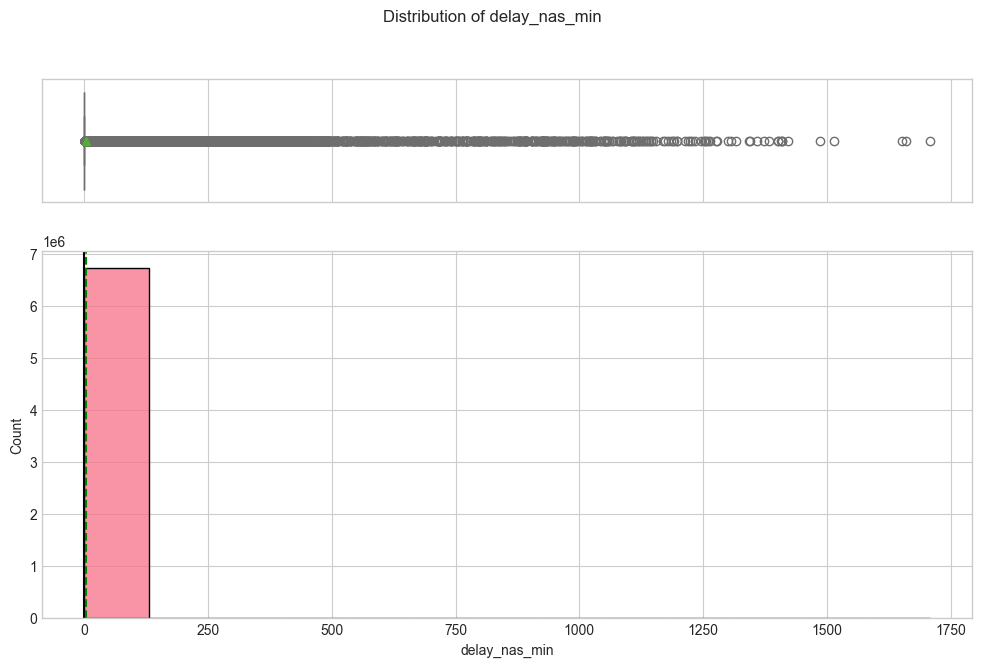

9/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_delay_security_min.png


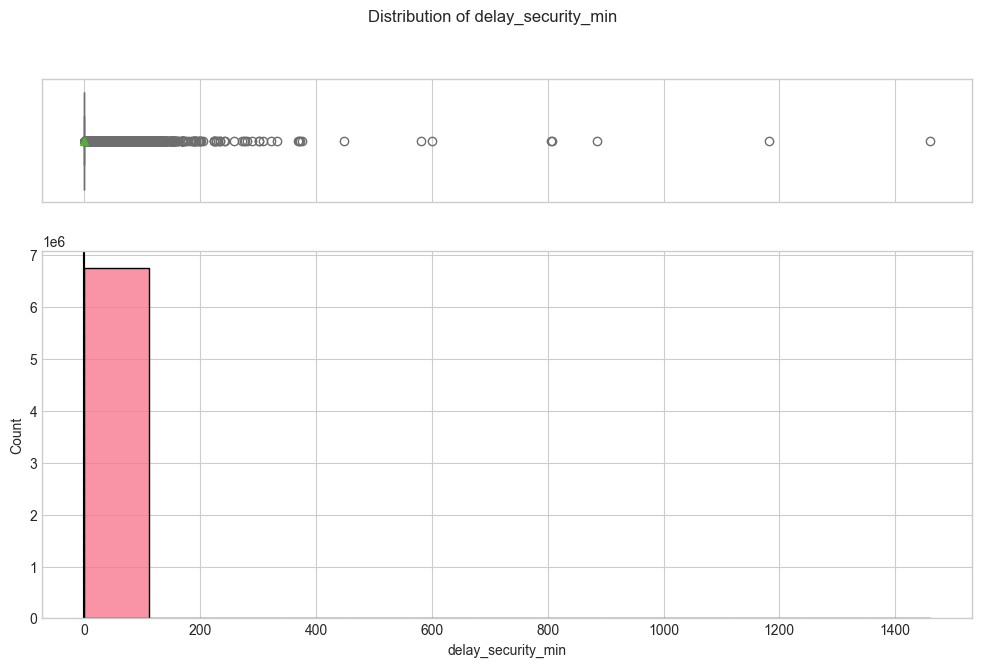

10/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_delay_last_aircraft_min.png


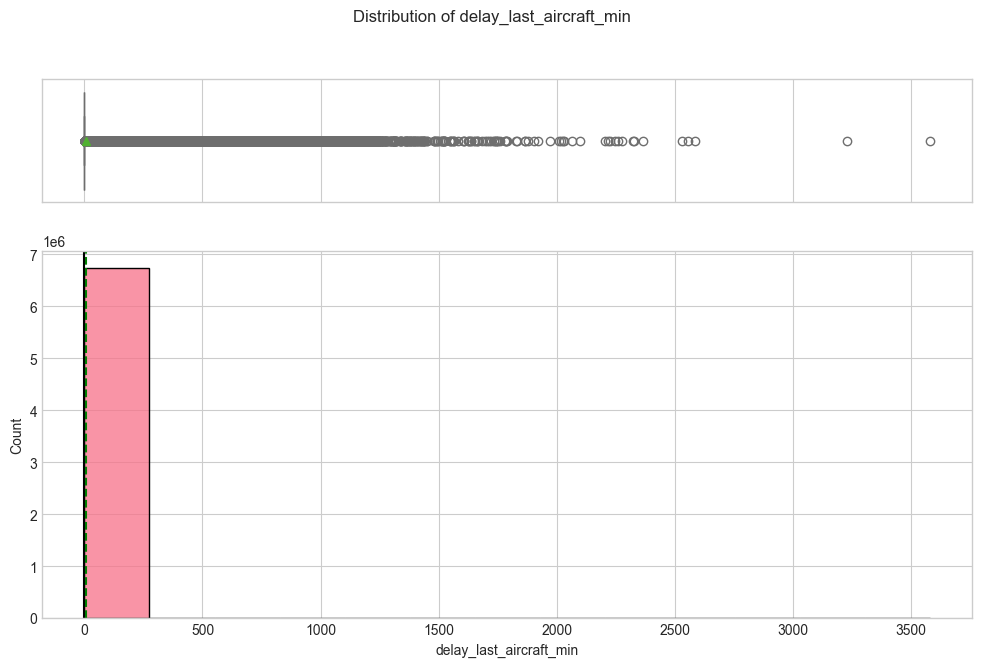

11/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_aircraft_age_years.png


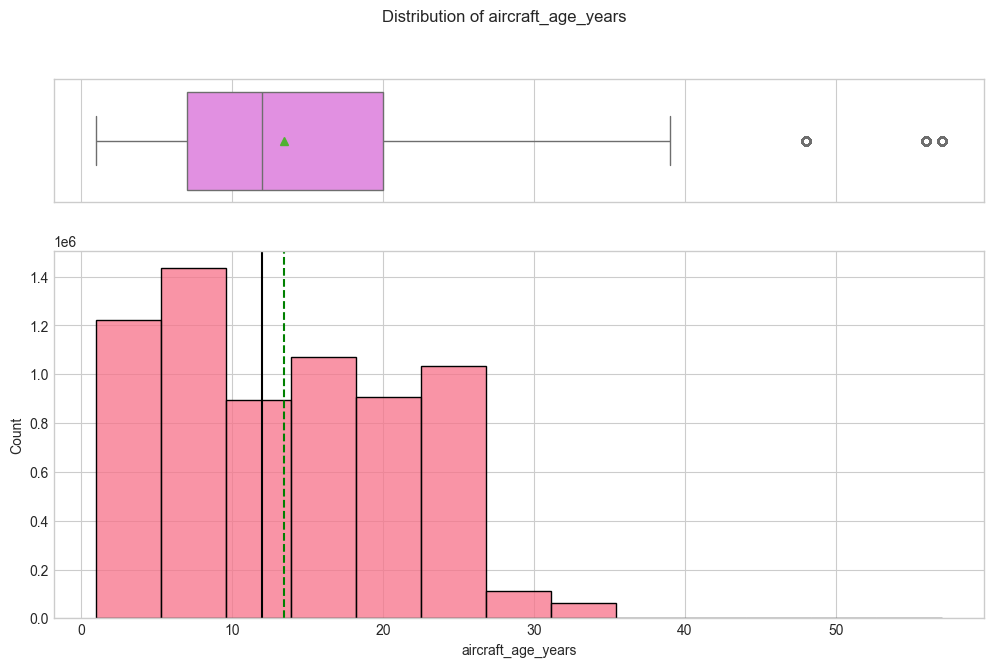

12/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_dep_latitude.png


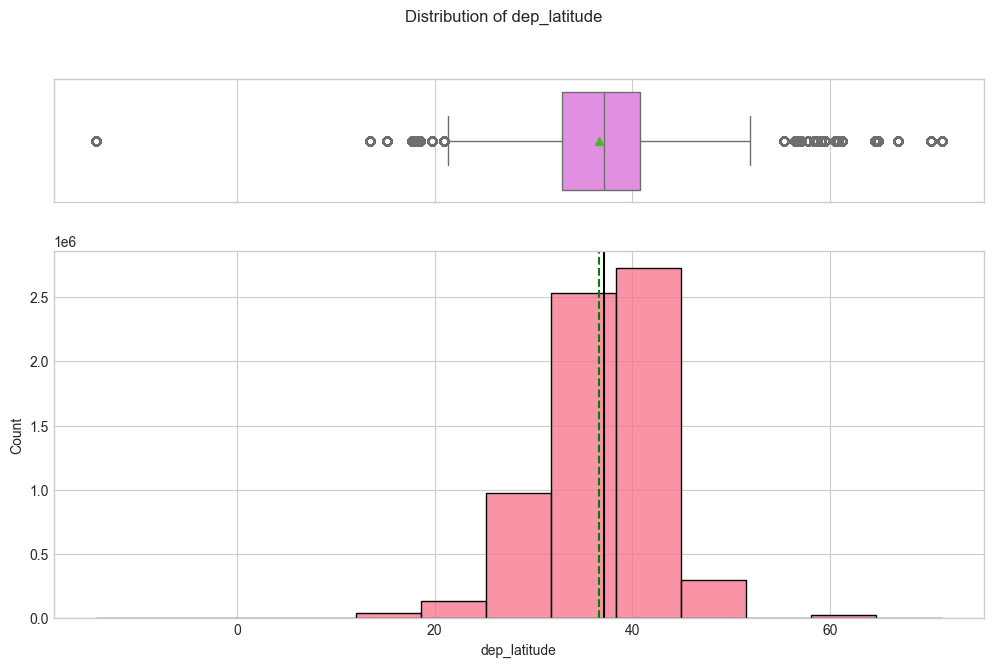

13/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_dep_longitude.png


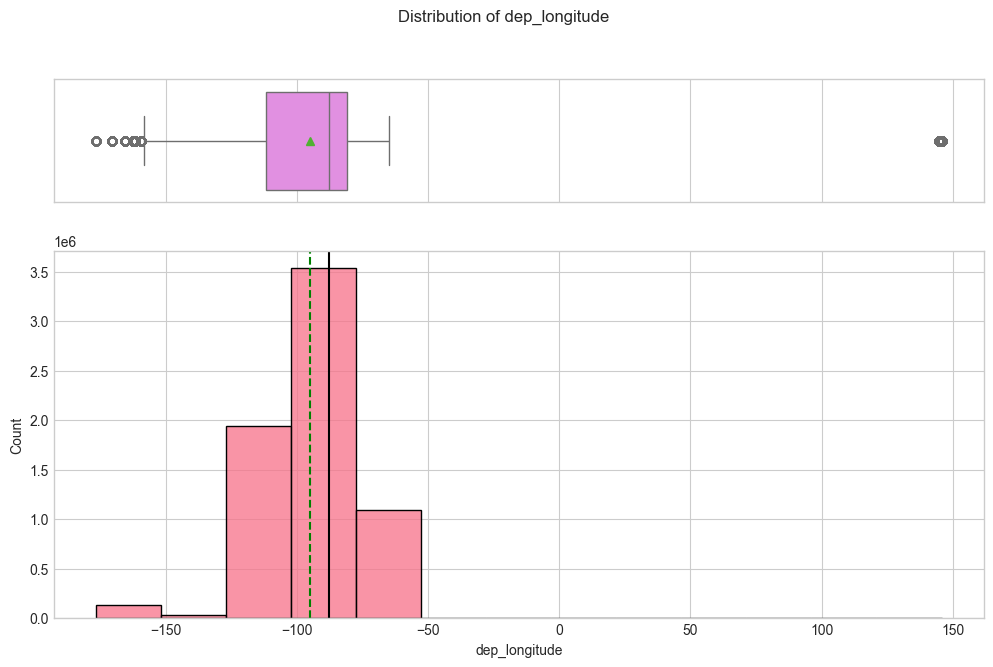

14/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_arr_latitude.png


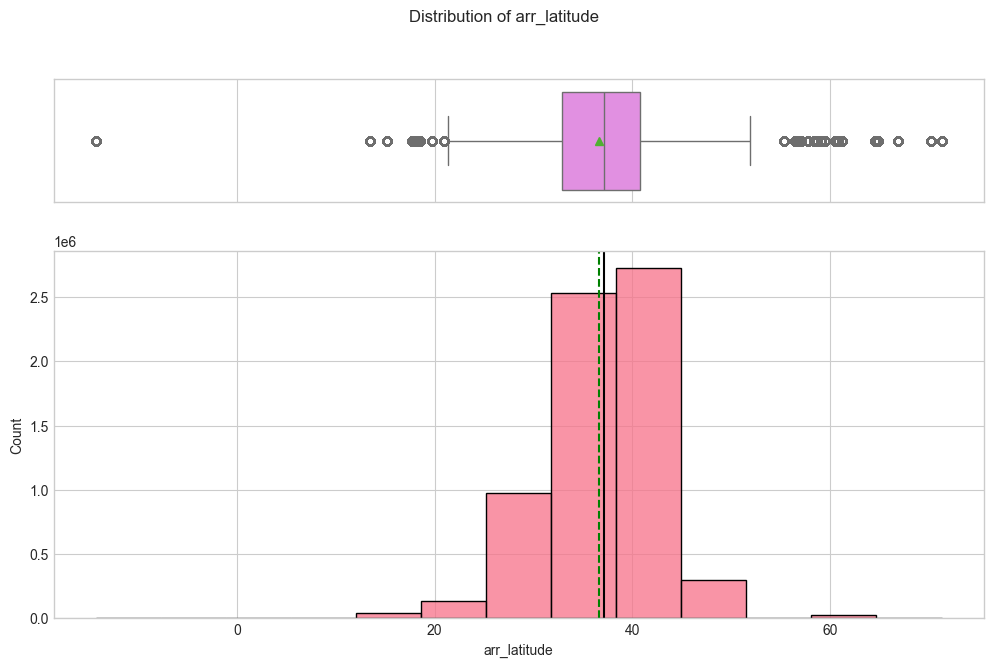

15/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_arr_longitude.png


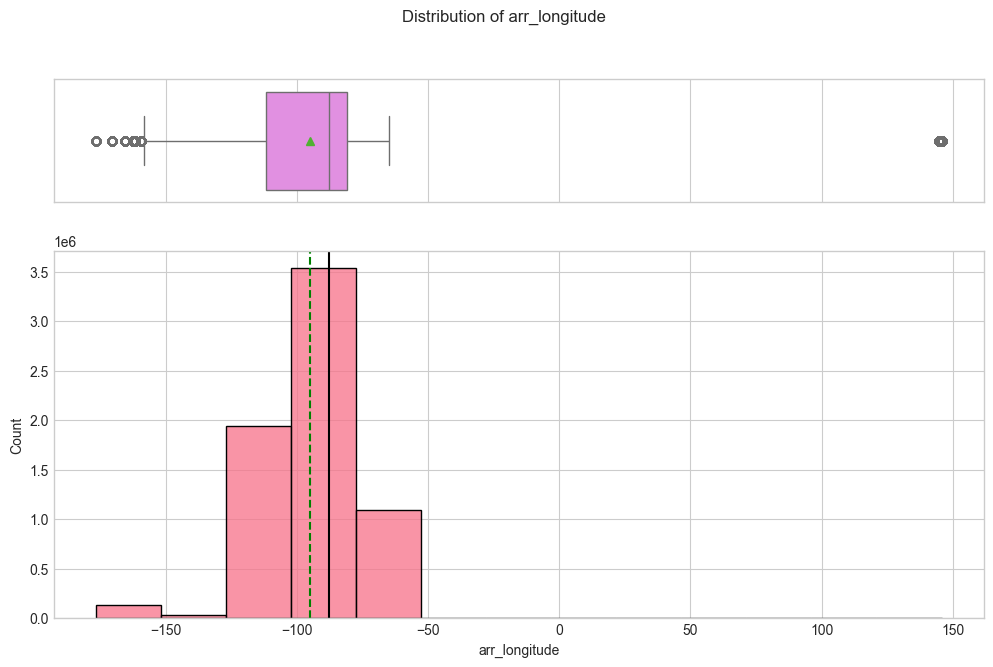

16/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_dep_temp_avg.png


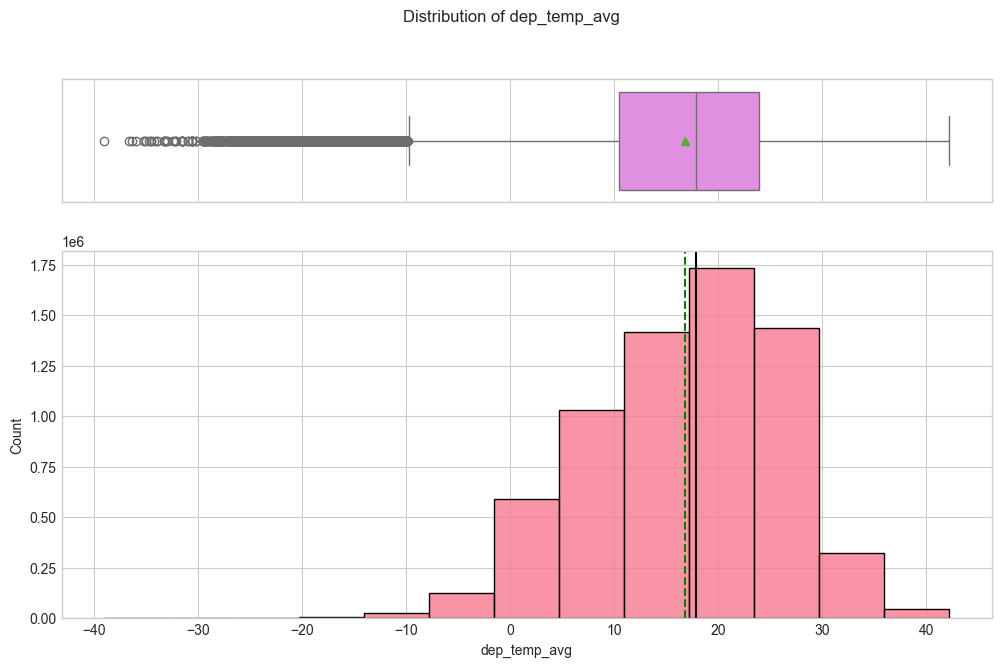

17/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_dep_temp_min.png


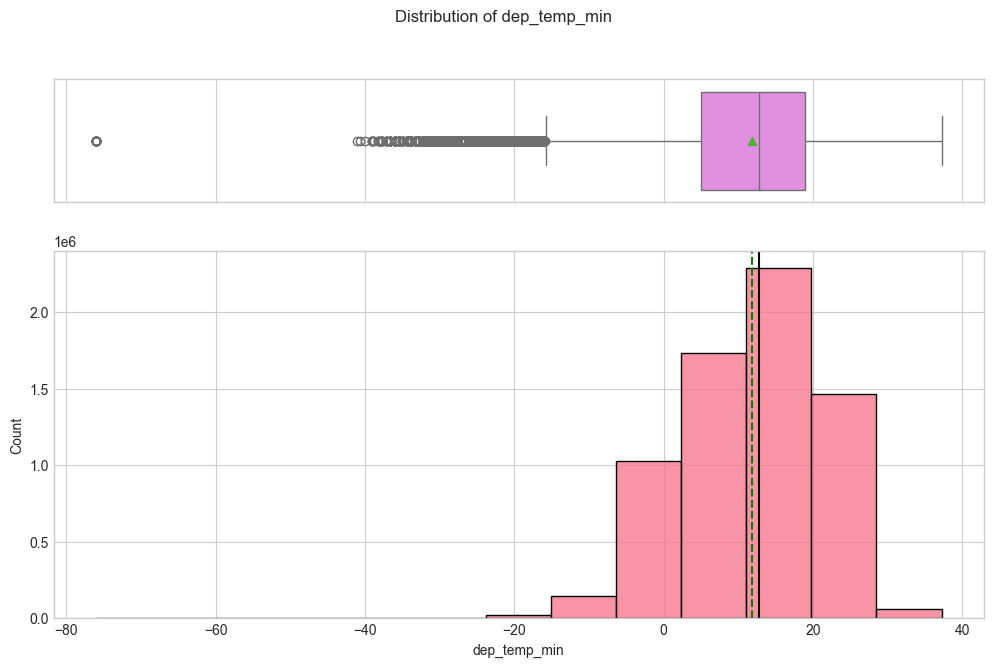

18/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_dep_temp_max.png


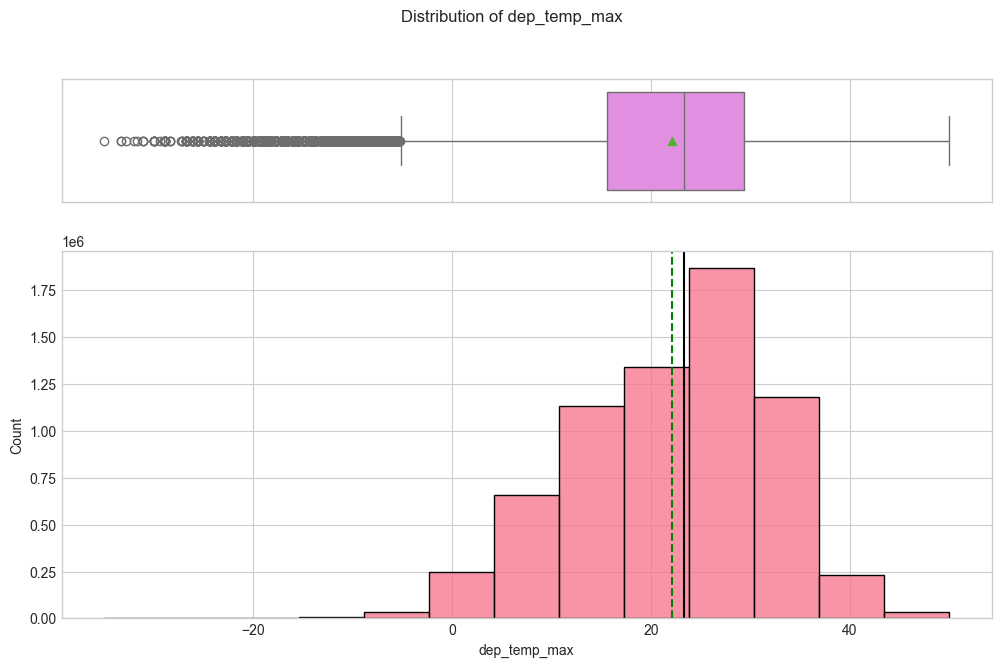

19/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_dep_precip.png


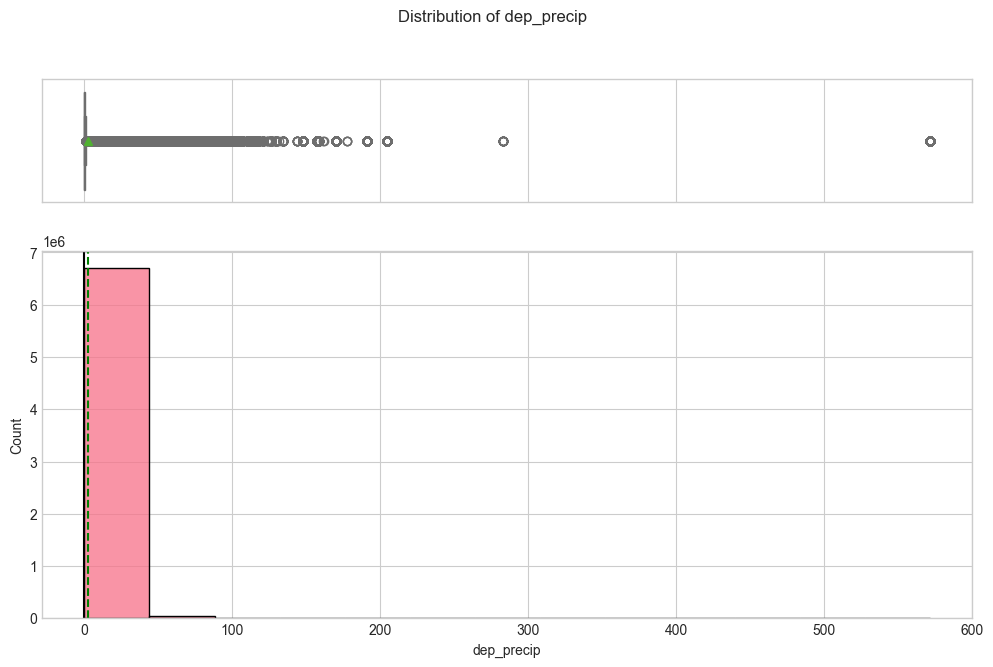

20/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_dep_snow.png


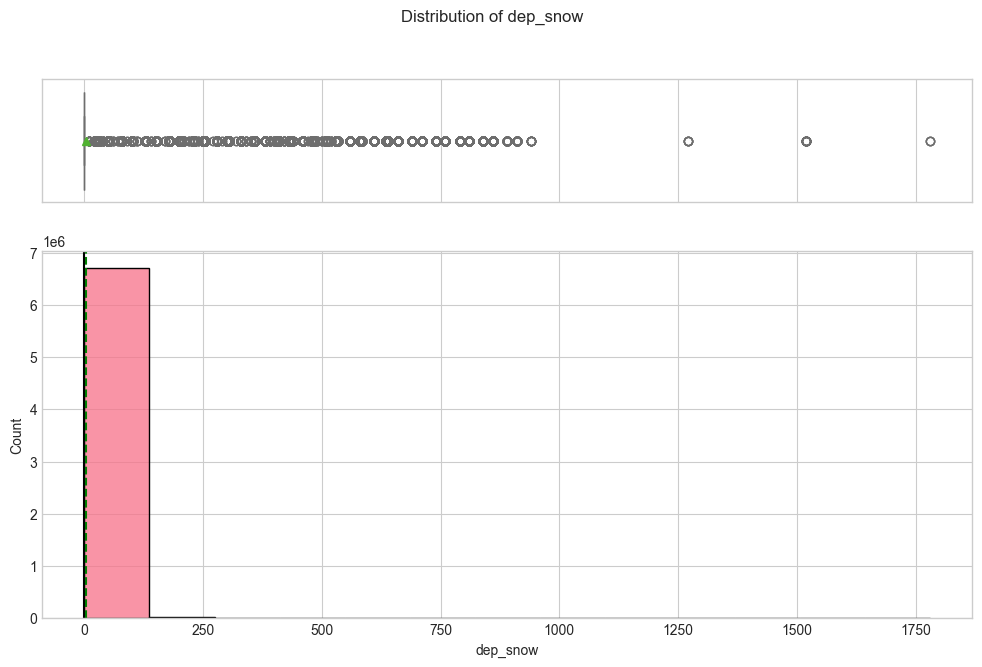

21/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_dep_wind_dir.png


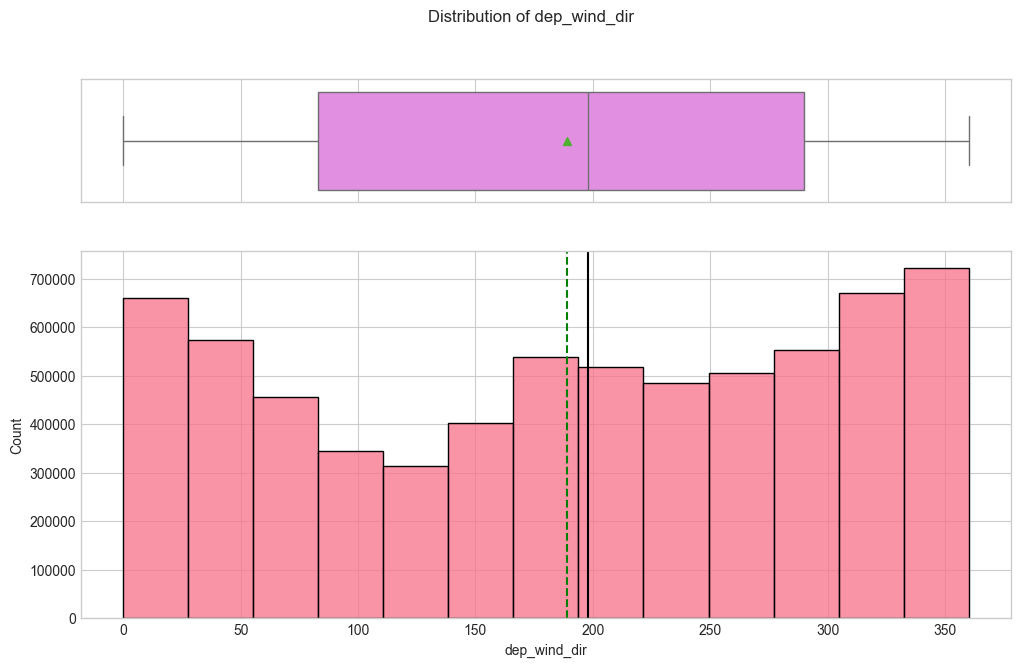

22/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_dep_wind_speed.png


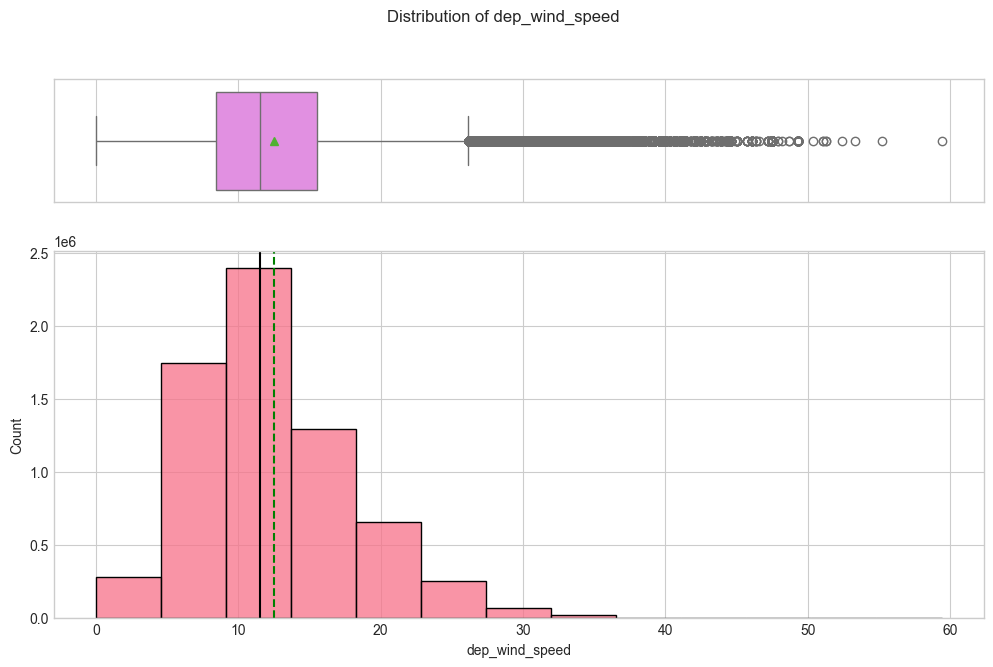

23/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_dep_pressure.png


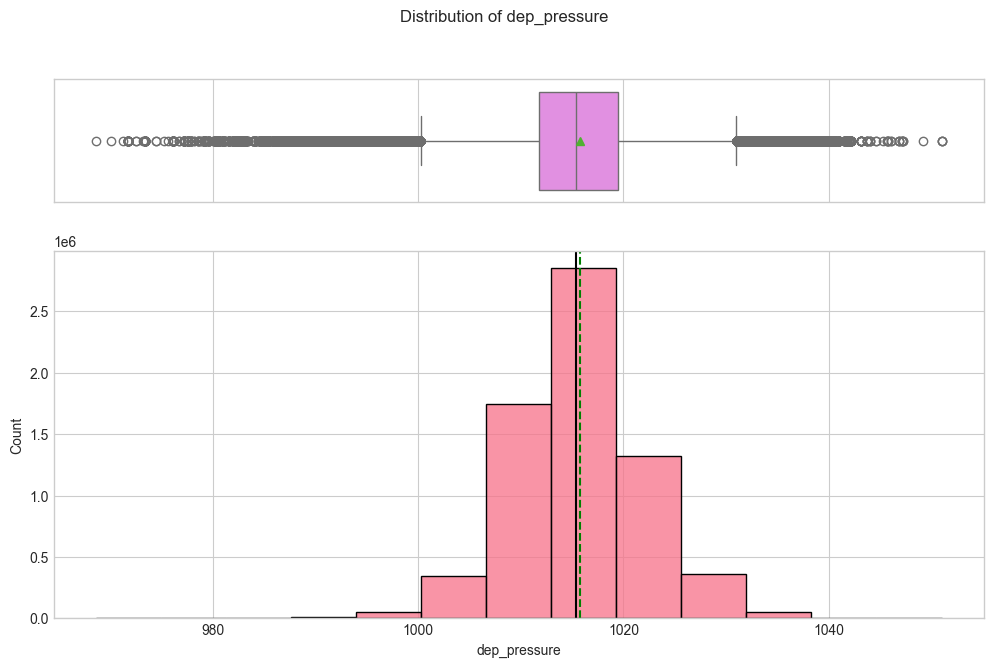

24/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_arr_temp_avg.png


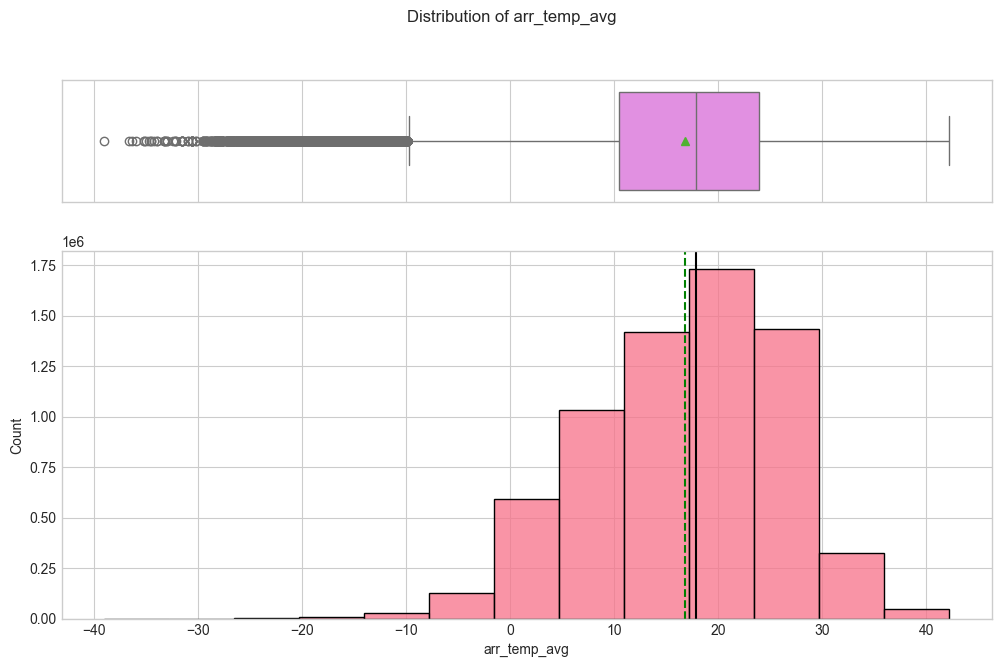

25/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_arr_temp_min.png


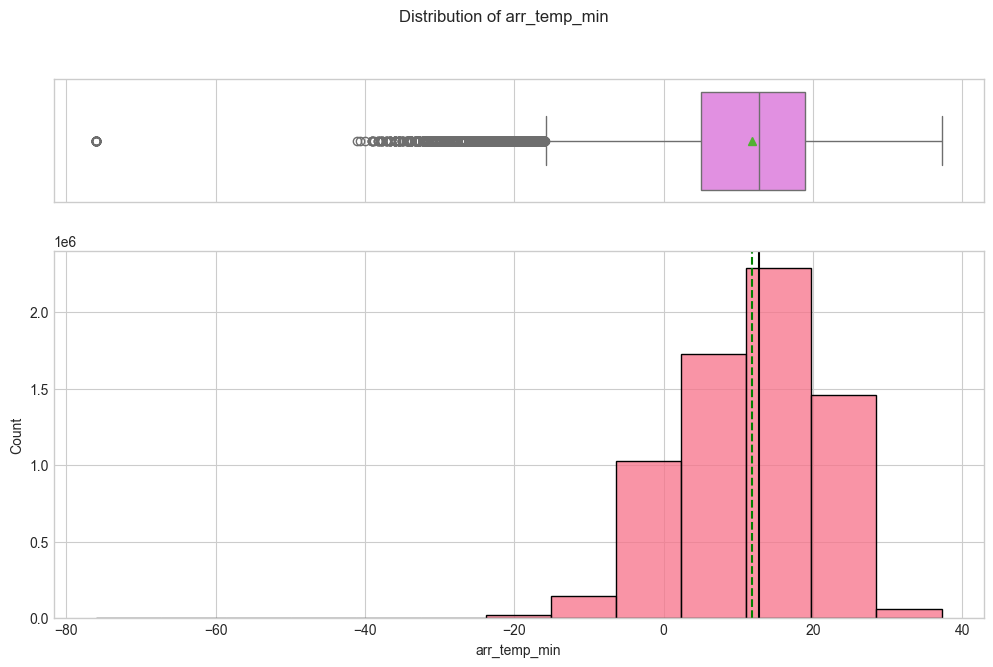

26/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_arr_temp_max.png


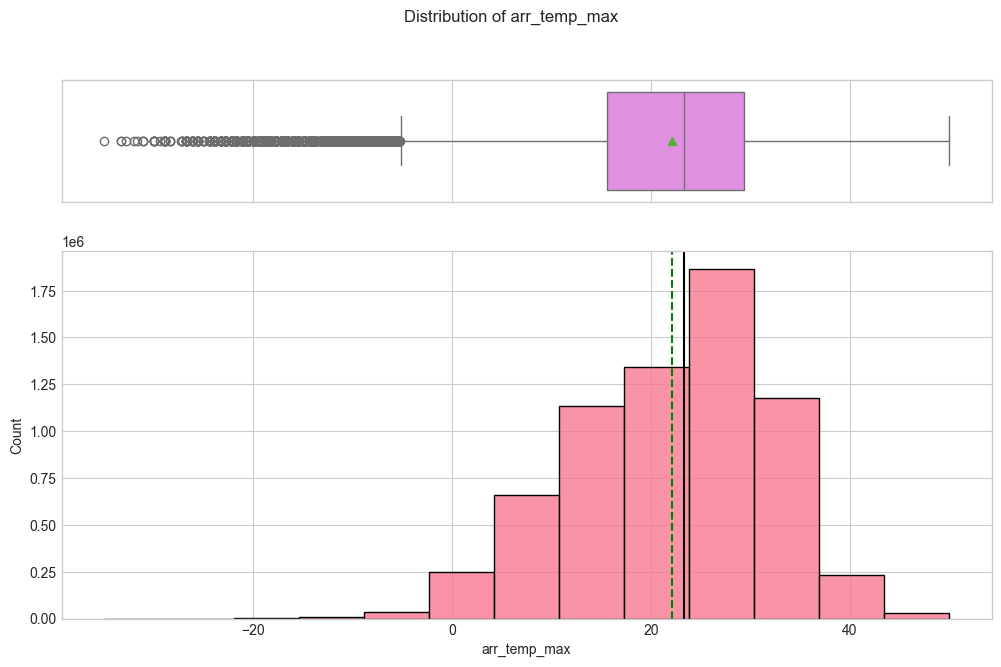

27/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_arr_precip.png


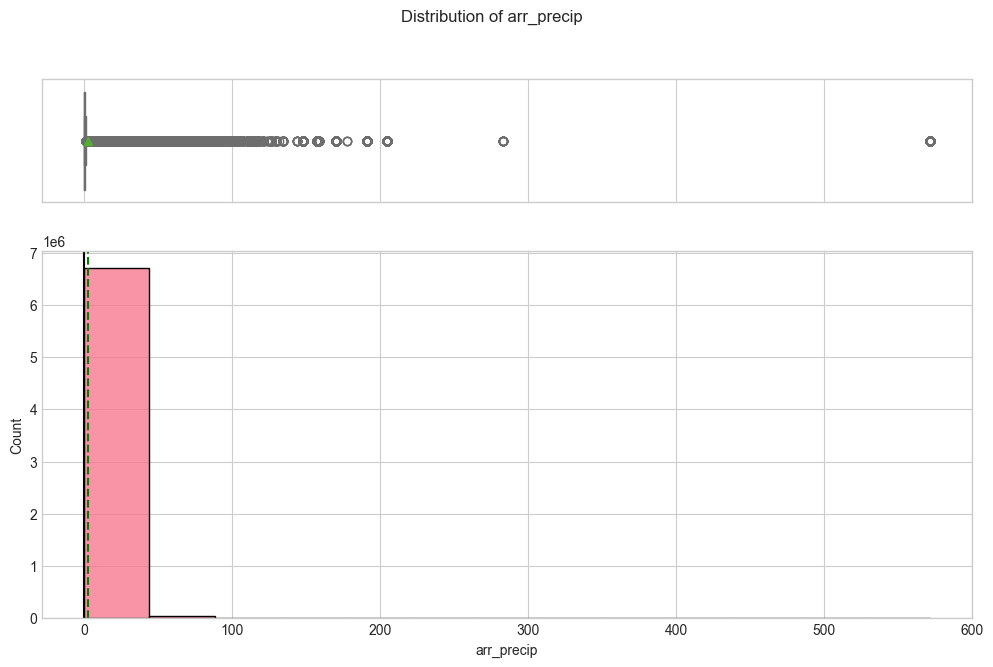

28/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_arr_snow.png


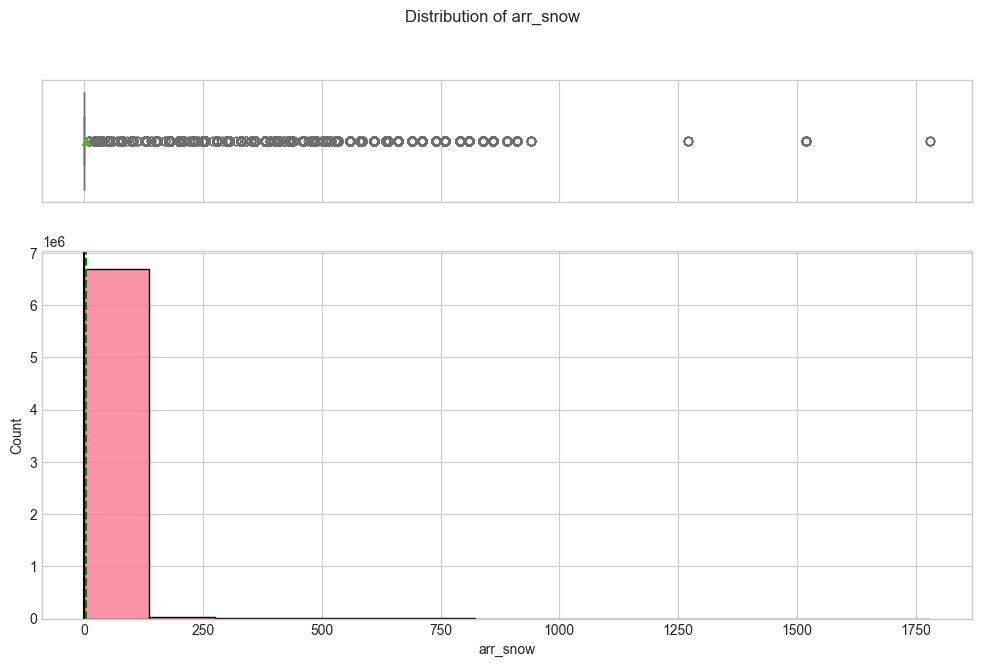

29/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_arr_wind_dir.png


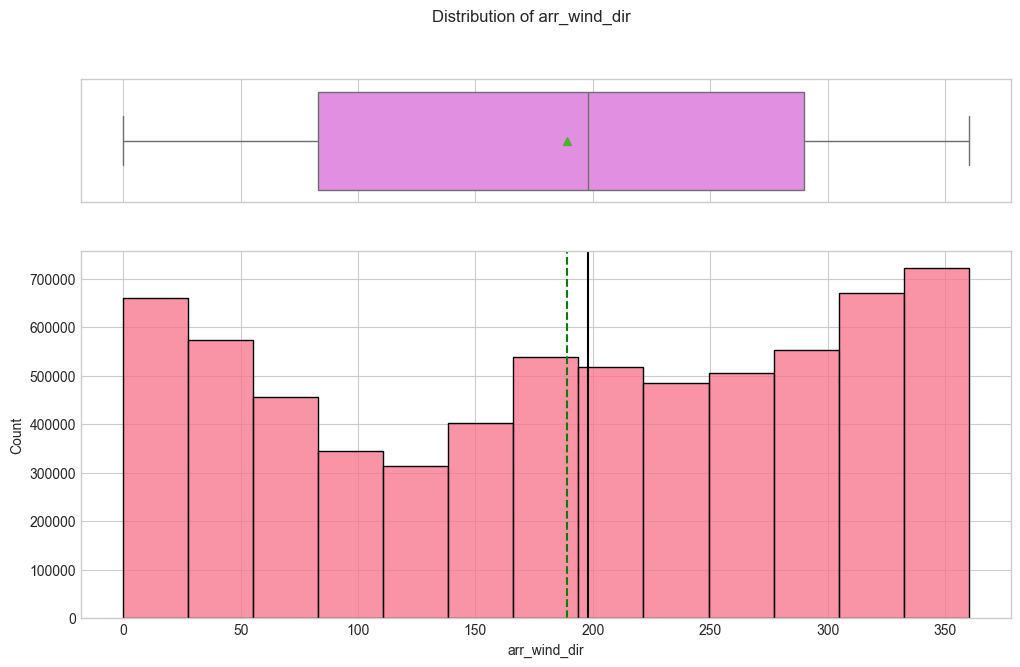

30/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_arr_wind_speed.png


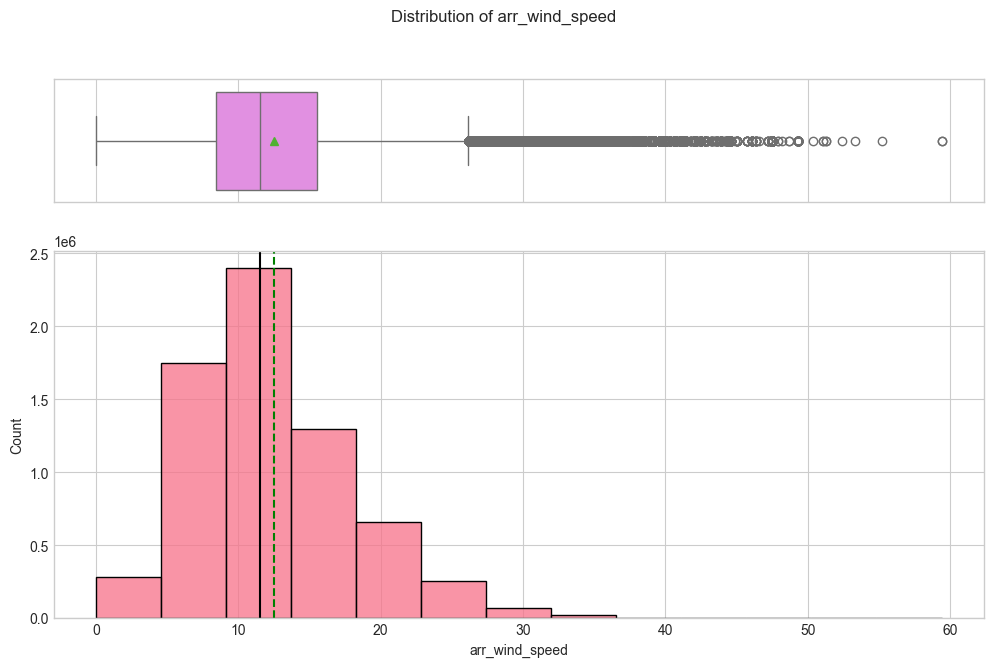

31/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_arr_pressure.png


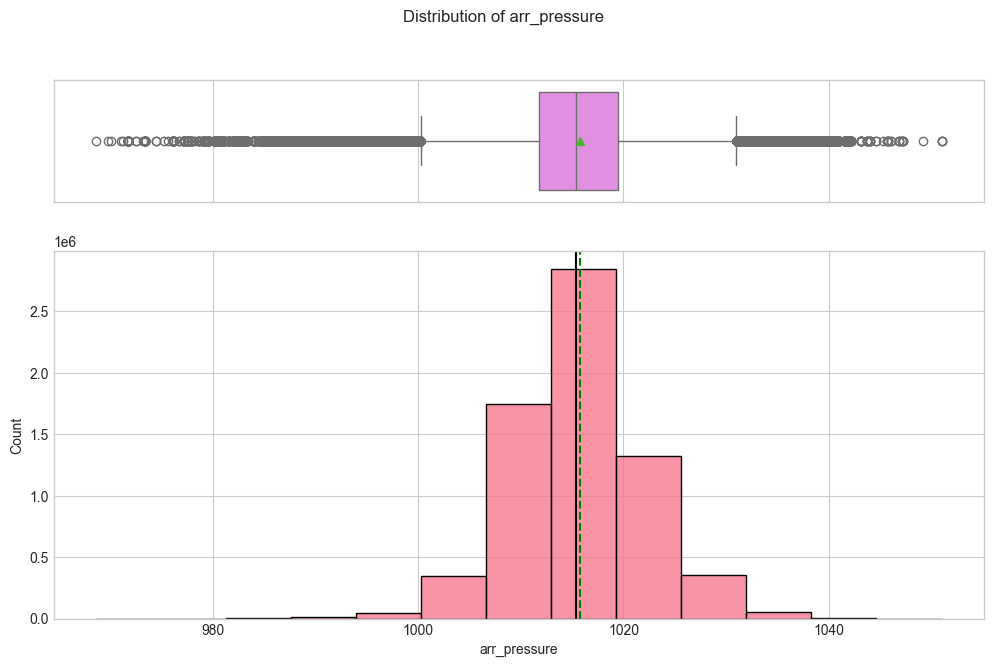

32/32 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/dist_route_distance_km.png


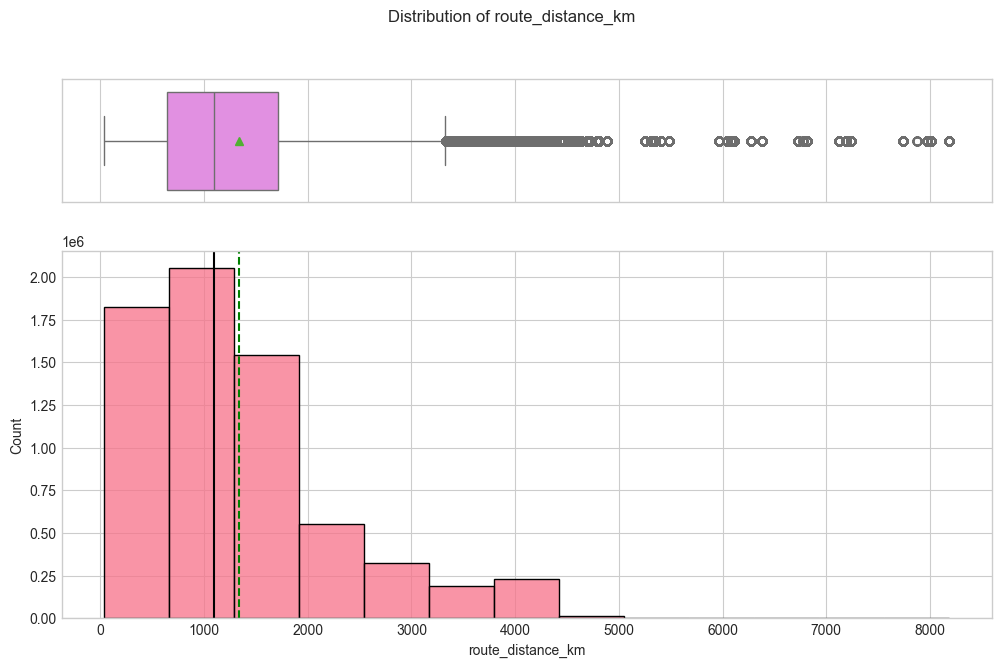

In [45]:
# ==============================================
# Histogram for Numerical Columns
# ==============================================
if EDA != 'eda_no':
    n_nc = len(numerical_cols)
    for n, var in enumerate(numerical_cols, start=1):
        histogram_boxplot(n, n_nc, data_cleaned, var)

In [46]:
# function to create labeled barplots

def labeled_barplot(num, n_nc, data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(data=data,
                       x=feature,
                       palette="Paired",
                       order=data[feature].value_counts().index[:n].sort_values(),)

    for p in ax.patches:
        if perc == True:
            label = "{:.2f}%".format(100 * p.get_height() / total)  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(label,
                    (x, y),
                    ha="center",
                    va="center",
                    size=12,
                    xytext=(0, 5),
                    textcoords="offset points",)  # annotate the percentage
    if count> 33:
        font_size=48
    else:
        font_size=16

    plt.suptitle(f'Distribution of {feature}', fontsize=font_size)

    # Save the figure if path is provided
    eda_fn = 'cat_'+feature+'.png'
    plt.savefig(DIR_eda + eda_fn, 
                dpi=300, 
                bbox_inches='tight')
    print(f"{num}/{n_nc} ✅ Saved: {DIR_eda}{eda_fn} - N. of Features: {count}")

    plt.show()  # show the plot

In [47]:
# assigning the objects to a variable
cat_col = data_cleaned.select_dtypes(include=['object', 'category']).columns.tolist()
print(cat_col)

['flight_date', 'airline_name', 'aircraft_tail_num', 'dep_airport_code', 'dep_city_name', 'dep_time_label', 'dep_delay_type', 'arr_airport_code', 'arr_city_name', 'arr_delay_type', 'flight_distance_type', 'aircraft_manufacturer', 'aircraft_model', 'dep_airport_name', 'dep_city', 'dep_state', 'dep_country', 'arr_airport_name', 'arr_city', 'arr_state', 'arr_country', 'day_of_week_name']


In [48]:
# objects to analyze. anything but very large numbers.
cat_col_mini = ['airline_name',
                'aircraft_manufacturer',
                'aircraft_model',
                'dep_state',
                'arr_state',
                'day_of_week_name',
                'dep_delay_type',
                'arr_delay_type',
                'dep_time_label']

1/9 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/cat_airline_name.png - N. of Features: 15


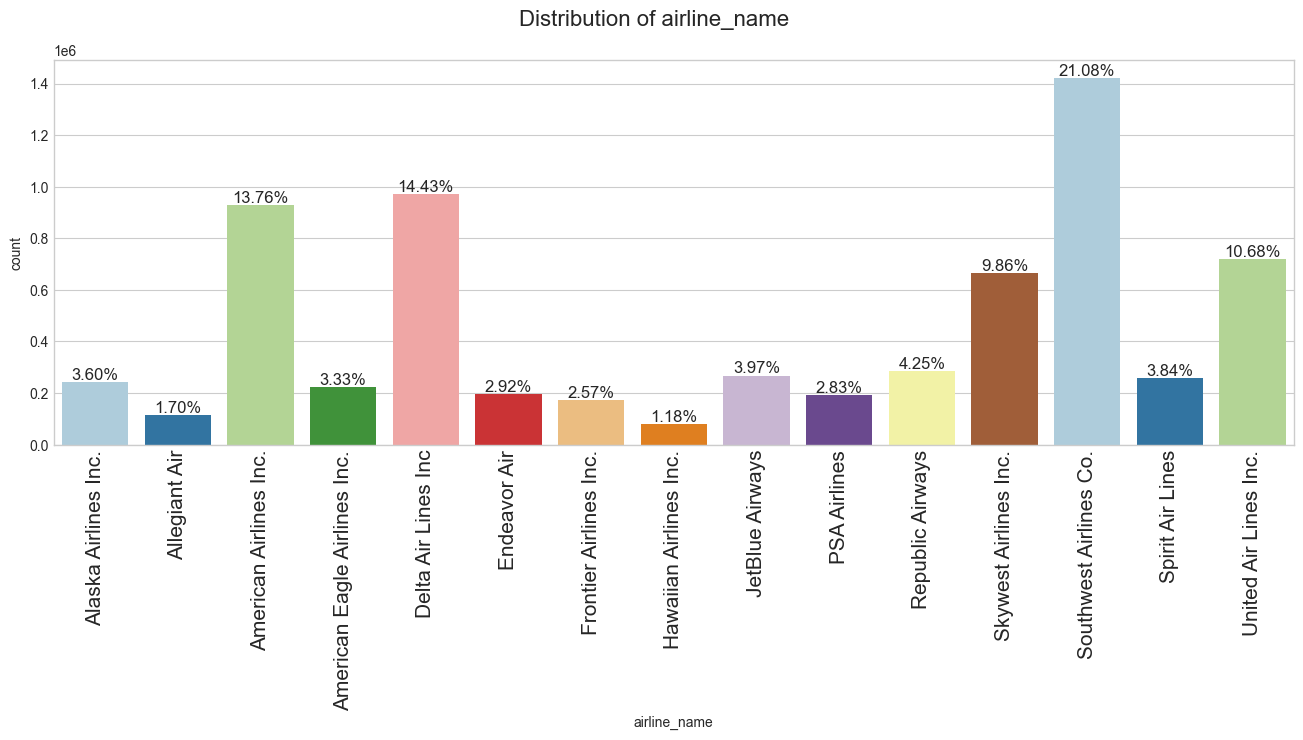

2/9 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/cat_aircraft_manufacturer.png - N. of Features: 5


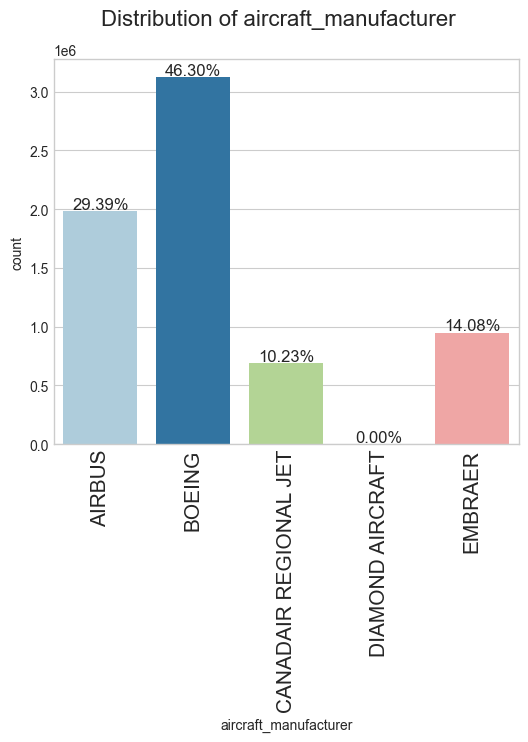

3/9 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/cat_aircraft_model.png - N. of Features: 21


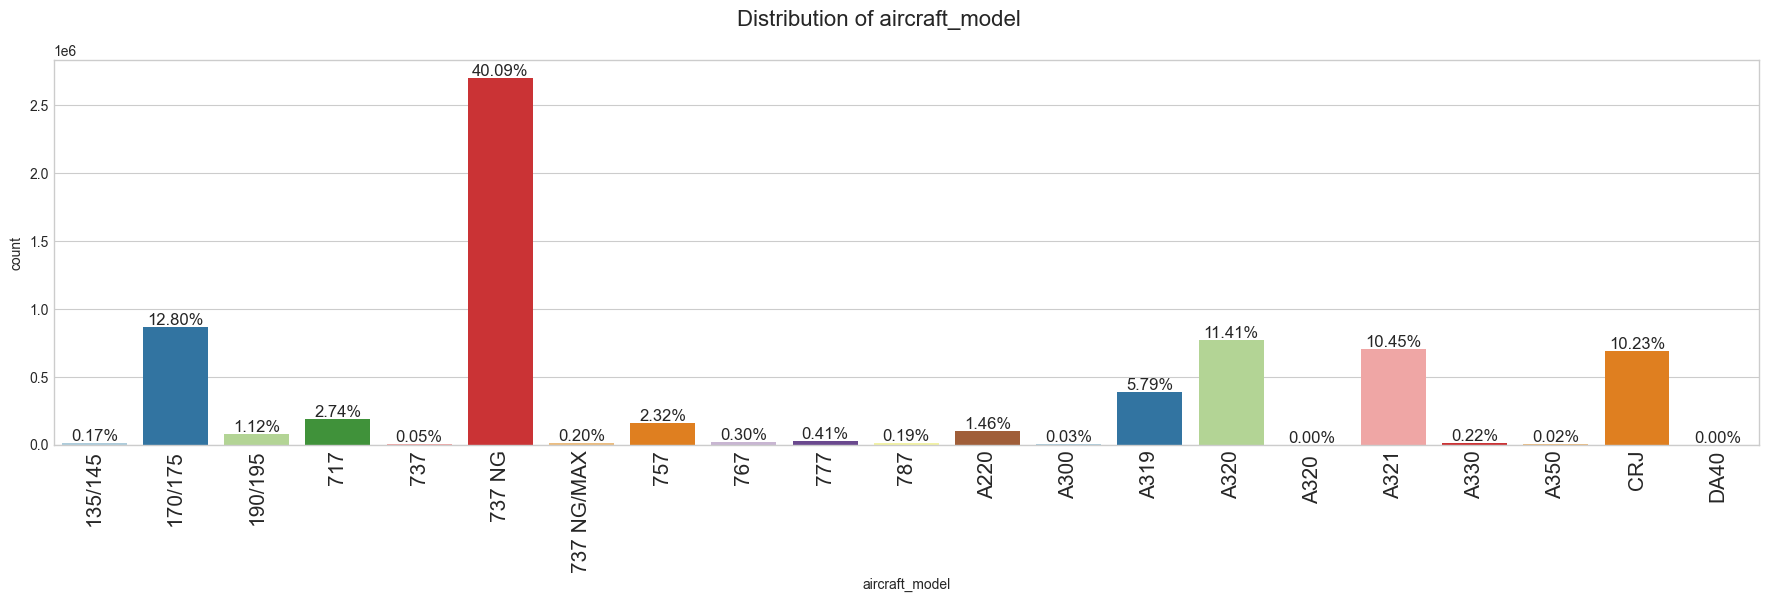

4/9 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/cat_dep_state.png - N. of Features: 54


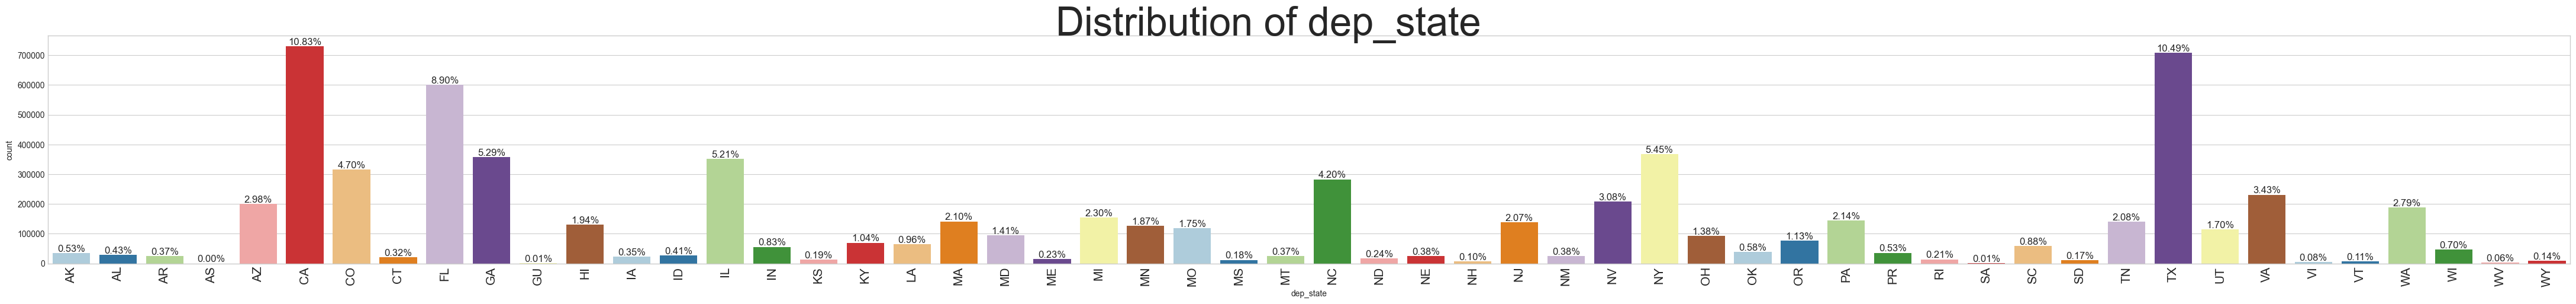

5/9 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/cat_arr_state.png - N. of Features: 54


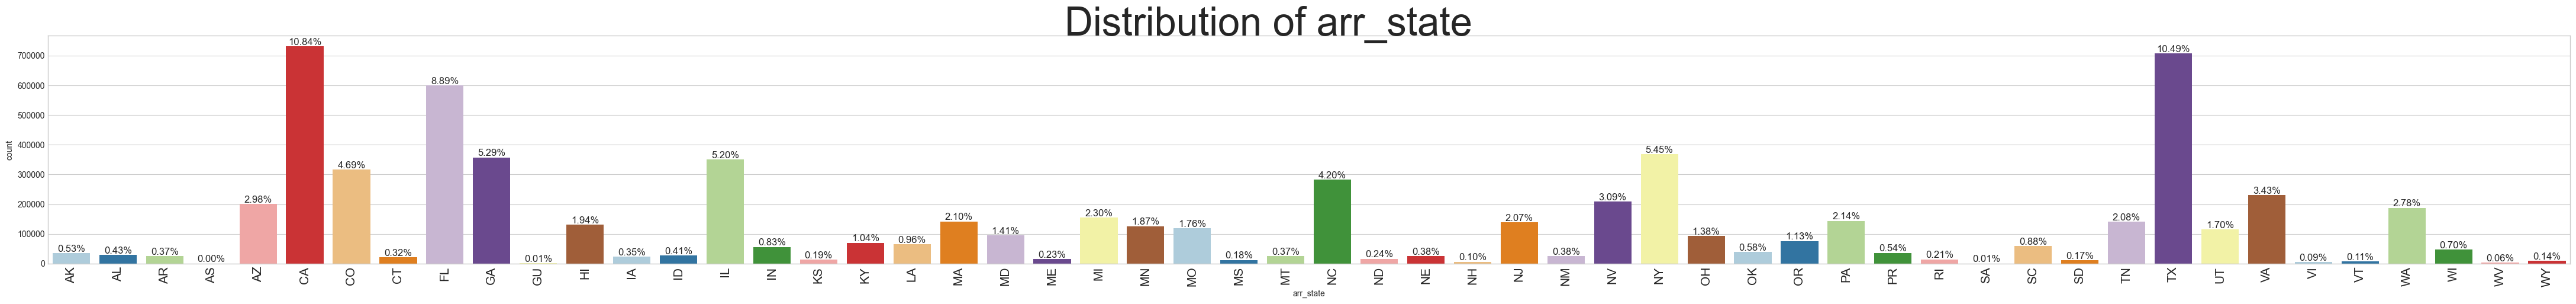

6/9 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/cat_day_of_week_name.png - N. of Features: 7


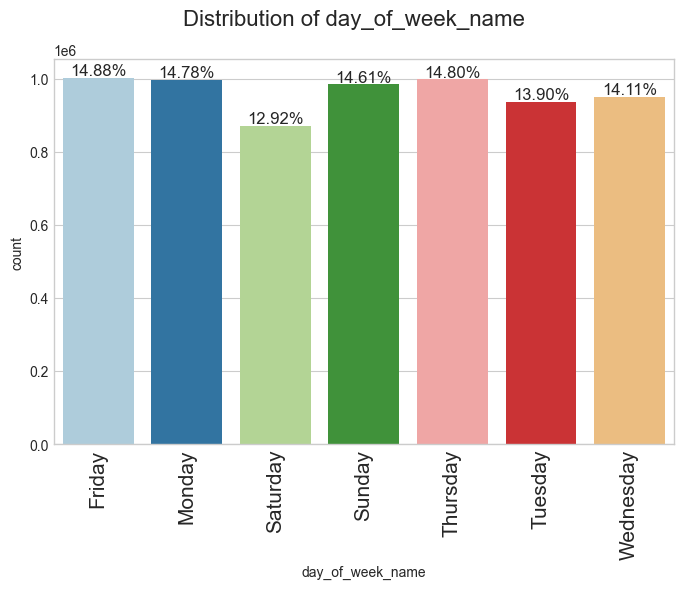

7/9 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/cat_dep_delay_type.png - N. of Features: 3


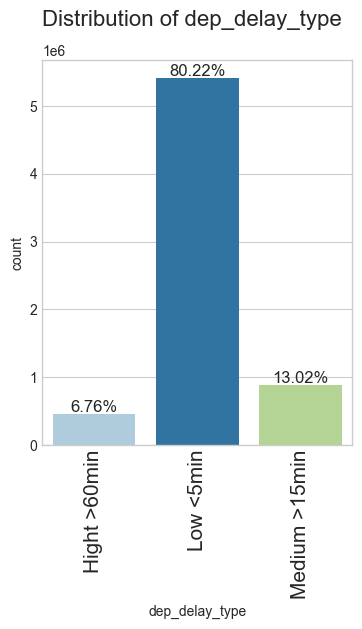

8/9 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/cat_arr_delay_type.png - N. of Features: 3


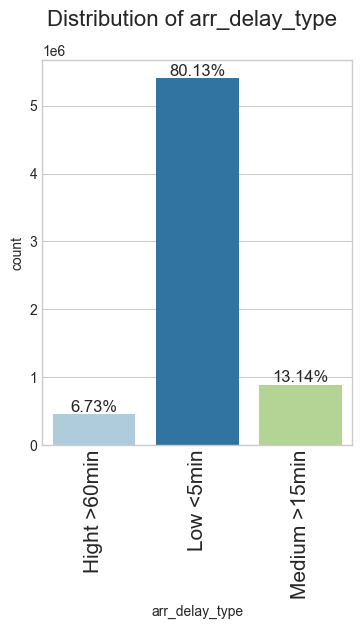

9/9 ✅ Saved: ./df-full_mod-full_ff/eda_graphs/cat_dep_time_label.png - N. of Features: 4


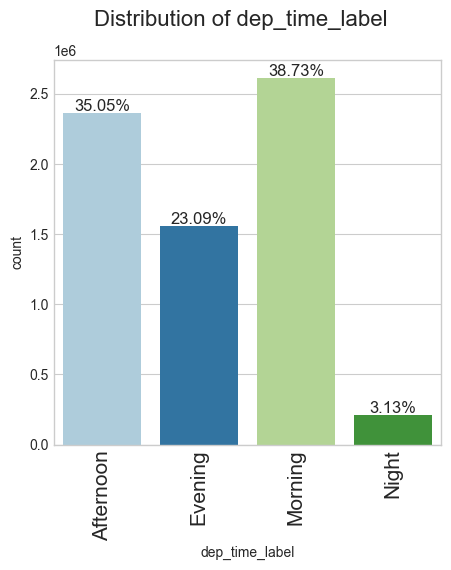

In [49]:
if EDA != 'eda_no':
    n_nc = len(cat_col_mini)
    for n, var in enumerate(cat_col_mini, start=1):
        labeled_barplot(n, n_nc, data_cleaned, var, perc=True)

✅ Saved: ./df-full_mod-full_ff/eda_graphs/cat_feature_arr.png


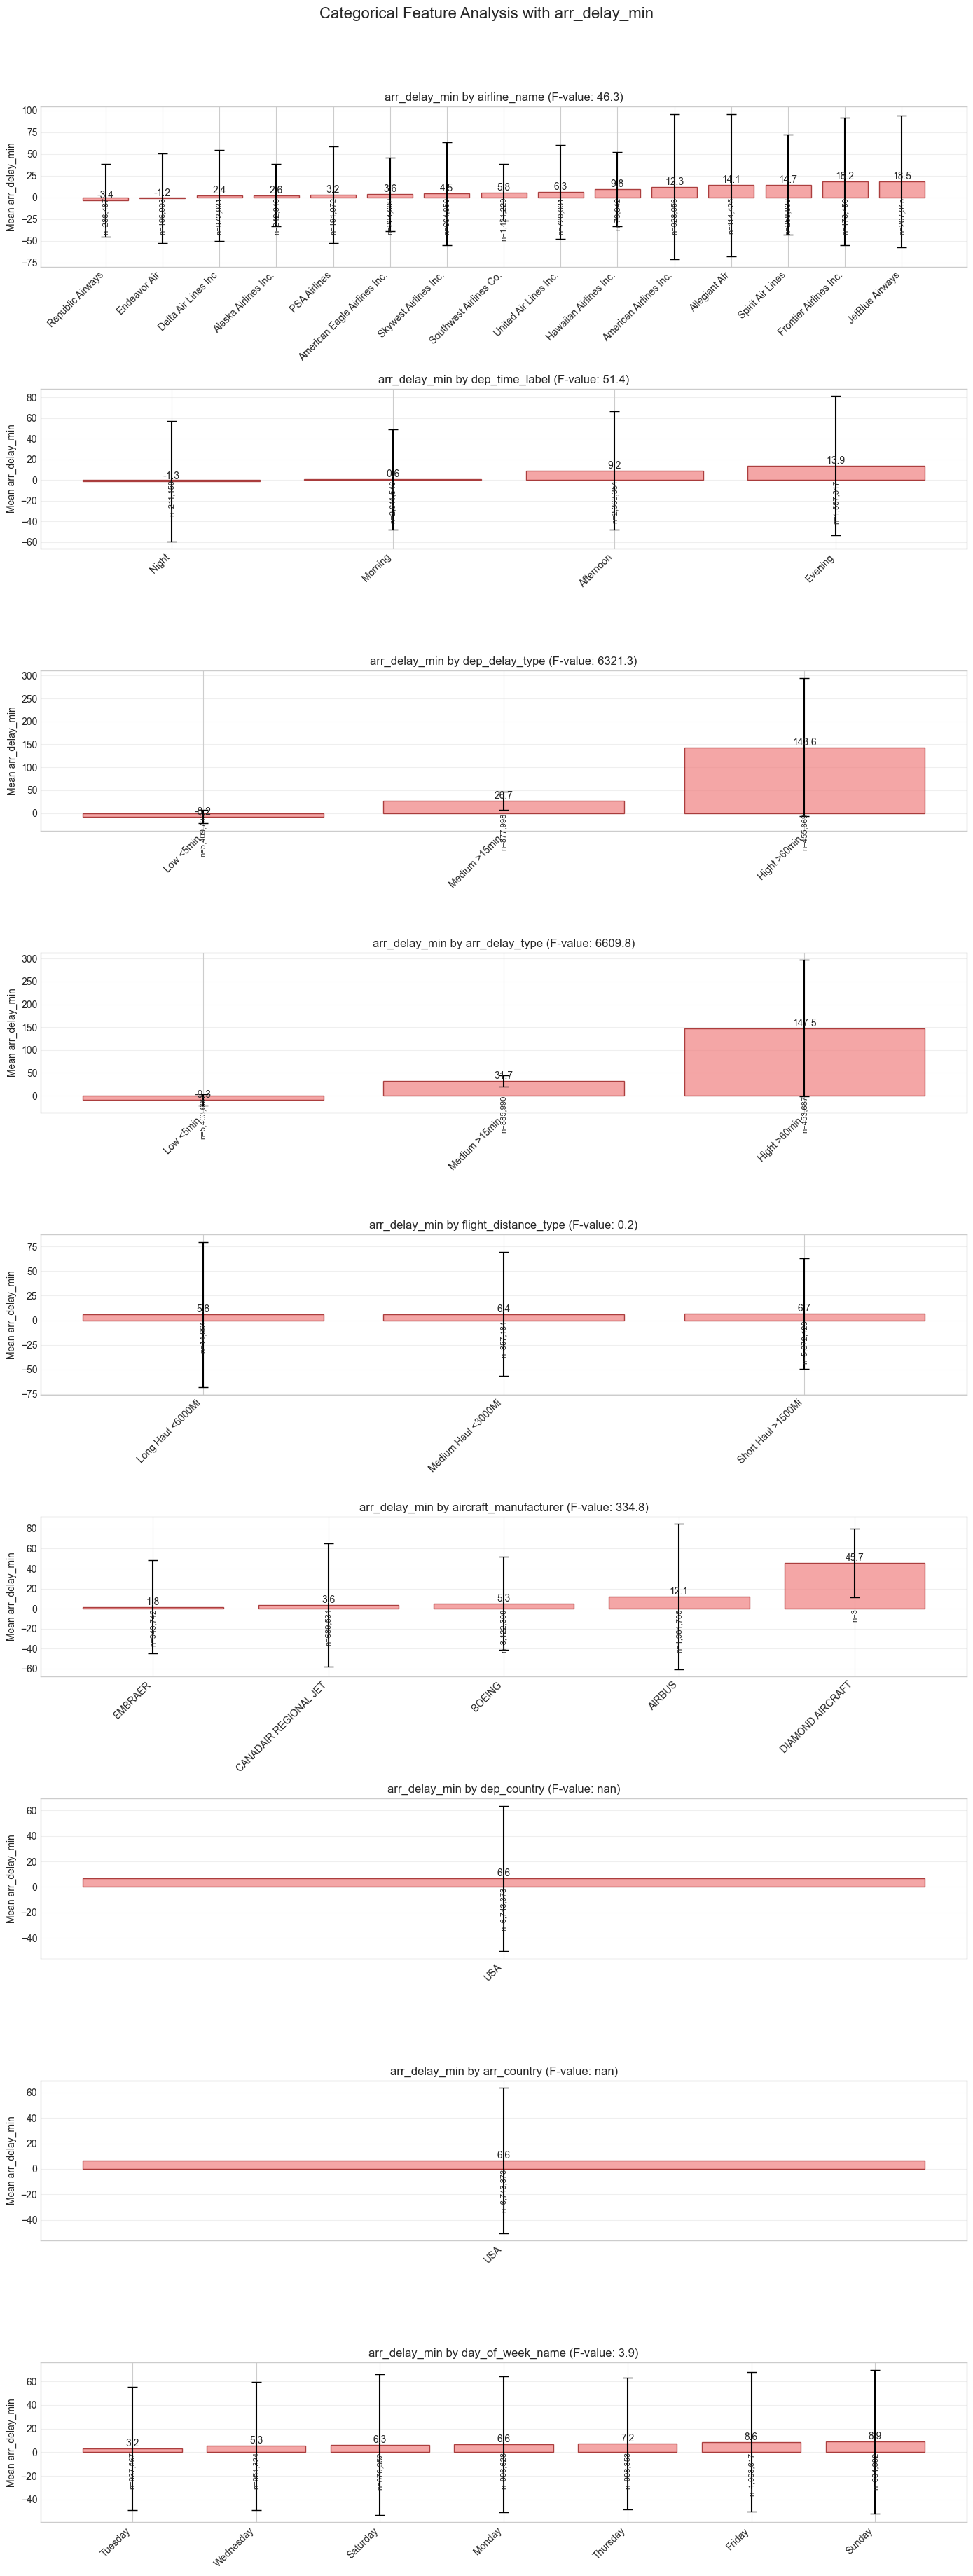

In [50]:
# Analyze categorical features
if EDA != 'eda_no':
    categorical_cols = data_cleaned.select_dtypes(include=['object', 'category']).columns.tolist()

    # Select categoricals with reasonable cardinality
    cat_features = [col for col in categorical_cols if data_cleaned[col].nunique() <= 20]

    target="arr_delay_min"

    if cat_features:
        # Calculate mean delay by category (ANOVA-like)
        fig, axes = plt.subplots(len(cat_features), 1, figsize=(14, 4*len(cat_features)))
        if len(cat_features) == 1:
            axes = [axes]
        
        for idx, feature in enumerate(cat_features):
            ax = axes[idx]
            
            # Calculate statistics
            stats_df = data_cleaned.groupby(feature)[target].agg(['mean', 'std', 'count']).sort_values('mean')
            
            # Create bar plot
            bars = ax.bar(range(len(stats_df)), stats_df['mean'], 
                        yerr=stats_df['std'], capsize=5,
                        color='lightcoral', edgecolor='darkred', alpha=0.7)
            
            ax.set_xticks(range(len(stats_df)))
            ax.set_xticklabels(stats_df.index, rotation=45, ha='right')
            ax.set_ylabel(f'Mean {target}')
            ax.set_title(f'{target} by {feature} (F-value: {stats_df["mean"].var():.1f})')
            ax.grid(True, alpha=0.3, axis='y')
            
            # Add value labels
            for i, (mean_val, count) in enumerate(zip(stats_df['mean'], stats_df['count'])):
                ax.text(i, mean_val, f'{mean_val:.1f}', ha='center', va='bottom')
                ax.text(i, 0, f'n={int(count):,}', ha='center', va='top', 
                    fontsize=8, rotation=90)
        
        plt.suptitle(f'Categorical Feature Analysis with {target}', fontsize=16, y=1.02)
        plt.tight_layout()
        eda_fn = 'cat_feature_arr.png'
        plt.savefig(DIR_eda + eda_fn, 
                    dpi=300, 
                    bbox_inches='tight')
        print(f"✅ Saved: {DIR_eda}{eda_fn}")
        plt.show()

✅ Saved: ./df-full_mod-full_ff/eda_graphs/corre_network_arr.png


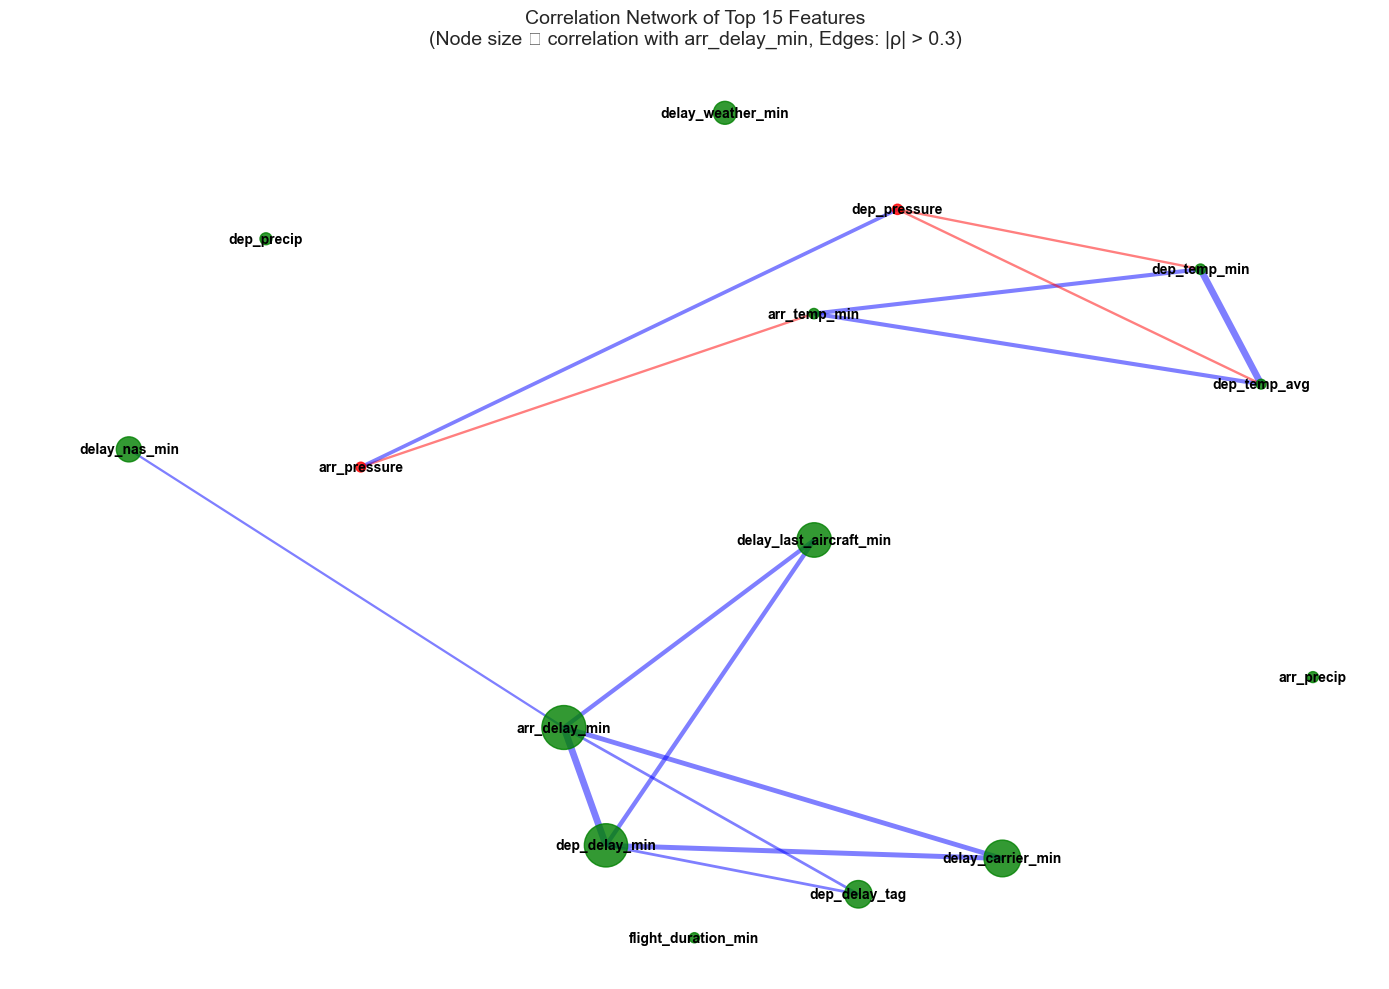

In [51]:
# Create correlation network for top features
if EDA != 'eda_no':
    top_n = 15
    top_features = corr_with_target_arr.abs().sort_values(ascending=False).head(top_n).index.tolist()

    # Create correlation matrix for top features
    top_corr = data_cleaned[top_features].corr()

    # Create graph
    G = nx.Graph()

    # Add nodes
    for feature in top_features:
        G.add_node(feature, size=abs(corr_with_target_arr[feature])*1000)

    # Add edges (only strong correlations)
    threshold = 0.3
    for i in range(len(top_features)):
        for j in range(i+1, len(top_features)):
            corr_value = top_corr.iloc[i, j]
            if abs(corr_value) > threshold:
                G.add_edge(top_features[i], top_features[j], 
                        weight=abs(corr_value)*5,
                        color='red' if corr_value < 0 else 'blue')

    # Plot network
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=2, iterations=50)

    # Node sizes based on correlation with target
    node_sizes = [G.nodes[node]['size'] for node in G.nodes()]
    node_colors = ['green' if corr_with_target_arr[node] > 0 else 'red' for node in G.nodes()]

    # Draw graph
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, 
                        node_color=node_colors, alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=[G[u][v]['weight'] for u, v in G.edges()],
                        edge_color=[G[u][v]['color'] for u, v in G.edges()],
                        alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    plt.title(f'Correlation Network of Top {top_n} Features\n'
            f'(Node size ∝ correlation with {target}, '
            f'Edges: |ρ| > {threshold})', fontsize=14, pad=20)
    plt.axis('off')
    plt.tight_layout()
    eda_fn = 'corre_network_arr.png'
    plt.savefig(DIR_eda + eda_fn, 
                dpi=300, 
                bbox_inches='tight')
    print(f"✅ Saved: {DIR_eda}{eda_fn}")
    plt.show()


📊 CORRELATION ANALYSIS
✅ Correlation matrix created: 32 x 32
✅ Saved: ./df-full_mod-full_ff/eda_graphs/corre_full_matrix.png


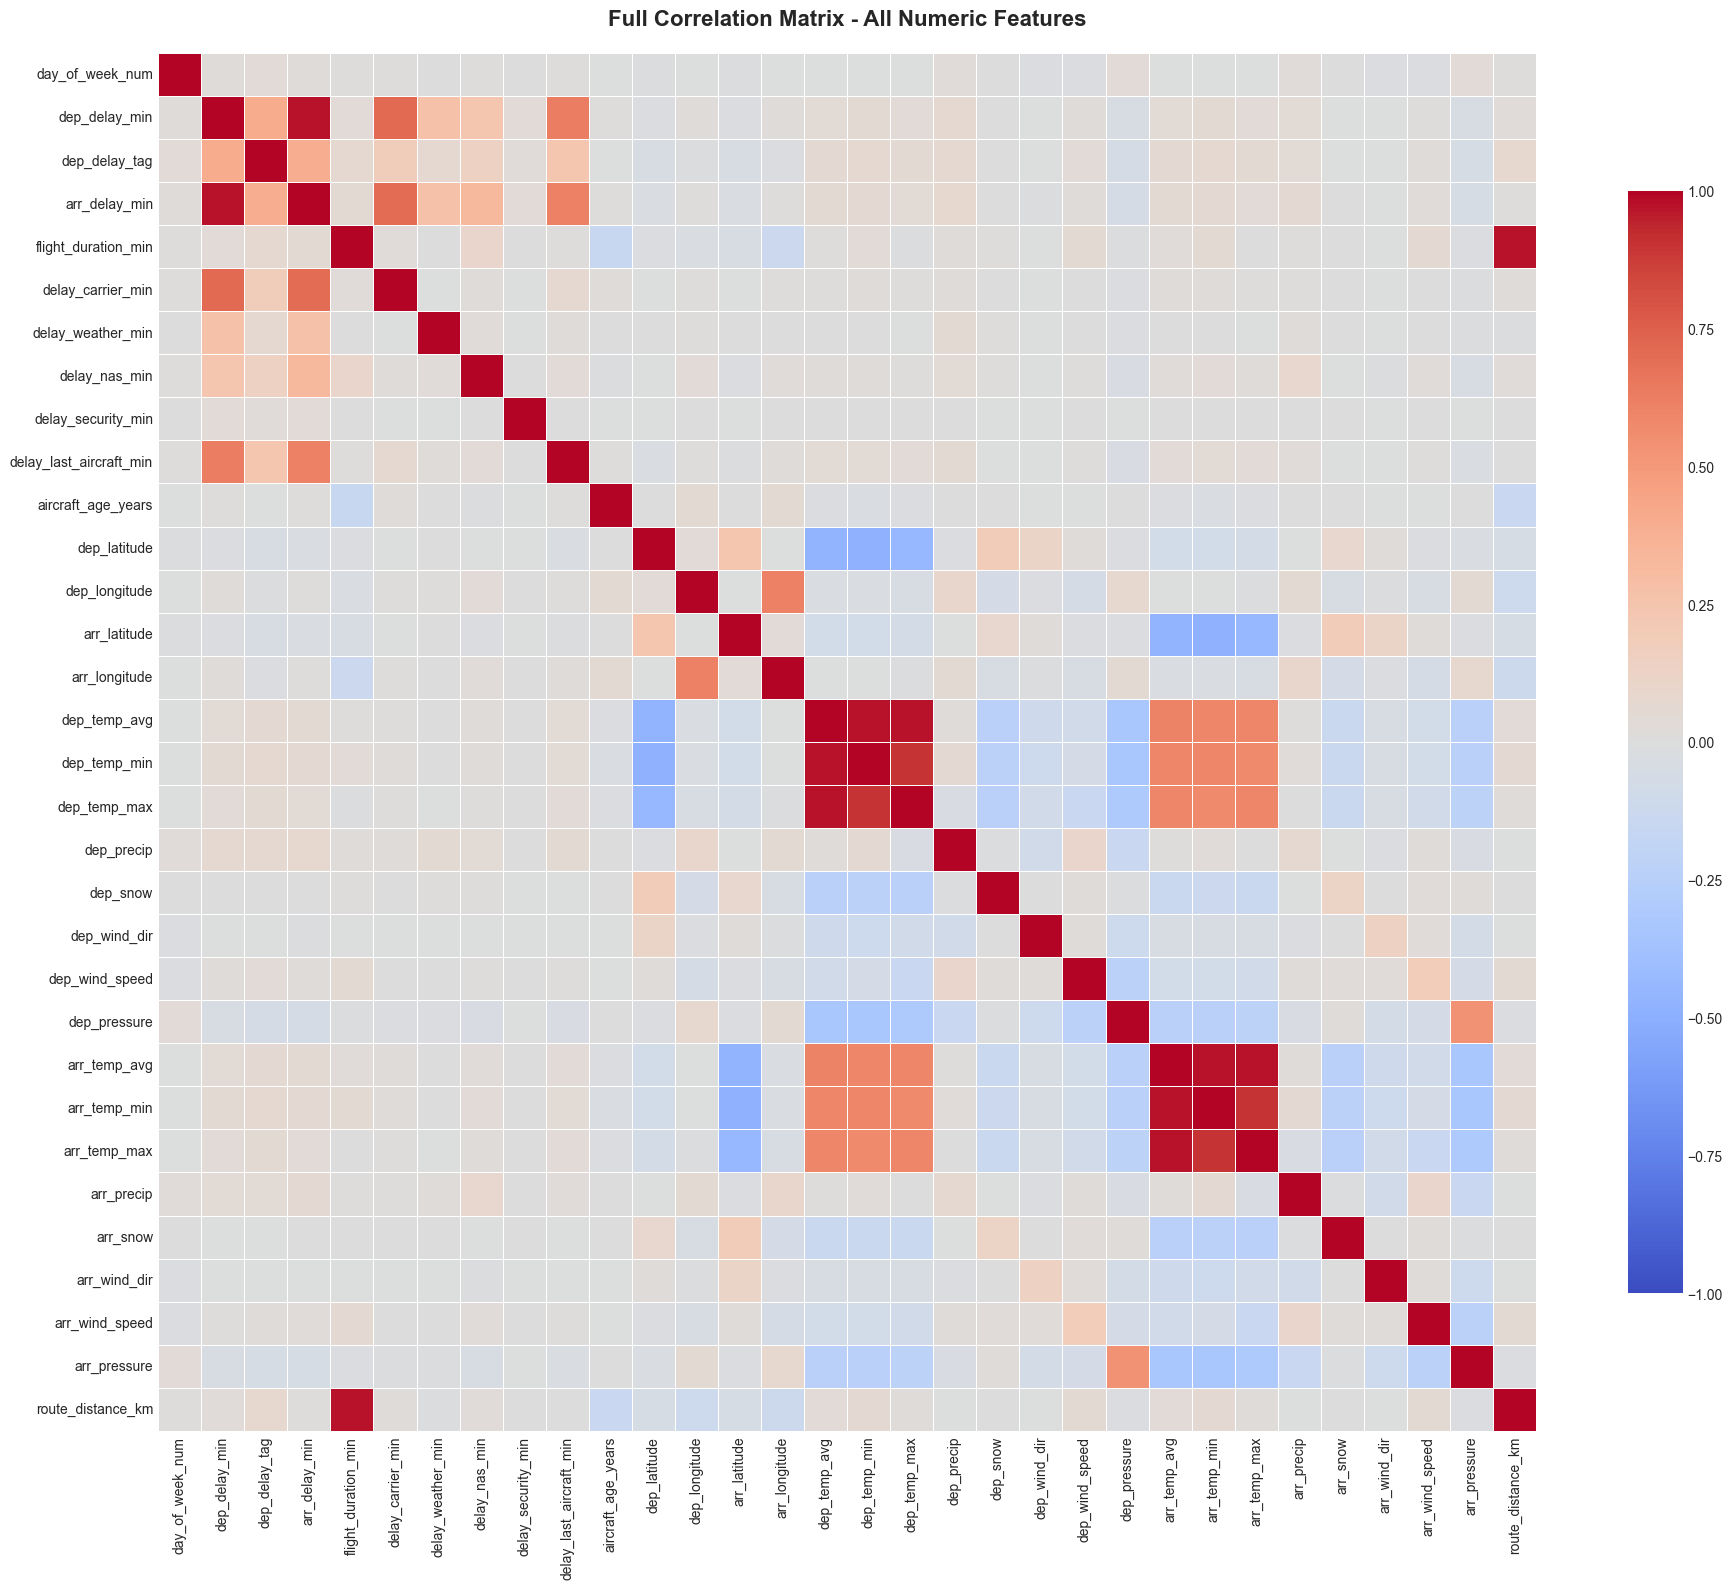


📈 Features Correlated with Delays:
                Feature  Dep_Delay_Corr  Arr_Delay_Corr  Avg_Corr
          dep_delay_min        1.000000        0.970570  0.985285
          arr_delay_min        0.970570        1.000000  0.985285
      delay_carrier_min        0.715287        0.698334  0.706810
delay_last_aircraft_min        0.630675        0.615877  0.623276
          dep_delay_tag        0.399728        0.392045  0.395887
✅ Saved: ./df-full_mod-full_ff/eda_graphs/corre_dep_arr.png


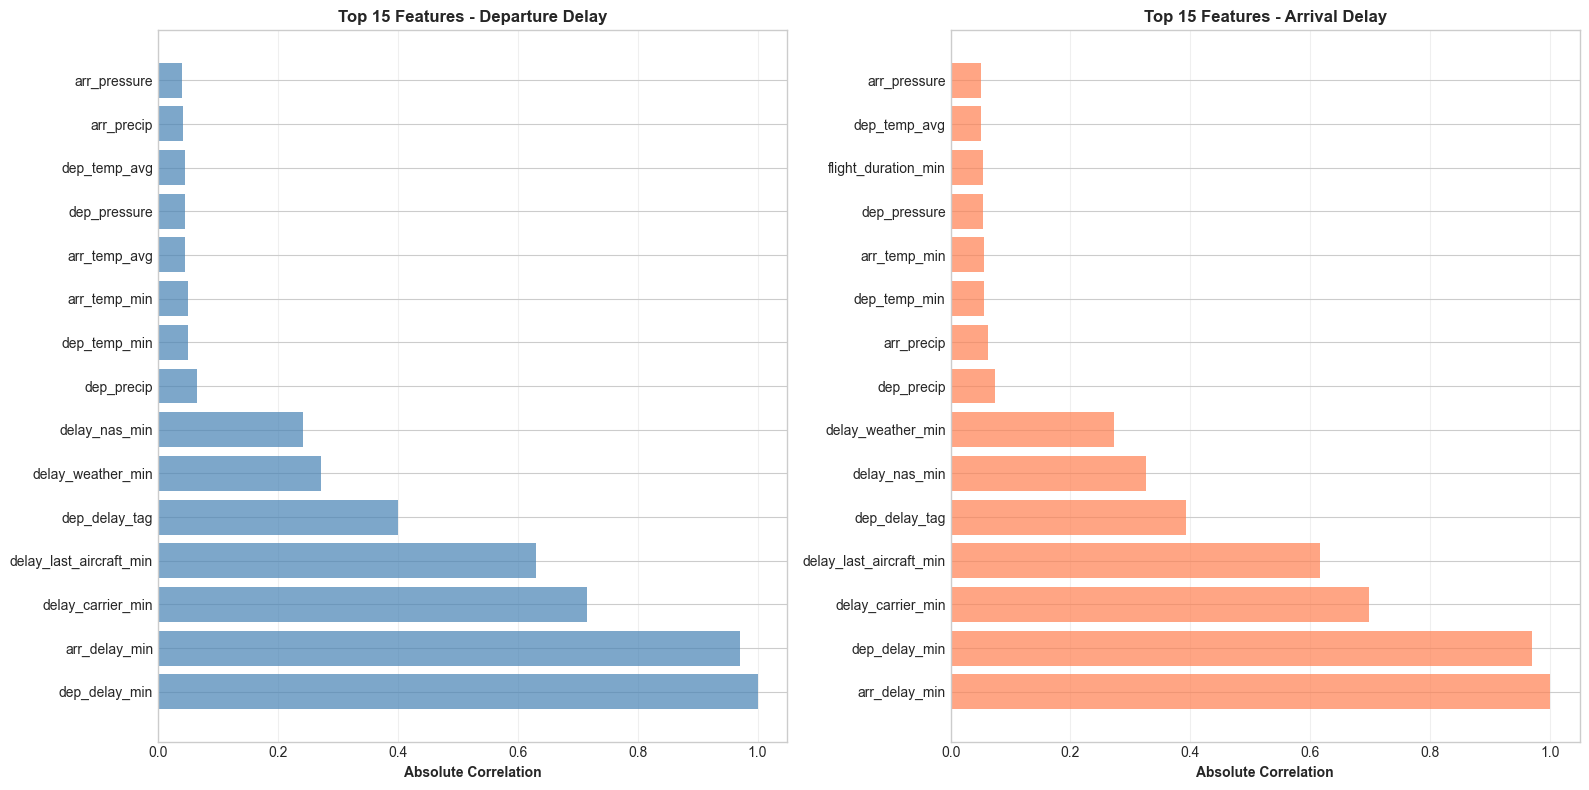

✅ Saved: ./df-full_mod-full_ff/eda_graphs/corre_weather_matrix.png


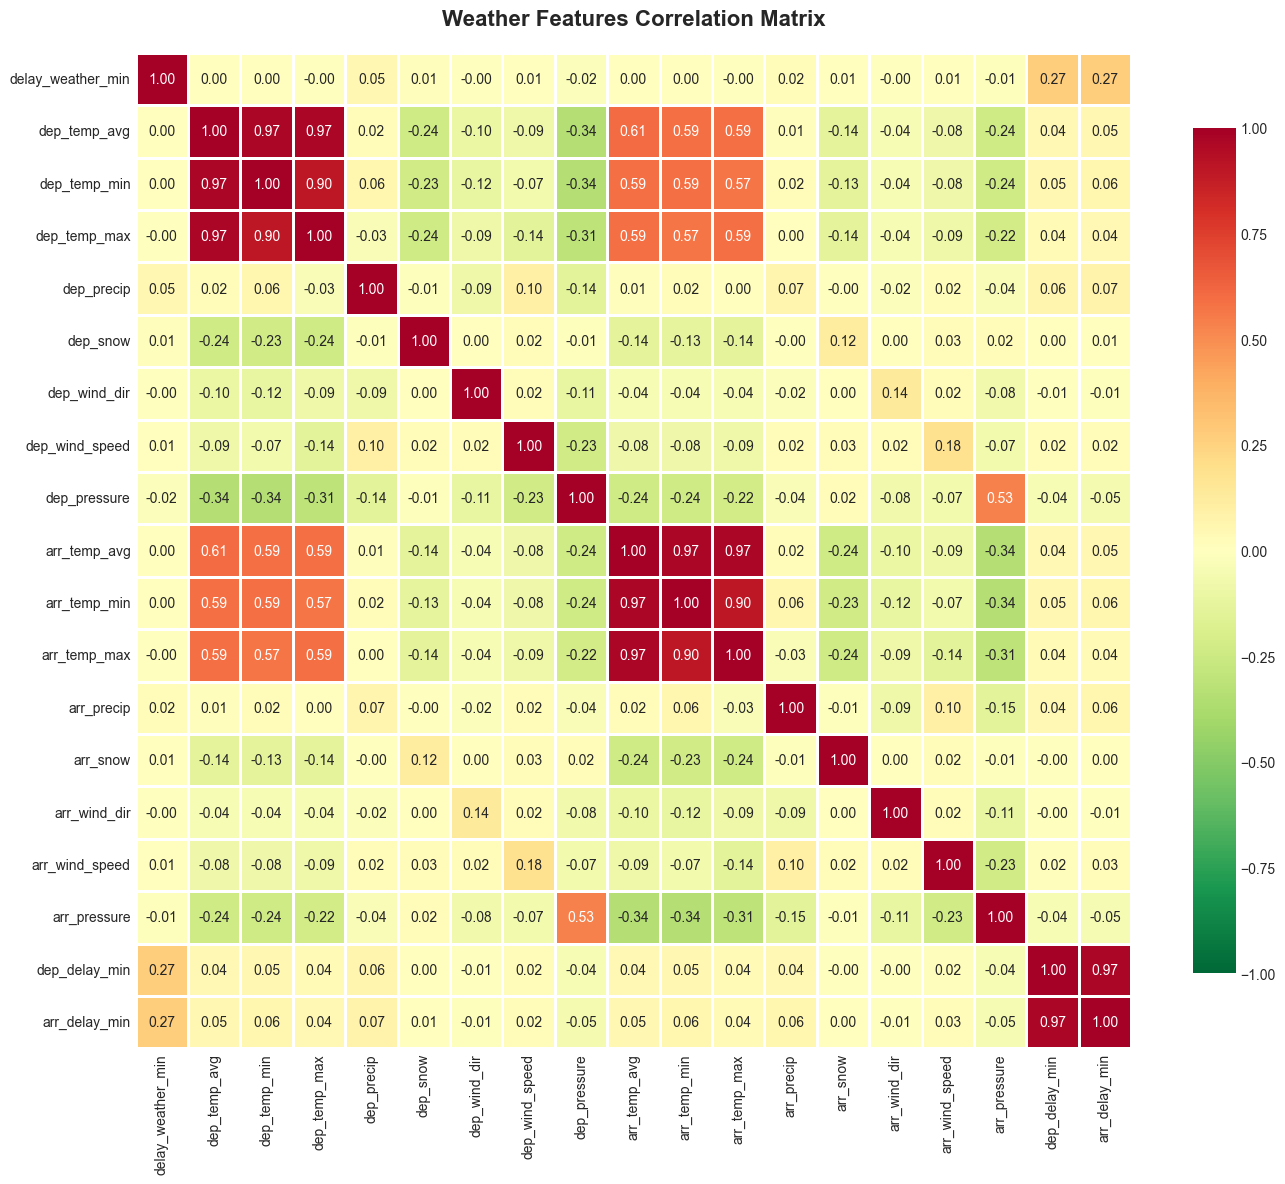


🌦️ Weather Features Correlation with Delays:
                   dep_delay_min  arr_delay_min
delay_weather_min       0.271576       0.272736
dep_precip              0.064223       0.073981
dep_temp_min            0.049205       0.055873
arr_temp_min            0.049056       0.055405
arr_temp_avg            0.044276       0.048777
dep_pressure            0.044264       0.054752
dep_temp_avg            0.044054       0.050214
arr_precip              0.041680       0.062414
arr_pressure            0.039733       0.049889
arr_temp_max            0.037009       0.038496
✅ Saved: ./df-full_mod-full_ff/eda_graphs/corre_delay_matrix.png


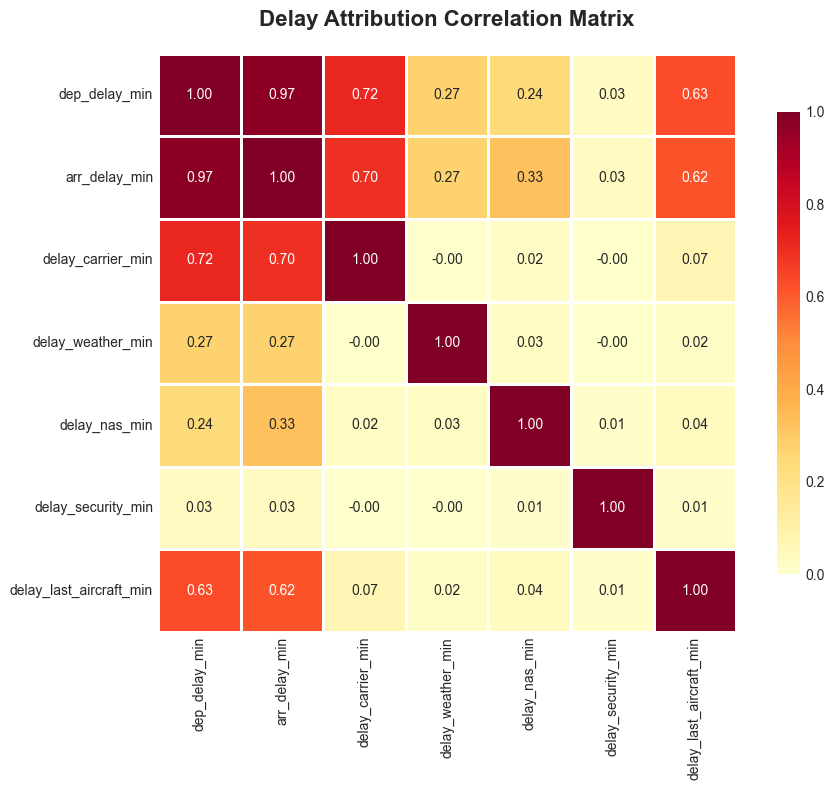


⚠️ Checking for Multicollinearity (|correlation| > 0.9):
          Feature_1         Feature_2  Correlation
      dep_delay_min     arr_delay_min     0.970570
       dep_temp_avg      dep_temp_min     0.970464
       arr_temp_avg      arr_temp_min     0.970464
       dep_temp_avg      dep_temp_max     0.969538
       arr_temp_avg      arr_temp_max     0.969535
flight_duration_min route_distance_km     0.968828
       dep_temp_min      dep_temp_max     0.903398
       arr_temp_min      arr_temp_max     0.903376

⚠️ Found 8 highly correlated pairs
💡 Consider removing one feature from each pair to reduce redundancy
✅ Saved: ./df-full_mod-full_ff/eda_graphs/corre_feature_network.png


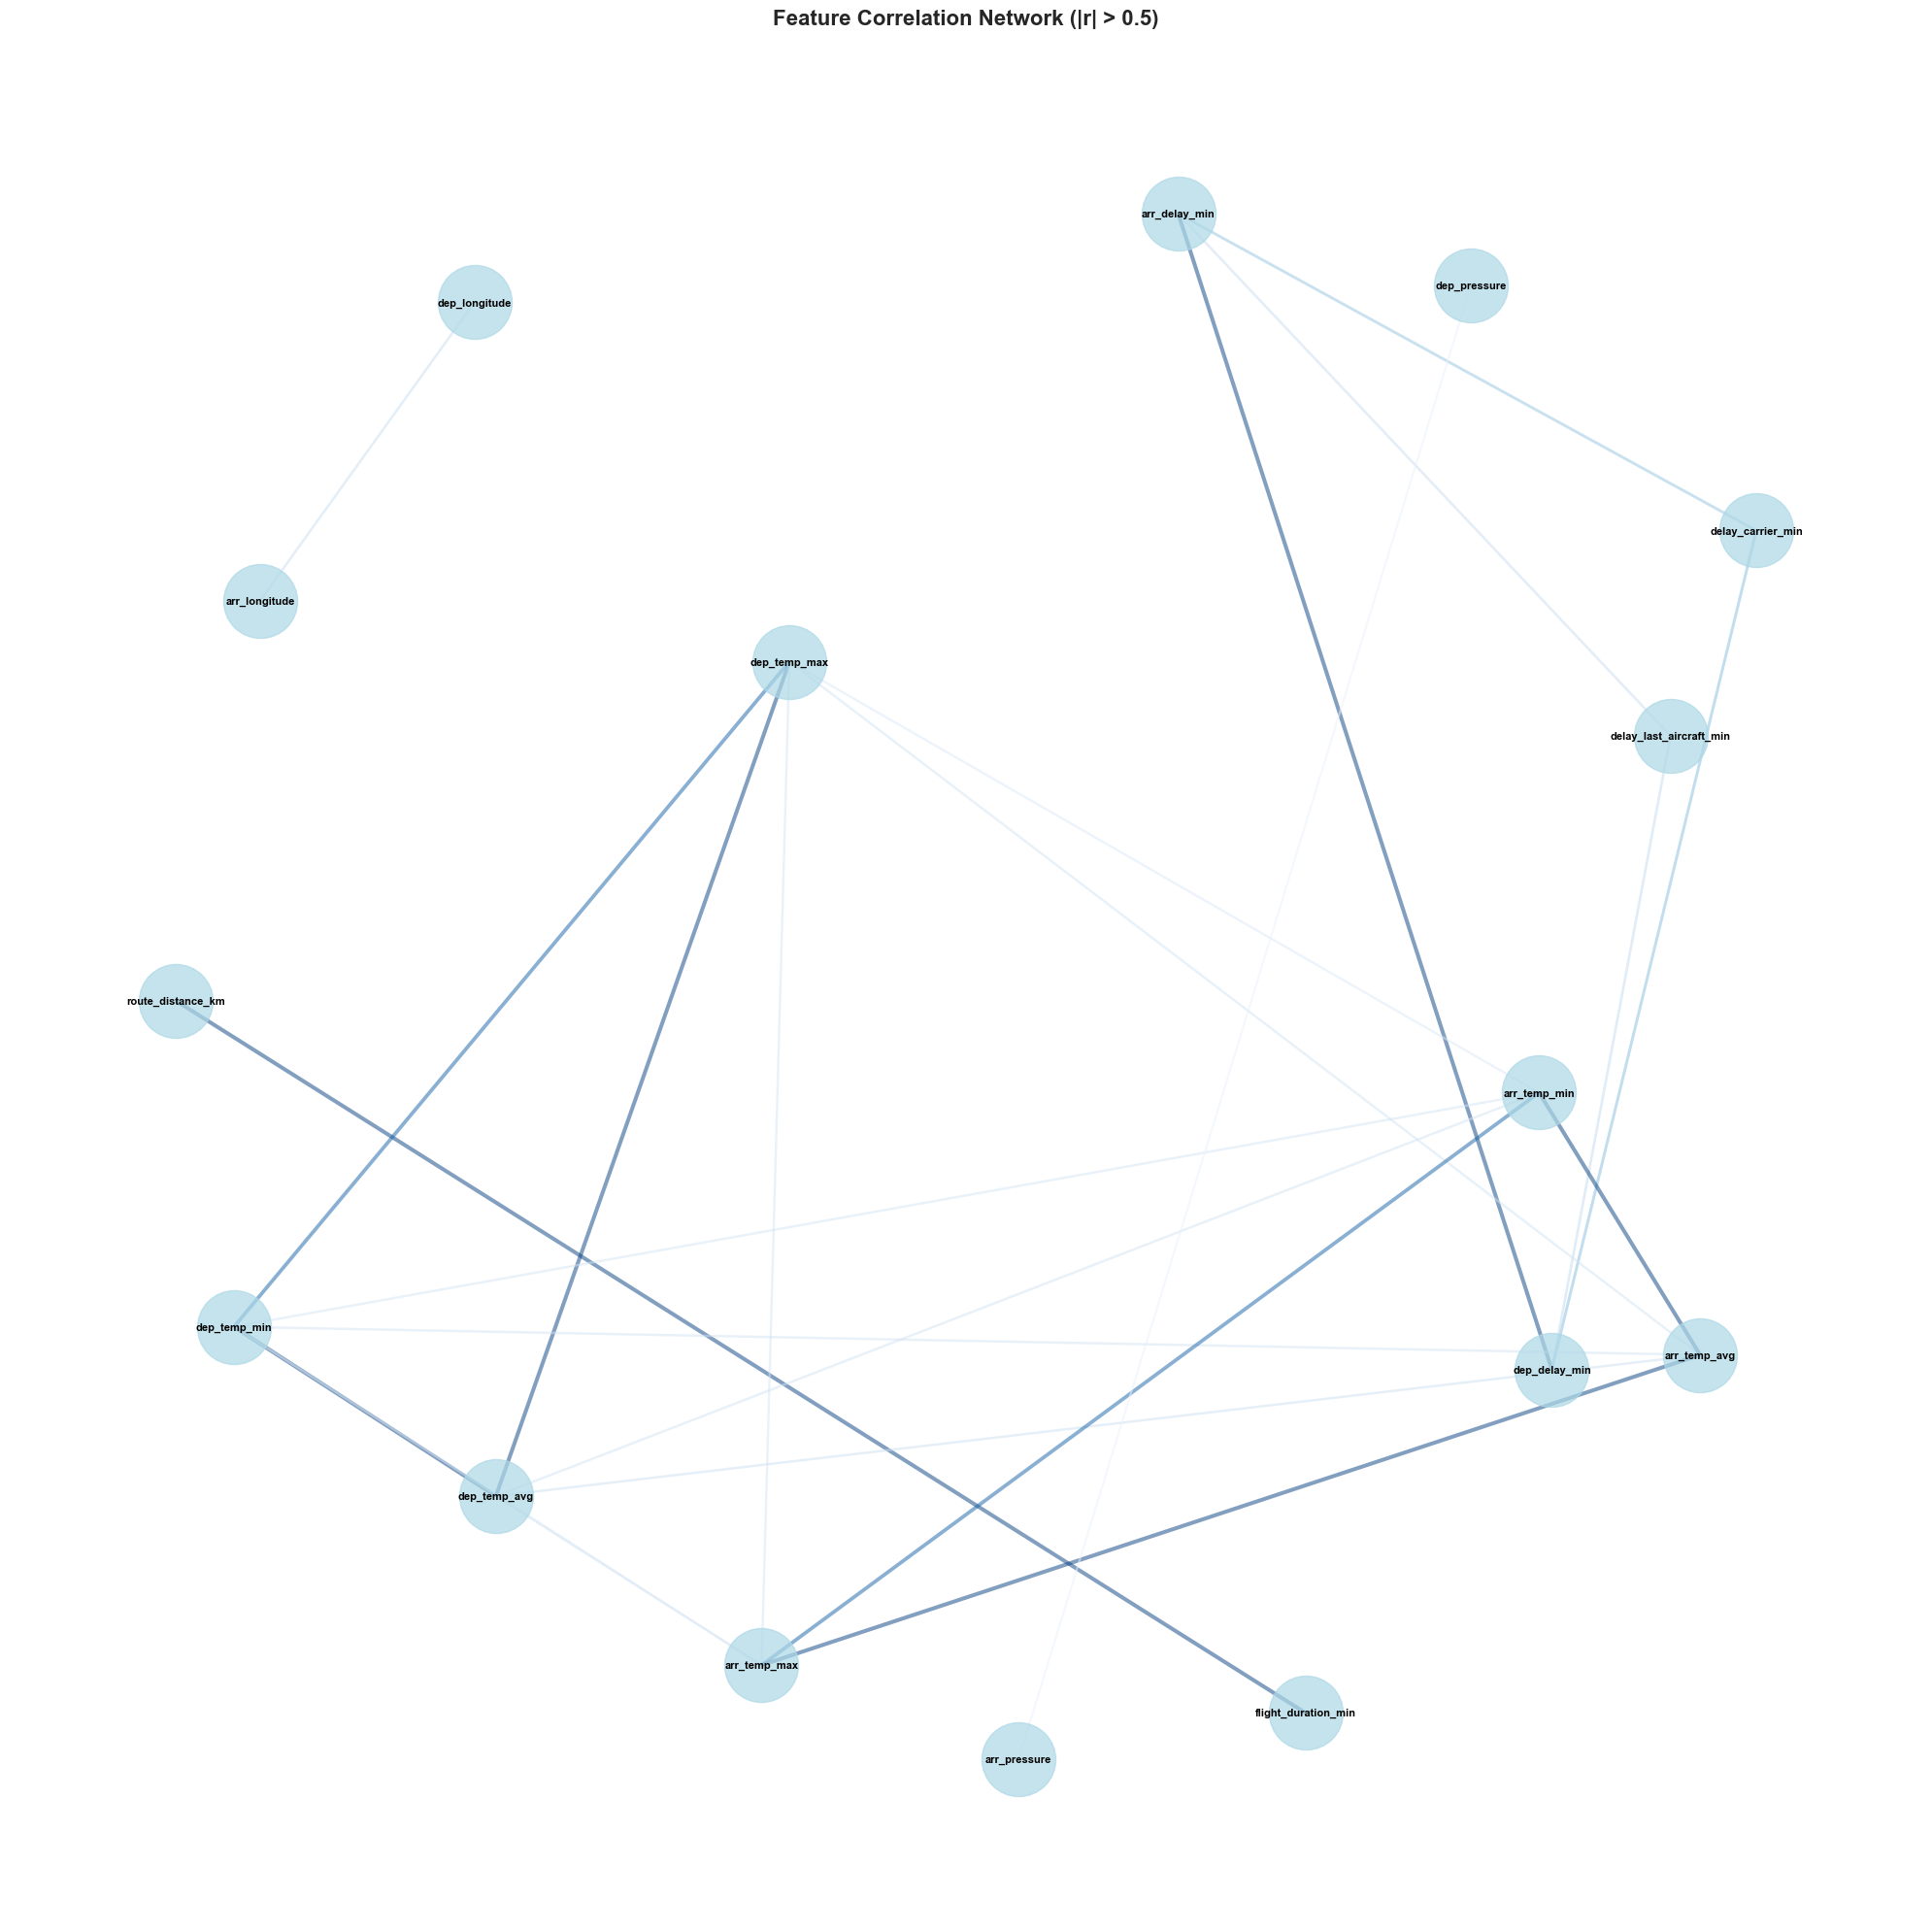

✅ Saved: ./df-full_mod-full_ff/mod_csv/_correlation_matrix_ff.csv
✅ Saved: ./df-full_mod-full_ff/mod_csv/_target_correlations_ff.csv

✅ CORRELATION ANALYSIS COMPLETE


In [52]:
# ============================================================================
# 9 CORRELATION ANALYSIS
# ============================================================================
if EDA != 'eda_no':
    print("\n" + "="*60)
    print("📊 CORRELATION ANALYSIS")
    print("="*60)

    # Select numeric columns only
    numeric_cols = data_cleaned.select_dtypes(include=[np.number]).columns.tolist()

    # Create correlation matrix
    correlation_matrix = data_cleaned[numeric_cols].corr()

    print(f"✅ Correlation matrix created: {correlation_matrix.shape[0]} x {correlation_matrix.shape[1]}")

    # ============================================================================
    # OPTION 1: FULL CORRELATION HEATMAP (All Features)
    # ============================================================================

    plt.figure(figsize=(20, 16))
    sns.heatmap(correlation_matrix, 
                annot=False,  # Set to True to see values
                cmap='coolwarm',
                center=0,
                vmin=-1, 
                vmax=1,
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8})
    plt.title('Full Correlation Matrix - All Numeric Features', 
            fontsize=16, 
            fontweight='bold',
            pad=20)
    plt.tight_layout()
    eda_fn = 'corre_full_matrix.png'
    plt.savefig(DIR_eda + eda_fn, 
                dpi=300, 
                bbox_inches='tight')
    print(f"✅ Saved: {DIR_eda}{eda_fn}")
    plt.show()
    plt.close()

    # ============================================================================
    # OPTION 2: CORRELATION WITH TARGET VARIABLES (Most Important)
    # ============================================================================

    # Focus on correlations with delay variables
    target_correlations = pd.DataFrame({'Feature': correlation_matrix.index,
                                        'Dep_Delay_Corr': correlation_matrix['dep_delay_min'].abs(),
                                        'Arr_Delay_Corr': correlation_matrix['arr_delay_min'].abs()})

    # Sort by average correlation with both targets
    target_correlations['Avg_Corr'] = (target_correlations['Dep_Delay_Corr'] + 
                                    target_correlations['Arr_Delay_Corr']) / 2

    target_correlations = target_correlations.sort_values('Avg_Corr', ascending=False)

    # Display correlated features
    print("\n📈 Features Correlated with Delays:")
    print(target_correlations.head().to_string(index=False))

    # Visualize top correlations
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Departure delay correlations
    top_dep = target_correlations.nlargest(15, 'Dep_Delay_Corr')
    axes[0].barh(top_dep['Feature'], 
                top_dep['Dep_Delay_Corr'],
                color='steelblue',
                alpha=0.7)
    axes[0].set_xlabel('Absolute Correlation', fontweight='bold')
    axes[0].set_title('Top 15 Features - Departure Delay', fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)

    # Arrival delay correlations
    top_arr = target_correlations.nlargest(15, 'Arr_Delay_Corr')
    axes[1].barh(top_arr['Feature'], 
                top_arr['Arr_Delay_Corr'],
                color='coral',
                alpha=0.7)
    axes[1].set_xlabel('Absolute Correlation', fontweight='bold')
    axes[1].set_title('Top 15 Features - Arrival Delay', fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    eda_fn = 'corre_dep_arr.png'
    plt.savefig(DIR_eda + eda_fn, 
                dpi=300, 
                bbox_inches='tight')
    print(f"✅ Saved: {DIR_eda}{eda_fn}")
    plt.show()
    plt.close()

    # ============================================================================
    # OPTION 3: WEATHER FEATURES CORRELATION
    # ============================================================================

    # weather-related columns
    weather_cols = [col for col in numeric_cols if any(x in col.lower() 
                    for x in ['temp', 'precip', 'snow', 'wind', 'pressure', 'weather'])]

    # delay columns for context
    weather_delay_cols = weather_cols + ['dep_delay_min', 'arr_delay_min']
    weather_delay_cols = [col for col in weather_delay_cols if col in data_cleaned.columns]

    if len(weather_delay_cols) > 2:  # Only if we have weather data
        weather_corr = data_cleaned[weather_delay_cols].corr()
        
        plt.figure(figsize=(14, 12))
        sns.heatmap(weather_corr,
                    annot = True,
                    fmt = '.2f',
                    cmap = 'RdYlGn_r',
                    center = 0,
                    vmin = -1,
                    vmax = 1,
                    square = True,
                    linewidths = 1,
                    cbar_kws = {"shrink": 0.8})
        
        plt.title('Weather Features Correlation Matrix', 
                fontsize=16, 
                fontweight='bold',
                pad=20)
        
        plt.tight_layout()
        
        eda_fn = 'corre_weather_matrix.png'
        plt.savefig(DIR_eda + eda_fn, 
                    dpi=300, 
                    bbox_inches='tight')
        print(f"✅ Saved: {DIR_eda}{eda_fn}")
        
        plt.show()
        plt.close()
        
        # Print weather correlations with delays
        print("\n🌦️ Weather Features Correlation with Delays:")
        weather_delay_corr = weather_corr[['dep_delay_min',
                                        'arr_delay_min']].drop(['dep_delay_min',
                                                                'arr_delay_min'], 
                                                                errors='ignore').abs().sort_values('dep_delay_min',
                                                                                                    ascending=False)
        print(weather_delay_corr.head(10))

    # ============================================================================
    # OPTION 4: DELAY ATTRIBUTION CORRELATION (Understanding Delay Causes)
    # ============================================================================

    delay_cols = ['dep_delay_min', 'arr_delay_min', 
                'delay_carrier_min', 'delay_weather_min', 
                'delay_nas_min', 'delay_security_min', 
                'delay_last_aircraft_min']

    delay_cols = [col for col in delay_cols if col in data_cleaned.columns]

    if len(delay_cols) > 2:
        delay_corr = data_cleaned[delay_cols].corr()
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(delay_corr,
                    annot=True,
                    fmt='.2f',
                    cmap='YlOrRd',
                    vmin=0,
                    vmax=1,
                    square=True,
                    linewidths=2,
                    cbar_kws={"shrink": 0.8})
        plt.title('Delay Attribution Correlation Matrix', 
                fontsize=16, 
                fontweight='bold',
                pad=20)
        plt.tight_layout()
        eda_fn = 'corre_delay_matrix.png'
        plt.savefig(DIR_eda + eda_fn, 
                    dpi=300, 
                    bbox_inches='tight')
        print(f"✅ Saved: {DIR_eda}{eda_fn}")
        plt.show()
        plt.close()

    # ============================================================================
    # OPTION 5: MULTICOLLINEARITY DETECTION (For Feature Selection)
    # ============================================================================

    print("\n⚠️ Checking for Multicollinearity (|correlation| > 0.9):")

    # Find highly correlated feature pairs
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.9:
                high_corr_pairs.append({'Feature_1':   correlation_matrix.columns[i],
                                        'Feature_2':   correlation_matrix.columns[j],
                                        'Correlation': correlation_matrix.iloc[i, j]})

    if high_corr_pairs:
        df_high_corr = pd.DataFrame(high_corr_pairs).sort_values('Correlation', 
                                                                key=abs, 
                                                                ascending=False)
        print(df_high_corr.to_string(index=False))
        print(f"\n⚠️ Found {len(high_corr_pairs)} highly correlated pairs")
        print("💡 Consider removing one feature from each pair to reduce redundancy")
    else:
        print("✅ No severe multicollinearity detected (all |r| < 0.9)")

    # ============================================================================
    # OPTION 6: CORRELATION NETWORK GRAPH (Advanced Visualization)
    # ============================================================================

    # Create network of strong correlations
    threshold = 0.5  # Only show correlations > 0.5

    # Get strong correlations
    strong_corr = correlation_matrix.copy().astype(float)  # Ensure it's float for NaN assignment
    strong_corr = strong_corr.where((abs(strong_corr) > threshold) & (strong_corr != 1.0))

    # Create graph
    G = nx.Graph()

    # Add edges for strong correlations
    for i in range(len(strong_corr.columns)):
        for j in range(i+1, len(strong_corr.columns)):
            val = strong_corr.iloc[i, j]
            if pd.notna(strong_corr.iloc[i, j]):
                G.add_edge(strong_corr.columns[i],
                        strong_corr.columns[j],
                        weight=float(np.asarray(val, dtype=np.float64)))

    if len(G.edges()) > 0:
        plt.figure(figsize=(20, 20))
        
        # Position nodes using spring layout
        pos = nx.spring_layout(G,
                            k = 2,
                            iterations = 50)
        
        # Draw nodes
        nx.draw_networkx_nodes(G,
                            pos, 
                            node_color = 'lightblue',
                            node_size = 3000,
                            alpha = 0.7)
        
        # Draw edges with width based on correlation strength
        edges = list(G.edges())
        weights = [G[u][v]['weight'] for u, v in edges]
        nx.draw_networkx_edges(G,
                            pos,
                            width = [w*3 for w in weights],
                            alpha = 0.5,
                            edge_color = weights,
                            edge_cmap = plt.colormaps['Blues'],
                            edge_vmin = threshold,
                            edge_vmax = 1.0)
        
        # Draw labels
        nx.draw_networkx_labels(G,
                                pos, 
                                font_size = 8,
                                font_weight = 'bold')
        
        plt.title(f'Feature Correlation Network (|r| > {threshold})', 
                fontsize = 16, 
                fontweight = 'bold',
                pad = 20)
        
        plt.axis('off')
        plt.tight_layout()
        eda_fn = 'corre_feature_network.png'
        plt.savefig(DIR_eda + eda_fn, 
                    dpi=300, 
                    bbox_inches='tight')
        print(f"✅ Saved: {DIR_eda}{eda_fn}")
        plt.show()
        plt.close()

    # ============================================================================
    # SAVE CORRELATION DATA
    # ============================================================================

    # Save full correlation matrix as CSV
    correlation_matrix.to_csv(DIR_csv + '_correlation_matrix_' + MODEL_MAP + '.csv')
    print(f"✅ Saved: {DIR_csv}_correlation_matrix_{MODEL_MAP}.csv")

    # Save target correlations
    target_correlations.to_csv(DIR_csv + '_target_correlations_' + MODEL_MAP + '.csv', index=False)
    print(f"✅ Saved: {DIR_csv}_target_correlations_{MODEL_MAP}.csv")

    print("\n" + "="*60)
    print("✅ CORRELATION ANALYSIS COMPLETE")
    print("="*60)

In [53]:
# ============================================================================
# 15.0 ANALIZAR RETRASOS CERCANOS A CERO
# ============================================================================
df_clean = data_cleaned.dropna(subset=['dep_delay_min', 'arr_delay_min'])
if EDA != 'eda_no':

    print("\n" + "="*60)
    print("✈️ ANÁLISIS DE VUELOS CON RETRASO CERCANO A CERO")
    print("="*60)

    # Para retraso de salida
    dep_delay_zero = df_clean['dep_delay_min']

    print("\n🛫 DEPARTURE DELAY (dep_delay_min):")
    print(f"Total de vuelos: {len(dep_delay_zero):,}")

    # Diferentes umbrales
    for threshold in [0, 0.5, 1, 2, 5, 10, 15]:
        count = (dep_delay_zero <= threshold).sum()
        percentage = (count / len(dep_delay_zero)) * 100
        print(f"  • Retraso ≤ {threshold:>4} min: {count:8,} vuelos ({percentage:4.2f}%)")

    print("\n🛬 ARRIVAL DELAY (arr_delay_min):")
    arr_delay_zero = df_clean['arr_delay_min']

    for threshold in [0, 0.5, 1, 2, 5, 10, 15]:
        count = (arr_delay_zero <= threshold).sum()
        percentage = (count / len(arr_delay_zero)) * 100
        print(f"  • Retraso ≤ {threshold:>4} min: {count:8,} vuelos ({percentage:4.2f}%)")


✈️ ANÁLISIS DE VUELOS CON RETRASO CERCANO A CERO

🛫 DEPARTURE DELAY (dep_delay_min):
Total de vuelos: 6,743,373
  • Retraso ≤    0 min: 4,187,616 vuelos (62.10%)
  • Retraso ≤  0.5 min: 4,187,616 vuelos (62.10%)
  • Retraso ≤    1 min: 4,339,857 vuelos (64.36%)
  • Retraso ≤    2 min: 4,467,106 vuelos (66.24%)
  • Retraso ≤    5 min: 4,776,873 vuelos (70.84%)
  • Retraso ≤   10 min: 5,147,762 vuelos (76.34%)
  • Retraso ≤   15 min: 5,409,706 vuelos (80.22%)

🛬 ARRIVAL DELAY (arr_delay_min):
  • Retraso ≤    0 min: 4,270,845 vuelos (63.33%)
  • Retraso ≤  0.5 min: 4,270,845 vuelos (63.33%)
  • Retraso ≤    1 min: 4,385,031 vuelos (65.03%)
  • Retraso ≤    2 min: 4,492,833 vuelos (66.63%)
  • Retraso ≤    5 min: 4,776,134 vuelos (70.83%)
  • Retraso ≤   10 min: 5,138,649 vuelos (76.20%)
  • Retraso ≤   15 min: 5,403,696 vuelos (80.13%)


✅ Saved: ./df-full_mod-full_ff/eda_graphs/delay_distribution_near_zero.png


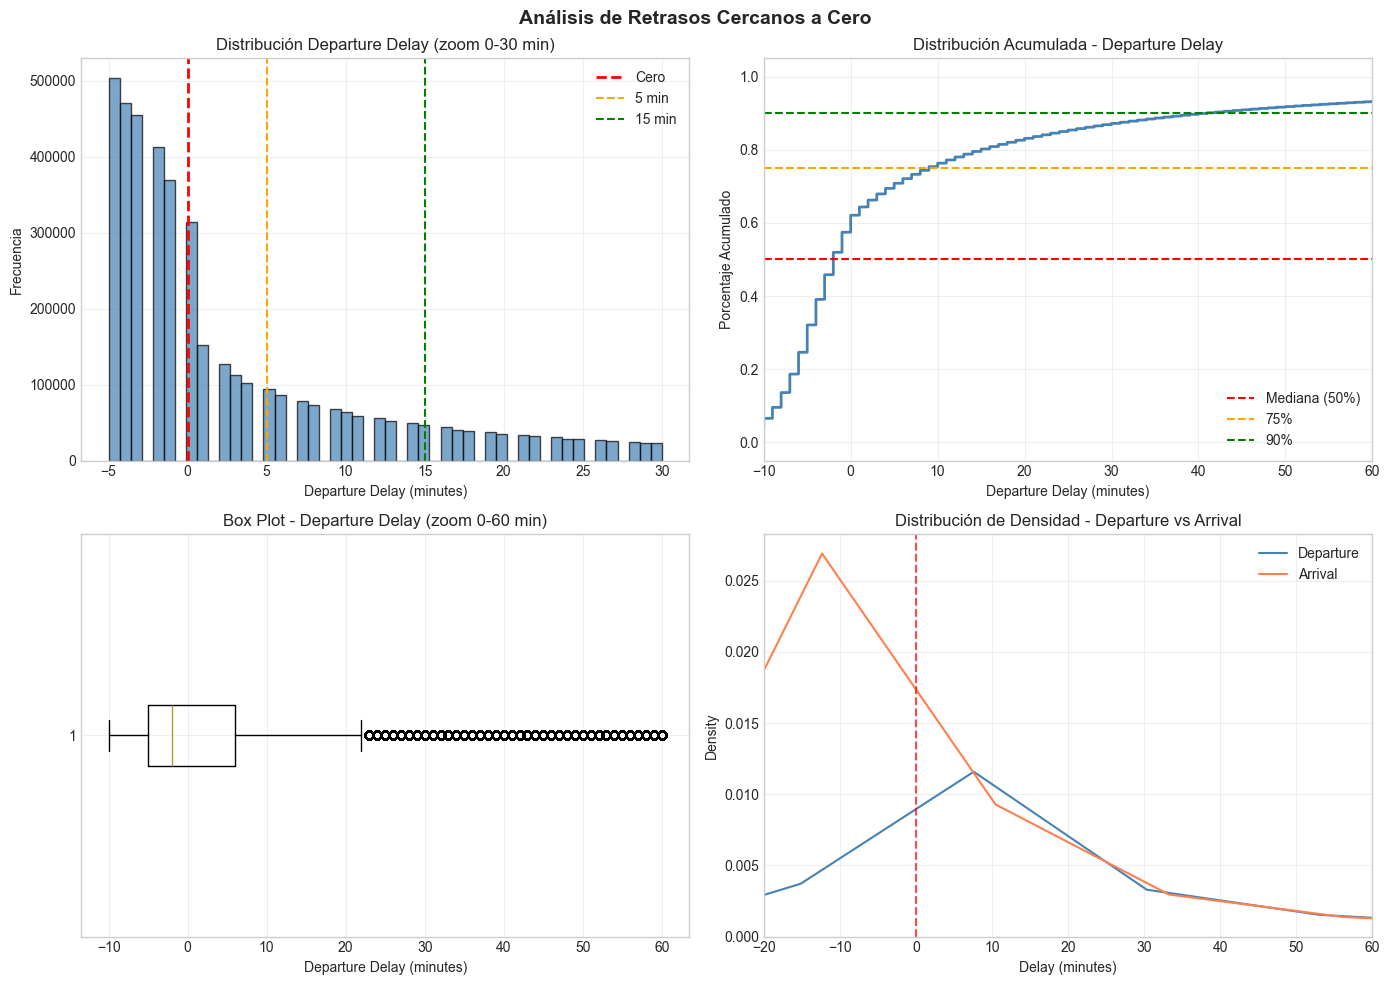

In [54]:
# ============================================================================
# 15.1 VISUALIZAR LA CONCENTRACIÓN CERCA DE CERO
# ============================================================================
if EDA != 'eda_no':
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Análisis de Retrasos Cercanos a Cero', fontsize=14, fontweight='bold')

    # 1. Histograma zoom al rango [-5, 30] minutos
    ax1 = axes[0, 0]
    dep_delay_zero = df_clean['dep_delay_min']
    dep_delay_zero = dep_delay_zero[(dep_delay_zero >= -5) & (dep_delay_zero <= 30)]
    ax1.hist(dep_delay_zero, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.axvline(x=0,  color='red',    linestyle='--', linewidth=2,   label='Cero')
    ax1.axvline(x=5,  color='orange', linestyle='--', linewidth=1.5, label='5 min')
    ax1.axvline(x=15, color='green',  linestyle='--', linewidth=1.5, label='15 min')
    ax1.set_xlabel('Departure Delay (minutes)')
    ax1.set_ylabel('Frecuencia')
    ax1.set_title('Distribución Departure Delay (zoom 0-30 min)')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # 2. Histograma acumulativo
    ax2 = axes[0, 1]
    dep_cumsum = df_clean['dep_delay_min'].sort_values()
    cumulative = np.arange(1, len(dep_cumsum)+1) / len(dep_cumsum)
    ax2.plot(dep_cumsum, cumulative, color='steelblue', linewidth=2)
    ax2.axhline(y=0.5,  color='red',    linestyle='--', label='Mediana (50%)')
    ax2.axhline(y=0.75, color='orange', linestyle='--', label='75%')
    ax2.axhline(y=0.9,  color='green',  linestyle='--', label='90%')
    ax2.set_xlabel('Departure Delay (minutes)')
    ax2.set_ylabel('Porcentaje Acumulado')
    ax2.set_title('Distribución Acumulada - Departure Delay')
    ax2.set_xlim([-10, 60])
    ax2.legend()
    ax2.grid(alpha=0.3)

    # 3. Box plot enfocado
    ax3 = axes[1, 0]
    dep_data = df_clean['dep_delay_min']
    dep_data_clipped = dep_data[(dep_data >= -10) & (dep_data <= 60)]
    ax3.boxplot(dep_data_clipped, vert=False)
    ax3.set_xlabel('Departure Delay (minutes)')
    ax3.set_title('Box Plot - Departure Delay (zoom 0-60 min)')
    ax3.grid(alpha=0.3)

    # 4. KDE plot comparativo
    ax4 = axes[1, 1]
    sns.kdeplot(data=df_clean, x='dep_delay_min', label='Departure', color='steelblue', ax=ax4)
    sns.kdeplot(data=df_clean, x='arr_delay_min', label='Arrival', color='coral', ax=ax4)
    ax4.set_xlim([-20, 60])
    ax4.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    ax4.set_xlabel('Delay (minutes)')
    ax4.set_title('Distribución de Densidad - Departure vs Arrival')
    ax4.legend()
    ax4.grid(alpha=0.3)

    plt.tight_layout()
    eda_fn = 'delay_distribution_near_zero.png'
    plt.savefig(DIR_eda + eda_fn, 
                dpi=300, 
                bbox_inches='tight')
    print(f"✅ Saved: {DIR_eda}{eda_fn}")
    plt.show()

## Graph 1: Histogram (Top Left)
Key Observations:
- PEAK at 0 minutes (massive spike)
- 2nd peak around -5 to -10 minutes (early departures)
- Rapid drop-off after 5 minutes
- Very few flights between 15-30 minutes
- Distribution is HIGHLY concentrated near zero
Problem Identified: Your model is averaging the extreme right tail with the zero peak. It's trying to find a "middle ground" but the distribution isn't normal - it's zero-inflated.

## Graph 2: Cumulative Distribution (Top Right)
Critical Numbers:
- 50% of flights (median) are at ≈ 0 minutes ✓
- 75% of flights are at ≈ 10 minutes 
- 90% of flights are at ≈ 30 minutes
Mathematical Reality:
- 50% of your data is 0-1 minute
- The other 50% spans 1 to 500+ minutes
- A regression model trained on MAE will predict: ~10-15 minutes
- Why? Because minimizing MAE on this distribution gives you the median, which is around 10-15 minutes, NOT the mode (0 minutes).

## Graph 3: Box Plot (Bottom Left)
Visual Evidence:
- Median line at ≈ 0 ✓
- Box (25-75 percentile): -5 to +10 minutes
- Whiskers extend to ±30 minutes
- MANY outliers beyond 60 minutes
The Problem is Clear:
- Your model sees 50% zeros, 50% positive delays
- To minimize error, it picks a value between them
- With MAE optimization, that's the median (~10-15 min)
- Your model is statistically correct for MAE but operationally wrong

## Graph 4: Density Plot (Bottom Right)
Shows the bimodal distribution clearly:
1. Massive peak at 0 (on-time/early)
2. Long, flat tail of delayed flights

# The Mathematical Proof
# Why MAE fails here:
# Your data distribution (simplified):
- delays = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 15, 20, 25, 30, 45, 60, 90, 120]

# Predict 0 minutes:
- errors = [0,0,0,0,0,0,0,0,0,0, 15,20,25,30,45,60,90,120]
- MAE = (0*10 + 15+20+25+30+45+60+90+120) / 18 = 405/18 = 22.5

# Predict 15 minutes:
- errors = [15,15,15,... (10 times), 0,5,10,15,30,45,75,105]
- MAE = (15*10 + 0+5+10+15+30+45+75+105) / 18 = (150 + 285)/18 = 435/18 = 24.2

# Predict 10 minutes (optimal for this skewed data):
- errors = [10,10,... (10 times), 5,10,15,20,35,50,80,110]
- MAE = (10*10 + 5+10+15+20+35+50+80+110) = (100 + 325)/18 = 425/18 = 23.6

- Your model is doing exactly what you asked it to do - minimize MAE. It's just that MAE is the wrong objective for zero-inflated data.

## Why This Matters for Airlines
Operational Impact:
- False Positives: Predicting 15-min delay on flights that will be on-time
- Unnecessary gate changes
- Wrong passenger notifications
- Missed connection warnings that don't happen
- Missed True Delays: Your model underestimates severe delays
- When it predicts 25 min, actual could be 60+ min
- The long tail of severe delays is being averaged down

In [55]:
# ============================================================================
# 15.2 ESTADÍSTICAS DE VUELOS PUNTUALES
# ============================================================================
if EDA != 'eda_no':
    print("\n" + "="*60)
    print("📊 ESTADÍSTICAS DE VUELOS PUNTUALES (≤ 5 min retraso)")
    print("="*60)

    # Definir "puntual" como retraso ≤ 5 minutos
    puntual_dep = df_clean['dep_delay_min'] <= 5
    puntual_arr = df_clean['arr_delay_min'] <= 5

    print(f"\n🛫 DEPARTURE - Vuelos puntuales (≤5 min):")
    print(f"  • Cantidad........................... {puntual_dep.sum():,} vuelos")
    print(f"  • Porcentaje......................... {puntual_dep.mean()*100:.1f}% del total")
    print(f"  • Retraso promedio en estos vuelos... {df_clean.loc[puntual_dep, 'dep_delay_min'].mean():.2f} min")
    print(f"  • Mediana............................ {df_clean.loc[puntual_dep, 'dep_delay_min'].median():.2f} min")

    print(f"\n🛬 ARRIVAL - Vuelos puntuales (≤5 min):")
    print(f"  • Cantidad........................... {puntual_arr.sum():,} vuelos")
    print(f"  • Porcentaje......................... {puntual_arr.mean()*100:.1f}% del total")
    print(f"  • Retraso promedio en estos vuelos... {df_clean.loc[puntual_arr, 'arr_delay_min'].mean():.2f} min")
    print(f"  • Mediana............................ {df_clean.loc[puntual_arr, 'arr_delay_min'].median():.2f} min")

    # Análisis de vuelos EXACTAMENTE a tiempo (0 min)
    exactos_dep = df_clean['dep_delay_min'] == 0
    exactos_arr = df_clean['arr_delay_min'] == 0

    print(f"\n🎯 VUELOS EXACTAMENTE A TIEMPO (0 min):")
    print(f"  • Departure: {exactos_dep.sum():,} vuelos ({exactos_dep.mean()*100:.2f}%)")
    print(f"  • Arrival:   {exactos_arr.sum():,} vuelos ({exactos_arr.mean()*100:.2f}%)")

    # Vuelos con retraso NEGATIVO (llegan antes)
    negativos_dep = df_clean['dep_delay_min'] < 0
    negativos_arr = df_clean['arr_delay_min'] < 0

    print(f"\n⏱️  VUELOS CON RETRASO NEGATIVO (anticipados):")

    print(f"  • Departure............... {negativos_dep.sum():,} vuelos ({negativos_dep.mean()*100:.1f}%)")
    print(f"    Promedio anticipación... {abs(df_clean.loc[negativos_dep, 'dep_delay_min'].mean()):.1f} min")

    print(f"  • Arrival................. {negativos_arr.sum():,} vuelos ({negativos_arr.mean()*100:.1f}%)")
    print(f"    Promedio anticipación... {abs(df_clean.loc[negativos_arr, 'arr_delay_min'].mean()):.1f} min")


📊 ESTADÍSTICAS DE VUELOS PUNTUALES (≤ 5 min retraso)

🛫 DEPARTURE - Vuelos puntuales (≤5 min):
  • Cantidad........................... 4,776,873 vuelos
  • Porcentaje......................... 70.8% del total
  • Retraso promedio en estos vuelos... -4.04 min
  • Mediana............................ -4.00 min

🛬 ARRIVAL - Vuelos puntuales (≤5 min):
  • Cantidad........................... 4,776,134 vuelos
  • Porcentaje......................... 70.8% del total
  • Retraso promedio en estos vuelos... -11.84 min
  • Mediana............................ -11.00 min

🎯 VUELOS EXACTAMENTE A TIEMPO (0 min):
  • Departure: 314,586 vuelos (4.67%)
  • Arrival:   124,753 vuelos (1.85%)

⏱️  VUELOS CON RETRASO NEGATIVO (anticipados):
  • Departure............... 3,873,030 vuelos (57.4%)
    Promedio anticipación... 5.4 min
  • Arrival................. 4,146,092 vuelos (61.5%)
    Promedio anticipación... 14.0 min


In [56]:
# ============================================================================
# 15.3 TABLA DE DISTRIBUCIÓN POR RANGOS DE RETRASO
# ============================================================================
if EDA != 'eda_no':
    print("\n" + "="*80)
    print("📋 DISTRIBUCIÓN DE RETRASOS POR RANGOS")
    print("="*80)

    # Definir rangos
    bins = [-float('inf'), -1, 0, 1, 2, 5, 10, 15, 30, 60, float('inf')]
    labels = ['<0 (anticipado)', '0', '1', '2', '3-5', '6-10', '11-15', '16-30', '31-60', '>60']

    print(f"\n{'Rango (min)':<20} {'Departure':>15} {'%':>8} {'Arrival':>15} {'%':>8}")
    print("-" * 70)

    for i, label in enumerate(labels):
        if label == '<0 (anticipado)':
            dep_count = (df_clean['dep_delay_min'] < 0).sum()
            arr_count = (df_clean['arr_delay_min'] < 0).sum()
        elif label == '0':
            dep_count = (df_clean['dep_delay_min'] == 0).sum()
            arr_count = (df_clean['arr_delay_min'] == 0).sum()
        else:
            lower = bins[i]
            upper = bins[i+1]
            dep_count = ((df_clean['dep_delay_min'] > lower if lower > -float('inf') else True) & 
                        (df_clean['dep_delay_min'] <= upper)).sum()
            arr_count = ((df_clean['arr_delay_min'] > lower if lower > -float('inf') else True) & 
                        (df_clean['arr_delay_min'] <= upper)).sum()
        
        dep_pct = (dep_count / len(df_clean)) * 100
        arr_pct = (arr_count / len(df_clean)) * 100
        
        print(f"{label:<20} {dep_count:>13,} {dep_pct:>7.1f}% {arr_count:>13,} {arr_pct:>7.1f}%")

    # Total
    print("-" * 70)
    print(f"{'TOTAL':<20} {len(df_clean):>13,} {100:>7.1f}% {len(df_clean):>13,} {100:>7.1f}%")


📋 DISTRIBUCIÓN DE RETRASOS POR RANGOS

Rango (min)                Departure        %         Arrival        %
----------------------------------------------------------------------
<0 (anticipado)          3,873,030    57.4%     4,146,092    61.5%
0                          314,586     4.7%       124,753     1.9%
1                          152,241     2.3%       114,186     1.7%
2                          127,249     1.9%       107,802     1.6%
3-5                        309,767     4.6%       283,301     4.2%
6-10                       370,889     5.5%       362,515     5.4%
11-15                      261,944     3.9%       265,047     3.9%
16-30                      471,466     7.0%       479,715     7.1%
31-60                      406,532     6.0%       406,275     6.0%
>60                        455,669     6.8%       453,687     6.7%
----------------------------------------------------------------------
TOTAL                    6,743,373   100.0%     6,743,373   100.0%


In [57]:
# ============================================================================
# 15.4 DEMOSTRACIÓN: POR QUÉ MAPE FALLA CON RETRASOS CERO
# ============================================================================
if EDA != 'eda_no':
    print("\n" + "="*60)
    print("⚠️  DEMOSTRACIÓN: EL PROBLEMA DE MAPE CON VALORES CERCANOS A CERO")
    print("="*60)

    # Tomar una muestra de vuelos con retraso pequeño
    muestra = df_clean.sample(10, random_state=42)[['dep_delay_min', 'arr_delay_min']]

    print("\nEjemplo con 10 vuelos aleatorios:")
    print("-" * 60)
    print(f"{'Real':>8} {'Predicho':>10} {'Error':>8} {'MAPE':>10} {'sMAPE':>10}")
    print("-" * 60)

    # Simular predicciones con pequeño error
    np.random.seed(42)
    for _, row in muestra.iterrows():
        real = row['dep_delay_min']
        predicho = real + np.random.normal(0, 2)  # Error aleatorio ±2 min
        
        # Calcular métricas
        error = abs(real - predicho)
        
        # MAPE (problema cuando real=0)
        if real != 0:
            mape = (error / abs(real)) * 100
        else:
            mape = float('inf')
        
        # sMAPE (funciona siempre)
        if real == 0 and predicho == 0:
            smape = 0
        else:
            smape = (2 * error / (abs(real) + abs(predicho))) * 100
        
        print(f"{real:8.1f} {predicho:10.1f} {error:8.1f} {mape:10.1f}% {smape:10.1f}%")

    print("-" * 60)
    print("\n💡 CONCLUSIÓN:")
    print("  • Cuando real = 0, MAPE = ∞ (¡error de división por cero!)")
    print("  • sMAPE funciona perfectamente con valores cero")
    print(f"  • En tu dataset: {exactos_dep.sum():,} vuelos tienen retraso 0")
    print(f"  • Por eso MAPE tradicional NO SIRVE para predicción de retrasos de vuelos")


⚠️  DEMOSTRACIÓN: EL PROBLEMA DE MAPE CON VALORES CERCANOS A CERO

Ejemplo con 10 vuelos aleatorios:
------------------------------------------------------------
    Real   Predicho    Error       MAPE      sMAPE
------------------------------------------------------------
    -2.0       -1.0      1.0       49.7%       66.1%
    11.0       10.7      0.3        2.5%        2.5%
    -5.0       -3.7      1.3       25.9%       29.8%
    23.0       26.0      3.0       13.2%       12.4%
   -11.0      -11.5      0.5        4.3%        4.2%
    -5.0       -5.5      0.5        9.4%        8.9%
    -6.0       -2.8      3.2       52.6%       71.4%
    13.0       14.5      1.5       11.8%       11.1%
    -4.0       -4.9      0.9       23.5%       21.0%
     0.0        1.1      1.1        inf%      200.0%
------------------------------------------------------------

💡 CONCLUSIÓN:
  • Cuando real = 0, MAPE = ∞ (¡error de división por cero!)
  • sMAPE funciona perfectamente con valores cero
  • En t

In [58]:
# ============================================================================
# 15.5 FUNCIÓN: ANALYZE_ZERO_PROXIMITY
# ============================================================================
if EDA != 'eda_no':
    def analyze_zero_proximity(df, column, thresholds=[0, 0.5, 1, 2, 3, 5, 10, 15, 20]):
        """
            Analiza cuántos valores están cerca de cero en una columna
            
            Parameters:
            -----------
            df : DataFrame
            column : str - nombre de la columna
            thresholds : list - umbrales a evaluar
            
            Returns:
            --------
            DataFrame con resultados
        """
        
        print(f"\n📊 ANÁLISIS DE VALORES CERCANOS A CERO - {column}")
        print("="*60)
        
        results = []
        total = len(df)
        
        for thresh in thresholds:
            count = (df[column].abs() <= thresh).sum()
            pct = (count / total) * 100
            results.append({
                'Umbral': f'≤ {thresh}',
                'Cantidad': f'{count:,}',
                'Porcentaje': f'{pct:.1f}%',
                'Acumulado': f'{(count/total)*100:.1f}%'
            })
        
        # Añadir exactamente cero
        count_zero = (df[column] == 0).sum()
        pct_zero = (count_zero / total) * 100
        results.append({
            'Umbral': '= 0',
            'Cantidad': f'{count_zero:,}',
            'Porcentaje': f'{pct_zero:.2f}%',
            'Acumulado': f'{pct_zero:.2f}%'
        })
        
        # Añadir negativos
        count_neg = (df[column] < 0).sum()
        pct_neg = (count_neg / total) * 100
        results.append({
            'Umbral': '< 0',
            'Cantidad': f'{count_neg:,}',
            'Porcentaje': f'{pct_neg:.1f}%',
            'Acumulado': '-'
        })
        
        df_result = pd.DataFrame(results)
        print(df_result.to_string(index=False))
        
        # Estadísticas clave
        print(f"\n📌 ESTADÍSTICAS CLAVE:")
        print(f"  • Mínimo................. {df[column].min():.1f} min")
        print(f"  • Máximo................. {df[column].max():.1f} min")
        print(f"  • Media.................. {df[column].mean():.2f} min")
        print(f"  • Mediana................ {df[column].median():.2f} min")
        print(f"  • Vuelos con retraso 0... {count_zero:,} ({pct_zero:.2f}%)")
        
        return df_result

    # USO:
    print("\n" + "="*80)
    print("🔬 ANÁLISIS COMPLETO DE VALORES CERCANOS A CERO")
    print("="*80)

    # Analizar departure delay
    zero_dep = analyze_zero_proximity(df_clean, 'dep_delay_min')

    # Analizar arrival delay  
    zero_arr = analyze_zero_proximity(df_clean, 'arr_delay_min')


🔬 ANÁLISIS COMPLETO DE VALORES CERCANOS A CERO

📊 ANÁLISIS DE VALORES CERCANOS A CERO - dep_delay_min
Umbral  Cantidad Porcentaje Acumulado
   ≤ 0   314,586       4.7%      4.7%
 ≤ 0.5   314,586       4.7%      4.7%
   ≤ 1   836,616      12.4%     12.4%
   ≤ 2 1,377,166      20.4%     20.4%
   ≤ 3 1,945,674      28.9%     28.9%
   ≤ 5 3,117,367      46.2%     46.2%
  ≤ 10 4,897,395      72.6%     72.6%
  ≤ 15 5,377,623      79.7%     79.7%
  ≤ 20 5,599,828      83.0%     83.0%
   = 0   314,586      4.67%     4.67%
   < 0 3,873,030      57.4%         -

📌 ESTADÍSTICAS CLAVE:
  • Mínimo................. -99.0 min
  • Máximo................. 4413.0 min
  • Media.................. 12.20 min
  • Mediana................ -2.00 min
  • Vuelos con retraso 0... 314,586 (4.67%)

📊 ANÁLISIS DE VALORES CERCANOS A CERO - arr_delay_min
Umbral  Cantidad Porcentaje Acumulado
   ≤ 0   124,753       1.9%      1.9%
 ≤ 0.5   124,753       1.9%      1.9%
   ≤ 1   370,942       5.5%      5.5%
   ≤ 2   618,2

In [59]:
# ============================================================================
# 15.6 RESPUESTA SIMPLE
# ============================================================================
if EDA != 'eda_no':
    print("\n" + "="*60)
    print("✅ RESPUESTA: ¿CUÁNTOS VUELOS TIENEN RETRASO CERO?")
    print("="*60)

    # 1. Exactamente cero
    dep_zero_exact = (df_clean['dep_delay_min'] == 0).sum()
    arr_zero_exact = (df_clean['arr_delay_min'] == 0).sum()

    print(f"\n🎯 EXACTAMENTE CERO (0.00 min):")
    print(f"  • Departure: {dep_zero_exact:,} vuelos ({dep_zero_exact/len(df_clean)*100:.2f}%)")
    print(f"  • Arrival:   {arr_zero_exact:,} vuelos ({arr_zero_exact/len(df_clean)*100:.2f}%)")

    # 2. Muy cercano a cero (≤ 1 min)
    dep_zero_approx = (df_clean['dep_delay_min'].abs() <= 1).sum()
    arr_zero_approx = (df_clean['arr_delay_min'].abs() <= 1).sum()

    print(f"\n🎯 MUY CERCANO A CERO (≤ 1 min):")
    print(f"  • Departure: {dep_zero_approx:,} vuelos ({dep_zero_approx/len(df_clean)*100:.1f}%)")
    print(f"  • Arrival:   {arr_zero_approx:,} vuelos ({arr_zero_approx/len(df_clean)*100:.1f}%)")

    # 3. Por qué MAPE no sirve
    print(f"\n⚠️  IMPACTO EN MAPE:")
    print(f"  • {dep_zero_exact + arr_zero_exact:,} predicciones serían INFINITAS con MAPE")
    print(f"  • {dep_zero_approx + arr_zero_approx:,} predicciones serían >1000% con MAPE")
    print(f"  ✅ ¡Por eso usas sMAPE en tu código!")


✅ RESPUESTA: ¿CUÁNTOS VUELOS TIENEN RETRASO CERO?

🎯 EXACTAMENTE CERO (0.00 min):
  • Departure: 314,586 vuelos (4.67%)
  • Arrival:   124,753 vuelos (1.85%)

🎯 MUY CERCANO A CERO (≤ 1 min):
  • Departure: 836,616 vuelos (12.4%)
  • Arrival:   370,942 vuelos (5.5%)

⚠️  IMPACTO EN MAPE:
  • 439,339 predicciones serían INFINITAS con MAPE
  • 1,207,558 predicciones serían >1000% con MAPE
  ✅ ¡Por eso usas sMAPE en tu código!


In [60]:
if EDA == 'eda_only':
    print("*"*56)
    print("*** "+" "*4+" ❌❌❌ The code stopped here! ❌❌❌"+" "*4+" ***")
    print("*"*56)
    sys.exit(0)  # Stops execution

In [61]:
# ============================================================================
# 10. FEATURE ENGINEERING
# ============================================================================
if not PRETRAINED_MODE:
    print("\n" + "="*60)
    print("🔧 FEATURE ENGINEERING")
    print("="*60)

    # Create lag features
    data_cleaned = data_cleaned.sort_values(['airline_name', 'aircraft_tail_num', 'flight_date'])
    data_cleaned['dep_delay_lag'] = data_cleaned.groupby(['airline_name', 'aircraft_tail_num'])['dep_delay_min'].shift(1)
    data_cleaned['arr_delay_lag'] = data_cleaned.groupby(['airline_name', 'aircraft_tail_num'])['arr_delay_min'].shift(1)
    print("✅ 1/3 Created lag features")

    # Fill NaN values
    data_cleaned['dep_delay_lag'].fillna(0, inplace=True)
    data_cleaned['arr_delay_lag'].fillna(0, inplace=True)
    print("✅ 2/3 Created weekend indicator")

    # Create additional features
    data_cleaned['is_weekend'] = data_cleaned['day_of_week_name'].isin(['Saturday', 'Sunday']).astype(int)
    data_cleaned['total_delay_history'] = 0 #data_cleaned['delay_carrier_min'] + data_cleaned['delay_weather_min'] + data_cleaned['delay_nas_min']
    print("✅ 3/3 Created total delay history")
else:
    '''
        PRETRAINED MODE: engineered columns required by the
        Gradio interface (dropdowns, predict_delays_with_weather, SHAP, etc.)
    '''
    print("\n" + "="*60)
    print("🔧 FEATURE ENGINEERING (pretrained mode — lightweight)")
    print("="*60)

    # Lag features: route-level median is fast and avoids the expensive
    # tail-number sort+shift used during training.
    print("   Creating lag features (route-level median fallback)...")
    if 'dep_delay_lag' not in data_cleaned.columns:
        route_med_dep = (data_cleaned
                         .groupby(['dep_airport_name', 'arr_airport_name'])['dep_delay_min']
                         .transform('mean')
                         .fillna(0))
        data_cleaned['dep_delay_lag'] = route_med_dep
    if 'arr_delay_lag' not in data_cleaned.columns:
        route_med_arr = (data_cleaned
                         .groupby(['dep_airport_name', 'arr_airport_name'])['arr_delay_min']
                         .transform('mean')
                         .fillna(0))
        data_cleaned['arr_delay_lag'] = route_med_arr
    print("✅ 1/3 Lag features ready")

    if 'is_weekend' not in data_cleaned.columns:
        data_cleaned['is_weekend'] = (
            data_cleaned['day_of_week_name']
            .isin(['Saturday', 'Sunday'])
            .astype(int)
        )
    print("✅ 2/3 Weekend indicator ready")

    if 'total_delay_history' not in data_cleaned.columns:
        data_cleaned['total_delay_history'] = 0
    print("✅ 3/3 Total delay history ready")

    print("✅ Feature Engineering complete (pretrained mode)")


🔧 FEATURE ENGINEERING
✅ 1/3 Created lag features
✅ 2/3 Created weekend indicator
✅ 3/3 Created total delay history


In [62]:
# ============================================================================
# 11. DEFINE FEATURES
# ============================================================================
categorical_cols = ['airline_name',
                    'dep_airport_name',
                    'arr_airport_name',
                    'day_of_week_name',
                    'aircraft_model',
                    'aircraft_manufacturer']
if not PRETRAINED_MODE:
    features_for_dep_delay = ['airline_name',
                              'dep_airport_name',
                              'arr_airport_name',
                              'day_of_week_name',
                              'aircraft_model',
                              'aircraft_manufacturer',
                              'aircraft_age_years',
                              'delay_carrier_min',
                              'delay_last_aircraft_min',
                              'dep_delay_lag',
                              'delay_weather_min',
                              'dep_temp_avg',              # Average temperature
                              'dep_precip',                # Precipitation amount
                              'dep_snow',                  # Snow amount
                              'dep_wind_speed',            # Wind speed
                              'dep_pressure',              # Barometric pressure
                              'delay_nas_min',
                              'route_distance_km',
                              'flight_duration_min',
                              'is_weekend',
                              'total_delay_history']     

    features_for_arr_delay = ['airline_name',
                              'dep_airport_name',
                              'arr_airport_name',
                              'day_of_week_name',
                              'aircraft_model',
                              'aircraft_manufacturer',
                              'aircraft_age_years',
                              'dep_delay_min',
                              'delay_carrier_min',
                              'delay_last_aircraft_min',
                              'arr_delay_lag',
                              'delay_weather_min',
                              'arr_temp_avg',
                              'arr_precip',
                              'arr_snow',
                              'arr_wind_speed',
                              'arr_pressure',
                              'delay_nas_min',
                              'route_distance_km',
                              'flight_duration_min',
                              'is_weekend',
                              'total_delay_history']

    print("\n" + "="*60)
    print("✅ Features defined")
    print("="*60)
    print(f"✅ Categorical columns defined {len(categorical_cols)} columns")
    print(f"✅ Features for departure delay defined {len(features_for_dep_delay)} features")
    print(f"✅ Features for arrival delay defined {len(features_for_arr_delay)} features")
else:
    print("✅ categorical_cols defined for pretrained mode (required by Gradio interface)")
    print(f"   best_features_enc_dep → {len(best_features_enc_dep)} features (from loaded model)")
    print(f"   best_features_enc_arr → {len(best_features_enc_arr)} features (from loaded model)")


✅ Features defined
✅ Categorical columns defined 6 columns
✅ Features for departure delay defined 21 features
✅ Features for arrival delay defined 22 features


In [63]:
# ============================================================================
# 12. ENCODE CATEGORICAL VARIABLES
# ============================================================================
if not PRETRAINED_MODE:
    print("\n" + "="*60)
    print("🔤 ENCODING CATEGORICAL VARIABLES")
    print("="*60)
    
    best_lbl_enc = {}

    for col in categorical_cols:
        le = LabelEncoder()
        #data_cleaned[f'{col}_encoded'] = le.fit_transform(data_cleaned[col].astype(str))

        data_cleaned[f'{col}_encoded'] = pd.Series(le.fit_transform(data_cleaned[col].astype(str)), index=data_cleaned.index)

        best_lbl_enc[col] = le
        print(f"✅ Best Label Encoders {col}{'.'*(24-len(col))} {len(le.classes_)}{' '*(3-len(str(len(le.classes_))))} unique values")

    # Update feature lists
    best_features_enc_dep = [f'{f}_encoded' if f in categorical_cols else f 
                            for f in features_for_dep_delay]
    
    best_features_enc_arr = [f'{f}_encoded' if f in categorical_cols else f 
                            for f in features_for_arr_delay]
    
    print(f"\n✅ Encoded features for departure: {best_features_enc_dep}")
    print(f"✅ Encoded features for arrival:   {best_features_enc_arr}")
    
else:
    # best_lbl_enc, best_features_enc_dep, best_features_enc_arr are already
    # loaded from .pkl files in section 5 (load_pretrained_models).
    # We still need to apply the encoders to data_cleaned so the Gradio
    # predict function can look up airline/airport/model encoded values.
    print("\n" + "="*60)
    print("🔤 APPLYING PRETRAINED ENCODERS TO DATASET")
    print("="*60)

    for col in categorical_cols:
        enc_col = f'{col}_encoded'
        if enc_col not in data_cleaned.columns:
            try:
                data_cleaned[enc_col] = best_lbl_enc[col].transform(
                    data_cleaned[col].astype(str))
                print(f"✅ Encoded: {col:<30} {data_cleaned[enc_col].nunique():<5} unique values")
            except ValueError as ve:
                # Unseen labels → use -1 as fallback
                print(f"⚠️  Unseen labels in {col}, using safe_transform fallback")
                classes = list(best_lbl_enc[col].classes_)
                data_cleaned[enc_col] = data_cleaned[col].astype(str).apply(
                    lambda x: classes.index(x) if x in classes else -1)
            except Exception as e:
                print(f"❌ Could not encode {col}: {e}")
                data_cleaned[enc_col] = 0

    print(f"\n✅ Encoding complete (pretrained mode)")
    print(f"   df_clean: {df_clean.shape[0]:,} rows ready for Gradio interface")
    print(f"   best_features_enc_dep: {len(best_features_enc_dep)} features")
    print(f"   best_features_enc_arr: {len(best_features_enc_arr)} features")


🔤 ENCODING CATEGORICAL VARIABLES
✅ Best Label Encoders airline_name............ 15  unique values
✅ Best Label Encoders dep_airport_name........ 349 unique values
✅ Best Label Encoders arr_airport_name........ 349 unique values
✅ Best Label Encoders day_of_week_name........ 7   unique values
✅ Best Label Encoders aircraft_model.......... 21  unique values
✅ Best Label Encoders aircraft_manufacturer... 5   unique values

✅ Encoded features for departure: ['airline_name_encoded', 'dep_airport_name_encoded', 'arr_airport_name_encoded', 'day_of_week_name_encoded', 'aircraft_model_encoded', 'aircraft_manufacturer_encoded', 'aircraft_age_years', 'delay_carrier_min', 'delay_last_aircraft_min', 'dep_delay_lag', 'delay_weather_min', 'dep_temp_avg', 'dep_precip', 'dep_snow', 'dep_wind_speed', 'dep_pressure', 'delay_nas_min', 'route_distance_km', 'flight_duration_min', 'is_weekend', 'total_delay_history']
✅ Encoded features for arrival:   ['airline_name_encoded', 'dep_airport_name_encoded', 'arr

In [64]:
data_cleaned.columns

Index(['flight_date', 'day_of_week_num', 'airline_name', 'aircraft_tail_num',
       'dep_airport_code', 'dep_city_name', 'dep_time_label', 'dep_delay_min',
       'dep_delay_tag', 'dep_delay_type', 'arr_airport_code', 'arr_city_name',
       'arr_delay_min', 'arr_delay_type', 'flight_duration_min',
       'flight_distance_type', 'delay_carrier_min', 'delay_weather_min',
       'delay_nas_min', 'delay_security_min', 'delay_last_aircraft_min',
       'aircraft_manufacturer', 'aircraft_model', 'aircraft_age_years',
       'dep_airport_name', 'dep_city', 'dep_state', 'dep_country',
       'dep_latitude', 'dep_longitude', 'arr_airport_name', 'arr_city',
       'arr_state', 'arr_country', 'arr_latitude', 'arr_longitude',
       'dep_temp_avg', 'dep_temp_min', 'dep_temp_max', 'dep_precip',
       'dep_snow', 'dep_wind_dir', 'dep_wind_speed', 'dep_pressure',
       'arr_temp_avg', 'arr_temp_min', 'arr_temp_max', 'arr_precip',
       'arr_snow', 'arr_wind_dir', 'arr_wind_speed', 'arr_pressure'

In [65]:
# ============================================================================
# 13.0 VALIDATION BEFORE ANYTHING TRIES TO USE ENGINEERED FEATURES
# ============================================================================
if not PRETRAINED_MODE:
    def validate_engineered_features(df, required_features):
        """
        Verify all engineered features exist before training
        Catches out-of-order execution immediately
        """
        missing = [f for f in required_features if f not in df.columns]
        
        if missing:
            raise RuntimeError(
                f"\n❌ MISSING ENGINEERED FEATURES: {missing}"
                f"\n   Run Section 10 (Feature Engineering) first"
                f"\n   These features are created there:"
                f"\n   • dep_delay_lag"
                f"\n   • arr_delay_lag" 
                f"\n   • is_weekend")
                #f"\n   • total_delay_history")
        
        print(f"✅ All engineered features present: {required_features}")

    # Call it before preparing training data
    engineered_features = ['dep_delay_lag',
                        'arr_delay_lag', 
                        'is_weekend',]
                        #'total_delay_history']


    validate_engineered_features(data_cleaned, engineered_features)

✅ All engineered features present: ['dep_delay_lag', 'arr_delay_lag', 'is_weekend']


In [66]:
# ============================================================================
# 13.1 PREPARE DATA
# ============================================================================
df_clean = data_cleaned.dropna(subset=['dep_delay_min', 'arr_delay_min'])
print(f"Clean dataset: {df_clean.shape[0]:,} rows ({df_clean.shape[0]/data_cleaned.shape[0]*100:.1f}% of original)")

if not PRETRAINED_MODE:
    print("\n" + "="*60)
    print("📦 PREPARING TRAINING DATA")
    print("="*60)

    # Prepare departure delay data
    X_dep = df_clean[best_features_enc_dep].fillna(0)
    y_dep = df_clean['dep_delay_min']

    # Prepare arrival delay data
    X_arr = df_clean[best_features_enc_arr].fillna(0)
    y_arr = df_clean['arr_delay_min']

    # Split data
    X_train_dep, X_test_dep, y_train_dep, y_test_dep = train_test_split(X_dep, y_dep, test_size=0.2, random_state=42)

    X_train_arr, X_test_arr, y_train_arr, y_test_arr = train_test_split(X_arr, y_arr, test_size=0.2, random_state=42)

    print(f"\n📊 Data Split:")
    print(f"   Training set: {X_train_dep.shape[0]:>10,} samples")
    print(f"   Test set:     {X_test_dep.shape[0]:>10,} samples")
else:
    # Pretrained mode — no training split needed.
    # df_clean is already built above (after encoding in section 12).
    # Verify the loaded model feature counts match the dataset columns.
    print("\n" + "="*60)
    print("📦 PRETRAINED MODE — VERIFYING FEATURE ALIGNMENT")
    print("="*60)

    missing_dep = [f for f in best_features_enc_dep if f not in df_clean.columns]
    missing_arr = [f for f in best_features_enc_arr if f not in df_clean.columns]

    if missing_dep:
        print(f"⚠️  Missing departure features in dataset: {missing_dep}")
        for feat in missing_dep:
            df_clean[feat] = 0
            data_cleaned[feat] = 0
        print("   → Filled with zeros")
    else:
        print(f"✅ All {len(best_features_enc_dep)} departure features present in dataset")

    if missing_arr:
        print(f"⚠️  Missing arrival features in dataset: {missing_arr}")
        for feat in missing_arr:
            df_clean[feat] = 0
            data_cleaned[feat] = 0
        print("   → Filled with zeros")
    else:
        print(f"✅ All {len(best_features_enc_arr)} arrival features present in dataset")

    # Quick sanity-check: predict on 5 sample rows to confirm models work
    try:
        sample_5 = df_clean.sample(5, random_state=0)
        X5_dep = sample_5[best_features_enc_dep].fillna(0)
        X5_arr = sample_5[best_features_enc_arr].fillna(0)
        preds_dep = best_model_dep.predict(X5_dep)
        preds_arr = best_model_arr.predict(X5_arr)
        print(f"\n✅ Model sanity check passed:")
        print(f"   Departure predictions (5 rows): {[f'{p:+.1f}' for p in preds_dep]}")
        print(f"   Arrival   predictions (5 rows): {[f'{p:+.1f}' for p in preds_arr]}")
    except Exception as e:
        print(f"⚠️  Sanity check warning: {e}")

    print(f"\n✅ Pretrained mode ready — proceeding to Gradio interface")

Clean dataset: 6,743,373 rows (100.0% of original)

📦 PREPARING TRAINING DATA

📊 Data Split:
   Training set:  5,394,698 samples
   Test set:      1,348,675 samples


In [67]:
# ============================================================================
# 14.0 Define all four model sets
# ============================================================================
if not PRETRAINED_MODE:
      random_state = 42

      # 136k rows - Medium
      model_map_rf = {# Linear
                  'Linear Regression': make_pipeline(StandardScaler(), LinearRegression()),

                  'Ridge': make_pipeline(StandardScaler(),
                                          Ridge(alpha=1.0,
                                                random_state=random_state)),

                  'Lasso': make_pipeline(StandardScaler(),
                                          Lasso(alpha=0.01,
                                                max_iter=5000,
                                                random_state=random_state)),

                  'ElasticNet': make_pipeline(StandardScaler(),
                                                ElasticNet(alpha=0.05,
                                                           l1_ratio=0.7,
                                                           max_iter=5000,
                                                           random_state=random_state)),

                  # Trees
                  'Decision Tree': DecisionTreeRegressor(max_depth=8,
                                                         min_samples_leaf=5,
                                                         random_state=random_state),

                  'Random Forest': RandomForestRegressor(n_estimators=400,
                                                         max_depth=None,
                                                         min_samples_leaf=2,
                                                         max_features='sqrt',
                                                         random_state=random_state,
                                                         n_jobs=-1),

                  'Extra Trees': ExtraTreesRegressor(n_estimators=400,
                                                     max_depth=None,
                                                     min_samples_leaf=2,
                                                     max_features='sqrt',
                                                     random_state=random_state,
                                                     n_jobs=-1),

                  # Boosting
                  'AdaBoost': AdaBoostRegressor(n_estimators=300,
                                                learning_rate=0.05,
                                                random_state=random_state),

                  'Gradient Boosting': GradientBoostingRegressor(n_estimators=300,
                                                                 learning_rate=0.05,
                                                                 max_depth=4,
                                                                 subsample=0.8,
                                                                 random_state=random_state),

                  'XGBoost': XGBRegressor(n_estimators=800,
                                          learning_rate=0.05,
                                          max_depth=6,
                                          subsample=0.8,
                                          colsample_bytree=0.8,
                                          reg_lambda=1.0,
                                          tree_method='hist',
                                          random_state=random_state,
                                          n_jobs=-1),

                  'LightGBM': LGBMRegressor(n_estimators=1000,
                                            learning_rate=0.05,
                                            num_leaves=31,
                                            subsample=0.8,
                                            colsample_bytree=0.8,
                                            reg_lambda=1.0,
                                            random_state=random_state,
                                            n_jobs=-1,
                                            verbose=-1),

                  'CatBoost': CatBoostRegressor(iterations=800,
                                                learning_rate=0.05,
                                                depth=6,
                                                l2_leaf_reg=3,
                                                random_state=random_state,
                                                verbose=0),

                  # Distance
                  'KNN': make_pipeline(StandardScaler(),
                                          KNeighborsRegressor(n_neighbors=7,
                                                              weights='distance',
                                                              algorithm='ball_tree',
                                                              n_jobs=-1))}

      model_map_rr = {'ElasticNet 1': make_pipeline(StandardScaler(),
                                                ElasticNet(alpha=0.01,
                                                           l1_ratio=0.2,
                                                           max_iter=1000,
                                                           random_state=random_state)),

                  'ElasticNet 2': make_pipeline(StandardScaler(),
                                                ElasticNet(alpha=0.03,
                                                           l1_ratio=0.5,
                                                           max_iter=2500,
                                                           random_state=random_state)),

                  'ElasticNet 3': make_pipeline(StandardScaler(),
                                                ElasticNet(alpha=0.05,
                                                           l1_ratio=0.7,
                                                           max_iter=5000,
                                                           random_state=random_state)),

                  'LightGBM 1': LGBMRegressor(n_estimators=100,          #1000
                                              learning_rate=0.01,        #0.05
                                              max_depth=1,               #
                                              num_leaves=10,             #31
                                              subsample=0.1,             #0.8
                                              colsample_bytree=0.1,      #0.8
                                              reg_lambda=0.0,            #1.0
                                              min_child_samples=5,       #
                                              subsample_freq=0,          #
                                              random_state=random_state, #42
                                              n_jobs=-1,                 #1
                                              verbose=-1),               #-1

                  'LightGBM 2': LGBMRegressor(n_estimators=250,          #1000
                                              learning_rate=0.03,        #0.05
                                              max_depth=3,               #
                                              num_leaves=30,             #31
                                              subsample=0.5,             #0.8
                                              colsample_bytree=0.5,      #0.8
                                              reg_lambda=0.5,            #1.0
                                              min_child_samples=10,      #
                                              subsample_freq=2,          #
                                              random_state=random_state, #42
                                              n_jobs=-1,                 #1
                                              verbose=-1),               #-1

                  'LightGBM 3': LGBMRegressor(n_estimators=500,          #1000
                                              learning_rate=0.05,        #0.05
                                              max_depth=6,               #
                                              num_leaves=63,             #31
                                              subsample=0.8,             #0.8
                                              colsample_bytree=0.8,      #0.8
                                              reg_lambda=1.0,            #1.0
                                              min_child_samples=20,      #
                                              subsample_freq=1,          #
                                              random_state=random_state, #42
                                              n_jobs=-1,                 #1
                                              verbose=-1),               #-1

                  'Ridge 1': make_pipeline(StandardScaler(),
                                           Ridge(alpha=0.0,
                                           random_state=random_state)),

                  'Ridge 2': make_pipeline(StandardScaler(),
                                           Ridge(alpha=0.5,
                                           random_state=random_state)),

                  'Ridge 3': make_pipeline(StandardScaler(),
                                           Ridge(alpha=1.0,
                                           random_state=random_state)),}

                  #'Gradient Boosting': GradientBoostingRegressor(n_estimators=300,
                  #                                               learning_rate=0.05,
                  #                                               max_depth=4,
                  #                                               subsample=0.8,
                  #                                               random_state=random_state)}

      # 6.7M rows - Large
      model_map_ff = {# Linear
                  'Linear Regression': make_pipeline(StandardScaler(),
                                                     LinearRegression()),

                  'Ridge': make_pipeline(StandardScaler(),
                                          Ridge(alpha=1.0,)),
                                                #random_state=random_state)),

                  'Lasso': make_pipeline(StandardScaler(),
                                         Lasso(alpha = 0.1,
                                               max_iter = 1000,)),
                                               #random_state = random_state)),

                  'ElasticNet': make_pipeline(StandardScaler(),
                                              ElasticNet(alpha = 0.5,
                                                         l1_ratio = 0.5,
                                                         max_iter = 1000,
                                                         tol=1e-3)),
                                                         #random_state = random_state)),

                  # Tree
                  'Decision Tree': DecisionTreeRegressor(max_depth=8,
                                                         max_features='sqrt',
                                                         random_state=random_state),

                                                                                   # with those parameters the size of the pkl file is around 1.3GB
                  'Random Forest': RandomForestRegressor(n_estimators=100,         # 200
                                                         max_depth=12,             # 20
                                                         min_samples_leaf=50,      # 5
                                                         max_features='sqrt',
                                                         random_state=random_state,
                                                         n_jobs=-1),

                                                                                   # with those parameters the size of the pkl file is around 79GB
                  'Extra Trees': ExtraTreesRegressor(n_estimators=100,             # 400
                                                     max_depth=12,                 # None
                                                     min_samples_leaf=50,          # 2
                                                     max_features='sqrt',
                                                     random_state=random_state,
                                                     n_jobs=-1),

                  # Boosting
                  'AdaBoost': AdaBoostRegressor(n_estimators=50,
                                                learning_rate=0.5,
                                                random_state=random_state),

                  'Gradient Boosting': GradientBoostingRegressor(n_estimators=75,
                                                                 learning_rate=0.2,
                                                                 max_depth=4,
                                                                 subsample=0.8,
                                                                 min_samples_leaf=50,
                                                                 random_state=random_state),

                  'LightGBM': LGBMRegressor(n_estimators=300,        # 300 → 1000, let early stopping decide
                                            learning_rate=0.1,       # 0.1 → 0.05, slower but better generalization
                                            num_leaves=128,          # 64 → 128, more capacity for 6.7M rows
                                            subsample=0.8,           
                                            subsample_freq=1,        # makes subsample actually work
                                            colsample_bytree=0.8,    
                                            reg_lambda=1.0,          
                                            reg_alpha=0.1,           # L1 regularization alongside L2
                                            min_child_samples=50,    # prevents overfitting at 6.7M rows
                                            random_state=random_state,
                                            n_jobs=-1,
                                            verbose=-1),

                  'XGBoost': XGBRegressor(n_estimators=1000,       # 300 → 1000, match LightGBM budget
                                          learning_rate=0.05,      # 0.1 → 0.05, match LightGBM for fair comparison
                                          max_depth=6,             # 8 → 6, reduces overfitting and file size
                                          subsample=0.8,           
                                          colsample_bytree=0.8,   
                                          min_child_weight=50,     # equivalent to LightGBM min_child_samples
                                          reg_lambda=1.0,          # L2 regularization
                                          reg_alpha=0.1,           # L1 regularization
                                          tree_method='hist',      
                                          random_state=random_state,
                                          n_jobs=-1),

                  'CatBoost': CatBoostRegressor(iterations=1000,
                                                learning_rate=0.05,
                                                depth=6,                   
                                                l2_leaf_reg=3,
                                                min_data_in_leaf=50,       
                                                bootstrap_type='Bernoulli',
                                                subsample=0.8,
                                                random_state=random_state,
                                                verbose=0),

                  # Distance
                  'KNN': make_pipeline(StandardScaler(),
                                       KNeighborsRegressor(n_neighbors=7,
                                                           weights='distance',
                                                           # algorithm='ball_tree',
                                                           n_jobs=-1))}

      model_map_fr = {'ElasticNet': make_pipeline(StandardScaler(),
                                                  ElasticNet(alpha = 0.05,
                                                             l1_ratio = 0.7,
                                                             max_iter = 5000,
                                                             random_state = random_state)),

                  'Random Forest': RandomForestRegressor(n_estimators=100,
                                                         max_depth=12,
                                                         min_samples_leaf=50,
                                                         max_features='sqrt',
                                                         random_state=random_state,
                                                         n_jobs=-1),

                  'LightGBM': LGBMRegressor(n_estimators=300,
                                            learning_rate=0.1,
                                            num_leaves=64,
                                            subsample=0.8,
                                            colsample_bytree=0.8,
                                            reg_lambda=1.0,
                                            random_state=random_state,
                                            n_jobs=-1,
                                            verbose=-1),

                  'CatBoost': CatBoostRegressor(iterations=300,
                                                learning_rate=0.1,
                                                depth=8,
                                                l2_leaf_reg=3,
                                                random_state=random_state,
                                                verbose=0)}


In [68]:
# ============================================================================
# 14.1 Function to select model_map and automatically print summary
# ============================================================================

def select_model_map(model_map):
    """
    dataset_size: 'medium' (~136k rows) or 'large' (~6.7M rows)
    profile: 'full' or 'reduced'
    Returns: model_map dictionary and prints summary
    """

    model_map_desc = ''
    # Select correct dictionary
    if model_map == 'ff':
        model_map = model_map_ff
        model_map_desc = 'Full Datset - Full Model Map'
    elif model_map == 'fr':
        model_map = model_map_fr
        model_map_desc = 'Full Datset - Reduced Model Map'
    elif model_map == 'rf':
        model_map = model_map_rf
        model_map_desc = 'Reduced Datset - Full Model Map'
    else:
        model_map = model_map_rr
        model_map_desc = 'Reduced Datset - Reduced Model Map'
    
    # Automatic printing
    print(f"\n{'='*60}")
    print(f"📊 Dataset and Model Map selected:\n    {model_map_desc} ({MODEL_MAP})\n")
    print(f"✅ Total models to evaluate: {len(model_map)}")
    for i, name in enumerate(model_map.keys(), 1):
        #print(f"    0{i}. {name}" if i < 10 else f"  {i}. {name}")
        print(f"    {i:02d}. {name}")
    print(f"{'='*60}\n")

    return model_map

# Assigne the model map seleted from the window menu
if not PRETRAINED_MODE:
    model_map = select_model_map(MODEL_MAP)


📊 Dataset and Model Map selected:
    Full Datset - Full Model Map (ff)

✅ Total models to evaluate: 13
    01. Linear Regression
    02. Ridge
    03. Lasso
    04. ElasticNet
    05. Decision Tree
    06. Random Forest
    07. Extra Trees
    08. AdaBoost
    09. Gradient Boosting
    10. LightGBM
    11. XGBoost
    12. CatBoost
    13. KNN



1. MAE (Mean Absolute Error)
What it is: The average of the absolute differences between predicted and actual values.

Interpretation: It tells you, on average, how large the error is. A lower MAE is better.

Type of Measure: It's in the same units as the target variable. If you're predicting house prices in dollars, MAE is in dollars. If you're predicting time in minutes, MAE is in minutes.

Formula: MAE = (1/n) * Σ|actual - predicted|

2. MSE (Mean Squared Error)
What it is: The average of the squared differences between predicted and actual values.

Interpretation: Because it squares the errors, it penalizes larger errors much more severely than smaller ones (compared to MAE). A lower MSE is better.

Type of Measure: It's in the square of the units of the target variable (e.g., dollars², minutes²). This makes it less intuitive to interpret directly.

Formula: MSE = (1/n) * Σ(actual - predicted)²

3. RMSE (Root Mean Squared Error)
What it is: Simply the square root of the MSE.

Interpretation: It brings the error back to the original unit of the target variable, while still maintaining the property of penalizing larger errors. It's one of the most commonly reported metrics. A lower RMSE is better.

Type of Measure: It's in the same units as the target variable (e.g., dollars, minutes), making it more interpretable than MSE.

Formula: RMSE = √MSE

4. R² (R-Squared or Coefficient of Determination)
What it is: A unitless, relative measure that shows the proportion of variance in the target variable that is explained by the model.

Interpretation: It ranges from 0 to 1 (or 0% to 100%). An R² of 0 means the model explains none of the variance; an R² of 1 means it explains all of it. Higher is better.

Type of Measure: A dimensionless proportion or percentage. It has no units.

Formula: R² = 1 - (SS_residual / SS_total)

5. MAPE (Mean Absolute Percentage Error)
What it is: The average of the absolute percentage differences between predicted and actual values.

Interpretation: It expresses the error as a percentage of the actual value. "On average, the predictions are off by X%." This makes it easy to understand across different scales.

Type of Measure: A percentage (%). It is scale-independent.

Formula: MAPE = (100%/n) * Σ |(actual - predicted) / actual|

6. SMAPE
SMAPE está acotado entre 0% y 200%.

Tener valores alrededor de 100% significa:

{∣𝑦 − 𝑦^∣ / [(∣𝑦∣ + ∣𝑦^∣) / 2]} ≈ 1

Eso ocurre cuando:

Hay muchos valores reales cercanos a 0.

El modelo predice valores pequeños positivos.

En delays es muy común (muchos vuelos con 0 o pocos minutos).

In [69]:
data_cleaned.head(1)

,flight_date,day_of_week_num,airline_name,aircraft_tail_num,dep_airport_code,dep_city_name,dep_time_label,dep_delay_min,dep_delay_tag,dep_delay_type,arr_airport_code,arr_city_name,arr_delay_min,arr_delay_type,flight_duration_min,flight_distance_type,delay_carrier_min,delay_weather_min,delay_nas_min,delay_security_min,delay_last_aircraft_min,aircraft_manufacturer,aircraft_model,aircraft_age_years,dep_airport_name,dep_city,dep_state,dep_country,dep_latitude,dep_longitude,arr_airport_name,arr_city,arr_state,arr_country,arr_latitude,arr_longitude,dep_temp_avg,dep_temp_min,dep_temp_max,dep_precip,dep_snow,dep_wind_dir,dep_wind_speed,dep_pressure,arr_temp_avg,arr_temp_min,arr_temp_max,arr_precip,arr_snow,arr_wind_dir,arr_wind_speed,arr_pressure,day_of_week_name,route_distance_km,dep_delay_lag,arr_delay_lag,is_weekend,total_delay_history,airline_name_encoded,dep_airport_name_encoded,arr_airport_name_encoded,day_of_week_name_encoded,aircraft_model_encoded,aircraft_manufacturer_encoded
90284,2023-01-01,7,Alaska Airlines Inc.,N214AK,PDX,"Portland, OR",Evening,17,1,Medium >15min,SAN,"San Diego, CA",13,Low <5min,138,Short Haul >1500Mi,0,0,0,0,0,BOEING,737 NG,5,Portland International Airport,Portland,OR,USA,45.58872,-122.5975,San Diego International Airport (Lindbergh Field),San Diego,CA,USA,32.73356,-117.18966,5.7,1.7,8.9,0.0,0.0,5.0,4.0,1018.9,15.0,13.3,16.1,25.9,0.0,273.0,26.6,1010.7,Sunday,1502.616435,0.0,0.0,1,0,0,244,277,3,5,1


In [70]:
# =========================================================================================
# 16. FUNCTION TO EVALUATE MODELS WITH SMAPE (Fixes the huge MAPE's percentage issue)
# =========================================================================================

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, target_name, sample_weight=None):
    """
    Comprehensive model evaluation with SMAPE (handles zeros correctly)
    """
    start_time = time.time()
    
    # ── Pass weights during fit if supported ─────────────────────────────────
    fit_params = {}
    
    if sample_weight is not None:
        model_lower = model_name.lower()
        
        # Models that support sample_weight directly
        supports_weight = any(kw in model_lower for kw in
                              ['lightgbm', 'xgboost', 'catboost',
                               'random forest', 'extra trees',
                               'gradient boosting', 'decision tree',
                               'adaboost', 'elastic', 'ridge', 'lasso',
                               'kneighborsregressor', 'linearregression'])
        
        # Pipeline models (Ridge, Lasso, etc.) need special handling
        is_pipeline = hasattr(model, 'steps')
        
        if supports_weight and not is_pipeline:
            fit_params['sample_weight'] = sample_weight
            
        elif is_pipeline and supports_weight:
            # For sklearn Pipelines, prefix the step name
            # e.g. LinearRegression inside pipeline → 'linearregression__sample_weight'
            final_step_name = model.steps[-1][0]
            fit_params[f'{final_step_name}__sample_weight'] = sample_weight


    # Train
    model.fit(X_train, y_train, **fit_params)
    train_time = time.time() - start_time
    
    # Predict
    start_pred = time.time()
    y_pred     = model.predict(X_test)
    pred_time  = time.time() - start_pred
    
    # Calculate metrics
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    
    # Calculate SMAPE (Symmetric Mean Absolute Percentage Error)
    # This handles zeros correctly and gives reasonable percentages
    y_test_arr = np.array(y_test)
    y_pred_arr = np.array(y_pred)
    
    # Remove NaN values
    mask         = ~(np.isnan(y_test_arr) | np.isnan(y_pred_arr))
    y_test_clean = y_test_arr[mask]
    y_pred_clean = y_pred_arr[mask]
    
    if len(y_test_clean) == 0:
        mape = smape = np.nan
    else:
        raw_mape = np.mean(
            np.abs((y_test_clean - y_pred_clean)/np.where(np.abs(y_test_clean) < 1e-10, 1e-10, y_test_clean)))*100
        if raw_mape > 9999.0:
            warnings.warn(f"[{model_name} → {target_name}] MAPE={raw_mape:.0f}% "
                          f"suggests near-zero actuals; prefer SMAPE.")
        mape = min(raw_mape, 9999.0)
        # SMAPE formula: 200% * |actual - forecast| / (|actual| + |forecast|)
        denominator = np.abs(y_test_clean) + np.abs(y_pred_clean)
        denominator = np.where(denominator == 0, 1e-10, denominator)  # Avoid division by zero
        smape = np.mean(2.0 * np.abs(y_test_clean - y_pred_clean) / denominator) * 100
    
    results = {'Model':           model_name,
               'Target':          target_name,
               'MAE':             mae,
               'MSE':             mse,
               'RMSE':            rmse,
               'R²':              r2,
               'MAPE':            mape,
               'SMAPE':           smape,
               'Train Time (s)':  train_time,
               'Pred Time (s)':   pred_time,
               'Predictions/sec': len(y_test) / max(pred_time, 1e-10)}
    
    return results, model, y_pred

Here is the expanded table covering every model in your codebase:

| Model | Capacity to respond to weights | Why |
|---|---|---|
| **LightGBM** | Very High | Weighted gradients and hessians at every boosting step across hundreds of trees. Most sensitive to weight schemes. |
| **XGBoost** | Very High | Same as LightGBM. Weighted second-order gradients allow precise reshaping of predictions toward penalized samples. |
| **CatBoost** | Very High | Same boosting mechanics, but with symmetric trees. Slightly more stable than LightGBM/XGBoost under aggressive weights. |
| **Gradient Boosting** | High | Same boosting principle as above but sklearn's implementation is slower and uses first-order gradients only, so slightly less precise response to weights. |
| **AdaBoost** | Moderate-High | Weight adjustment is actually *native* to AdaBoost's design — it was originally built to upweight misclassified samples. However for regression the effect is less controlled than in gradient boosting. Can become unstable with very high weights. |
| **Random Forest** | Low-Moderate | Weights affect the bootstrap sampling probability of each observation when building each tree. Trees are independent so there is no sequential correction mechanism. Effect is diluted across hundreds of independent trees. |
| **Extra Trees** | Low-Moderate | Same as Random Forest but uses random splits instead of optimal splits, making it even less responsive. Weights influence sampling but random splitting reduces the ability to focus on penalized regions. |
| **Decision Tree** | Moderate | Weights influence the impurity calculation at each split directly. A single tree can reshape around high-weight samples, but depth limits cap how precisely it can isolate extreme delay regions. |
| **Ridge** | Very Low | Weights rescale each observation's contribution to the least squares solution. Fixed linear form means the model can shift coefficients slightly but cannot reshape its functional form toward extremes. |
| **Lasso** | Very Low | Same as Ridge. Weights interact with the L1 penalty, potentially changing which features get zeroed out, but the linear constraint prevents meaningful redistribution toward extreme delays. |
| **ElasticNet** | Very Low | Combination of Ridge and Lasso. Same fundamental limitation. Weights shift the regularization balance slightly but the linear form is unchanged. |
| **Linear Regression** | Very Low | Pure least squares. Weights change the contribution of each point to the normal equations but the model remains a flat hyperplane. No mechanism to focus on extreme values. |
| **KNeighborsRegressor** | None | KNN does not use sample weights during training at all. It predicts by averaging neighbors at inference time. Passing weights to `fit()` has no effect on the stored training data or prediction logic. |

---

**The underlying pattern in one sentence per tier:**

**Very High** — iterative algorithms that correct their own errors round by round, so weights keep redirecting attention throughout training.

**Moderate-High** — AdaBoost has weight adjustment built in but regression mode is less clean than classification.

**Moderate** — single trees can respond to weights at split time but have no iterative correction.

**Low-Moderate** — ensemble of independent trees dilutes the weight signal across many uncorrelated models.

**Very Low** — linear models hear the signal but their fixed functional form prevents meaningful reshaping.

**None** — KNN stores data points and queries at prediction time, so training weights are irrelevant.

# El SMAPE alto aquí no significa mal modelo.
## Significa que el target tiene muchos valores pequeños.
En problemas de delays (donde abundan los ceros), SMAPE tiende a verse inflado.
- Hay muchos ceros
- El target puede ser negativo (dep_delay puede ser negativo si el vuelo sale antes)

🚫 Qué NO suelen usar
❌ MAPE

Problema:

Muchos vuelos tienen delay = 0

Puede haber delays negativos

Explota fácilmente

❌ SMAPE

Aunque es más estable que MAPE

En datasets con muchos ceros sigue inflándose

No es estándar en aviación

In [71]:
if not PRETRAINED_MODE:
    print(y_train_dep)

4822657     9
530503    -10
4055436    -3
5080377    -4
5382259     0
           ..
3080000     0
5769058   -13
1006315    -5
6257781    11
2661436    -1
Name: dep_delay_min, Length: 5394698, dtype: int64


In [72]:
if not PRETRAINED_MODE:
    display(X_train_dep)

,airline_name_encoded,dep_airport_name_encoded,arr_airport_name_encoded,day_of_week_name_encoded,aircraft_model_encoded,aircraft_manufacturer_encoded,aircraft_age_years,delay_carrier_min,delay_last_aircraft_min,dep_delay_lag,delay_weather_min,dep_temp_avg,dep_precip,dep_snow,dep_wind_speed,dep_pressure,delay_nas_min,route_distance_km,flight_duration_min,is_weekend,total_delay_history
4822657,14,194,57,3,5,1,3,0,0,-3.0,0,24.1,0.0,0.0,7.2,1014.9,0,2431.748904,205,1,0
530503,5,169,127,5,19,2,10,0,0,-10.0,0,8.9,0.0,0.0,9.1,1016.7,0,981.451956,126,0,0
4055436,4,134,224,3,5,1,10,0,0,-4.0,0,26.3,0.0,0.0,3.3,1019.4,0,406.598317,50,1,0
5080377,2,154,238,3,5,1,5,0,0,-2.0,0,15.2,4.3,0.0,16.6,1018.7,16,3457.789960,356,1,0
5382259,11,27,114,0,19,2,21,0,0,-8.0,0,20.6,0.0,0.0,9.8,1010.9,0,603.629989,75,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3080000,11,278,107,0,19,2,19,0,0,-2.0,0,15.7,0.0,0.0,21.6,1012.2,0,253.274445,58,0,0
5769058,4,274,298,1,13,0,23,0,0,-8.0,0,-0.2,0.0,0.0,5.8,1030.7,0,878.752707,120,0,0
1006315,14,57,114,2,7,1,23,0,0,-3.0,0,-6.5,0.0,50.0,23.0,1019.6,0,1491.093254,175,1,0
6257781,14,57,104,3,5,1,1,0,0,-5.0,0,9.8,0.0,0.0,13.3,1020.1,0,1905.483521,175,1,0


In [73]:
if not PRETRAINED_MODE:
    X_train_dep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5394698 entries, 4822657 to 2661436
Data columns (total 21 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   airline_name_encoded           int64  
 1   dep_airport_name_encoded       int64  
 2   arr_airport_name_encoded       int64  
 3   day_of_week_name_encoded       int64  
 4   aircraft_model_encoded         int64  
 5   aircraft_manufacturer_encoded  int64  
 6   aircraft_age_years             int64  
 7   delay_carrier_min              int64  
 8   delay_last_aircraft_min        int64  
 9   dep_delay_lag                  float64
 10  delay_weather_min              int64  
 11  dep_temp_avg                   float64
 12  dep_precip                     float64
 13  dep_snow                       float64
 14  dep_wind_speed                 float64
 15  dep_pressure                   float64
 16  delay_nas_min                  int64  
 17  route_distance_km              float64
 18  f

In [74]:
if not PRETRAINED_MODE:
    display(y_arr, y_dep)

90284       13
90774      125
90853      -11
90973      105
91262      -19
          ... 
6236384    -17
6236798     34
6233306    -29
6244532    -29
6244533    -28
Name: arr_delay_min, Length: 6743373, dtype: int64

90284       17
90774      127
90853       -6
90973      117
91262       -9
          ... 
6236384     -4
6236798      0
6233306      2
6244532     -8
6244533     -2
Name: dep_delay_min, Length: 6743373, dtype: int64

In [75]:
# ============================================================================
# 17.0 METADATA Only >>> NO Models
# ============================================================================
def metadata_header():
    return {# Team
            "team_members": {"Lead Developer": "Riccardo",
                             "Data Scientist": "Juan",
                             "ML Engineer":    "Juan, Riccardo"},

            # Proyecto
            "project": {"project":        "Flight Delay Prediction System",
                        "version":        "1.0.0",
                        "description":    "Machine learning system for predicting flight delays",
                        'responsable':    "Grupo 1",
                        'dataset_size':   "6.7M de registros con 52 columnas",
                        'n_modelos':      "13 modelos de regresión y 4 redes neuronales",
                        'mod_linear':     "Linear Regression, Ridge, Lasso, ElasticNet",
                        'mod_trees':      "Decision Tree, Random Forest, Extra Trees",
                        'mod_Boosting':   "Regressor: AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost",
                        'mod_distance':   "Regressor: KNeighbors",
                        'mod_NN':         "Original Neural Network, Wide & Deep Networ, Residual Network, Transformer Network",
                        'github_repo':    "https://github.com/whaleskin/obs-tfm.git",
                        'webpage':        'https://i.ibb.co/F4tpB7ZZ/Screenshot-2025-12-16-115230.png',
                        'dataset_source': 'https://www.kaggle.com/datasets/bordanova/2023-us-civil-flights-delay-meteo-and-aircraft',
                        'license':        'https://creativecommons.org/publicdomain/zero/1.0/'},
            # TFM
            'TFM': {'autor':    "OBS TFM Grupo 1",
                    'equipo':   "Juan y Riccardo",
                    'proyecto': 'Predicción de Retrasos en Vuelos',
                    'contacto': 'obstfmgrupo1@gmail.com'}}

if not PRETRAINED_MODE:
    meta_only_fn = MODEL_FILES + "metadata_header"+".pkl"
    joblib.dump(metadata_header(), meta_only_fn) #saving the pkl file

    print(f"   💾 Saved: {meta_only_fn}")

   💾 Saved: ./df-full_mod-full_ff/metadata_header.pkl


In [76]:
metadata_header = metadata_header()

In [77]:
# ============================================================================
# 17.1 Model Info Structure
# ============================================================================
def create_detailed_model_info(model_name, model_obj, results_row, target_type, features_encoded, X_train, X_test):
    """Create detailed info structure for any model - UNIFIED FORMAT"""
    
    return {# Basic identification
            'model_name':        model_name,
            'target':            target_type,
            'filename':          f"{model_name.lower().replace(' ', '_')}.pkl",
            'metadata_filename': f"{model_name.lower().replace(' ', '_')}_metadata.pkl",
            
            # File paths
            'model_path':    (DIR_models_dep if target_type == 'dep_delay_min' else DIR_models_dep) +  f"{model_name.lower().replace(' ', '_')}.pkl",
            'metadata_path': (DIR_models_arr if target_type == 'arr_delay_min' else DIR_models_arr) +  f"{model_name.lower().replace(' ', '_')}_metadata.pkl",
            
            # Performance metrics
            'metrics': {'mae':   float(results_row['MAE']),
                        'mse':   float(results_row['MSE']),
                        'rmse':  float(results_row['RMSE']),
                        'r2':    float(results_row['R²']),
                        'mape':  float(results_row['MAPE']),
                        'smape': float(results_row['SMAPE'])},
            
            # Timing metrics
            'timing': {'train_time_seconds':     float(results_row['Train Time (s)']),
                       'pred_time_seconds':      float(results_row['Pred Time (s)']),
                       'predictions_per_second': float(results_row['Predictions/sec'])},
            
            # Ranking (will be calculated later)
            'ranking': {'rank_by_mae':  0,
                        'rank_by_r2':   0,
                        'total_models': 0},
            
            # Model technical details
            'technical': {'n_features':  model_obj.n_features_in_ if hasattr(model_obj, 'n_features_in_') else len(features_encoded),
                          'model_type':  type(model_obj).__name__,
                          'model_class': str(type(model_obj))},
            
            # Status flags (will be filled later when best model is known)
            'status': {'is_best':             False,
                       'is_top_3':            False,
                       'is_production_ready': (results_row['MAE'] < 10.0 and results_row['R²'] > 0.80)},
            
            # Performance assessment
            'assessment': {'mae_rating':   'Excellent'  if results_row['MAE']            <   6    else
                                           'Good'       if results_row['MAE']            <   8    else
                                           'Acceptable' if results_row['MAE']            <  10    else
                                           'Poor'       if results_row['MAE']            <  12    else 'very Poor',
                           'r2_rating':    'Excellent'  if results_row['R²']             >=  0.95 else
                                           'Good'       if results_row['R²']             >=  0.90 else
                                           'Acceptable' if results_row['R²']             >=  0.80 else 
                                           'Poor'       if results_row['R²']             >=  0.75 else 'very Poor',
                           'speed_rating': 'Fast'       if results_row['Train Time (s)'] <  10    else
                                           'Medium'     if results_row['Train Time (s)'] <  50    else
                                           'Slow'       if results_row['Train Time (s)'] < 100    else 'very Slow',},
            
            # Metadata
            'metadata': {'created_date':  datetime.now().isoformat(),
                         'features_list': features_encoded,
                         'dataset_size':  len(df_clean),
                         'train_size':    len(X_train),
                         'test_size':     len(X_test)},
            # Header
            'dataset_info': {'model_version':   '1.0',
                             'training_ts':     time.strftime('%Y-%m-%d %H:%M:%S'),
                             'cat_features':    categorical_cols,
                             'lbl_enc_used':    list(best_lbl_enc.keys()),
                             'columns_list':    list(df_clean.columns),
                             'memory_usage_MB': round(df_clean.memory_usage(deep=True).sum() / 1024**2, 2),
                             'dtypes':          {col: str(dtype) for col, dtype in df_clean.dtypes.items()},
                             'missing_values':  int(df_clean.isnull().sum().sum()),
                             'dataset_path':    VUELOS,
                             'dataset_shape':   df_clean.shape,
                             'dataset_rows':    df_clean.shape[0],
                             'dataset_cols':    df_clean.shape[1],
                             "n_features":      X_train.shape[1]},
            # Header
            'general_info': metadata_header}

# Weights

In [78]:
# =========================================================================================
# 17.2 Custom Sample Weights Functions
# =========================================================================================
'''
    Option 1: Progressive penalty that scales with delay magnitude — simple linear growth with cap
'''
def create_progressive_weights(y_train, 
                               base_weight=1.0,
                               penalty_start_min=60, # Start penalizing at 60 min
                               max_weight=15.0,      # Cap the maximum penalty
                               scale_factor=0.05):   # Controls how fast penalty grows
    """
    Progressive penalty that scales with delay magnitude.
    
    Penalty curve:
        - delay <= 60 min  → weight = 1.0  (no penalty)
        - delay = 120 min  → weight ≈ 4.0  (moderate penalty)
        - delay = 180 min  → weight ≈ 7.0  (strong penalty)
        - delay = 300 min  → weight ≈ 13.0 (capped at max_weight)
    """
    weights = np.where(y_train <= penalty_start_min,
                       base_weight,
                       base_weight + (y_train - penalty_start_min) * scale_factor)
    
    # Cap at max weight to avoid extreme values destabilizing training
    weights = np.clip(weights, base_weight, max_weight)
    
    return weights

'''
    Option 2: Exponential growth in penalty — more aggressive for extreme delays (less interpretable but can be effective)
'''
def create_exponential_weights(y_train,
                               base_weight=1.0,
                               penalty_start_min=60,
                               max_weight=20.0,
                               exp_base=1.015):       # Controls steepness
    """
    Exponential growth in penalty — more aggressive for extreme delays.
    
    Penalty curve:
        - delay <= 60 min  → weight = 1.0
        - delay = 120 min  → weight ≈ 2.5
        - delay = 180 min  → weight ≈ 6.0
        - delay = 300 min  → weight ≈ 36.0 (capped at max_weight)
    """
    excess = np.maximum(0, y_train - penalty_start_min) # Only penalize above threshold
    
    weights = np.where(y_train <= penalty_start_min,
                       base_weight,
                       base_weight * (exp_base ** excess)) # Grows exponentially
    
    weights = np.clip(weights, base_weight, max_weight)
    
    return weights

'''
    Option 3: Tiered weights with linear scaling within tiers — operationally meaningful categories aligned with airline delay impact
'''
def create_tiered_weights(y_train):
    """
    Operationally meaningful tiers aligned with airline delay categories.
    
    Tier structure mirrors real-world impact:
        - Early / On-time  ( <=  15 min) → 1.0  (normal)
        - Minor delay      ( 15- 60 min) → 2.0  (moderate attention)
        - Significant      ( 60-120 min) → 4.0  (connection risk)
        - Severe           (120-180 min) → 7.0  (high disruption)
        - Very severe      (180-300 min) → 12.0 (major disruption)
        - Extreme          (   >300 min) → 20.0 (crisis level)
    
    Within each tier, weight scales LINEARLY — no hard jumps.
    """
    weights = np.ones(len(y_train), dtype=float)
    
    # Define tiers: (min_delay, max_delay, min_weight, max_weight)
    tiers = [( 15,           60,  1.0,  2.0), # Minor delay
             ( 60,          120,  2.0,  4.0), # Significant delay
             (120,          180,  4.0,  7.0), # Severe delay
             (180,          300,  7.0, 12.0), # Very severe delay
             (300, float('inf'), 12.0, 20.0)] # Extreme delay (capped)
    
    for min_d, max_d, w_min, w_max in tiers:
        if max_d == float('inf'):
            mask = y_train > min_d
            weights[mask] = w_max  # Fixed cap for extreme delays
        else:
            mask = (y_train > min_d) & (y_train <= max_d)
            # Linear interpolation WITHIN the tier — no hard jumps
            tier_range    = max_d - min_d
            excess        = y_train[mask] - min_d
            weights[mask] = w_min + (w_max - w_min) * (excess / tier_range)
    
    return weights

'''
    Option 4: Square root scaling — fast growth at first, then tapers off  — good for penalizing medium delays without letting extreme outliers dominate
'''
def create_sqrt_weights(y_train,
                        base_weight=1.0,
                        penalty_start_min=30,
                        scale_factor=0.15,
                        max_weight=15.0):
    """
    Square root scaling — fast growth at first, then tapers off.
    
    Good when you want to penalize medium delays heavily
    without letting extreme outliers dominate training.
    
    Penalty curve:
        - delay <= 30 min  → weight = 1.0
        - delay =  60 min  → weight ≈ 1.8
        - delay = 120 min  → weight ≈ 2.5
        - delay = 300 min  → weight ≈ 3.9
    """
    excess = np.maximum(0, y_train - penalty_start_min)
    
    weights = np.where(y_train <= penalty_start_min,
                       base_weight,
                       base_weight + scale_factor * np.sqrt(excess))
    
    weights = np.clip(weights, base_weight, max_weight)
    
    return weights

In [79]:
# ============================================================================
# 17.3 PROGRESSIVE PENALTY WEIGHTS - INSERT BEFORE MODEL TRAINING
# ============================================================================
if not PRETRAINED_MODE:
    def get_sample_weights(y_train, method='none', verbose=True):
        """
        Central dispatcher for penalty weight methods.
        
        Parameters:
        -----------
        y_train  : array-like  — target delay values in minutes
        method   : str         — 'none' | 'linear' | 'exponential' | 'tiered' | 'sqrt'
        verbose  : bool        — print weight distribution summary
        
        Returns:
        --------
        np.ndarray of sample weights, same shape as y_train
        """
        y = np.array(y_train)

        if method=='none':
            if verbose:
                print("\n📊 SAMPLE WEIGHTS: Disabled (method='none')")
                print("   All samples have equal weight (standard training)")
            return None
            
        if method == 'linear':
            weights = create_progressive_weights(y)
        elif method == 'exponential':
            weights = create_exponential_weights(y)
        elif method == 'tiered':
            weights = create_tiered_weights(y)
        elif method == 'sqrt':
            weights = create_sqrt_weights(y)
        else:
            raise ValueError(f"Unknown method: {method}. Choose: linear | exponential | tiered | sqrt")
        
        if verbose:
            print(f"\n📊 SAMPLE WEIGHT DISTRIBUTION ({method.upper()}):")
            print(f"   Flights with weight = 1.0:  {(weights == 1.0).sum():>7,} ({(weights == 1.0).mean()*100:.1f}%)")
            print(f"   Flights with weight 1-3:    {((weights > 1) & (weights <= 3)).sum():>7,}")
            print(f"   Flights with weight 3-7:    {((weights > 3) & (weights <= 7)).sum():>7,}")
            print(f"   Flights with weight > 7:    {(weights > 7).sum():>7,}")
            print(f"   Max weight applied:         {weights.max():>7.2f}")
            print(f"   Mean weight:                {weights.mean():>7.3f}")
            
            # Show weight at key delay thresholds
            print(f"\n   Weight at key thresholds:")
            for threshold in [0, 30, 60, 120, 180, 240, 300]:
                sample_w = get_sample_weights(np.array([threshold]), method=method, verbose=False)[0]
                print(f"     delay = {threshold:>4} min  →  weight = {sample_w:.2f}")
            # ✅ No weights — standard training, no penalty applied

        return weights


    # ── Generate weights for departure and arrival ────────────────────────────
    # WEIGHT_METHOD = 'none'   # ← Posibles valores: 'none','tiered', 'linear', 'exponential', or 'sqrt'

    sample_weights_dep = get_sample_weights(y_train_dep, method=WEIGHT_METHOD)
    sample_weights_arr = get_sample_weights(y_train_arr, method=WEIGHT_METHOD)


📊 SAMPLE WEIGHTS: Disabled (method='none')
   All samples have equal weight (standard training)

📊 SAMPLE WEIGHTS: Disabled (method='none')
   All samples have equal weight (standard training)


# MAE is the most important metric for this project.
## R², MAPE, SMAPE and training/prediction times are for comprehensive comparison.

In [80]:
# ===================================================================================
# 18.0 EVALUATE ALL MODELS FOR DEPARTURE DELAY and sort by MAE
# ===================================================================================

if not PRETRAINED_MODE:
    print("\n" + "="*80)
    print("🛫 EVALUATING MODELS FOR DEPARTURE DELAY (dep_delay_min)")
    print("="*80)

    results_dep = []         # This will store results for each model
    trained_models_dep = {}  # This will store the actual trained models
    all_metadata_dep = {}    # Store metadata for each model

    target = 'dep_delay_min'

    # Print the number of models we're about to train
    print(f"\n📊 Training {len(model_map)} departure models:")
    
    # Print the models name out
    for i, (name, _) in enumerate(model_map.items(), 1):
        print(f"   {i}. {name}")

    for i, (name, model) in enumerate(model_map.items(), 1):
        time_mod = time.time()
        new_name = name.ljust(20 if i < 10 else 19, '.')
        
        print(f"\n[{i}/{len(model_map)}] Training {new_name}", end=" ")
        
        try:
            # Make sure evaluate_model returns 3 values
            eval_result = evaluate_model(model,
                                         X_train_dep,
                                         X_test_dep,
                                         y_train_dep,
                                         y_test_dep,
                                         name,
                                         target,
                                         sample_weight = sample_weights_dep)
            
            # Check what evaluate_model returns
            if isinstance(eval_result, tuple) and len(eval_result) == 3:
                results, trained_model, predictions = eval_result
            else:
                print(f"❌ evaluate_model returned unexpected format: {type(eval_result)}")
                continue
            
            # Append results
            results_dep.append(results)
            
            # Store the trained model
            trained_models_dep[name] = trained_model
            
            # Save individual model files
            safe_name = name.lower().replace(' ', '_')
            
            # 1. Save the model itself
            model_fn = DIR_models_dep + f'{safe_name}.pkl'
            joblib.dump(trained_model, model_fn)
            
            # 2. Save label encoders for this model
            lbl_enc_fn = DIR_models_dep + f'{safe_name}_lbl_enc.pkl'
            joblib.dump(best_lbl_enc, lbl_enc_fn)
            
            # 3. Save feature encoders for this model
            features_enc_fn = DIR_models_dep + f'{safe_name}_features_enc.pkl'
            joblib.dump(best_features_enc_dep, features_enc_fn)
            
            
            print(f"\n\
                MAE............... {results['MAE']:.4f} \n\
                MSE............... {results['MSE']:.4f} \n\
                RMSE.............. {results['RMSE']:.4f} \n\
                R²................ {results['R²']:.4f} \n\
                MAPE.............. {results['MAPE']:,.4f} % \n\
                SMAPE............. {results['SMAPE']:.4f} % \n\
                Train Time........ {results['Train Time (s)']:.4f} sec \n\
                Pred Time......... {results['Pred Time (s)']:.4f} sec \n\
                Predictions/sec... {results['Predictions/sec']:,.0f}/sec \n")
            print(f"   💾 Saved: {model_fn}")
            print(f"   💾 Saved: {lbl_enc_fn}")
            print(f"   💾 Saved: {features_enc_fn}")
            print(f"   ⏱️ Execution Time... {time.time() - time_mod:.2f}s")
            
        except Exception as e:
            print(f"❌ Failed: {str(e)}")
            traceback.print_exc()
            all_metadata_dep[name] = {"error": str(e),
                                      "model_name": name,
                                      "target": 'dep_delay_min',
                                      "status": "failed",
                                      "timestamp": datetime.now().isoformat()}

    # Convert to DataFrame and sort
    if len(results_dep) > 0:
        df_results_dep = pd.DataFrame(results_dep).sort_values('MAE').reset_index(drop=True)
        
        print("\n" + "="*80)
        print("📊 DEPARTURE DELAY - MODEL COMPARISON RESULTS")
        print("="*80)
        print(df_results_dep[MODEL_METRICS].to_string(index=False))
        
        # Check for duplicates
        print(f"\n🔍 Checking for duplicates in departure results:")
        print(f"   Total rows: {len(df_results_dep)}")
        print(f"   Unique models: {df_results_dep['Model'].nunique()}")
        if df_results_dep['Model'].nunique() < len(df_results_dep):
            print(f"   ⚠️ DUPLICATES FOUND! Here they are:")
            dupes = df_results_dep[df_results_dep.duplicated(subset=['Model'], keep=False)]
            print(dupes[MODEL_METRICS].to_string())
        
        # NOW create detailed metadata for each model
        for idx, row in df_results_dep.iterrows():
            model_name = row['Model']
            if model_name in trained_models_dep:
                model_info = create_detailed_model_info(model_name       = model_name,
                                                        model_obj        = trained_models_dep[model_name],
                                                        results_row      = row,
                                                        target_type      = 'dep_delay_min',
                                                        features_encoded = best_features_enc_dep,
                                                        X_train          = X_train_dep,
                                                        X_test           = X_test_dep)
                
                # Add rankings
                model_info['ranking']['rank_by_mae'] = idx + 1
                
                # Calculate rank by R²
                r2_sorted = df_results_dep.sort_values('R²', ascending=False).reset_index(drop=True)
                r2_rank = r2_sorted[r2_sorted['Model'] == model_name].index[0] + 1
                model_info['ranking']['rank_by_r2'] = int(r2_rank)
                model_info['ranking']['total_models'] = len(df_results_dep)
                
                # Add status flags
                model_info['status']['is_top_3'] = (idx < 3)
                
                all_metadata_dep[model_name] = model_info
                
                # Save individual metadata file
                safe_name = model_name.lower().replace(' ', '_')
                metadata_path = DIR_models_dep + f'{safe_name}_metadata.pkl'
                joblib.dump(model_info, metadata_path)
    else:
        print("❌ No departure models were successfully trained!")
        df_results_dep = pd.DataFrame()  # Empty DataFrame


🛫 EVALUATING MODELS FOR DEPARTURE DELAY (dep_delay_min)

📊 Training 13 departure models:
   1. Linear Regression
   2. Ridge
   3. Lasso
   4. ElasticNet
   5. Decision Tree
   6. Random Forest
   7. Extra Trees
   8. AdaBoost
   9. Gradient Boosting
   10. LightGBM
   11. XGBoost
   12. CatBoost
   13. KNN

[1/13] Training Linear Regression... 
                MAE............... 6.8956 
                MSE............... 95.6263 
                RMSE.............. 9.7789 
                R²................ 0.9676 
                MAPE.............. 9,999.0000 % 
                SMAPE............. 115.7084 % 
                Train Time........ 2.4836 sec 
                Pred Time......... 0.1421 sec 
                Predictions/sec... 9,488,681/sec 

   💾 Saved: ./df-full_mod-full_ff/models_dep/linear_regression.pkl
   💾 Saved: ./df-full_mod-full_ff/models_dep/linear_regression_lbl_enc.pkl
   💾 Saved: ./df-full_mod-full_ff/models_dep/linear_regression_features_enc.pkl
   ⏱️ Execution

In [81]:
df_results_dep

,Model,Target,MAE,MSE,RMSE,R²,MAPE,SMAPE,Train Time (s),Pred Time (s),Predictions/sec
0,LightGBM,dep_delay_min,5.004356,61.858287,7.865004,0.979010,9999.0,102.128908,16.975365,0.880644,1.531464e+06
1,CatBoost,dep_delay_min,5.363692,75.561068,8.692587,0.974360,9999.0,107.004809,93.358256,0.053998,2.497617e+07
2,XGBoost,dep_delay_min,5.471550,149.137451,12.212185,0.949394,9999.0,105.227430,27.621345,0.673688,2.001927e+06
3,Gradient Boosting,dep_delay_min,5.764022,76.406078,8.741057,0.974074,9999.0,111.330196,807.487533,0.824170,1.636405e+06
4,Lasso,dep_delay_min,6.798882,96.612426,9.829162,0.967217,9999.0,116.587940,6.381788,0.133017,1.013913e+07
5,Ridge,dep_delay_min,6.895564,95.626256,9.778868,0.967552,9999.0,115.708411,1.638047,0.137539,9.805771e+06
6,Linear Regression,dep_delay_min,6.895568,95.626255,9.778868,0.967552,9999.0,115.708415,2.483614,0.142135,9.488681e+06
7,KNN,dep_delay_min,7.746439,141.667713,11.902425,0.951929,9999.0,113.314422,1.474239,1299.762889,1.037632e+03
8,ElasticNet,dep_delay_min,8.998865,223.374714,14.945726,0.924204,9999.0,147.156329,2.138974,0.136616,9.872014e+06
9,Random Forest,dep_delay_min,9.210502,370.683622,19.253146,0.874219,9999.0,142.158319,42.710799,0.370703,3.638155e+06


In [82]:
# ============================================================================
# 18.1. EVALUATE ALL MODELS FOR Arrival DELAY and sort by MAE
# ============================================================================
if not PRETRAINED_MODE:
    print("\n" + "="*80)
    print("🛫 EVALUATING MODELS FOR Arrival DELAY (dep_delay_min)")
    print("="*80)

    results_arr = []         # This will store results for each model
    trained_models_arr = {}  # This will store the actual trained models
    all_metadata_arr = {}    # Store metadata for each model

    target = 'arr_delay_min'

    # Print the number of models we're about to train
    print(f"\n📊 Training {len(model_map)} arrival models:")
    
    # Print the models name out
    for i, (name, _) in enumerate(model_map.items(), 1):
        print(f"   {i}. {name}")

    for i, (name, model) in enumerate(model_map.items(), 1):
        time_mod = time.time()
        new_name = name.ljust(20 if i < 10 else 19, '.')
        
        print(f"\n[{i}/{len(model_map)}] Training {new_name}", end=" ")
        
        try:
            # Make sure evaluate_model returns 3 values
            eval_result = evaluate_model(model,
                                         X_train_arr, X_test_arr,
                                         y_train_arr, y_test_arr,
                                         name,
                                         target,
                                         sample_weight = sample_weights_dep)
            
            # Check what evaluate_model returns
            if isinstance(eval_result, tuple) and len(eval_result) == 3:
                results, trained_model, predictions = eval_result
            else:
                print(f"❌ evaluate_model returned unexpected format: {type(eval_result)}")
                continue
            
            # Append results
            results_arr.append(results)
            
            # Store the trained model
            trained_models_arr[name] = trained_model
            
            # Save individual model files
            safe_name = name.lower().replace(' ', '_')
            
            # 1. Save the model itself
            model_fn = DIR_models_arr + f'{safe_name}.pkl'
            joblib.dump(trained_model, model_fn)
            
            # 2. Save label encoders for this model
            lbl_enc_fn = DIR_models_arr + f'{safe_name}_lbl_enc.pkl'
            joblib.dump(best_lbl_enc, lbl_enc_fn)
            
            # 3. Save feature encoders for this model
            features_enc_fn = DIR_models_arr + f'{safe_name}_features_enc.pkl'
            joblib.dump(best_features_enc_arr, features_enc_fn)
            
            print(f"\n\
                MAE............... {results['MAE']:.4f} \n\
                MSE............... {results['MSE']:.4f} \n\
                RMSE.............. {results['RMSE']:.4f} \n\
                R²................ {results['R²']:.4f} \n\
                MAPE.............. {results['MAPE']:,.4f} % \n\
                SMAPE............. {results['SMAPE']:.4f} % \n\
                Train Time........ {results['Train Time (s)']:.4f} sec \n\
                Pred Time......... {results['Pred Time (s)']:.4f} sec \n\
                Predictions/sec... {results['Predictions/sec']:,.0f}/sec \n")
            print(f"   💾 Saved: {model_fn}")
            print(f"   💾 Saved: {lbl_enc_fn}")
            print(f"   💾 Saved: {features_enc_fn}")
            print(f"   ⏱️ Execution Time... {time.time() - time_mod:.2f}s")
            
        except Exception as e:
            print(f"❌ Failed: {str(e)}")
            traceback.print_exc()
            all_metadata_arr[name] = {"error":      str(e),
                                      "model_name": name,
                                      "target":     'arr_delay_min',
                                      "status":     "failed",
                                      "timestamp":  datetime.now().isoformat()}

    # Convert to DataFrame and sort
    if len(results_arr) > 0:
        df_results_arr = pd.DataFrame(results_arr).sort_values('MAE').reset_index(drop=True)
        
        print("\n" + "="*80)
        print("📊 Arrival DELAY - MODEL COMPARISON RESULTS")
        print("="*80)
        print(df_results_arr[MODEL_METRICS].to_string(index=False))
        
        # Check for duplicates
        print(f"\n🔍 Checking for duplicates in arrival results:")
        print(f"   Total rows: {len(df_results_arr)}")
        print(f"   Unique models: {df_results_arr['Model'].nunique()}")
        if df_results_arr['Model'].nunique() < len(df_results_arr):
            print(f"   ⚠️ DUPLICATES FOUND! Here they are:")
            dupes = df_results_arr[df_results_arr.duplicated(subset=['Model'], keep=False)]
            print(dupes[MODEL_METRICS].to_string())
        
        # NOW create detailed metadata for each model
        for idx, row in df_results_arr.iterrows():
            model_name = row['Model']
            if model_name in trained_models_arr:
                model_info = create_detailed_model_info(model_name       = model_name,
                                                        model_obj        = trained_models_arr[model_name],
                                                        results_row      = row,
                                                        target_type      = 'arr_delay_min',
                                                        features_encoded = best_features_enc_arr,
                                                        X_train          = X_train_arr,
                                                        X_test           = X_test_arr)
                
                # Add rankings
                model_info['ranking']['rank_by_mae'] = idx + 1
                
                # Calculate rank by R²
                r2_sorted = df_results_arr.sort_values('R²', ascending=False).reset_index(drop=True)
                r2_rank = r2_sorted[r2_sorted['Model'] == model_name].index[0] + 1
                model_info['ranking']['rank_by_r2'] = int(r2_rank)
                model_info['ranking']['total_models'] = len(df_results_dep)
                
                # Add status flags
                model_info['status']['is_top_3'] = (idx < 3)
                
                all_metadata_arr[model_name] = model_info
                
                # Save individual metadata file
                safe_name = model_name.lower().replace(' ', '_')
                metadata_path = DIR_models_arr + f'{safe_name}_metadata.pkl'
                joblib.dump(model_info, metadata_path)
    else:
        print("❌ No departure models were successfully trained!")
        df_results_arr = pd.DataFrame()  # Empty DataFrame


🛫 EVALUATING MODELS FOR Arrival DELAY (dep_delay_min)

📊 Training 13 arrival models:
   1. Linear Regression
   2. Ridge
   3. Lasso
   4. ElasticNet
   5. Decision Tree
   6. Random Forest
   7. Extra Trees
   8. AdaBoost
   9. Gradient Boosting
   10. LightGBM
   11. XGBoost
   12. CatBoost
   13. KNN

[1/13] Training Linear Regression... 
                MAE............... 6.7076 
                MSE............... 77.7729 
                RMSE.............. 8.8189 
                R²................ 0.9755 
                MAPE.............. 9,999.0000 % 
                SMAPE............. 70.0411 % 
                Train Time........ 2.7299 sec 
                Pred Time......... 0.1643 sec 
                Predictions/sec... 8,207,733/sec 

   💾 Saved: ./df-full_mod-full_ff/models_arr/linear_regression.pkl
   💾 Saved: ./df-full_mod-full_ff/models_arr/linear_regression_lbl_enc.pkl
   💾 Saved: ./df-full_mod-full_ff/models_arr/linear_regression_features_enc.pkl
   ⏱️ Execution Time

In [83]:
df_results_arr

,Model,Target,MAE,MSE,RMSE,R²,MAPE,SMAPE,Train Time (s),Pred Time (s),Predictions/sec
0,LightGBM,arr_delay_min,3.723846,32.057038,5.661894,0.989889,9999.0,47.226833,18.662788,0.960424,1.404250e+06
1,XGBoost,arr_delay_min,4.849016,124.928566,11.177145,0.960596,9999.0,53.779065,30.484816,0.669642,2.014023e+06
2,CatBoost,arr_delay_min,5.317530,65.245574,8.077473,0.979421,9999.0,57.795575,93.292638,0.052188,2.584255e+07
3,Gradient Boosting,arr_delay_min,5.997497,64.681077,8.042455,0.979599,9999.0,62.035468,841.048920,1.091542,1.235569e+06
4,Linear Regression,arr_delay_min,6.707608,77.772927,8.818896,0.975470,9999.0,70.041091,2.729871,0.164318,8.207733e+06
5,Ridge,arr_delay_min,6.707610,77.772927,8.818896,0.975470,9999.0,70.041124,1.817118,0.151257,8.916459e+06
6,Lasso,arr_delay_min,6.781371,78.663994,8.869272,0.975188,9999.0,70.204964,8.747560,0.155706,8.661680e+06
7,Random Forest,arr_delay_min,8.053282,152.343103,12.342735,0.951949,9999.0,73.646816,40.558602,0.344810,3.911357e+06
8,KNN,arr_delay_min,8.831458,132.968230,11.531185,0.958060,9999.0,81.912965,1.556020,879.003529,1.534323e+03
9,ElasticNet,arr_delay_min,9.038501,144.750213,12.031218,0.954344,9999.0,81.945308,2.458717,0.163666,8.240386e+06


In [84]:
# ============================================================================
# 18.2 PRINTING THE RESULTS
# ============================================================================

if not PRETRAINED_MODE:
    class Colors:
        GREEN     = '\033[92m'
        YELLOW    = '\033[93m'
        BLUE      = '\033[94m'
        RED       = '\033[91m'
        BOLD      = '\033[1m'
        UNDERLINE = '\033[4m'
        END       = '\033[0m'  # Resets formatting

    eval_dict = {'departure': df_results_dep,
                'arrival':   df_results_arr}

    # vars for the printing style
    n_line   = 73
    n_points = 20

    for delay_type, df in eval_dict.items():
        print("=" * n_line)
        print(f"{Colors.YELLOW}Evaluating models for {delay_type} delay ({delay_type}_delay_min){Colors.END}")
        print("="*n_line)
        
        tot_row = len(df)
        for i, (index, row) in enumerate(df[MODEL_METRICS][['Model', 'MAE', 'MSE', 'R²']].iterrows()):
            if i == 0:
                print(f"{Colors.GREEN}[{(i + 1):02d}/{tot_row}]  {row['Model']}{'.'*(n_points-len(row['Model']))} MAE: {row['MAE']:>7.4f},  MSE: {row['MSE']:>9.4f},  R²: {row['R²']:>7.4f}{Colors.END}")
            else:
                print(f"[{(i + 1):02d}/{tot_row}]  {row['Model']}{'.'*(n_points-len(row['Model']))} MAE: {row['MAE']:>7.4f},  MSE: {row['MSE']:>9.4f},  R²: {row['R²']:>7.4f}")
        print()

    print(f"\nNumber of trained departure models: {len(trained_models_dep)}")
    print("Trained models:")
    for name in trained_models_dep.keys():
        print(f"  - {name}")
    print()

Evaluating models for departure delay (departure_delay_min)
[01/13]  LightGBM............ MAE:  5.0044,  MSE:   61.8583,  R²:  0.9790
[02/13]  CatBoost............ MAE:  5.3637,  MSE:   75.5611,  R²:  0.9744
[03/13]  XGBoost............. MAE:  5.4715,  MSE:  149.1375,  R²:  0.9494
[04/13]  Gradient Boosting... MAE:  5.7640,  MSE:   76.4061,  R²:  0.9741
[05/13]  Lasso............... MAE:  6.7989,  MSE:   96.6124,  R²:  0.9672
[06/13]  Ridge............... MAE:  6.8956,  MSE:   95.6263,  R²:  0.9676
[07/13]  Linear Regression... MAE:  6.8956,  MSE:   95.6263,  R²:  0.9676
[08/13]  KNN................. MAE:  7.7464,  MSE:  141.6677,  R²:  0.9519
[09/13]  ElasticNet.......... MAE:  8.9989,  MSE:  223.3747,  R²:  0.9242
[10/13]  Random Forest....... MAE:  9.2105,  MSE:  370.6836,  R²:  0.8742
[11/13]  Decision Tree....... MAE: 14.8196,  MSE: 1165.3098,  R²:  0.6046
[12/13]  Extra Trees......... MAE: 17.0400,  MSE: 1159.1159,  R²:  0.6067
[13/13]  AdaBoost............ MAE: 52.5395,  MSE: 31

In [85]:
# ============================================================================
# 18.3  Diagnostic code to check the contents of results and trained models
# ============================================================================
if not PRETRAINED_MODE:
    
    print("\n" + "="*80)
    print("🔍 DIAGNOSTIC: What's in your results?")
    print("="*80)

    print(f"\nNumber of departure results: {len(results_dep)}")
    print("Departure results preview:")
    for i, res in enumerate(results_dep):
        print(f"  {(i+1):02d}. {res.get('Model', 'Unknown'):>18} - MAE: {res.get('MAE', 0):>8.4f}")

    print(f"\nNumber of trained departure models: {len(trained_models_dep)}")
    print("Trained models:")
    for name in trained_models_dep.keys():
        print(f"  - {name}")


🔍 DIAGNOSTIC: What's in your results?

Number of departure results: 13
Departure results preview:
  01.  Linear Regression - MAE:   6.8956
  02.              Ridge - MAE:   6.8956
  03.              Lasso - MAE:   6.7989
  04.         ElasticNet - MAE:   8.9989
  05.      Decision Tree - MAE:  14.8196
  06.      Random Forest - MAE:   9.2105
  07.        Extra Trees - MAE:  17.0400
  08.           AdaBoost - MAE:  52.5395
  09.  Gradient Boosting - MAE:   5.7640
  10.           LightGBM - MAE:   5.0044
  11.            XGBoost - MAE:   5.4715
  12.           CatBoost - MAE:   5.3637
  13.                KNN - MAE:   7.7464

Number of trained departure models: 13
Trained models:
  - Linear Regression
  - Ridge
  - Lasso
  - ElasticNet
  - Decision Tree
  - Random Forest
  - Extra Trees
  - AdaBoost
  - Gradient Boosting
  - LightGBM
  - XGBoost
  - CatBoost
  - KNN



📈 CREATING VISUALIZATIONS
✅ Saved: ./df-full_mod-full_ff/mod_png/model_perf_comparison.png


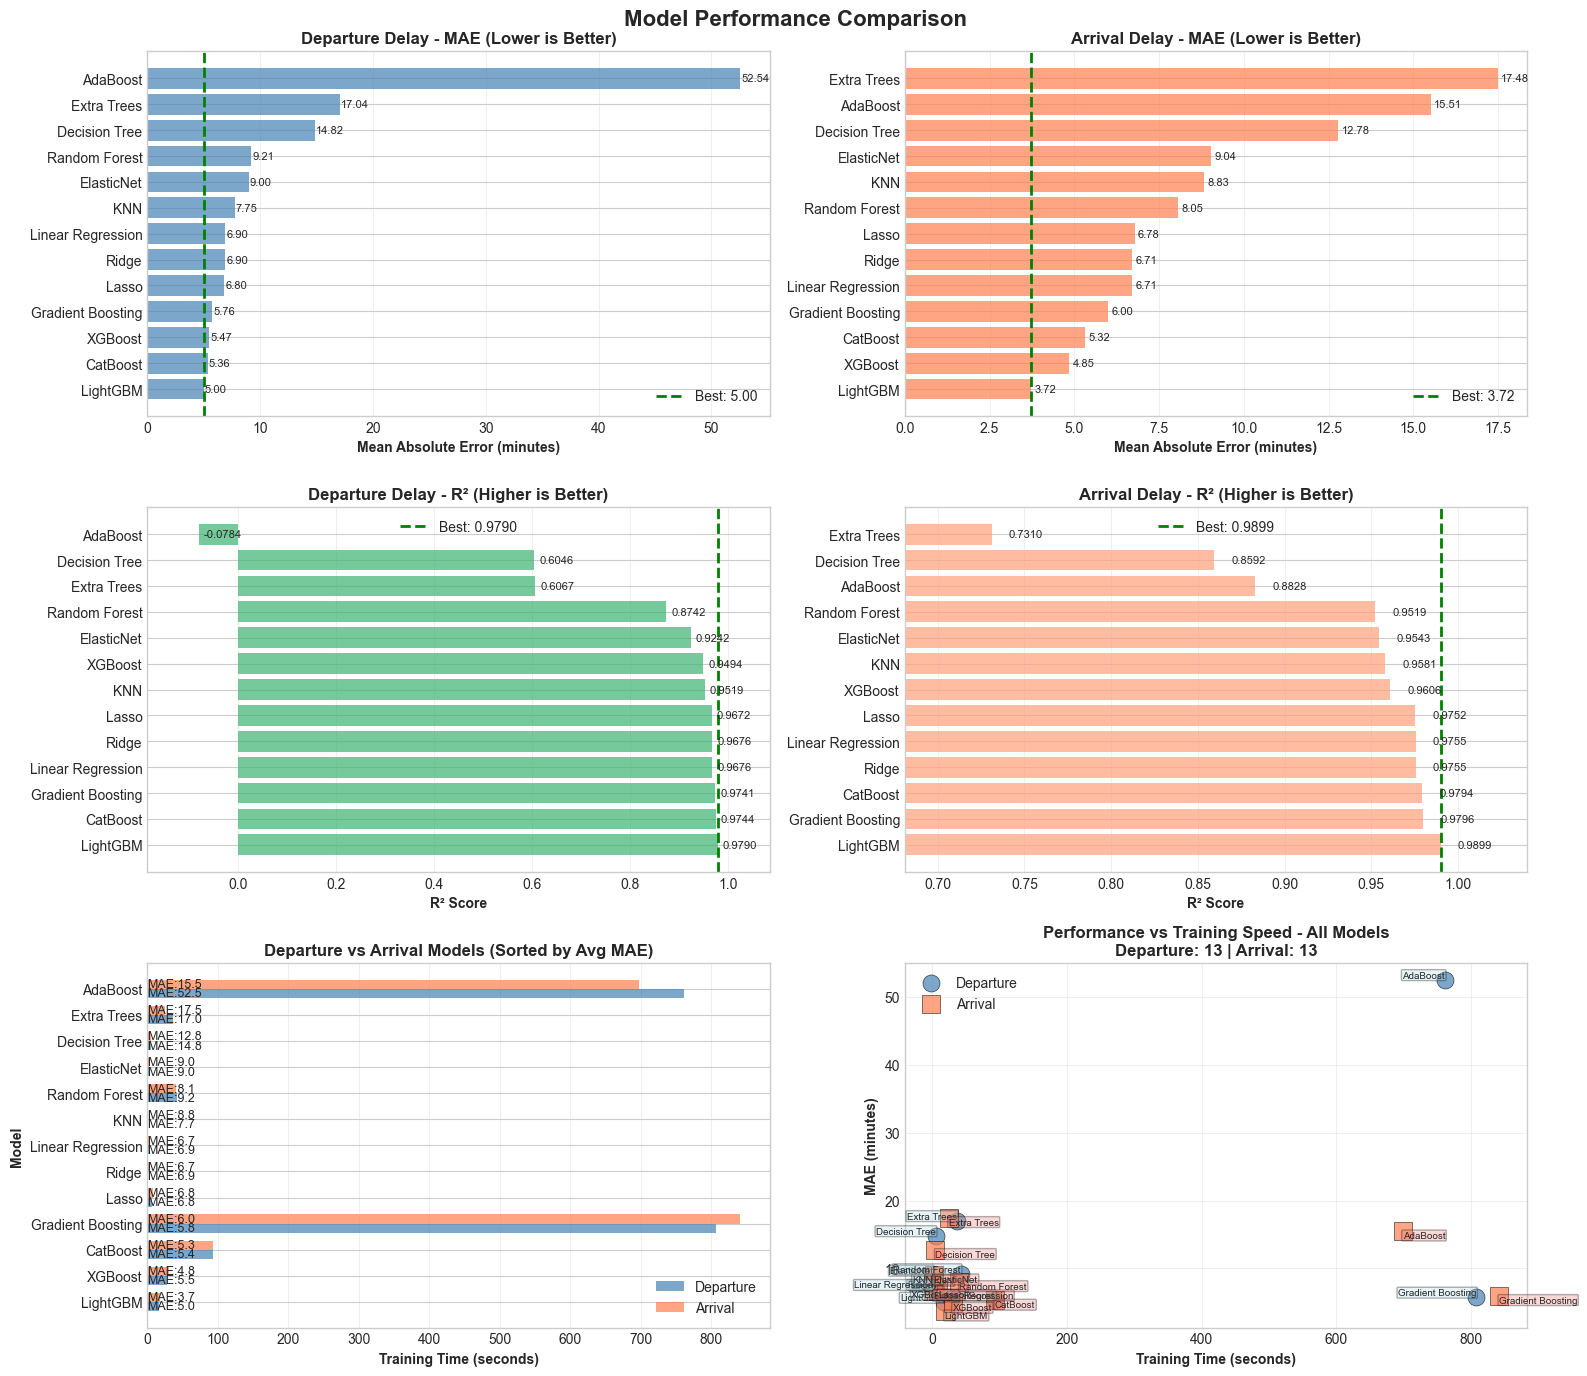

In [86]:
# ============================================================================
# 19.0 VISUALIZE RESULTS
# ============================================================================


print("\n" + "="*60)
print("📈 CREATING VISUALIZATIONS")
print("="*60)

# Create comprehensive comparison plots
fig, axes = plt.subplots(3, 2, figsize=(16, 14), constrained_layout=True)
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# 1. MAE Comparison - Departure
ax1 = axes[0, 0]
df_dep_mae = df_results_dep.sort_values('MAE', ascending=True).reset_index(drop=True)
y_pos_dep = range(len(df_dep_mae))
bars1 = ax1.barh(y_pos_dep, df_dep_mae['MAE'], color='steelblue', alpha=0.7)
ax1.set_yticks(y_pos_dep)
ax1.set_yticklabels(df_dep_mae['Model'])
ax1.set_xlabel('Mean Absolute Error (minutes)', fontweight='bold')
ax1.set_title('Departure Delay - MAE (Lower is Better)', fontweight='bold')
ax1.axvline(df_dep_mae['MAE'].min(), color='green', linestyle='--', 
    label=f"Best: {df_dep_mae['MAE'].min():.2f}", linewidth=2)

# Add value labels
for i, (bar, val) in enumerate(zip(bars1, df_dep_mae['MAE'])):
    ax1.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)

ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# 2. MAE Comparison - Arrival
ax2 = axes[0, 1]
df_arr_mae = df_results_arr.sort_values('MAE', ascending=True).reset_index(drop=True)
y_pos_arr = range(len(df_arr_mae))
bars2 = ax2.barh(y_pos_arr, df_arr_mae['MAE'], color='coral', alpha=0.7)
ax2.set_yticks(y_pos_arr)
ax2.set_yticklabels(df_arr_mae['Model'])
ax2.set_xlabel('Mean Absolute Error (minutes)', fontweight='bold')
ax2.set_title('Arrival Delay - MAE (Lower is Better)', fontweight='bold')
ax2.axvline(df_arr_mae['MAE'].min(), color='green', linestyle='--', label=f"Best: {df_arr_mae['MAE'].min():.2f}", linewidth=2)

# Add value labels
for i, (bar, val) in enumerate(zip(bars2, df_arr_mae['MAE'])):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)

ax2.legend()
ax2.grid(axis='x', alpha=0.3)

# 3. R² Comparison - Departure
ax3 = axes[1, 0]
df_dep_r2 = df_results_dep.sort_values('R²', ascending=False).reset_index(drop=True)
y_pos_dep_r2 = range(len(df_dep_r2))
bars3 = ax3.barh(y_pos_dep_r2, df_dep_r2['R²'], color='mediumseagreen', alpha=0.7)
ax3.set_yticks(y_pos_dep)
ax3.set_yticklabels(df_dep_r2['Model'])
ax3.set_xlabel('R² Score', fontweight='bold')
ax3.set_title('Departure Delay - R² (Higher is Better)', fontweight='bold')
ax3.axvline(df_dep_r2['R²'].max(), color='green', linestyle='--', label=f"Best: {df_dep_r2['R²'].max():.4f}", linewidth=2)

r2_values = df_dep_r2['R²']
r2_min    = r2_values.min()
r2_max    = r2_values.max()

# Add padding (10% of range or minimum padding if range is tiny)
padding = max((r2_max - r2_min) * 0.1, 0.05)

ax3.set_xlim(r2_min - padding, r2_max + padding) # ax3.set_xlim(-1.5, 1.5)

# Add value labels
for i, (bar, val) in enumerate(zip(bars3, df_dep_r2['R²'])):
    ax3.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=8)

ax3.legend()
ax3.grid(axis='x', alpha=0.3)

# 4. R² Comparison - Arrival
ax4 = axes[1, 1]
df_arr_r2 = df_results_arr.sort_values('R²', ascending=False).reset_index(drop=True)
y_pos_arr_r2 = range(len(df_arr_r2))
bars4 = ax4.barh(y_pos_arr_r2, df_arr_r2['R²'], color='lightsalmon', alpha=0.7)
ax4.set_yticks(y_pos_arr_r2)
ax4.set_yticklabels(df_arr_r2['Model'])
ax4.set_xlabel('R² Score', fontweight='bold')
ax4.set_title('Arrival Delay - R² (Higher is Better)', fontweight='bold')
ax4.axvline(df_arr_r2['R²'].max(), color='green', linestyle='--', label=f"Best: {df_arr_r2['R²'].max():.4f}", linewidth=2)

r2_values = df_arr_r2['R²']
r2_min    = r2_values.min()
r2_max    = r2_values.max()

# Add padding (10% of range or minimum padding if range is tiny)
padding = max((r2_max - r2_min) * 0.1, 0.05)

ax4.set_xlim(r2_min - padding, r2_max + padding) # ax4.set_xlim(-1.5, 1.5)

# Add value labels
for i, (bar, val) in enumerate(zip(bars4, df_arr_r2['R²'])):
    ax4.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=8)

ax4.legend()
ax4.grid(axis='x', alpha=0.3)

# 5. Training Time Comparison
ax5 = axes[2, 0]

# Get unique models from both datasets
models = sorted(set(df_results_dep['Model'].tolist() + df_results_arr['Model'].tolist()))

# Create dictionaries for easy lookup
dep_times = {row['Model']: row['Train Time (s)'] for _, row in df_results_dep.iterrows()}
arr_times = {row['Model']: row['Train Time (s)'] for _, row in df_results_arr.iterrows()}
dep_mae   = {row['Model']: row['MAE']            for _, row in df_results_dep.iterrows()}
arr_mae   = {row['Model']: row['MAE']            for _, row in df_results_arr.iterrows()}

# Calculate average MAE for each model to sort by
avg_mae = {model: (dep_mae.get(model, 0) + arr_mae.get(model, 0)) / 2 for model in models}

# Sort models by average MAE (reverse=False puts smallest MAE first - best at top)
# Change to reverse=True if you want worst models at top
sorted_models = sorted(models, key=lambda x: avg_mae[x], reverse=False)

# Set up bar positions
y = range(len(sorted_models))
height = 0.35

# Create horizontal bars
bars_dep = ax5.barh([i - height/2 for i in y], 
                    [dep_times.get(model, 0) for model in sorted_models], 
                    height,
                    label='Departure',
                    color='steelblue',
                    alpha=0.7)

bars_arr = ax5.barh([i + height/2 for i in y],
                    [arr_times.get(model, 0) for model in sorted_models], 
                    height,
                    label='Arrival',
                    color='coral',
                    alpha=0.7)

# Customize the plot
ax5.set_ylabel('Model', fontweight='bold')
ax5.set_xlabel('Training Time (seconds)', fontweight='bold')
ax5.set_title('Departure vs Arrival Models (Sorted by Avg MAE)', fontweight='bold')
ax5.set_yticks(y)
ax5.set_yticklabels(sorted_models)
ax5.legend()

# Add value labels on bars (time - MAE on same line)

for i, (bar, model) in enumerate(zip(bars_dep, sorted_models)):
    width = bar.get_width()
    if width > 0:
        mae_val = dep_mae.get(model, 0)
        ax5.text(width - width + 0.01, bar.get_y() + bar.get_height()/2,
            #'{width:.1f}s - MAE:{mae_val:.1f}',
            f'MAE:{mae_val:.1f}', 
            ha='left', va='center', fontsize=9)

for i, (bar, model) in enumerate(zip(bars_arr, sorted_models)):
    width = bar.get_width()
    if width > 0:
        mae_val = arr_mae.get(model, 0)
        ax5.text(width - width + 0.01, bar.get_y() + bar.get_height()/2,
                    f'MAE:{mae_val:.1f}', 
                    ha='left', va='center', fontsize=9)

ax5.legend()
ax5.grid(axis='x', alpha=0.3)

# 6. Performance vs Speed - All Models
ax6 = axes[2, 1]

# Plot departure models
scatter_dep = ax6.scatter(df_results_dep['Train Time (s)'],
                            df_results_dep['MAE'],
                            s=150, alpha=0.7,
                            c='steelblue', marker='o',
                            label='Departure', edgecolors='black', linewidth=0.5)

# Plot arrival models
scatter_arr = ax6.scatter(df_results_arr['Train Time (s)'],
                            df_results_arr['MAE'],
                            s=150, alpha=0.7,
                            c='coral', marker='s',
                            label='Arrival', edgecolors='black', linewidth=0.5)

# Add model labels for all models - DEPARTURE
for idx, row in df_results_dep.iterrows():
    ax6.annotate(row['Model'], 
                    (row['Train Time (s)'], row['MAE']),
                    fontsize=7, ha='right', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.1', fc='lightblue', alpha=0.3))

# Add model labels for all models - ARRIVAL
for idx, row in df_results_arr.iterrows():
    ax6.annotate(row['Model'], 
                    (row['Train Time (s)'], row['MAE']),
                    fontsize=7, ha='left', va='top',
                    bbox=dict(boxstyle='round,pad=0.1', fc='lightcoral', alpha=0.3))

ax6.set_xlabel('Training Time (seconds)', fontweight='bold')
ax6.set_ylabel('MAE (minutes)', fontweight='bold')
ax6.set_title(f'Performance vs Training Speed - All Models\nDeparture: {len(df_results_dep)} | Arrival: {len(df_results_arr)}', fontweight='bold')
ax6.grid(alpha=0.3)
ax6.legend()

plt.tight_layout()

# Save the figure
save_path = DIR_png + 'model_perf_comparison.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {save_path}")
    
plt.show()
plt.close(fig)


📈 CREATING TRAINING TIME VISUALIZATIONS

📊 Models after filtering (excluded: ['AdaBoost', 'Gradient Boosting']):
Departure: 11 models
Arrival: 11 models
✅ Saved: ./df-full_mod-full_ff/mod_png/training_time_analysis_1.png


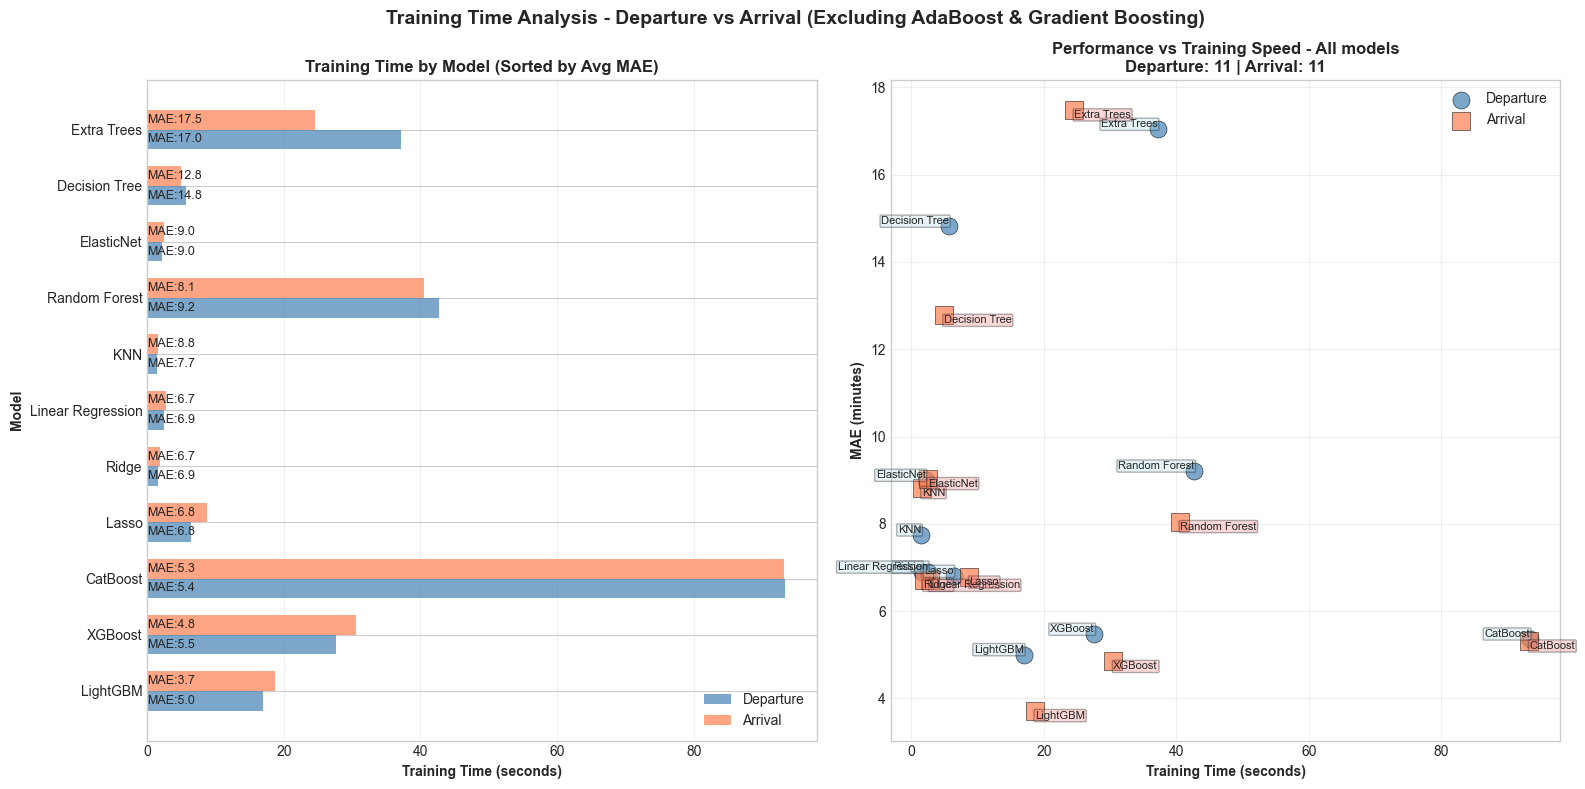

In [87]:
# ============================================================================
# 19.1 VISUALIZE RESULTS - Training Time Analysis Only
# ============================================================================

print("\n" + "="*60)
print("📈 CREATING TRAINING TIME VISUALIZATIONS")
print("="*60)

# Models to exclude
models_to_exclude = ['AdaBoost', 'Gradient Boosting']

# Filter out excluded models
df_results_dep_filtered = df_results_dep[~df_results_dep['Model'].isin(models_to_exclude)].reset_index(drop=True)
df_results_arr_filtered = df_results_arr[~df_results_arr['Model'].isin(models_to_exclude)].reset_index(drop=True)

print(f"\n📊 Models after filtering (excluded: {models_to_exclude}):")
print(f"Departure: {len(df_results_dep_filtered)} models")
print(f"Arrival: {len(df_results_arr_filtered)} models")

# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Training Time Analysis - Departure vs Arrival (Excluding AdaBoost & Gradient Boosting)', 
                fontsize=14, fontweight='bold')

# ============================================================
# 1. Training Time Comparison (Side-by-side horizontal bars)
# ============================================================
ax1 = axes[0]

# Get unique models from filtered datasets
models = sorted(set(df_results_dep_filtered['Model'].tolist() + df_results_arr_filtered['Model'].tolist()))

# Create dictionaries for easy lookup
dep_times = {row['Model']: row['Train Time (s)'] for _, row in df_results_dep_filtered.iterrows()}
arr_times = {row['Model']: row['Train Time (s)'] for _, row in df_results_arr_filtered.iterrows()}
dep_mae   = {row['Model']: row['MAE']            for _, row in df_results_dep_filtered.iterrows()}
arr_mae   = {row['Model']: row['MAE']            for _, row in df_results_arr_filtered.iterrows()}

# Calculate average MAE for each model to sort by
avg_mae = {model: (dep_mae.get(model, 0) + arr_mae.get(model, 0)) / 2 
            for model in models}

# Sort models by average MAE (reverse=False puts smallest MAE first - best at top)
sorted_models = sorted(models, key=lambda x: avg_mae[x], reverse=False)

# Set up bar positions
y = range(len(sorted_models))
height = 0.35

# Create horizontal bars
bars_dep = ax1.barh([i - height/2 for i in y], 
                    [dep_times.get(model, 0) for model in sorted_models], 
                    height,
                    label='Departure',
                    color='steelblue',
                    alpha=0.7)

bars_arr = ax1.barh([i + height/2 for i in y],
                    [arr_times.get(model, 0) for model in sorted_models], 
                    height,
                    label='Arrival',
                    color='coral',
                    alpha=0.7)

# Customize the plot
ax1.set_ylabel('Model', fontweight='bold')
ax1.set_xlabel('Training Time (seconds)', fontweight='bold')
ax1.set_title('Training Time by Model (Sorted by Avg MAE)', fontweight='bold')
ax1.set_yticks(y)
ax1.set_yticklabels(sorted_models)
ax1.legend(loc='lower right')

# Add value labels on bars (MAE only)
for i, (bar, model) in enumerate(zip(bars_dep, sorted_models)):
    width = bar.get_width()
    if width > 0:
        mae_val = dep_mae.get(model, 0)
        ax1.text(width - width + 0.01, bar.get_y() + bar.get_height()/2,
                f'MAE:{mae_val:.1f}', 
                ha='left', va='center', fontsize=9)

for i, (bar, model) in enumerate(zip(bars_arr, sorted_models)):
    width = bar.get_width()
    if width > 0:
        mae_val = arr_mae.get(model, 0)
        ax1.text(width - width + 0.01, bar.get_y() + bar.get_height()/2,
                f'MAE:{mae_val:.1f}', 
                ha='left', va='center', fontsize=9)

ax1.grid(axis='x', alpha=0.3)

# ============================================================
# 2 Performance vs Speed - All Models
# ============================================================
ax6 = axes[1]

# Plot departure models
scatter_dep = ax6.scatter(df_results_dep_filtered['Train Time (s)'],
                            df_results_dep_filtered['MAE'],
                            s=150, alpha=0.7,
                            c='steelblue', marker='o',
                            label='Departure', edgecolors='black', linewidth=0.5)

# Plot arrival models
scatter_arr = ax6.scatter(df_results_arr_filtered['Train Time (s)'],
                            df_results_arr_filtered['MAE'],
                            s=150, alpha=0.7,
                            c='coral', marker='s',
                            label='Arrival', edgecolors='black', linewidth=0.5)

# Add model labels for all models - DEPARTURE
for idx, row in df_results_dep_filtered.iterrows():
    ax6.annotate(row['Model'], 
                    (row['Train Time (s)'], row['MAE']),
                    fontsize=8, ha='right', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.1', fc='lightblue', alpha=0.3))

# Add model labels for all models - ARRIVAL
for idx, row in df_results_arr_filtered.iterrows():
    ax6.annotate(row['Model'], 
                    (row['Train Time (s)'], row['MAE']),
                    fontsize=8, ha='left', va='top',
                    bbox=dict(boxstyle='round,pad=0.1', fc='lightcoral', alpha=0.3))

ax6.set_xlabel('Training Time (seconds)', fontweight='bold')
ax6.set_ylabel('MAE (minutes)', fontweight='bold')
ax6.set_title(f'Performance vs Training Speed - All models\nDeparture: {len(df_results_dep_filtered)} | Arrival: {len(df_results_arr_filtered)}', 
                fontweight='bold')
ax6.grid(alpha=0.3)
ax6.legend(loc='upper right')

plt.tight_layout()

# Save the figure
save_path = DIR_png + 'training_time_analysis_1.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {save_path}")

plt.show()
plt.close(fig)


📈 CREATING TRAINING TIME VISUALIZATIONS

📊 Models after filtering (excluded: ['AdaBoost', 'Gradient Boosting', 'Lasso', 'Extra Trees', 'Random Forest']):
Departure: 8 models
Arrival:   8 models
✅ Saved: ./df-full_mod-full_ff/mod_png/training_time_analysis_2.png


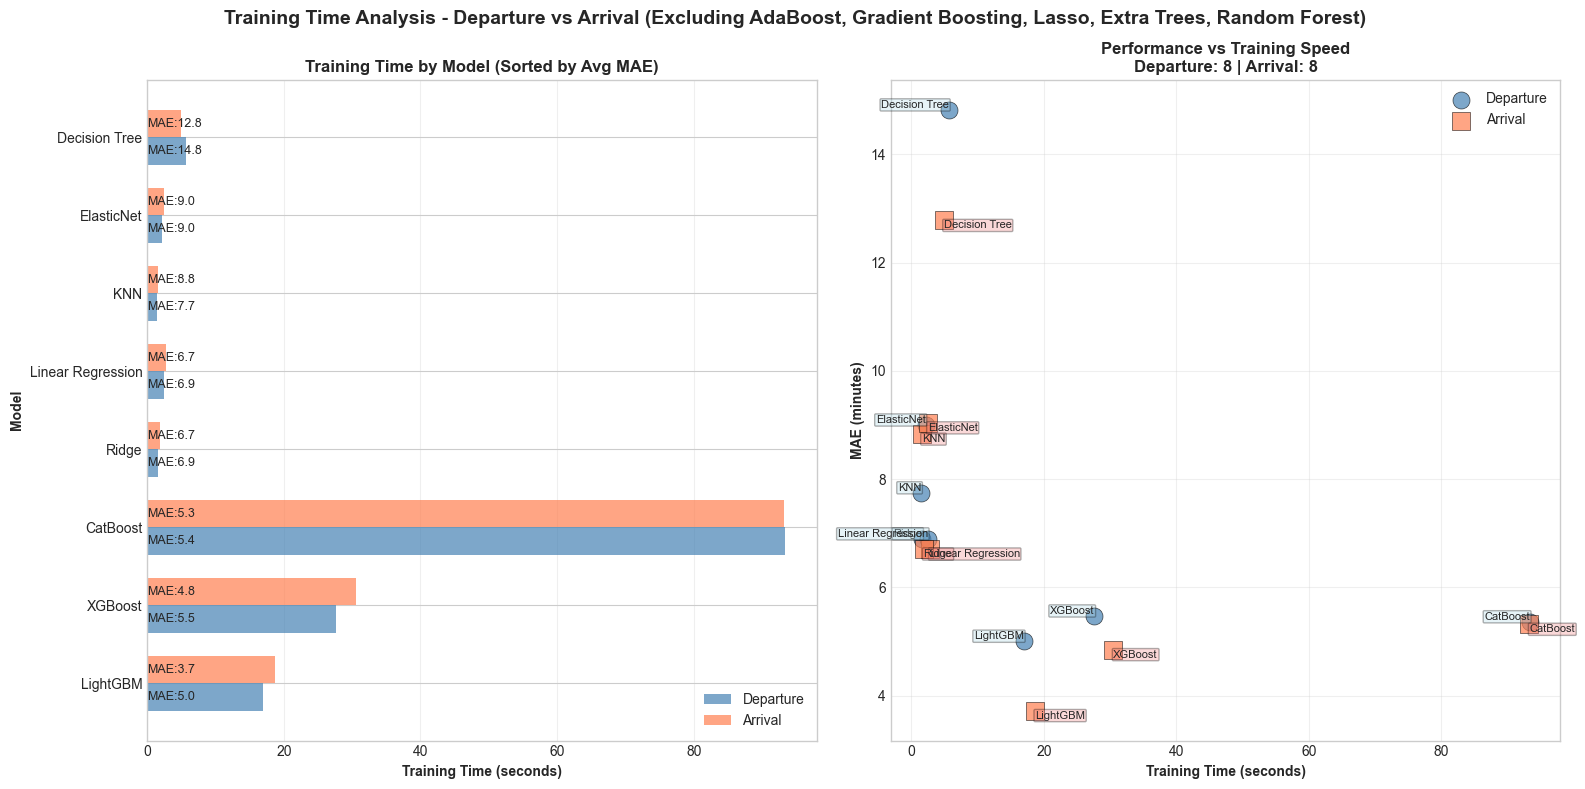

In [88]:
# ============================================================================
# 19.2 VISUALIZE RESULTS - Training Time Analysis Only
# ============================================================================
if not PRETRAINED_MODE:
    print("\n" + "="*60)
    print("📈 CREATING TRAINING TIME VISUALIZATIONS")
    print("="*60)
    
    # Models to exclude
    models_to_exclude = ['AdaBoost', 'Gradient Boosting', 'Lasso', 'Extra Trees', 'Random Forest']
    
    # Filter out excluded models
    df_results_dep_filtered = df_results_dep[~df_results_dep['Model'].isin(models_to_exclude)].reset_index(drop=True)
    df_results_arr_filtered = df_results_arr[~df_results_arr['Model'].isin(models_to_exclude)].reset_index(drop=True)

    print(f"\n📊 Models after filtering (excluded: {models_to_exclude}):")
    print(f"Departure: {len(df_results_dep_filtered)} models")
    print(f"Arrival:   {len(df_results_arr_filtered)} models")

    # Create figure with two subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle(f'Training Time Analysis - Departure vs Arrival (Excluding {', '.join(models_to_exclude)})', 
                 fontsize=14, 
                 fontweight='bold')

    # ============================================================
    # 1. Training Time Comparison (Side-by-side horizontal bars)
    # ============================================================
    ax5 = axes[0]

    # Get unique models from filtered datasets
    models = sorted(set(df_results_dep_filtered['Model'].tolist() + df_results_arr_filtered['Model'].tolist()))

    # Create dictionaries for easy lookup
    dep_times = {row['Model']: row['Train Time (s)'] for _, row in df_results_dep_filtered.iterrows()}
    arr_times = {row['Model']: row['Train Time (s)'] for _, row in df_results_arr_filtered.iterrows()}
    dep_mae   = {row['Model']: row['MAE'] for _, row in df_results_dep_filtered.iterrows()}
    arr_mae   = {row['Model']: row['MAE'] for _, row in df_results_arr_filtered.iterrows()}

    # Calculate average MAE for each model to sort by
    avg_mae = {model: (dep_mae.get(model, 0) + arr_mae.get(model, 0)) / 2 
               for model in models}

    # Sort models by average MAE (reverse=False puts smallest MAE first - best at top)
    sorted_models = sorted(models, key=lambda x: avg_mae[x], reverse=False)

    # Set up bar positions
    y = range(len(sorted_models))
    height = 0.35

    # Create horizontal bars
    bars_dep = ax5.barh([i - height/2 for i in y], 
                        [dep_times.get(model, 0) for model in sorted_models], 
                        height,
                        label='Departure',
                        color='steelblue',
                        alpha=0.7)

    bars_arr = ax5.barh([i + height/2 for i in y],
                        [arr_times.get(model, 0) for model in sorted_models], 
                        height,
                        label='Arrival',
                        color='coral',
                        alpha=0.7)

    # Customize the plot
    ax5.set_ylabel('Model', fontweight='bold')
    ax5.set_xlabel('Training Time (seconds)', fontweight='bold')
    ax5.set_title('Training Time by Model (Sorted by Avg MAE)', fontweight='bold')
    ax5.set_yticks(y)
    ax5.set_yticklabels(sorted_models)
    ax5.legend(loc='lower right')

    # Add value labels on bars (MAE only)
    for i, (bar, model) in enumerate(zip(bars_dep, sorted_models)):
        width = bar.get_width()
        if width > 0:
            mae_val = dep_mae.get(model, 0)
            ax5.text(width - width + 0.01, bar.get_y() + bar.get_height()/2,
                    f'MAE:{mae_val:.1f}', 
                    ha='left', va='center', fontsize=9)

    for i, (bar, model) in enumerate(zip(bars_arr, sorted_models)):
        width = bar.get_width()
        if width > 0:
            mae_val = arr_mae.get(model, 0)
            ax5.text(width - width + 0.01, bar.get_y() + bar.get_height()/2,
                    f'MAE:{mae_val:.1f}', 
                    ha='left', va='center', fontsize=9)

    ax5.grid(axis='x', alpha=0.3)

    # ============================================================
    # 2. Performance vs Speed - All Models
    # ============================================================
    ax6 = axes[1]
    
    # Plot departure models
    scatter_dep = ax6.scatter(df_results_dep_filtered['Train Time (s)'],
                              df_results_dep_filtered['MAE'],
                              s = 150,
                              alpha = 0.7,
                              c = 'steelblue',
                              marker = 'o',
                              label = 'Departure',
                              edgecolors = 'black',
                              linewidth = 0.5)
    
    # Plot arrival models
    scatter_arr = ax6.scatter(df_results_arr_filtered['Train Time (s)'],
                              df_results_arr_filtered['MAE'],
                              s = 150,
                              alpha = 0.7,
                              c = 'coral',
                              marker = 's',
                              label = 'Arrival',
                              edgecolors = 'black',
                              linewidth = 0.5)
    
    # Add model labels for all models - DEPARTURE
    for idx, row in df_results_dep_filtered.iterrows():
        ax6.annotate(row['Model'], 
                     (row['Train Time (s)'],
                     row['MAE']),
                     fontsize = 8,
                     ha = 'right',
                     va = 'bottom',
                     bbox=dict(boxstyle = 'round,pad=0.1',
                               fc = 'lightblue',
                               alpha = 0.3))
    
    # Add model labels for all models - ARRIVAL
    for idx, row in df_results_arr_filtered.iterrows():
        ax6.annotate(row['Model'], 
                     (row['Train Time (s)'],
                     row['MAE']),
                     fontsize = 8,
                     ha = 'left',
                     va = 'top',
                     bbox=dict(boxstyle = 'round,pad=0.1',
                               fc = 'lightcoral',
                               alpha = 0.3))
    
    ax6.set_xlabel('Training Time (seconds)', fontweight='bold')
    ax6.set_ylabel('MAE (minutes)', fontweight='bold')
    ax6.set_title(f'Performance vs Training Speed\nDeparture: {len(df_results_dep_filtered)} | Arrival: {len(df_results_arr_filtered)}', 
                  fontweight='bold')
    ax6.grid(alpha=0.3)
    ax6.legend(loc='upper right')

    plt.tight_layout()
    
    # Save the figure
    save_path = DIR_png + 'training_time_analysis_2.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {save_path}")
    
    plt.show()
    plt.close(fig)

In [89]:
# ============================================================================
# 19.3 ANALYZE MAX Vs MIN MAE Values
# ============================================================================

if not PRETRAINED_MODE:
    print("\n" + "="*80)
    print("🔍 ANALYZING MAX vs MIN MAE Values")
    print("="*80)
    
    # Get model names at min/max MAE
    min_mae_model_dep = str(df_results_dep_filtered.loc[df_results_dep_filtered['MAE'].idxmin(), 'Model'])
    max_mae_model_dep = str(df_results_dep_filtered.loc[df_results_dep_filtered['MAE'].idxmax(), 'Model'])
    min_mae_model_arr = str(df_results_arr_filtered.loc[df_results_arr_filtered['MAE'].idxmin(), 'Model'])
    max_mae_model_arr = str(df_results_arr_filtered.loc[df_results_arr_filtered['MAE'].idxmax(), 'Model'])

    # Get MAE values directly from series methods (avoids Scalar type issues)
    min_mae_value_dep = np.float64(df_results_dep_filtered['MAE'].min()).item()
    max_mae_value_dep = np.float64(df_results_dep_filtered['MAE'].max()).item()
    min_mae_value_arr = np.float64(df_results_arr_filtered['MAE'].min()).item()
    max_mae_value_arr = np.float64(df_results_arr_filtered['MAE'].max()).item()

    # Calculate ratio
    times_dep = max_mae_value_dep / min_mae_value_dep
    times_arr = max_mae_value_arr / min_mae_value_arr

    # Print with aligned formatting
    print(f"Departure model: {max_mae_model_dep:<10} with Max MAE: {max_mae_value_dep:.4f}")
    print(f"Departure model: {min_mae_model_dep:<10} with Min MAE: {min_mae_value_dep:.4f}")
    print(f"👉 Max MAE is {times_dep:.2f} times the Min MAE for Departure\n")

    print(f"Arrival   model: {max_mae_model_arr:<10} with Max MAE: {max_mae_value_arr:.4f}")
    print(f"Arrival   model: {min_mae_model_arr:<10} with Min MAE: {min_mae_value_arr:.4f}")
    print(f"👉 Max MAE is {times_arr:.2f} times the Min MAE for Arrival")


🔍 ANALYZING MAX vs MIN MAE Values
Departure model: Decision Tree with Max MAE: 14.8196
Departure model: LightGBM   with Min MAE: 5.0044
👉 Max MAE is 2.96 times the Min MAE for Departure

Arrival   model: Decision Tree with Max MAE: 12.7779
Arrival   model: LightGBM   with Min MAE: 3.7238
👉 Max MAE is 3.43 times the Min MAE for Arrival


In [90]:
# Models
print(f"\n📊 Unique Model Count:\n")
print(f"Departure models: {len(df_results_dep)}")
for i, model in enumerate(df_results_dep['Model'].tolist()):
    print(f"   {i+1}. {model}")
print(f"\nArrival models: {len(df_results_arr)}")
for i, model in enumerate(df_results_arr['Model'].tolist()):
    print(f"   {i+1}. {model}")


📊 Unique Model Count:

Departure models: 13
   1. LightGBM
   2. CatBoost
   3. XGBoost
   4. Gradient Boosting
   5. Lasso
   6. Ridge
   7. Linear Regression
   8. KNN
   9. ElasticNet
   10. Random Forest
   11. Decision Tree
   12. Extra Trees
   13. AdaBoost

Arrival models: 13
   1. LightGBM
   2. XGBoost
   3. CatBoost
   4. Gradient Boosting
   5. Linear Regression
   6. Ridge
   7. Lasso
   8. Random Forest
   9. KNN
   10. ElasticNet
   11. Decision Tree
   12. AdaBoost
   13. Extra Trees


In [91]:
# ============================================================================
# 20. SELECT BEST MODELS based on MAE
# ============================================================================
if not PRETRAINED_MODE:
    print("\n" + "="*60)
    print("🏆 BEST MODEL SELECTION")
    print("="*60)

    # Best for departure delay
    best_model_name_dep = df_results_dep.iloc[0]['Model']
    best_mae_dep =        df_results_dep.iloc[0]['MAE']
    best_mse_dep =        df_results_dep.iloc[0]['MSE']
    best_rmse_dep =       df_results_dep.iloc[0]['RMSE']
    best_r2_dep =         df_results_dep.iloc[0]['R²']
    best_mape_dep =       df_results_dep.iloc[0]['MAPE']
    best_smape_dep =      df_results_dep.iloc[0]['SMAPE']
    best_train_time_dep = df_results_dep.iloc[0]['Train Time (s)']
    best_pred_time_dep =  df_results_dep.iloc[0]['Pred Time (s)']
    best_predxsec_dep =   df_results_dep.iloc[0]['Predictions/sec']


    print(f"\n🛫 BEST MODEL FOR DEPARTURE DELAY:")
    print(f"   Model:\t\t{best_model_name_dep}")
    print(f"   MAE:\t\t\t{best_mae_dep:.2f} minutes \t\t---> 0")
    print(f"   MSE:\t\t\t{best_mse_dep:.2f} minutes^2 \t---> 0")
    print(f"   RMSE:\t\t{best_rmse_dep:.2f} minutes \t\t---> 0")
    print(f"   R²:\t\t\t{best_r2_dep:.4f} %/proportion \t---> 1")
    print(f"   MAPE:\t\t{best_mape_dep:.2f} % \t\t---> 0")
    print(f"   SMAPE:\t\t{best_smape_dep:.2f} % \t\t---> 0")
    print(f"   Training Time:\t{best_train_time_dep:.2f}s")
    print(f"   Prediction Time:\t{best_pred_time_dep:.2f}s")
    print(f"   Prediction/sec:\t{best_predxsec_dep:.2f}/sec")


    # Best for arrival delay
    best_model_name_arr = df_results_arr.iloc[0]['Model']
    best_mae_arr =        df_results_arr.iloc[0]['MAE']
    best_mse_arr =        df_results_arr.iloc[0]['MSE']
    best_rmse_arr =       df_results_arr.iloc[0]['RMSE']
    best_r2_arr =         df_results_arr.iloc[0]['R²']
    best_mape_arr =       df_results_arr.iloc[0]['MAPE']
    best_smape_arr =      df_results_arr.iloc[0]['SMAPE']
    best_train_time_arr = df_results_arr.iloc[0]['Train Time (s)']
    best_pred_time_arr =  df_results_arr.iloc[0]['Pred Time (s)']
    best_predxsec_arr =   df_results_arr.iloc[0]['Predictions/sec']


    print(f"\n🛬 BEST MODEL FOR ARRIVAL DELAY:")
    print(f"   Model:\t\t{best_model_name_arr}")
    print(f"   MAE:\t\t\t{best_mae_arr:.2f} minutes \t\t---> 0")
    print(f"   MSE:\t\t\t{best_mse_arr:.2f} minutes^2 \t---> 0")
    print(f"   RMSE:\t\t{best_rmse_arr:.2f} minutes \t\t---> 0")
    print(f"   R²:\t\t\t{best_r2_arr:.4f} %/proportion \t---> 1")
    print(f"   MAPE:\t\t{best_mape_arr:.2f} % \t\t---> 0")
    print(f"   SMAPE:\t\t{best_smape_arr:.2f} % \t\t---> 0")
    print(f"   Training Time:\t{best_train_time_arr:.2f}s")
    print(f"   Prediction Time:\t{best_pred_time_arr:.2f}s")
    print(f"   Prediction/sec:\t{best_predxsec_arr:.2f}/sec")

    # Select best models
    best_model_dep = trained_models_dep[best_model_name_dep]
    best_model_arr = trained_models_arr[best_model_name_arr]


🏆 BEST MODEL SELECTION

🛫 BEST MODEL FOR DEPARTURE DELAY:
   Model:		LightGBM
   MAE:			5.00 minutes 		---> 0
   MSE:			61.86 minutes^2 	---> 0
   RMSE:		7.87 minutes 		---> 0
   R²:			0.9790 %/proportion 	---> 1
   MAPE:		9999.00 % 		---> 0
   SMAPE:		102.13 % 		---> 0
   Training Time:	16.98s
   Prediction Time:	0.88s
   Prediction/sec:	1531463.91/sec

🛬 BEST MODEL FOR ARRIVAL DELAY:
   Model:		LightGBM
   MAE:			3.72 minutes 		---> 0
   MSE:			32.06 minutes^2 	---> 0
   RMSE:		5.66 minutes 		---> 0
   R²:			0.9899 %/proportion 	---> 1
   MAPE:		9999.00 % 		---> 0
   SMAPE:		47.23 % 		---> 0
   Training Time:	18.66s
   Prediction Time:	0.96s
   Prediction/sec:	1404250.01/sec


# 📝 Better Models Selection - not only by MAE

In [92]:
# ============================================================================
# 21.0 POINTS-BASED MODEL SELECTION (3-1-0 Ranking System)
# ============================================================================
'''
    Scoring logic:
    For each metric (MAE ↓, RMSE ↓, R² ↑):
        1st place -----------→ 3 points
        2nd place -----------→ 1 point
        3rd place (or lower) → 0 points
    Winner = model with highest total points
'''

def select_best_model_points(df_results, target_name):
    """
    Select the best model using a 3-1-0 points-based ranking system.

    For each metric:
        - MAE  (lower is better):  rank ascending
        - MSE  (lower is better):  rank ascending
        - R²   (higher is better): rank descending

    Points awarded:
        - 1st place ---------→ 3 points
        - 2nd place ---------→ 1 point
        - 3rd place or lower → 0 points

    The model with the most total points wins.

    Parameters:
    -----------
    df_results : pd.DataFrame
        Results DataFrame with columns: ['Model', 'MAE', 'RMSE', 'R²']
    target_name : str
        Name of the target variable (for display purposes)

    Returns:
    --------
    dict : Contains winner info, full leaderboard, and per-metric rankings
    """

    df = df_results[['Model', 'MAE', 'RMSE', 'R²']].copy().reset_index(drop=True)
    n  = len(df)

    def award_points(series, higher_better=False):
        """Rank a metric and return points (3, 1, 0) for each model."""
        ranked = series.rank(ascending=not higher_better, method='min')
        points = ranked.apply(lambda r: 3 if r == 1 else (1 if r == 2 else 0))
        return ranked.astype(int), points

    # Rank each metric
    df['MAE_rank'],  df['MAE_pts']  = award_points(df['MAE'],  higher_better=False)
    df['RMSE_rank'], df['RMSE_pts'] = award_points(df['RMSE'], higher_better=False)
    df['R2_rank'],   df['R2_pts']   = award_points(df['R²'],   higher_better=True)

    # Total points
    df['Total_pts'] = df['MAE_pts'] + df['RMSE_pts'] + df['R2_pts']

    # Sort by total points (ties broken by MAE rank)
    df = df.sort_values(['Total_pts', 'MAE_rank'], ascending=[False, True]).reset_index(drop=True)
    df['Final_rank'] = range(1, len(df) + 1)

    # ── Print leaderboard ────────────────────────────────────────────────────
    print(f"\n{'='*70}")
    print(f"🏆 POINTS-BASED MODEL SELECTION → {target_name}")
    print(f"{'='*70}")
    print(f"   Scoring: 1st = 3 pts | 2nd = 1 pt | 3rd+ = 0 pts")
    print(f"   Metrics: MAE (↓ lower=better), RMSE (↓ lower=better), R² (↑ higher=better)")
    print(f"\n{'='*70}")

    col_w = max(len(m) for m in df['Model']) + 2
    header = (f"{'#':<4} {'Model':<{col_w}} {'MAE':>8} "
              f"{'RMSE':>12} {'R²':>8} "
              f"{'MAE pts':>13} {'RMSE pts':>8} {'R² pts':>8} {'TOTAL':>6}")
    print(header)
    print('-' * len(header))

    MEDALS = {1: '🥇', 2: '🥈', 3: '🥉'}

    for _, row in df.iterrows():
        medal = MEDALS.get(int(row['Final_rank']), '❌')
        print(f"{medal} {int(row['Final_rank']):<3} "
              f"{row['Model']:<{col_w}} "
              f"{row['MAE']:>8.4f} "
              f"{row['RMSE']:>12.2f} "
              f"{row['R²']:>8.4f} "
              f"{int(row['MAE_pts']):>8} "
              f"{int(row['RMSE_pts']):>8} "
              f"{int(row['R2_pts']):>8} "
              f"{int(row['Total_pts']):>7}")

    # ── Winner summary ───────────────────────────────────────────────────────
    winner = df.iloc[0]
    runner_up = df.iloc[1] if n > 1 else None

    print(f"\n{'='*70}")
    print(f"🏆 WINNER: {winner['Model']}")
    print(f"   Total points........... {int(winner['Total_pts'])} / {3 * 3}")
    print(f"   MAE.................... {winner['MAE']:>6.4f} (rank #{int(winner['MAE_rank'])} → {int(winner['MAE_pts'])} pts)")
    print(f"   RMSE................... {winner['RMSE']:>6.4f} (rank #{int(winner['RMSE_rank'])} → {int(winner['RMSE_pts'])} pts)")
    print(f"   R²..................... {winner['R²']:>6.4f} (rank #{int(winner['R2_rank'])} → {int(winner['R2_pts'])} pts)")

    if runner_up is not None:
        margin = int(winner['Total_pts']) - int(runner_up['Total_pts'])
        print(f"\n   Runner-up: {runner_up['Model']}  ({int(runner_up['Total_pts'])} pts, margin: {margin} pts)")
    print(f"{'='*70}")

    return {'target':          target_name,
            'winner':          winner['Model'],
            'total_points':    int(winner['Total_pts']),
            'max_points':      9,          # 3 metrics × 3 pts
            'leaderboard':     df,
            'metrics': {'MAE':  float(winner['MAE']),
                        'RMSE': float(winner['RMSE']),
                        'R²':   float(winner['R²'])},
            'ranks':   {'MAE':  int(winner['MAE_rank']),
                        'RMSE': int(winner['RMSE_rank']),
                        'R²':   int(winner['R2_rank'])},
            'points':  {'MAE':  int(winner['MAE_pts']),
                        'RMSE': int(winner['RMSE_pts']),
                        'R²':   int(winner['R2_pts'])}}

In [93]:
# ============================================================================
# 21.1 RUN POINTS-BASED SELECTION FOR BOTH TARGETS
# ============================================================================

if not PRETRAINED_MODE:
    print("\n" + "="*70)
    print("📊 RUNNING POINTS-BASED MODEL SELECTION (3-1-0 SYSTEM)")
    print("="*70)

    result_dep = select_best_model_points(df_results_dep, "dep_delay_min")
    result_arr = select_best_model_points(df_results_arr, "arr_delay_min")

    # ── Update global best-model variables ──────────────────────────────────
    best_model_name_dep = result_dep['winner']
    best_model_name_arr = result_arr['winner']

    best_model_dep = trained_models_dep[best_model_name_dep]
    best_model_arr = trained_models_arr[best_model_name_arr]

    # Update metric variables from df_results (full row)
    dep_row = df_results_dep[df_results_dep['Model'] == best_model_name_dep].iloc[0]
    arr_row = df_results_arr[df_results_arr['Model'] == best_model_name_arr].iloc[0]

    best_mae_dep, best_mse_dep, best_rmse_dep  = dep_row['MAE'], dep_row['MSE'], dep_row['RMSE']
    best_r2_dep, best_mape_dep, best_smape_dep = dep_row['R²'], dep_row['MAPE'], dep_row['SMAPE']
    best_train_time_dep, best_pred_time_dep    = dep_row['Train Time (s)'], dep_row['Pred Time (s)']
    best_predxsec_dep                          = dep_row['Predictions/sec']

    best_mae_arr, best_mse_arr, best_rmse_arr  = arr_row['MAE'], arr_row['MSE'], arr_row['RMSE']
    best_r2_arr, best_mape_arr, best_smape_arr = arr_row['R²'], arr_row['MAPE'], arr_row['SMAPE']
    best_train_time_arr, best_pred_time_arr    = arr_row['Train Time (s)'], arr_row['Pred Time (s)']
    best_predxsec_arr                          = arr_row['Predictions/sec']

    # ── Final summary ────────────────────────────────────────────────────────
    print("\n" + "="*70)
    print("🎯 FINAL SELECTION SUMMARY (3-1-0 Points System)")
    print("="*70)

    for label, res, mae, rmse, r2 in [("🛫 DEPARTURE:", result_dep, best_mae_dep, best_rmse_dep, best_r2_dep),
                                      ("🛬 ARRIVAL:",   result_arr, best_mae_arr, best_rmse_arr, best_r2_arr)]:

        print(f"\n{label}: {res['winner']} got {res['total_points']} / {res['max_points']} Points")
        print(f"   MAE................ {mae:>8.4f} ({res['points']['MAE']} pts)")
        print(f"   RMSE............... {rmse:>8.4f} ({res['points']['RMSE']} pts)")
        print(f"   R²................. {r2:>8.4f} ({res['points']['R²']} pts)")

    if best_model_name_dep == best_model_name_arr:
        print(f"\n💡 Same model wins for both targets: {best_model_name_dep}")
    else:
        print(f"\n💡 Different winners per target (dep ≠ arr)")

    print("\n✅ best_model_dep and best_model_arr updated successfully.")


📊 RUNNING POINTS-BASED MODEL SELECTION (3-1-0 SYSTEM)

🏆 POINTS-BASED MODEL SELECTION → dep_delay_min
   Scoring: 1st = 3 pts | 2nd = 1 pt | 3rd+ = 0 pts
   Metrics: MAE (↓ lower=better), RMSE (↓ lower=better), R² (↑ higher=better)

#    Model                    MAE         RMSE       R²       MAE pts RMSE pts   R² pts  TOTAL
----------------------------------------------------------------------------------------------
🥇 1   LightGBM              5.0044         7.87   0.9790        3        3        3       9
🥈 2   CatBoost              5.3637         8.69   0.9744        1        1        1       3
🥉 3   XGBoost               5.4715        12.21   0.9494        0        0        0       0
❌ 4   Gradient Boosting     5.7640         8.74   0.9741        0        0        0       0
❌ 5   Lasso                 6.7989         9.83   0.9672        0        0        0       0
❌ 6   Ridge                 6.8956         9.78   0.9676        0        0        0       0
❌ 7   Linear Regression 

In [94]:
# ============================================================================
# 22. FIX: CHECK & FIX MODEL FEATURE MISMATCHES
# ============================================================================
if not PRETRAINED_MODE:
    print("\n" + "="*60)
    print("🔧 CHECKING & FIXING MODEL FEATURE MISMATCHES")
    print("="*60)

    # USE THE FINAL SELECTED MODELS FROM YOUR MULTI-CRITERIA STRATEGY
    current_model_name_dep = best_model_name_dep
    current_model_name_arr = best_model_name_arr
    print(f"Best models selected based on 3-1-0 points system")
    print(f"Departure... {current_model_name_dep}")
    print(f"Arrival..... {current_model_name_arr}")

    # Get the actual model objects
    try:
        current_best_model_dep = trained_models_dep[current_model_name_dep]
        current_best_model_arr = trained_models_arr[current_model_name_arr]
        
        # Store original metrics from your results dataframes
        if 'df_results_dep' in locals() and current_model_name_dep in df_results_dep['Model'].values:
            dep_row = df_results_dep[df_results_dep['Model'] == current_model_name_dep].iloc[0]
            original_dep_mae = dep_row['MAE']
            original_dep_r2 = dep_row['R²']
        else:
            original_dep_mae = best_mae_dep
            original_dep_r2 = best_r2_dep
        
        if 'df_results_arr' in locals() and current_model_name_arr in df_results_arr['Model'].values:
            arr_row = df_results_arr[df_results_arr['Model'] == current_model_name_arr].iloc[0]
            original_arr_mae = arr_row['MAE']
            original_arr_r2 = arr_row['R²']
        else:
            original_arr_mae = best_mae_arr
            original_arr_r2 = best_r2_arr
    except Exception as e:
        print(f"❌ Error getting models: {e}")
        # Fallback to the original variables
        current_best_model_dep = best_model_dep
        current_best_model_arr = best_model_arr
        current_model_name_dep = best_model_name_dep
        current_model_name_arr = best_model_name_arr
        original_dep_mae = best_mae_dep
        original_dep_r2 = best_r2_dep
        original_arr_mae = best_mae_arr
        original_arr_r2 = best_r2_arr

    # Initialize flags to track retraining status
    retrained_dep = False
    retrained_arr = False

    def check_and_retrain_corrected(model, model_name, X_train, y_train, X_test, y_test, model_map, is_departure=True):
        """Helper function to check feature mismatches and retrain if needed."""
        model_type = "Departure" if is_departure else "Arrival"
        
        print(f"\n{model_type} model ({model_name}):")
        print(f"   Model expects... {model.n_features_in_} features")
        print(f"   Data has........ {X_train.shape[1]} features")
        
        if model.n_features_in_ != X_train.shape[1]:
            print(f"   ✗ FEATURE MISMATCH - Retraining {model_name}...")
            
            # Create new model instance
            new_model = clone(model_map[model_name])
            
            # Re-train
            new_model.fit(X_train, y_train)
            
            # Re-evaluate
            y_pred = new_model.predict(X_test)
            new_mae = mean_absolute_error(y_test, y_pred)
            new_r2 = r2_score(y_test, y_pred)
            
            print(f"   ✓ Successfully retrained!")
            print(f"   New MAE....... {new_mae:.2f} min")
            print(f"   New R²........ {new_r2:.4f}")
            print(f"   Now expects... {new_model.n_features_in_} features")
            
            return new_model, new_mae, new_r2, True
        
        print(f"   ✓ Feature count matches - No retraining needed")
        return model, None, None, False

    # Check and retrain departure model
    current_best_model_dep, new_mae_dep, new_r2_dep, retrained_dep = check_and_retrain_corrected(
        model=current_best_model_dep,
        model_name=current_model_name_dep,
        X_train=X_train_dep,
        y_train=y_train_dep,
        X_test=X_test_dep,
        y_test=y_test_dep,
        model_map=model_map,
        is_departure=True)

    # Update departure metrics if retrained
    if retrained_dep and new_mae_dep is not None:
        best_mae_dep = new_mae_dep
        best_r2_dep = new_r2_dep
        # Update the global variable
        best_model_dep = current_best_model_dep

    # Check and retrain arrival model
    current_best_model_arr, new_mae_arr, new_r2_arr, retrained_arr = check_and_retrain_corrected(
        model = current_best_model_arr,
        model_name = current_model_name_arr,
        X_train = X_train_arr,
        y_train = y_train_arr,
        X_test = X_test_arr,
        y_test = y_test_arr,
        model_map = model_map,
        is_departure = False)

    # Update arrival metrics if retrained
    if retrained_arr and new_mae_arr is not None:
        best_mae_arr = new_mae_arr
        best_r2_arr = new_r2_arr
        # Update the global variable
        best_model_arr = current_best_model_arr

    # Update feature lists to match training data
    best_features_enc_dep = X_train_dep.columns.tolist()
    best_features_enc_arr = X_train_arr.columns.tolist()

    print(f"\n" + "="*60)
    print("📊 FEATURE STATUS SUMMARY")
    print("="*60)

    print(f"\n✓ Updated feature counts:")
    print(f"   Departure... {len(best_features_enc_dep)} features")
    print(f"   Arrival..... {len(best_features_enc_arr)} features")

    # Update the model name variables to match what we're actually using
    best_model_name_dep = current_model_name_dep
    best_model_name_arr = current_model_name_arr

    print(f"\n✓ Using models:")
    print(f"   Departure... {best_model_name_dep}")
    print(f"   Arrival..... {best_model_name_arr}")

    # Only save models if retraining was done
    if retrained_dep or retrained_arr:
        print(f"\n💾 Saving corrected models to disk...")
        
        # Save models and features
        model_files = [('best_model_dep.pkl', best_model_dep),
                       ('best_model_arr.pkl', best_model_arr),
                       ('best_features_enc_dep.pkl', best_features_enc_dep),
                       ('best_features_enc_arr.pkl', best_features_enc_arr)]
        
        for filename, obj in model_files:
            full_path = MODEL_FILES + filename
            joblib.dump(obj, full_path)
            print(f"   ✅ Saved: {full_path}")
        
        # Create comprehensive metadata
        metadata_old = {'dep_delay':   {'model_name':            best_model_name_dep,
                                        'mae':                   best_mae_dep,
                                        'r2':                    best_r2_dep,
                                        'n_features':            best_model_dep.n_features_in_,
                                        'features':              best_features_enc_dep[:10] + ['...'] if len(best_features_enc_dep) > 10 else best_features_enc_dep,
                                        'total_features':        len(best_features_enc_dep),
                                        'retrained':             retrained_dep,
                                        'retrained_at':          datetime.now().isoformat()},
                        'arr_delay':   {'model_name':            best_model_name_arr,
                                        'mae':                   best_mae_arr,
                                        'r2':                    best_r2_arr,
                                        'n_features':            best_model_arr.n_features_in_,
                                        'features':              best_features_enc_arr[:10] + ['...'] if len(best_features_enc_arr) > 10 else best_features_enc_arr,
                                        'total_features':        len(best_features_enc_arr),
                                        'retrained':             retrained_arr,
                                        'retrained_at':          datetime.now().isoformat()},
                        'system_info': {'check_date':            datetime.now().isoformat(),
                                        'total_retrained':       sum([retrained_dep, retrained_arr]),
                                        'all_models_consistent': not (retrained_dep or retrained_arr)}}
        
        '''
            Metadata dictionary structure for departure delay model
        '''
        model_info = create_detailed_model_info(model_name       = best_model_name_dep,
                                                model_obj        = best_model_dep,
                                                results_row      = dep_row,
                                                target_type      = 'dep_delay_min',
                                                features_encoded = best_features_enc_dep,
                                                X_train          = X_train_dep,
                                                X_test           = X_test_dep)
        
        # Save metadata
        metadata_path = MODEL_FILES + 'best_metadata_dep.pkl'
        joblib.dump(model_info, metadata_path)
        print(f"   ✅ Saved: {metadata_path}")
        
        '''
            Metadata dictionary structure for arrival delay model
        '''
        model_info = create_detailed_model_info(model_name       = best_model_name_arr,
                                                model_obj        = best_model_arr,
                                                results_row      = arr_row,
                                                target_type      = 'arr_delay_min',
                                                features_encoded = best_features_enc_arr,
                                                X_train          = X_train_arr,
                                                X_test           = X_test_arr)
        
        # Save metadata
        metadata_path = MODEL_FILES + 'best_metadata_arr.pkl'
        joblib.dump(model_info, metadata_path)
        print(f"   ✅ Saved: {metadata_path}")


        print(f"\n📈 Retraining Summary:")
        if retrained_dep:
            print(f"   • Departure... Retrained with {best_model_dep.n_features_in_} features")
        if retrained_arr:
            print(f"   • Arrival..... Retrained with {best_model_arr.n_features_in_} features")
        
        print(f"\n💡 Models have been updated and saved to disk.")
    else:
        print(f"\n✅ All models are up-to-date - No retraining needed")
        print(f"   Both models have correct feature counts and are ready for use.")

    # Final verification
    print(f"\n" + "="*60)
    print("🔍 FINAL VERIFICATION")
    print("="*60)

    dep_match = best_model_dep.n_features_in_ == X_train_dep.shape[1]
    arr_match = best_model_arr.n_features_in_ == X_train_arr.shape[1]

    print(f"\nDeparture: model expects {best_model_dep.n_features_in_}, data has {X_train_dep.shape[1]} {'✓' if dep_match else '✗'}")
    print(f"Arrival: model expects {best_model_arr.n_features_in_}, data has {X_train_arr.shape[1]} {'✓' if arr_match else '✗'}")

    if dep_match and arr_match:
        print(f"\n🎉 SUCCESS: All models are properly aligned with feature data!")
        print(f"   Departure Model... {best_model_name_dep}")
        print(f"   Arrival Model..... {best_model_name_arr}")
        print(f"   Ready for production deployment.")
    else:
        print(f"\n⚠️  WARNING: Feature mismatches still exist!")
        print(f"   Please investigate the data preparation pipeline.")


🔧 CHECKING & FIXING MODEL FEATURE MISMATCHES
Best models selected based on 3-1-0 points system
Departure... LightGBM
Arrival..... LightGBM

Departure model (LightGBM):
   Model expects... 22 features
   Data has........ 21 features
   ✗ FEATURE MISMATCH - Retraining LightGBM...
   ✓ Successfully retrained!
   New MAE....... 5.00 min
   New R²........ 0.9790
   Now expects... 21 features

Arrival model (LightGBM):
   Model expects... 22 features
   Data has........ 22 features
   ✓ Feature count matches - No retraining needed

📊 FEATURE STATUS SUMMARY

✓ Updated feature counts:
   Departure... 21 features
   Arrival..... 22 features

✓ Using models:
   Departure... LightGBM
   Arrival..... LightGBM

💾 Saving corrected models to disk...
   ✅ Saved: ./df-full_mod-full_ff/best_model_dep.pkl
   ✅ Saved: ./df-full_mod-full_ff/best_model_arr.pkl
   ✅ Saved: ./df-full_mod-full_ff/best_features_enc_dep.pkl
   ✅ Saved: ./df-full_mod-full_ff/best_features_enc_arr.pkl
   ✅ Saved: ./df-full_mod-fu

# SHAP (SHapley Additive exPlanations)


🧠 SHAP ANALYSIS - MODEL EXPLAINABILITY
✅ SHAP version: 0.50.0

📊 SHAP Analysis: LightGBM → dep_delay_min
   Using 500 test samples for SHAP computation...
   Model type detection: 'lgbmregressor' (from core model)
   Is tree-based: True
   Is linear: False
   Explainer type: TreeExplainer
   Computing SHAP values...
   ✅ SHAP values computed in 0.1s  |  shape: (500, 21)

   Top 10 features by mean |SHAP|:
                 Feature  Mean |SHAP|
 delay_last_aircraft_min    12.645848
       delay_carrier_min     8.176842
     flight_duration_min     4.759460
       route_distance_km     4.548625
           delay_nas_min     2.380790
       delay_weather_min     1.678236
    airline_name_encoded     0.738487
           dep_delay_lag     0.727674
dep_airport_name_encoded     0.676633
arr_airport_name_encoded     0.345115

   💾 Saved: ./df-full_mod-full_ff/mod_csv/_shap_importance_dep_delay_min_ff.csv
   💾 Saved: ./df-full_mod-full_ff/mod_png/_dep_shap_bar.png


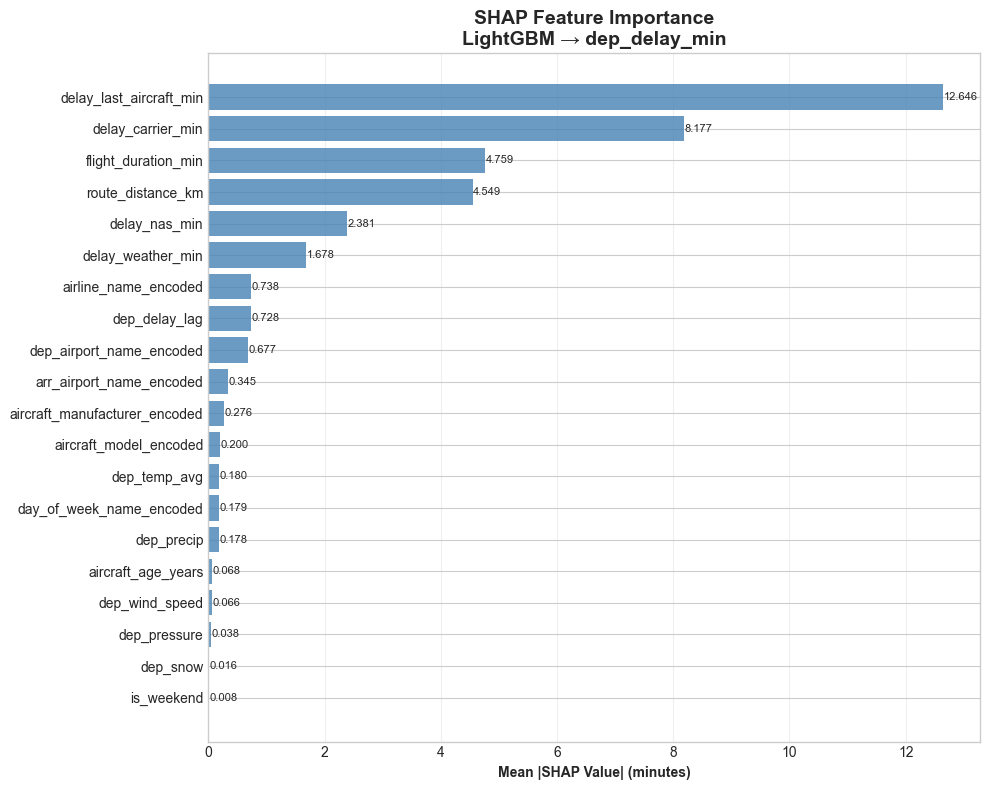

   💾 Saved: ./df-full_mod-full_ff/mod_png/_dep_shap_beeswarm.png


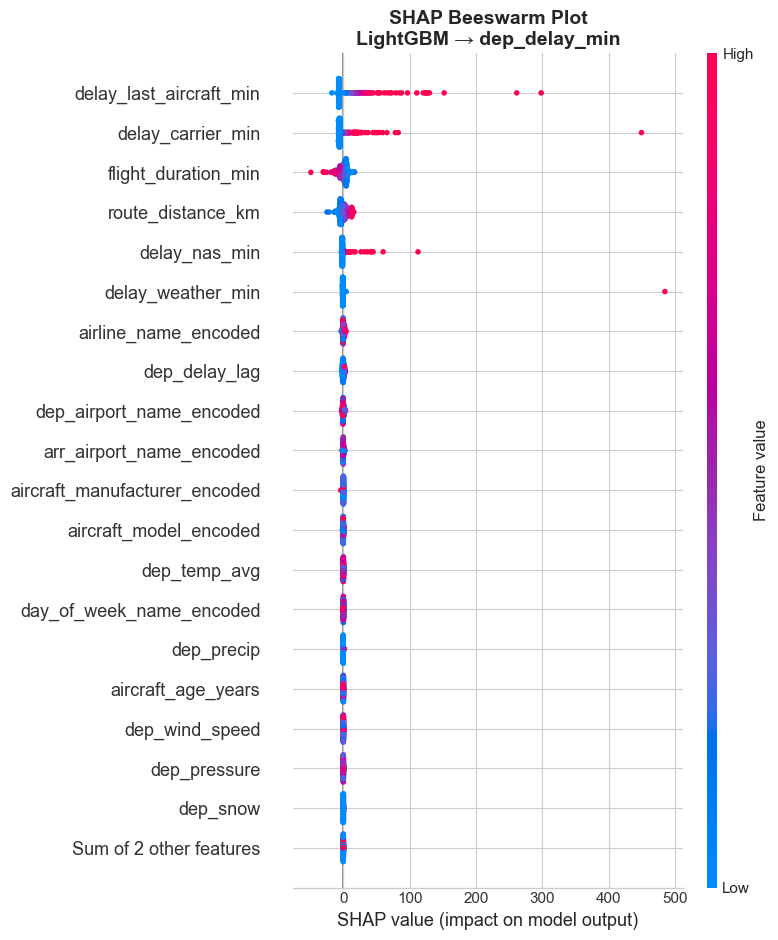

   💾 Saved: ./df-full_mod-full_ff/mod_png/_dep_shap_dependence.png


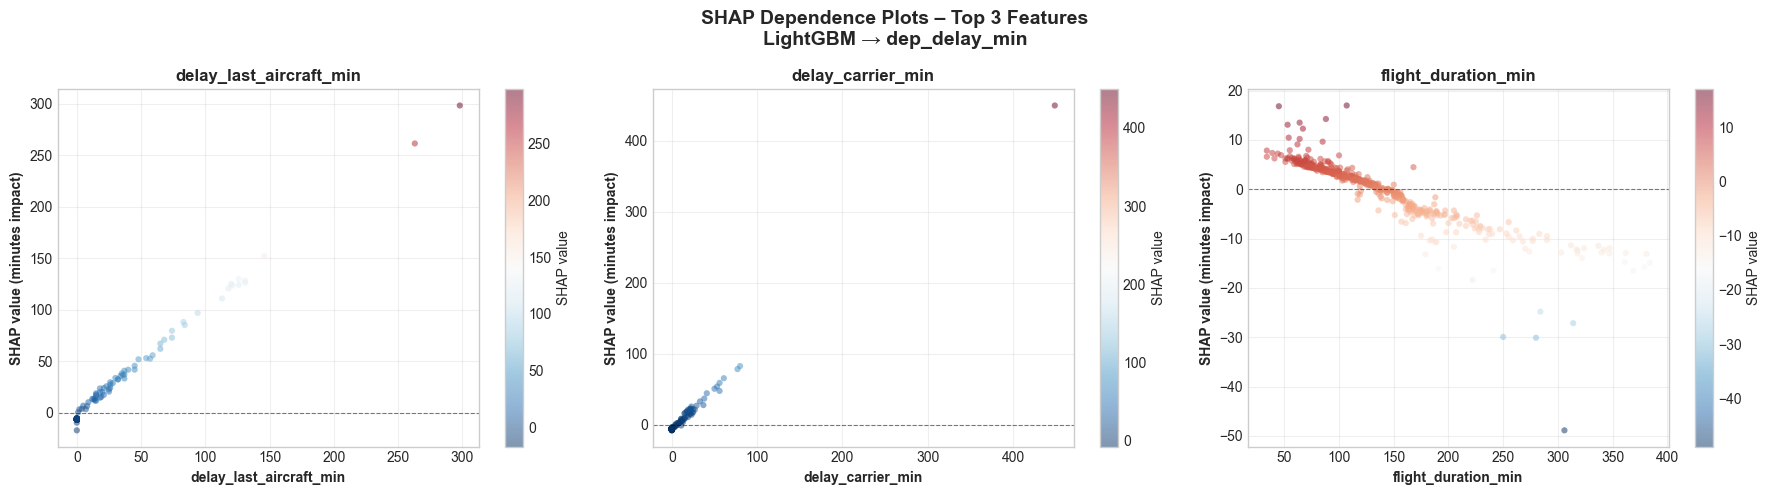

   💾 Saved: ./df-full_mod-full_ff/mod_png/_dep_shap_waterfall.png


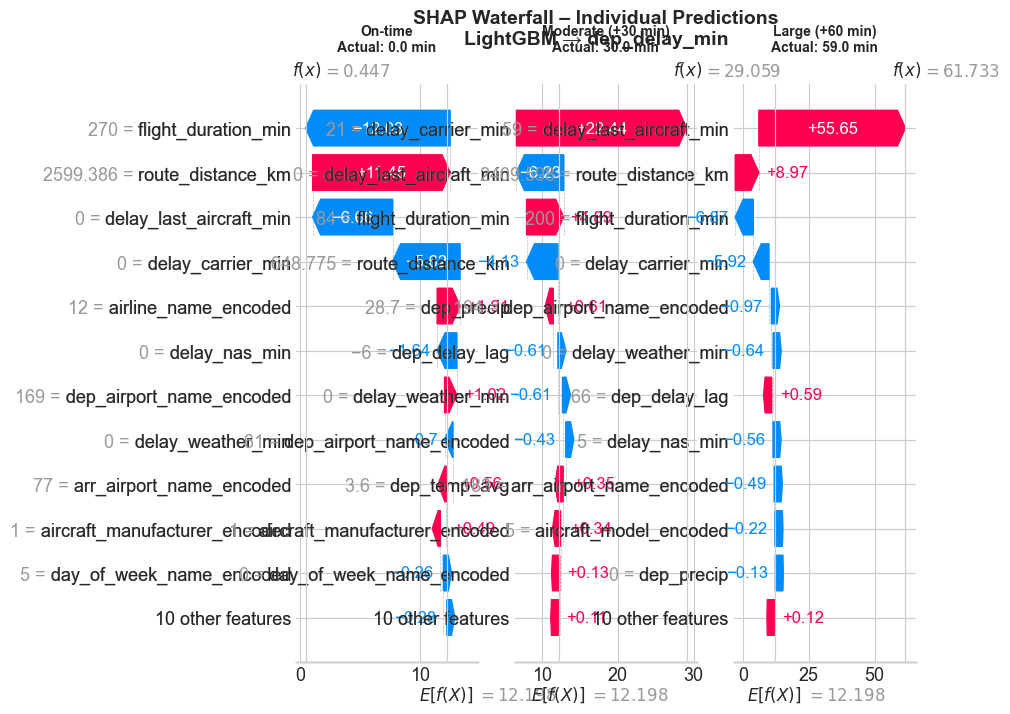

   💾 Saved: ./df-full_mod-full_ff/mod_png/_dep_shap_heatmap.png


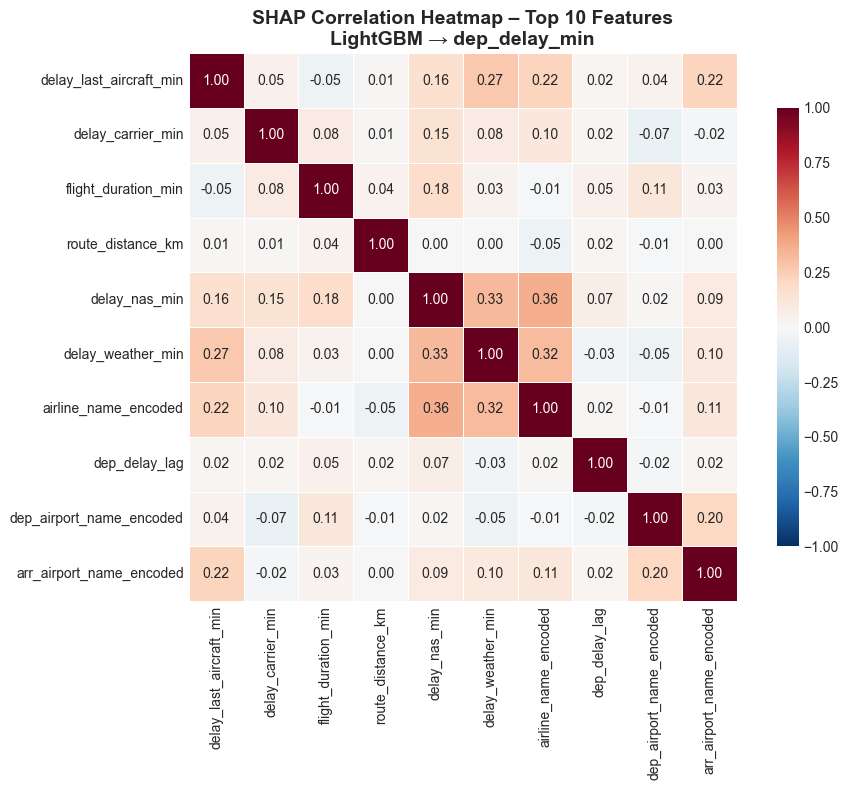


✅ SHAP analysis complete for LightGBM → dep_delay_min

📊 SHAP Analysis: LightGBM → arr_delay_min
   Using 500 test samples for SHAP computation...
   Model type detection: 'lgbmregressor' (from core model)
   Is tree-based: True
   Is linear: False
   Explainer type: TreeExplainer
   Computing SHAP values...
   ✅ SHAP values computed in 0.1s  |  shape: (500, 22)

   Top 10 features by mean |SHAP|:
                 Feature  Mean |SHAP|
           dep_delay_min    20.090487
       route_distance_km     7.422845
     flight_duration_min     7.111068
           delay_nas_min     4.215609
       delay_carrier_min     3.110916
 delay_last_aircraft_min     2.732564
dep_airport_name_encoded     1.953831
arr_airport_name_encoded     1.344029
    airline_name_encoded     1.149033
            arr_temp_avg     0.640756

   💾 Saved: ./df-full_mod-full_ff/mod_csv/_shap_importance_arr_delay_min_ff.csv
   💾 Saved: ./df-full_mod-full_ff/mod_png/_arr_shap_bar.png


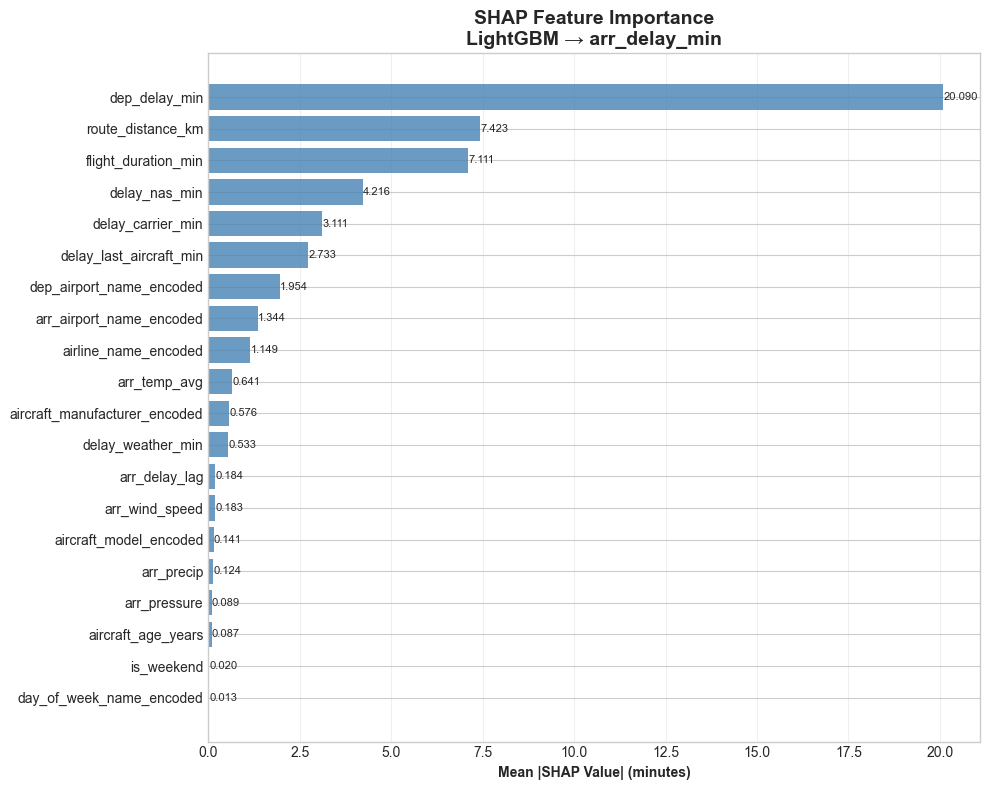

   💾 Saved: ./df-full_mod-full_ff/mod_png/_arr_shap_beeswarm.png


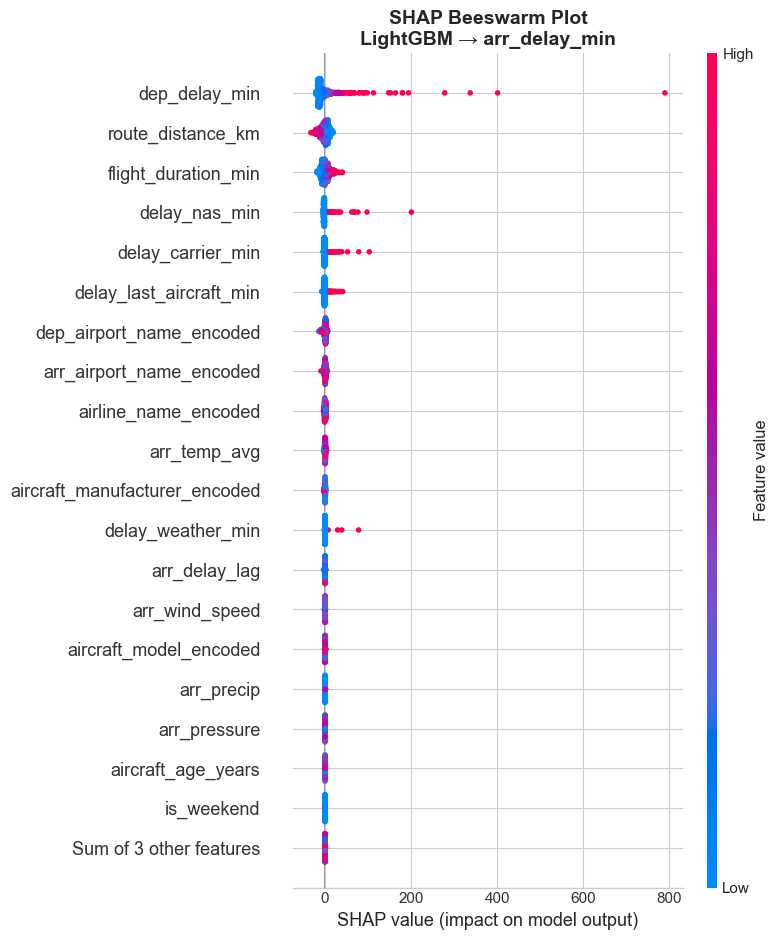

   💾 Saved: ./df-full_mod-full_ff/mod_png/_arr_shap_dependence.png


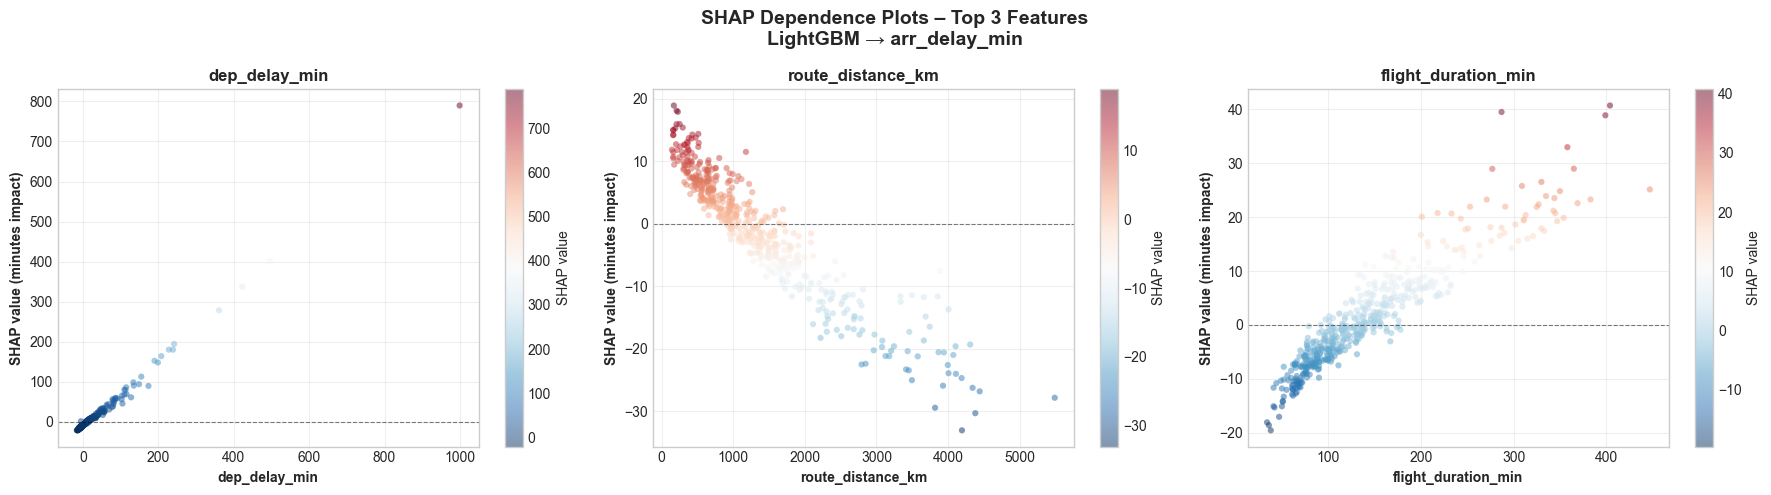

   💾 Saved: ./df-full_mod-full_ff/mod_png/_arr_shap_waterfall.png


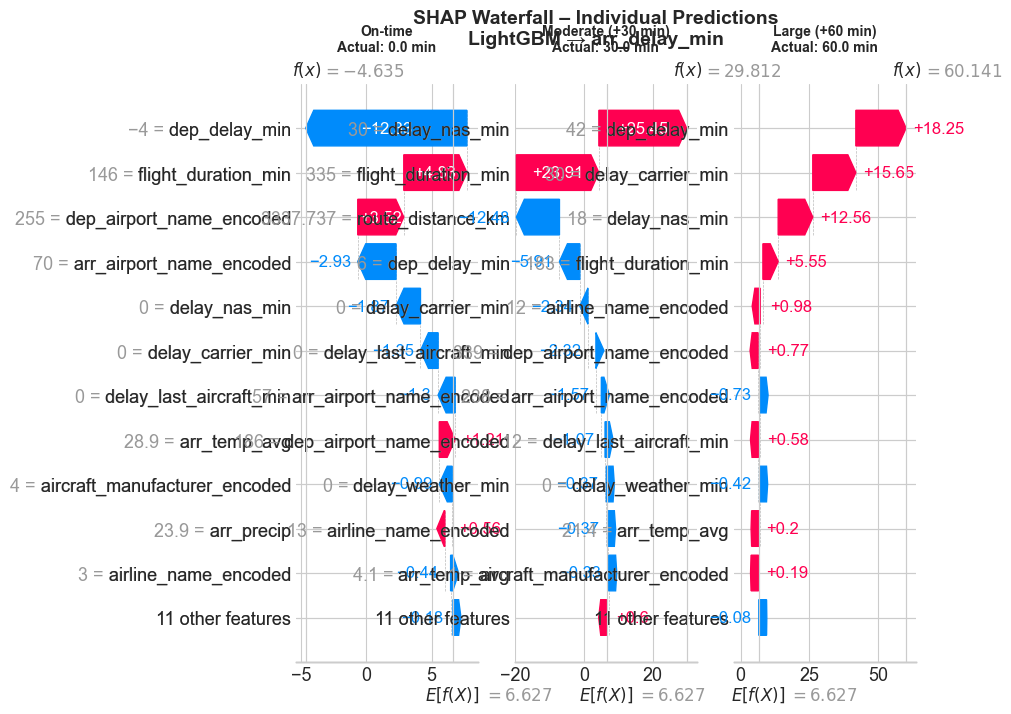

   💾 Saved: ./df-full_mod-full_ff/mod_png/_arr_shap_heatmap.png


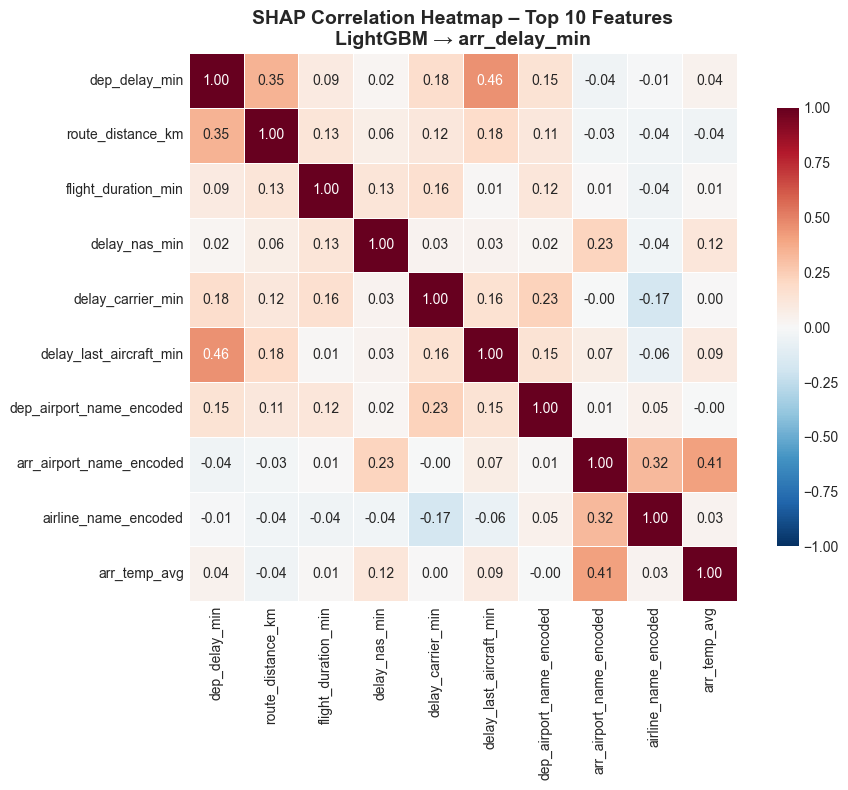


✅ SHAP analysis complete for LightGBM → arr_delay_min

📊 COMPARATIVE SHAP IMPORTANCE (DEP vs ARR)
💾 Saved: ./df-full_mod-full_ff/mod_png/shap_comparison.png


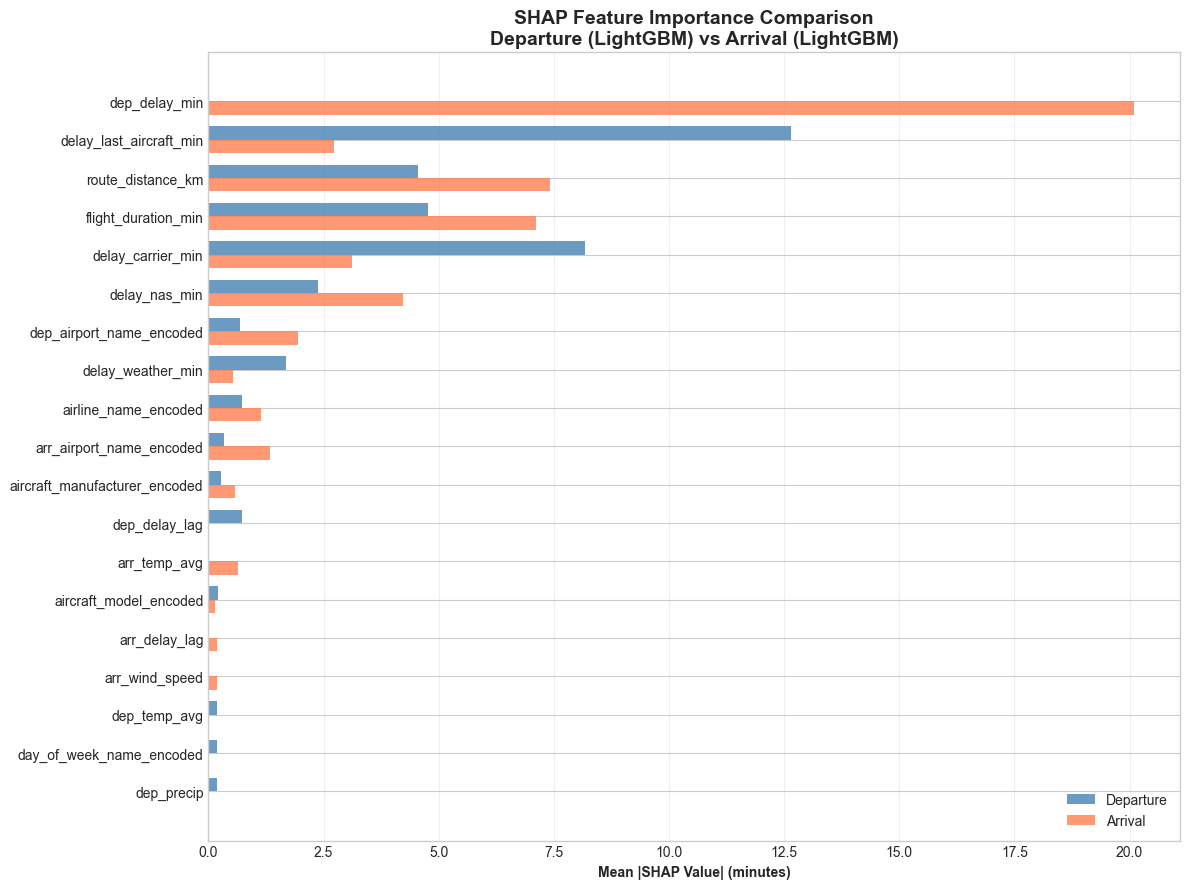

💾 Saved: ./df-full_mod-full_ff/mod_txt/_shap_analysis_ff.txt

✅ SHAP ANALYSIS COMPLETE

Files saved:
  PNG  → ./df-full_mod-full_ff/mod_png/_dep_shap_bar, _beeswarm, _dependence, _waterfall, _heatmap
  PNG  → ./df-full_mod-full_ff/mod_png/_arr_shap_bar, _beeswarm, _dependence, _waterfall, _heatmap
  PNG  → ./df-full_mod-full_ff/mod_png/_shap_comparison_ff.png
  CSV  → ./df-full_mod-full_ff/mod_csv/_shap_importance_dep_delay_min / arr_delay_min
  TXT  → ./df-full_mod-full_ff/mod_txt/_shap_analysis_ff.txt



In [95]:
# ============================================================================
# 23.0 SHAP ANALYSIS - Feature Importance & Model Explainability
# ============================================================================

print("\n" + "="*80)
print("🧠 SHAP ANALYSIS - MODEL EXPLAINABILITY")
print("="*80)

try:
    print(f"✅ SHAP version: {shap.__version__}")
except ImportError:
    print("⚠️  SHAP not installed.")

# ============================================================================
# SHAP HELPER: Detect explainer type based on model
# ============================================================================

def get_shap_explainer(model, X_background, model_name):
    """
    Automatically selects the right SHAP explainer for each model type.
    Handles Pipeline wrappers correctly.
    Returns (explainer, explainer_type_str)
    """
    model_lower = model_name.lower()
    
    def unwrap(m):
        """Recursively unwrap Pipeline to get the core estimator."""
        if isinstance(m, Pipeline):
            return unwrap(m.steps[-1][1])
        return m
    
    core_model = unwrap(model)
    
    # Check the actual model type, not just the name
    model_type = type(core_model).__name__.lower()
    
    # ── Tree-based models ───────────────────────────────────────────────────
    tree_based_keywords = ['lightgbm', 'lgbm', 
                           'xgboost', 'xgb',
                           'catboost',
                           'randomforest', 'random forest',
                           'extratrees', 'extra trees',
                           'gradientboosting', 'gradient boosting',
                           'decisiontree', 'decision tree',
                           'adaboost']
    
    linear_keywords = ['linear', 'ridge', 'lasso', 'elasticnet', 'elastic']
    
    # Check if it's a tree-based model (by type or name)
    is_tree_based = (
        any(kw in model_lower for kw in tree_based_keywords) or
        any(kw in model_type for kw in tree_based_keywords) or
        hasattr(core_model, 'feature_importances_') or # Tree models have this
        hasattr(core_model, 'trees_') or               # LightGBM/XGBoost
        hasattr(core_model, 'estimators_'))            # Random Forest/Extra Trees
    
    # Check if it's a linear model
    is_linear = (
        any(kw in model_lower for kw in linear_keywords) or
        any(kw in model_type for kw in linear_keywords) or
        hasattr(core_model, 'coef_'))  # Linear models have coefficients
    
    print(f"   Model type detection: '{model_type}' (from core model)")
    print(f"   Is tree-based: {is_tree_based}")
    print(f"   Is linear: {is_linear}")
    
    # ── Tree models → TreeExplainer ──────────────────────────────────────
    if is_tree_based:
        try:
            explainer = shap.TreeExplainer(core_model)
            return explainer, "TreeExplainer"
        except Exception as e:
            print(f"   ⚠️  TreeExplainer failed with: {repr(e)}")
            print(f"   ⚠️  TreeExplainer failed. Trying KernelExplainer...")

    # ── Linear models → LinearExplainer ──────────────────────────────────────
    elif is_linear:
        try:
            background = shap.maskers.Independent(X_background, max_samples=100)
            explainer  = shap.LinearExplainer(core_model, background)
            return explainer, "LinearExplainer"
        except Exception as e:
            print(f"   ⚠️  LinearExplainer failed with: {repr(e)}")
            print(f"   ⚠️  LinearExplainer failed. Trying KernelExplainer...")
    
    # ── Fallback → KernelExplainer ────────────────────────────────────────
    print("   Using KernelExplainer as fallback")
    background = shap.sample(X_background, min(100, len(X_background)))
    
    def safe_predict(X):
        """Wrap predict so SHAP never touches model internals."""
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X, columns=list(X_background.columns)
                             if isinstance(X_background, pd.DataFrame) else None)
        return model.predict(X)
    
    explainer = shap.KernelExplainer(safe_predict, background)
    return explainer, "KernelExplainer"

def run_shap_analysis(model, X_train, X_test, y_test,
                      feature_names, model_name, target_name,
                      save_prefix, n_samples=500):
    """
    Full SHAP analysis pipeline:
    1. Compute SHAP values
    2. Global feature importance bar plot
    3. Beeswarm (summary) plot
    4. Dependence plots for top features
    5. Waterfall plot for individual predictions
    6. Save all plots and return shap_values
    """
    
    print(f"\n{'='*60}")
    print(f"📊 SHAP Analysis: {model_name} → {target_name}")
    print(f"{'='*60}")
    
    # Use a stratified sample to keep it fast
    n_samples = min(n_samples, len(X_test))
    idx = np.random.choice(len(X_test), n_samples, replace=False)
    
    if isinstance(X_test, pd.DataFrame):
        X_sample = X_test.iloc[idx]
    else:
        X_sample = X_test[idx]
    
    print(f"   Using {n_samples} test samples for SHAP computation...")
    
    # ── Select explainer ──────────────────────────────────────────────────────
    explainer, explainer_type = get_shap_explainer(model, X_train, model_name)
    print(f"   Explainer type: {explainer_type}")
    
    # ── Compute SHAP values ───────────────────────────────────────────────────
    print("   Computing SHAP values...")
    start_shap = time.time()
    
    try:
        shap_values = explainer(X_sample)          # returns Explanation object
        shap_array  = shap_values.values           # (n_samples, n_features)
    except Exception:
        shap_values_raw = explainer.shap_values(X_sample)
        shap_array      = np.array(shap_values_raw)
        # Wrap into Explanation for newer SHAP plots
        shap_values = shap.Explanation(values        = shap_array,
                                       base_values   = explainer.expected_value,
                                       data          = X_sample.values if isinstance(X_sample, pd.DataFrame) else X_sample,
                                       feature_names = feature_names)
    
    elapsed = time.time() - start_shap
    print(f"   ✅ SHAP values computed in {elapsed:.1f}s  |  shape: {shap_array.shape}")
    
    # ── Mean absolute SHAP (global importance) ────────────────────────────────
    mean_abs_shap = np.abs(shap_array).mean(axis=0)
    shap_importance = pd.DataFrame({'Feature':    feature_names,
                                    'Mean |SHAP|': mean_abs_shap}
                                   ).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
    
    print(f"\n   Top 10 features by mean |SHAP|:")
    print(shap_importance.head(10).to_string(index=False))
    
    # ── Save importance CSV ───────────────────────────────────────────────────
    csv_path = f"{DIR_csv}_shap_importance_{target_name}_{MODEL_MAP}.csv"
    shap_importance.to_csv(csv_path, index=False)
    print(f"\n   💾 Saved: {csv_path}")
    
    # ─────────────────────────────────────────────────────────────────────────
    # PLOT 1 — Bar chart (global feature importance)
    # ─────────────────────────────────────────────────────────────────────────
    top_n = min(20, len(feature_names))
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = shap_importance.head(top_n)
    
    bars = ax.barh(range(top_n), top_features['Mean |SHAP|'], color='steelblue', alpha=0.8)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_features['Feature'])
    ax.invert_yaxis()                           # highest at top
    ax.set_xlabel('Mean |SHAP Value| (minutes)', fontweight='bold')
    ax.set_title(f'SHAP Feature Importance\n{model_name} → {target_name}',
                 fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, top_features['Mean |SHAP|']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    path = f"{DIR_png}{save_prefix}_shap_bar.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f"   💾 Saved: {path}")
    plt.show(); plt.close()
    
    # ─────────────────────────────────────────────────────────────────────────
    # PLOT 2 — Beeswarm / Summary plot
    # ─────────────────────────────────────────────────────────────────────────
    plt.figure(figsize=(12, 8))
    shap.plots.beeswarm(shap_values, max_display=top_n, show=False)
    plt.title(f'SHAP Beeswarm Plot\n{model_name} → {target_name}',
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    path = f"{DIR_png}{save_prefix}_shap_beeswarm.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f"   💾 Saved: {path}")
    plt.show(); plt.close()
    
    # ─────────────────────────────────────────────────────────────────────────
    # PLOT 3 — Dependence plots for top-3 features
    # ─────────────────────────────────────────────────────────────────────────
    top3_features = shap_importance.head(3)['Feature'].tolist()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'SHAP Dependence Plots – Top 3 Features\n{model_name} → {target_name}',
                 fontsize=14, fontweight='bold')
    
    for ax, feat in zip(axes, top3_features):
        feat_idx = list(feature_names).index(feat)
        
        if isinstance(X_sample, pd.DataFrame):
            x_vals = X_sample[feat].values
        else:
            x_vals = X_sample[:, feat_idx]
        
        shap_vals_feat = shap_array[:, feat_idx]
        
        sc = ax.scatter(x_vals, shap_vals_feat,
                        c=shap_vals_feat, cmap='RdBu_r',
                        alpha=0.5, s=20, edgecolors='none')
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.set_xlabel(feat, fontweight='bold')
        ax.set_ylabel('SHAP value (minutes impact)', fontweight='bold')
        ax.set_title(feat, fontweight='bold')
        ax.grid(alpha=0.3)
        plt.colorbar(sc, ax=ax, label='SHAP value')
    
    plt.tight_layout()
    path = f"{DIR_png}{save_prefix}_shap_dependence.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f"   💾 Saved: {path}")
    plt.show(); plt.close()
    
    # ─────────────────────────────────────────────────────────────────────────
    # PLOT 4 — Waterfall for 3 individual predictions
    # ─────────────────────────────────────────────────────────────────────────
    if isinstance(y_test, pd.Series):
        y_sample_vals = y_test.values[idx]
    else:
        y_sample_vals = np.array(y_test)[idx]
    
    # Select: on-time, moderate delay, large delay
    sample_indices = {'On-time':      np.argmin(np.abs(y_sample_vals)),
                      'Moderate (+30 min)': np.argmin(np.abs(y_sample_vals - 30)),
                      'Large (+60 min)':    np.argmin(np.abs(y_sample_vals - 60))}
    
    fig, axes = plt.subplots(1, 3, figsize=(36, 12))
    fig.suptitle(f'SHAP Waterfall – Individual Predictions\n{model_name} → {target_name}',
                 fontsize=14, fontweight='bold')
    
    for ax, (label, s_idx) in zip(axes, sample_indices.items()):
        plt.sca(ax)
        shap.plots.waterfall(shap_values[s_idx], max_display=12, show=False)
        ax.set_title(f'{label}\nActual: {y_sample_vals[s_idx]:.1f} min',
                     fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    path = f"{DIR_png}{save_prefix}_shap_waterfall.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f"   💾 Saved: {path}")
    plt.show(); plt.close()
    
    # ─────────────────────────────────────────────────────────────────────────
    # PLOT 5 — Heatmap of SHAP interactions (top 10 features)
    # ─────────────────────────────────────────────────────────────────────────
    top10_idx  = shap_importance.head(10).index.tolist()
    top10_names = shap_importance.head(10)['Feature'].tolist()
    shap_top10  = shap_array[:, top10_idx]
    
    # Correlation between SHAP vectors → proxy for interaction strength
    shap_corr = pd.DataFrame(shap_top10, columns=top10_names).corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(shap_corr, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, square=True,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    plt.title(f'SHAP Correlation Heatmap – Top 10 Features\n{model_name} → {target_name}',
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    path = f"{DIR_png}{save_prefix}_shap_heatmap.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f"   💾 Saved: {path}")
    plt.show(); plt.close()
    
    print(f"\n✅ SHAP analysis complete for {model_name} → {target_name}")
    
    return shap_values, shap_importance


# ============================================================================
# RUN SHAP FOR BOTH MODELS
# ============================================================================

shap_results = {}

if not PRETRAINED_MODE:
    # ── Departure ─────────────────────────────────────────────────────────────
    shap_dep, importance_dep = run_shap_analysis(
        model         = best_model_dep,
        X_train       = X_train_dep,
        X_test        = X_test_dep,
        y_test        = y_test_dep,
        feature_names = best_features_enc_dep,
        model_name    = best_model_name_dep,
        target_name   = 'dep_delay_min',
        save_prefix   = '_dep',
        n_samples     = 500)
    shap_results['dep'] = {'shap_values': shap_dep, 'importance': importance_dep}

    # ── Arrival ───────────────────────────────────────────────────────────────
    shap_arr, importance_arr = run_shap_analysis(
        model         = best_model_arr,
        X_train       = X_train_arr,
        X_test        = X_test_arr,
        y_test        = y_test_arr,
        feature_names = best_features_enc_arr,
        model_name    = best_model_name_arr,
        target_name   = 'arr_delay_min',
        save_prefix   = '_arr',
        n_samples     = 500)
    shap_results['arr'] = {'shap_values': shap_arr, 'importance': importance_arr}

else:
    # ── Pre-trained mode: use dataset sample ──────────────────────────────────
    print("🔄 Pre-trained mode: building feature matrix from dataset sample...")
    
    n_shap = min(2000, len(df_clean))
    sample = df_clean.sample(n=n_shap, random_state=42).copy()
    
    # Apply encoding
    for col in ['airline_name', 'dep_airport_name', 'arr_airport_name', 'day_of_week_name', 'aircraft_model', 'aircraft_manufacturer']:
        enc_col = f'{col}_encoded'
        if col in sample.columns and enc_col not in sample.columns:
            sample[enc_col] = best_lbl_enc[col].transform(sample[col].astype(str))
    
    if 'is_weekend' not in sample.columns:
        sample['is_weekend'] = sample['day_of_week_name'].isin(['Saturday', 'Sunday']).astype(int)

    if 'total_delay_history' not in sample.columns:
        sample['total_delay_history'] = (sample.get('delay_carrier_min', 0) +
                                         sample.get('delay_weather_min', 0) +
                                         sample.get('delay_nas_min',     0))
        
    if 'dep_delay_lag' not in sample.columns:
        sample['dep_delay_lag'] = 0

    if 'arr_delay_lag' not in sample.columns:
        sample['arr_delay_lag'] = 0
    
    X_shap_dep = sample[best_features_enc_dep].fillna(0)
    X_shap_arr = sample[best_features_enc_arr].fillna(0)
    y_shap_dep = sample['dep_delay_min']
    y_shap_arr = sample['arr_delay_min']
    
    split = int(0.8 * n_shap)
    
    shap_dep, importance_dep = run_shap_analysis(
        model         = best_model_dep,
        X_train       = X_shap_dep.iloc[:split],
        X_test        = X_shap_dep.iloc[split:],
        y_test        = y_shap_dep.iloc[split:],
        feature_names = best_features_enc_dep,
        model_name    = best_model_name_dep,
        target_name   = 'dep_delay_min',
        save_prefix   = '_dep',
        n_samples     = min(400, n_shap - split))
    shap_results['dep'] = {'shap_values': shap_dep, 'importance': importance_dep}
    
    shap_arr, importance_arr = run_shap_analysis(
        model         = best_model_arr,
        X_train       = X_shap_arr.iloc[:split],
        X_test        = X_shap_arr.iloc[split:],
        y_test        = y_shap_arr.iloc[split:],
        feature_names = best_features_enc_arr,
        model_name    = best_model_name_arr,
        target_name   = 'arr_delay_min',
        save_prefix   = '_arr',
        n_samples     = min(400, n_shap - split))
    shap_results['arr'] = {'shap_values': shap_arr, 'importance': importance_arr}


# ============================================================================
# COMPARATIVE SHAP IMPORTANCE (Departure vs Arrival side-by-side)
# ============================================================================

print("\n" + "="*60)
print("📊 COMPARATIVE SHAP IMPORTANCE (DEP vs ARR)")
print("="*60)

top_n = 15
imp_dep_top = importance_dep.head(top_n).set_index('Feature')['Mean |SHAP|']
imp_arr_top = importance_arr.head(top_n).set_index('Feature')['Mean |SHAP|']

all_feats = sorted(set(imp_dep_top.index) | set(imp_arr_top.index),
                   key=lambda f: imp_dep_top.get(f, 0) + imp_arr_top.get(f, 0),
                   reverse=True)

dep_vals = [imp_dep_top.get(f, 0) for f in all_feats]
arr_vals = [imp_arr_top.get(f, 0) for f in all_feats]

fig, ax = plt.subplots(figsize=(12, 9))
y = np.arange(len(all_feats))
h = 0.35

ax.barh(y - h/2, dep_vals, h, label='Departure', color='steelblue', alpha=0.8)
ax.barh(y + h/2, arr_vals, h, label='Arrival',   color='coral',     alpha=0.8)

ax.set_yticks(y)
ax.set_yticklabels(all_feats)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP Value| (minutes)', fontweight='bold')
ax.set_title(f'SHAP Feature Importance Comparison\nDeparture ({best_model_name_dep}) vs Arrival ({best_model_name_arr})',
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
path = f"{DIR_png}shap_comparison.png"
plt.savefig(path, dpi=150, bbox_inches='tight')
print(f"💾 Saved: {path}")
plt.show(); plt.close()


# ============================================================================
# SAVE SHAP SUMMARY TO TXT
# ============================================================================

shap_report = f"""
SHAP ANALYSIS REPORT
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*60}

DEPARTURE MODEL: {best_model_name_dep}
Top 10 features by mean |SHAP|:
{importance_dep.head(10).to_string(index=False)}

ARRIVAL MODEL: {best_model_name_arr}
Top 10 features by mean |SHAP|:
{importance_arr.head(10).to_string(index=False)}

{'='*60}
INTERPRETATION:
- SHAP values express each feature's contribution in MINUTES of delay.
- Positive SHAP → feature increases predicted delay.
- Negative SHAP → feature decreases predicted delay.
- Mean |SHAP| = average magnitude of impact across all test flights.
"""

txt_path = f"{DIR_txt}_shap_analysis_{MODEL_MAP}.txt"
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write(shap_report)
print(f"💾 Saved: {txt_path}")

print("\n" + "="*80)
print("✅ SHAP ANALYSIS COMPLETE")
print("="*80)
print(f"""
Files saved:
  PNG  → {DIR_png}_dep_shap_bar, _beeswarm, _dependence, _waterfall, _heatmap
  PNG  → {DIR_png}_arr_shap_bar, _beeswarm, _dependence, _waterfall, _heatmap
  PNG  → {DIR_png}_shap_comparison_{MODEL_MAP}.png
  CSV  → {DIR_csv}_shap_importance_dep_delay_min / arr_delay_min
  TXT  → {txt_path}
""")

In [96]:
# ============================================================================
# 23.1 CREATE REUSABLE SHAP EXPLAINERS FOR GRADIO
# ============================================================================

print("\n" + "="*60)
print("🔄 CREATING REUSABLE SHAP EXPLAINERS")
print("="*60)

def create_shap_explainer(model, X_background, model_name):
    """Create a SHAP explainer that can be reused for predictions"""
    try:
        # Extract the actual model if it's wrapped in a Pipeline
        if hasattr(model, 'named_steps'):
            # It's a Pipeline - get the final estimator
            core_model = model.named_steps[list(model.named_steps.keys())[-1]]
            print(f"   Unwrapped Pipeline → {type(core_model).__name__}")
        else:
            core_model = model
        
        # Try TreeExplainer for tree-based models
        tree_keywords = ['lightgbm', 'lgbm', 'xgboost', 'xgb', 'catboost', 
                        'randomforest', 'random forest', 'extratrees', 'extra trees',
                        'gradientboosting', 'gradient boosting', 'decisiontree', 
                        'decision tree', 'adaboost']
        
        model_lower = model_name.lower()
        core_type = type(core_model).__name__.lower()
        
        if any(kw in model_lower for kw in tree_keywords) or any(kw in core_type for kw in tree_keywords):
            print(f"   Using TreeExplainer for {model_name}")
            explainer = shap.TreeExplainer(core_model)
            return explainer
        
        # Try LinearExplainer for linear models
        linear_keywords = ['linear', 'ridge', 'lasso', 'elasticnet']
        if any(kw in model_lower for kw in linear_keywords) or any(kw in core_type for kw in linear_keywords):
            print(f"   Using LinearExplainer for {model_name}")
            background_sample = shap.sample(X_background, min(100, len(X_background)))
            explainer = shap.LinearExplainer(core_model, background_sample)
            return explainer
        
        # Fallback to KernelExplainer with the original model (Pipeline works here)
        print(f"   Using KernelExplainer for {model_name}")
        background_sample = shap.sample(X_background, min(100, len(X_background)))
        
        # For KernelExplainer, we need to use the full Pipeline's predict method
        explainer = shap.KernelExplainer(model.predict, background_sample)
        return explainer
        
    except Exception as e:
        print(f"   ⚠️ Could not create explainer: {e}")
        
        traceback.print_exc()
        return None

# Create background datasets for SHAP
n_background = min(500, len(data_cleaned))
background_data = data_cleaned.sample(n=n_background, random_state=42)

# Prepare background data with proper encoding
background_encoded = background_data.copy()
for col in categorical_cols:
    enc_col = f'{col}_encoded'
    if enc_col not in background_encoded.columns:
        background_encoded[enc_col] = best_lbl_enc[col].transform(
            background_encoded[col].astype(str))

# Add engineered features if missing
if 'is_weekend' not in background_encoded.columns:
    background_encoded['is_weekend'] = background_encoded['day_of_week_name'].isin(['Saturday', 'Sunday']).astype(int)
if 'total_delay_history' not in background_encoded.columns:
    background_encoded['total_delay_history'] = 0
if 'dep_delay_lag' not in background_encoded.columns:
    background_encoded['dep_delay_lag'] = 0
if 'arr_delay_lag' not in background_encoded.columns:
    background_encoded['arr_delay_lag'] = 0

# Create background feature matrices
X_background_dep = background_encoded[best_features_enc_dep].fillna(0)
X_background_arr = background_encoded[best_features_enc_arr].fillna(0)

# Create the reusable explainers
shap_explainer_dep = create_shap_explainer(best_model_dep, X_background_dep, best_model_name_dep)
shap_explainer_arr = create_shap_explainer(best_model_arr, X_background_arr, best_model_name_arr)

# Save explainers for later use
joblib.dump(shap_explainer_dep, MODEL_FILES + 'shap_explainer_dep.pkl')
joblib.dump(shap_explainer_arr, MODEL_FILES + 'shap_explainer_arr.pkl')
print(f"\n✅ SHAP explainers saved to {MODEL_FILES}")


🔄 CREATING REUSABLE SHAP EXPLAINERS
   Using TreeExplainer for LightGBM
   Using TreeExplainer for LightGBM

✅ SHAP explainers saved to ./df-full_mod-full_ff/


In [97]:
# ============================================================================
# 23.2 FUNCTION TO GENERATE SHAP EXPLANATIONS FOR SINGLE PREDICTION
# ============================================================================

def generate_shap_explanation_single(explainer, input_features, feature_names, 
                             prediction_value, target_name, save_path=None):
    """
    Generate SHAP explanation for a single prediction
    
    Parameters:
    -----------
    explainer : SHAP explainer object
    input_features : array-like, the input features for this prediction
    feature_names : list, names of features
    prediction_value : float, the model's prediction
    target_name : str, 'departure' or 'arrival'
    save_path : str, optional path to save the plot
    
    Returns:
    --------
    HTML string with the SHAP plot or error message
    """
    try:
        # Convert input to correct format
        if isinstance(input_features, dict):
            input_df = pd.DataFrame([input_features])[feature_names]
            input_array = input_df.values
        else:
            input_array = np.array(input_features).reshape(1, -1)
            input_df = pd.DataFrame(input_array, columns=feature_names)
        
        # Calculate SHAP values
        shap_values = explainer.shap_values(input_array)
        
        # Create bar chart for feature importance
        plt.figure(figsize=(12, 8))
        
        # Calculate mean absolute SHAP values for features
        shap_importance = pd.DataFrame({
            'Feature': feature_names,
            'Mean |SHAP|': np.abs(shap_values[0])
        }).sort_values('Mean |SHAP|', ascending=True)
        
        # Plot top features
        top_n = min(20, len(feature_names))
        top_features = shap_importance.tail(top_n)
        
        # Create horizontal bar chart
        bars = plt.barh(range(top_n), top_features['Mean |SHAP|'], 
                       color='steelblue', alpha=0.8)
        plt.yticks(range(top_n), top_features['Feature'])
        plt.xlabel('|SHAP Value| (minutes)', fontweight='bold')
        plt.title(f"SHAP Feature Importance - {target_name} Delay\nPrediction: {prediction_value:.1f} minutes", 
                 fontsize=14, fontweight='bold')
        
        # Add value labels on bars
        for bar, val in zip(bars, top_features['Mean |SHAP|']):
            plt.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=9)
        
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        
        # Convert plot to base64 string (embedded in HTML, no file needed)
        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
        plt.close()
        buf.seek(0)
        img_str = base64.b64encode(buf.read()).decode()
        
        # Return HTML with embedded base64 image
        html_output = f'''
        <div style="margin: 20px 0; padding: 15px; background-color: #f8f9fa; border-radius: 8px;">
            <h4 style="color: #2c3e50; margin-top: 0;">🔍 SHAP Analysis - {target_name} Delay</h4>
            <p style="color: #34495e; margin-bottom: 15px;">
                <strong>Prediction:</strong> {prediction_value:.1f} minutes<br>
                <strong>Base Value:</strong> {explainer.expected_value:.2f} minutes
            </p>
            <div style="text-align: center;">
                <img src="data:image/png;base64,{img_str}" 
                     style="width:100%; max-width:800px; border-radius: 5px; box-shadow: 0 4px 8px rgba(0,0,0,0.1);">
            </div>
            <p style="color: #7f8c8d; font-size: 0.9em; margin-top: 10px;">
                <strong>How to interpret:</strong> Bars show the magnitude of each feature's impact on the prediction. 
                Larger bars indicate features that contributed more to this specific prediction.
            </p>
        </div>
        '''
        
        return html_output            
    except Exception as e:
        print(f"SHAP generation error: {e}")
        return f"<p style='color:red'>SHAP Error: {str(e)}</p>"

In [98]:
# ============================================================================
# 23.2 FUNCTION TO GENERATE SHAP EXPLANATIONS FOR SINGLE PREDICTION
# ============================================================================

def generate_shap_explanation_specialized(explainer, input_features, feature_names, 
                             prediction_value, target_name, save_path=None):
    """
    Generate SHAP explanation for a single prediction
    
    Parameters:
    -----------
    explainer : SHAP explainer object
    input_features : array-like, the input features for this prediction
    feature_names : list, names of features
    prediction_value : float, the model's prediction
    target_name : str, 'departure' or 'arrival'
    save_path : str, optional path to save the plot
    
    Returns:
    --------
    HTML string with the SHAP plot or error message
    """
    try:
        # Convert input to correct format
        if isinstance(input_features, dict):
            input_df = pd.DataFrame([input_features])[feature_names]
            input_array = input_df.values
        else:
            input_array = np.array(input_features).reshape(1, -1)
            input_df = pd.DataFrame(input_array, columns=feature_names)
        
        # Calculate SHAP values
        shap_values = explainer.shap_values(input_array)
        
        # Create waterfall plot
        plt.figure(figsize=(12, 8))
        
        # Create Explanation object
        exp = shap.Explanation(
            values=shap_values[0],
            base_values=explainer.expected_value if hasattr(explainer, 'expected_value') else 0,
            data=input_array[0],
            feature_names=feature_names
        )
        
        # Plot
        shap.waterfall_plot(exp, max_display=12, show=False)
        plt.title(f"SHAP Explanation - {target_name} Delay\nPrediction: {prediction_value:.1f} minutes", 
                 fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        # Convert plot to base64 string (embedded in HTML, no file needed)
        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
        plt.close()
        buf.seek(0)
        img_str = base64.b64encode(buf.read()).decode()
        
        # Return HTML with embedded base64 image
        html_output = f'''
        <div style="margin: 20px 0; padding: 15px; background-color: #f8f9fa; border-radius: 8px;">
            <h4 style="color: #2c3e50; margin-top: 0;">🔍 SHAP Analysis - {target_name} Delay</h4>
            <p style="color: #34495e; margin-bottom: 15px;">
                <strong>Prediction:</strong> {prediction_value:.1f} minutes<br>
                <strong>Base Value:</strong> {explainer.expected_value:.2f} minutes
            </p>
            <div style="text-align: center;">
                <img src="data:image/png;base64,{img_str}" 
                     style="width:100%; max-width:800px; border-radius: 5px; box-shadow: 0 4px 8px rgba(0,0,0,0.1);">
            </div>
            <p style="color: #7f8c8d; font-size: 0.9em; margin-top: 10px;">
                <strong>How to interpret:</strong> Red bars push prediction higher (more delay), 
                blue bars push prediction lower (less delay). The base value is the average prediction.
            </p>
        </div>
        '''
        
        return html_output            
    except Exception as e:
        print(f"SHAP generation error: {e}")
        return f"<p style='color:red'>SHAP Error: {str(e)}</p>"

In [99]:
# ============================================================================
# 24. SAVE ESSENTIAL DEPLOYMENT FILES (REFERENCE TO EXISTING MODELS)
# ============================================================================
if not PRETRAINED_MODE:
    print("\n" + "="*60)
    print("💾 SAVING ALL MODEL ARTIFACTS FILES, ESSENTIAL for DEPLOYMENT")
    print("="*60)

    # Save only what's NOT already saved in sections 9 and 10

    # Save ALL trained models (not just best)
    joblib.dump(trained_models_dep, MODEL_FILES+'all_models_dep.pkl')
    joblib.dump(trained_models_arr, MODEL_FILES+'all_models_arr.pkl')
    print("0 ✅ Saved: "+MODEL_FILES+"all_models_dep.pkl (all departure models)")
    print("1 ✅ Saved: "+MODEL_FILES+"all_models_arr.pkl (all arrival models)")

    # 1. Label encoders (essential for deployment)
    joblib.dump(best_lbl_enc, MODEL_FILES+'best_lbl_enc.pkl')
    print("2 ✅ Saved: "+MODEL_FILES+"best_lbl_enc.pkl")

    # 2. Feature lists (essential for deployment)
    joblib.dump(best_features_enc_dep, MODEL_FILES+'features_dep.pkl')
    joblib.dump(best_features_enc_arr, MODEL_FILES+'features_arr.pkl')
    print("3 ✅ Saved: "+MODEL_FILES+"features_dep.pkl")
    print("4 ✅ Saved: "+MODEL_FILES+"features_arr.pkl")

    # 3. Save the best models
    joblib.dump(best_model_dep, MODEL_FILES+'best_model_dep.pkl')
    joblib.dump(best_model_arr, MODEL_FILES+'best_model_arr.pkl')
    print("5 ✅ Saved: "+MODEL_FILES+"best_model_dep.pkl")
    print("6 ✅ Saved: "+MODEL_FILES+"best_model_arr.pkl")

    # 4. Create a SIMPLE index file that references what's already saved
    best_model_index = {
        'timestamp': time.strftime('%Y-%m-%d %H:%M:%S'),
        'best_models': {'departure': {'name':            best_model_name_dep,
                                      'metadata_file':   f"dep_metadata_{best_model_name_dep.lower().replace(' ', '_')}.pkl",
                                      'package_file':    f"dep_model_package_{best_model_name_dep.lower().replace(' ', '_')}.pkl",
                                      'best_model_file': 'best_model_dep.pkl'},

                        'arrival': {'name':            best_model_name_arr,
                                    'metadata_file':   f"arr_metadata_{best_model_name_arr.lower().replace(' ', '_')}.pkl",
                                    'package_file':    f"arr_model_package_{best_model_name_arr.lower().replace(' ', '_')}.pkl",
                                    'best_model_file': 'best_model_arr.pkl'}},

        'total_models_evaluated': len(model_map),
        'note': 'Individual best model files and metadata files are saved separately.'}

    joblib.dump(best_model_index, MODEL_FILES+'best_model_index.pkl')
    print("7 ✅ Saved: "+MODEL_FILES+"best_model_index.pkl")
    # 5. Save CSV comparison results (optional, for human reading)
    df_results_dep.to_csv(DIR_csv + '_model_comparison_dep.csv', index=False)
    df_results_arr.to_csv(DIR_csv + '_model_comparison_arr.csv', index=False)
    print("8 ✅ Saved: " + DIR_csv + "_model_comparison_dep.csv")
    print("9 ✅ Saved: " + DIR_csv + "_model_comparison_arr.csv")

    print(f"\n✅ All files saved to: {MODEL_FILES}")


💾 SAVING ALL MODEL ARTIFACTS FILES, ESSENTIAL for DEPLOYMENT
0 ✅ Saved: ./df-full_mod-full_ff/all_models_dep.pkl (all departure models)
1 ✅ Saved: ./df-full_mod-full_ff/all_models_arr.pkl (all arrival models)
2 ✅ Saved: ./df-full_mod-full_ff/best_lbl_enc.pkl
3 ✅ Saved: ./df-full_mod-full_ff/features_dep.pkl
4 ✅ Saved: ./df-full_mod-full_ff/features_arr.pkl
5 ✅ Saved: ./df-full_mod-full_ff/best_model_dep.pkl
6 ✅ Saved: ./df-full_mod-full_ff/best_model_arr.pkl
7 ✅ Saved: ./df-full_mod-full_ff/best_model_index.pkl
8 ✅ Saved: ./df-full_mod-full_ff/mod_csv/_model_comparison_dep.csv
9 ✅ Saved: ./df-full_mod-full_ff/mod_csv/_model_comparison_arr.csv

✅ All files saved to: ./df-full_mod-full_ff/


In [100]:
# ============================================================================
# 25. SAVE COMPLETE MODEL REGISTRY
# ============================================================================
if not PRETRAINED_MODE:
    print("\n" + "="*80)
    print("💾 SAVING COMPLETE MODEL REGISTRY")
    print("="*80)

    # Get best model names
    #best_model_name_dep = df_results_dep.iloc[0]['Model']
    #best_model_name_arr = df_results_arr.iloc[0]['Model']

    # Update 'is_best' flags in metadata
    all_metadata_dep[best_model_name_dep]['status']['is_best'] = True
    all_metadata_arr[best_model_name_arr]['status']['is_best'] = True

    # Create COMPLETE registry
    complete_registry = {
        # High-level summary
        'summary': {'total_models': len(trained_models_dep) + len(trained_models_arr),
                    'departure_models_count': len(trained_models_dep),
                    'arrival_models_count': len(trained_models_arr),
                    'best_departure': best_model_name_dep,
                    'best_arrival': best_model_name_arr,
                    'created_date': datetime.now().isoformat(),
                    'dataset_path': VUELOS,
                    'dataset_size': len(df_clean)},
        
        # Shared resources reference
        'shared_resources': {'path': DIR_models_shared + 'shared_resources.pkl',
                             'label_encoders_path': DIR_models_shared + 'label_encoders.pkl',
                             'features_dep': best_features_enc_dep,
                             'features_arr': best_features_enc_arr,
                             'categorical_cols': categorical_cols},
        
        # DETAILED INFO FOR EVERY DEPARTURE MODEL
        'departure_models': all_metadata_dep,
        
        # DETAILED INFO FOR EVERY ARRIVAL MODEL
        'arrival_models': all_metadata_arr,
        
        # Quick access shortcuts
        'shortcuts': {
            'best_departure_path': DIR_models_dep + best_model_name_dep.lower().replace(' ', '_') + '.pkl',
            'best_arrival_path': DIR_models_arr + best_model_name_arr.lower().replace(' ', '_') + '.pkl',
            'production_ready_dep': [
                name for name, info in all_metadata_dep.items() 
                if info.get('status', {}).get('is_production_ready', False)
            ],
            'production_ready_arr': [
                name for name, info in all_metadata_arr.items() 
                if info.get('status', {}).get('is_production_ready', False)
            ]
        }
    }

    # Save the complete registry
    joblib.dump(complete_registry, MODEL_FILES + 'COMPLETE_model_registry.pkl')
    print(f"✅ Saved: {MODEL_FILES}COMPLETE_model_registry.pkl")
    print(f"   Contains detailed info for all {len(trained_models_dep) + len(trained_models_arr)} models")
    print(f"   Same structure for every model (best or not)")

    # Save a simplified "best only" version for quick production use
    production_registry = {
        'deployment_ready': True,
        'created_date': datetime.now().isoformat(),
        'departure': all_metadata_dep[best_model_name_dep],
        'arrival': all_metadata_arr[best_model_name_arr],
        'shared_resources': {
            'path': DIR_models_shared + 'shared_resources.pkl',
            'label_encoders_path': DIR_models_shared + 'label_encoders.pkl'
        }
    }

    joblib.dump(production_registry, MODEL_FILES + 'PRODUCTION_model_registry.pkl')
    print(f"✅ Saved: {MODEL_FILES}PRODUCTION_model_registry.pkl")
    print(f"   Contains detailed info for 2 best models only")

    # Save shared resources
    shared_resources = {
        'label_encoders':   best_lbl_enc,
        'features_dep':     best_features_enc_dep,
        'features_arr':     best_features_enc_arr,
        'categorical_cols': categorical_cols
    }
    joblib.dump(shared_resources, DIR_models_shared + 'shared_resources.pkl')
    joblib.dump(best_lbl_enc, DIR_models_shared + 'label_encoders.pkl')
    print(f"✅ Saved shared resources")

    # Save comparison CSVs
    df_results_dep.to_csv(DIR_csv + '_model_comparison_dep.csv', index=False)
    df_results_arr.to_csv(DIR_csv + '_model_comparison_arr.csv', index=False)
    print(f"✅ Saved comparison CSVs")

    print("\n" + "="*80)
    print("📊 FILE STRUCTURE SUMMARY")
    print("="*80)
    print(f"""
{MODEL_FILES}
├── departure_models/
│   ├── lightgbm.pkl
│   ├── lightgbm_metadata.pkl
│   ├── lightgbm_lbl_enc.pkl
│   ├── lightgbm_features_enc.pkl
│   └── ... ({len(trained_models_dep)} models × 4 files each)
│
├── arrival_models/
│   └── ... ({len(trained_models_arr)} models × 4 files each)
│
├── shared/
│   ├── shared_resources.pkl
│   └── label_encoders.pkl
│
├── COMPLETE_model_registry.pkl  ← ALL {len(trained_models_dep) + len(trained_models_arr)} models (detailed info)
├── PRODUCTION_model_registry.pkl ← BEST 2 models (same detailed structure)
│
├── txt/
│   ├── .txt
│   └── .txt
│
├── png/
│   ├── .png
│   └── .png
└── csv/
   ├──_model_comparison_dep.csv
   └──_model_comparison_arr.csv

TOTAL: {len(trained_models_dep) * 4 + len(trained_models_arr) * 4 + 6} files
""")


💾 SAVING COMPLETE MODEL REGISTRY
✅ Saved: ./df-full_mod-full_ff/COMPLETE_model_registry.pkl
   Contains detailed info for all 26 models
   Same structure for every model (best or not)
✅ Saved: ./df-full_mod-full_ff/PRODUCTION_model_registry.pkl
   Contains detailed info for 2 best models only
✅ Saved shared resources
✅ Saved comparison CSVs

📊 FILE STRUCTURE SUMMARY

./df-full_mod-full_ff/
├── departure_models/
│   ├── lightgbm.pkl
│   ├── lightgbm_metadata.pkl
│   ├── lightgbm_lbl_enc.pkl
│   ├── lightgbm_features_enc.pkl
│   └── ... (13 models × 4 files each)
│
├── arrival_models/
│   └── ... (13 models × 4 files each)
│
├── shared/
│   ├── shared_resources.pkl
│   └── label_encoders.pkl
│
├── COMPLETE_model_registry.pkl  ← ALL 26 models (detailed info)
├── PRODUCTION_model_registry.pkl ← BEST 2 models (same detailed structure)
│
├── txt/
│   ├── .txt
│   └── .txt
│
├── png/
│   ├── .png
│   └── .png
└── csv/
   ├──_model_comparison_dep.csv
   └──_model_comparison_arr.csv

TOTAL: 11

In [101]:
print(MODEL_FILES)

./df-full_mod-full_ff/


In [102]:
# ============================================================================
# 26 ROUTE DISTANCE Checkpoint
# ============================================================================
print("="*60)
print("📏 ROUTES DISTANCE Checkpoint")
print("="*60)

if 'route_distance_km' in data_cleaned.columns:
    print(f"✅ Airports distance from {len(data_cleaned):,} flights\n")
    print(f"Min....... {data_cleaned['route_distance_km'].min():>8,.2f} Km")
    print(f"Mean...... {data_cleaned['route_distance_km'].mean():>8,.2f} Km")
    print(f"Max....... {data_cleaned['route_distance_km'].max():>8,.2f} Km\n")

    missing = data_cleaned['route_distance_km'].isna().sum()
    if missing == 0:
        print(f"No Missing values found!")
    else:
        print(f"⚠️ WARNING: {missing} missing values found in route_distance_km")
else:
    print(f"❌ ERROR: route_distance_km not found in dataset!")

📏 ROUTES DISTANCE Checkpoint
✅ Airports distance from 6,743,373 flights

Min.......    33.98 Km
Mean...... 1,341.14 Km
Max....... 8,186.24 Km

No Missing values found!


In [103]:
# ============================================================================
# 27 BIAS INFO FUNCTION - Find the exact bias in your model - for INFO Only
# ============================================================================

def calibrate_model_bias(model, X_test, y_test, target_name="departure"):
    """
    Calculate how many minutes the model over-predicts for on-time flights.
    This will be used to correct predictions in the interface.
    """
    print(f"\n🔍 Calibrating {target_name} model bias...")
    
    # Get predictions on test set
    y_pred = model.predict(X_test)
    
    # Focus on flights with ACTUAL delay <= 5 minutes (on-time)
    on_time_mask   = y_test <= 5
    on_time_actual = y_test[on_time_mask]
    on_time_pred   = y_pred[on_time_mask]
    
    # Calculate bias
    bias = on_time_pred.mean() - on_time_actual.mean()
    
    print(f"   On-time flights (actual ≤5 min): {len(on_time_actual):,.0f} samples")
    print(f"   Average actual delay: {on_time_actual.mean():.2f} min")
    print(f"   Average predicted delay: {on_time_pred.mean():.2f} min")
    print(f"   🔴 BIAS: {bias:.2f} minutes (over-prediction)")
    print(f"   ✅ Suggested correction: subtract {bias:.1f} minutes")
    print(f"   📊 {97.5-2.5}% of on-time flights predicted between {np.percentile(on_time_pred, 2.5):.1f} - {np.percentile(on_time_pred, 97.5):.1f} min")
    
    return bias

print("\n" + "="*80)
print("🔧 BIAS info only")
print("="*80)

if not PRETRAINED_MODE and 'X_test_dep' in locals():
    DEPARTURE_BIAS = calibrate_model_bias(best_model_dep, X_test_dep, y_test_dep, "departure")
    ARRIVAL_BIAS   = calibrate_model_bias(best_model_arr, X_test_arr, y_test_arr, "arrival")

    y_pred_dep_test = best_model_dep.predict(X_test_dep)
    y_pred_arr_test = best_model_arr.predict(X_test_arr)
    
    # Calculate bias as: mean(predictions) - mean(actuals)
    pred_DEPARTURE_BIAS = y_pred_dep_test.mean() - y_test_dep.mean()
    pred_ARRIVAL_BIAS = y_pred_arr_test.mean() - y_test_arr.mean()

    print(f"\n⚠️ Calculated bias values:")
    print(f"   Departure bias... {DEPARTURE_BIAS:.2f} min")
    print(f"   Arrival bias..... {ARRIVAL_BIAS:.2f} min")

    print(f"\n⚠️ Calculated Predicted bias values:")
    print(f"   Departure bias... {pred_DEPARTURE_BIAS:.2f} min")
    print(f"   Arrival bias..... {pred_ARRIVAL_BIAS:.2f} min")
                              
print("="*80)


🔧 BIAS info only

🔍 Calibrating departure model bias...
   On-time flights (actual ≤5 min): 954,214 samples
   Average actual delay: -4.04 min
   Average predicted delay: -1.77 min
   🔴 BIAS: 2.27 minutes (over-prediction)
   ✅ Suggested correction: subtract 2.3 minutes
   📊 95.0% of on-time flights predicted between -6.6 - 3.8 min

🔍 Calibrating arrival model bias...
   On-time flights (actual ≤5 min): 954,873 samples
   Average actual delay: -11.84 min
   Average predicted delay: -11.25 min
   🔴 BIAS: 0.60 minutes (over-prediction)
   ✅ Suggested correction: subtract 0.6 minutes
   📊 95.0% of on-time flights predicted between -28.3 - 3.9 min

⚠️ Calculated bias values:
   Departure bias... 2.27 min
   Arrival bias..... 0.60 min

⚠️ Calculated Predicted bias values:
   Departure bias... -0.02 min
   Arrival bias..... -0.00 min


In [104]:
n_dx = 8
print("Departure")
print(f'Min Delay: {data_cleaned['dep_delay_min'].min()/60:>{n_dx},.2f} hour')
print(f'Max Delay: {data_cleaned['dep_delay_min'].max()/60:>{n_dx},.2f} hour')
print("\nArrival")
print(f'Min Delay: {data_cleaned['arr_delay_min'].min()/60:>{n_dx},.2f} hour')
print(f'Max Delay: {data_cleaned['arr_delay_min'].max()/60:>{n_dx},.2f} hour')

Departure
Min Delay:    -1.65 hour
Max Delay:    73.55 hour

Arrival
Min Delay:    -1.98 hour
Max Delay:    73.42 hour


In [105]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6743373 entries, 90284 to 6244533
Data columns (total 64 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   flight_date                    object 
 1   day_of_week_num                int64  
 2   airline_name                   object 
 3   aircraft_tail_num              object 
 4   dep_airport_code               object 
 5   dep_city_name                  object 
 6   dep_time_label                 object 
 7   dep_delay_min                  int64  
 8   dep_delay_tag                  int64  
 9   dep_delay_type                 object 
 10  arr_airport_code               object 
 11  arr_city_name                  object 
 12  arr_delay_min                  int64  
 13  arr_delay_type                 object 
 14  flight_duration_min            int64  
 15  flight_distance_type           object 
 16  delay_carrier_min              int64  
 17  delay_weather_min              int64  
 18  del

In [106]:
# ============================================================================
# 28.0 CREATE SUMMARY REPORT
# ============================================================================
if not PRETRAINED_MODE:
    print("\n" + "="*60)
    print("GENERATING SUMMARY REPORT")
    print("="*60)

    summary_report = f"""
    {'='*80}
    FLIGHT DELAY PREDICTION - MODEL COMPARISON SUMMARY REPORT
    {'='*80}

    Analysis Date: {time.strftime('%Y-%m-%d %H:%M:%S')}
    Dataset: {len(df_clean):,} flights analyzed

    {'='*80}
    BEST MODELS SELECTED
    {'='*80}

    DEPARTURE DELAY (dep_delay_min)
    Winner: {best_model_name_dep}
    - MAE: {best_mae_dep:.2f} minutes
    - RMSE: {best_rmse_dep:.2f} minutes
    - R²: {best_r2_dep:.4f}
    - Training Time: {best_train_time_dep:.2f} seconds

    ARRIVAL DELAY (arr_delay_min)
    Winner: {best_model_name_arr}
    - MAE: {best_mae_arr:.2f} minutes
    - RMSE: {best_rmse_arr:.2f} minutes
    - R²: {best_r2_arr:.4f}
    - Training Time: {best_train_time_arr:.2f} seconds

    {'='*80}
    TOP 5 MODELS - DEPARTURE DELAY
    {'='*80}
    {df_results_dep.head()[['Model', 'MAE', 'RMSE', 'R²']].to_string(index=False)}

    {'='*80}
    TOP 5 MODELS - ARRIVAL DELAY
    {'='*80}
    {df_results_arr.head()[['Model', 'MAE', 'RMSE', 'R²']].to_string(index=False)}

    {'='*80}
    KEY INSIGHTS
    {'='*80}

    1. Best performing models were selected based on lowest MAE
    2. Total models evaluated: {len(model_map)}
    3. Features used: {len(best_features_enc_dep)} for departure, {len(best_features_enc_arr)} for arrival
    4. Model artifacts saved for deployment
    5. Visualization charts generated

    {'='*80}
    SAVED FILES
    {'='*80}
    - best_model_dep.pkl - Best departure delay model
    - best_model_arr.pkl - Best arrival delay model
    - label_encoders.pkl - Categorical encoders
    - model_metadata.pkl - Model performance metrics
    - _model_comparison_dep.csv - Full comparison table
    - _model_comparison_arr.csv - Full comparison table
    - _model_comparison_{MODEL_MAP}.png - Visual comparison charts
    - _feature_importance_{MODEL_MAP}.png - Feature importance analysis

    {'='*80}
    NEXT STEPS
    {'='*80}
    1. Launch Gradio interface below to test predictions
    2. Review _model_comparison_{MODEL_MAP}.png for detailed analysis
    3. Use saved models for production deployment
    4. Monitor model performance over time

    {'='*80}
    """

    print(summary_report)

    # Save report with UTF-8 encoding
    try:
        with open(DIR_txt + '_model_comparison_report_' + MODEL_MAP + '.txt', 'w', encoding='utf-8') as f:
            f.write(summary_report)
        print(f"Saved: {DIR_txt}_model_comparison_report_{MODEL_MAP}.txt")
    except Exception as e:
        print(f"Could not save report: {e}")


GENERATING SUMMARY REPORT

    FLIGHT DELAY PREDICTION - MODEL COMPARISON SUMMARY REPORT

    Analysis Date: 2026-03-01 00:07:56
    Dataset: 6,743,373 flights analyzed

    BEST MODELS SELECTED

    DEPARTURE DELAY (dep_delay_min)
    Winner: LightGBM
    - MAE: 5.00 minutes
    - RMSE: 7.87 minutes
    - R²: 0.9790
    - Training Time: 16.98 seconds

    ARRIVAL DELAY (arr_delay_min)
    Winner: LightGBM
    - MAE: 3.72 minutes
    - RMSE: 5.66 minutes
    - R²: 0.9899
    - Training Time: 18.66 seconds

    TOP 5 MODELS - DEPARTURE DELAY
                Model      MAE      RMSE       R²
         LightGBM 5.004356  7.865004 0.979010
         CatBoost 5.363692  8.692587 0.974360
          XGBoost 5.471550 12.212185 0.949394
Gradient Boosting 5.764022  8.741057 0.974074
            Lasso 6.798882  9.829162 0.967217

    TOP 5 MODELS - ARRIVAL DELAY
                Model      MAE      RMSE       R²
         LightGBM 3.723846  5.661894 0.989889
          XGBoost 4.849016 11.177145 0.960

In [107]:
# ============================================================================
# 28.1 ANALYSIS OF MODEL RESULTS (DYNAMIC VERSION) >>> TXT file >>> NO UNICODE
# ============================================================================
if not PRETRAINED_MODE:
    print("="*80)
    print("MODEL PERFORMANCE ANALYSIS (DYNAMIC)")
    print("="*80)

    # Define safe defaults before the try/except block
    best_mae_dep:     float = 0.0
    best_mae_arr:     float = 0.0
    best_r2_dep:      float = 0.0
    best_r2_arr:      float = 0.0
    best_features_dep: int  = 0
    best_features_arr: int  = 0
    best_model_name_dep: str = 'Unknown'
    best_model_name_arr: str = 'Unknown'

    # Try to load metadata if available, otherwise use in-memory variables
    try:
        # Try to load from saved metadata
        metadata = joblib.load(MODEL_FILES + 'model_metadata.pkl')
        print("✓ Loaded metadata from saved files")
        
        # Extract metadata for both models
        metadata_dep = metadata['dep_delay']
        metadata_arr = metadata['arr_delay']
        
        # Use loaded values
        best_model_name_dep = metadata_dep['model_name']
        best_mae_dep = metadata_dep['mae']
        best_r2_dep = metadata_dep['r2']
        best_features_dep = metadata_dep['n_features']
        
        best_model_name_arr = metadata_arr['model_name']
        best_mae_arr = metadata_arr['mae']
        best_r2_arr = metadata_arr['r2']
        best_features_arr = metadata_arr['n_features']
        
    except Exception as e:
        print(f"Warning: Could not load metadata: {e}")
        print("Using in-memory variables...")
        # Use the variables that should already be in memory from your training code
        # These should exist: best_model_name_dep, best_mae_dep, best_r2_dep, etc.
        best_features_dep = best_model_dep.n_features_in_ if hasattr(best_model_dep, 'n_features_in_') else len(best_features_enc_dep)
        best_features_arr = best_model_arr.n_features_in_ if hasattr(best_model_arr, 'n_features_in_') else len(best_features_enc_arr)

    # ============================================================================
    # DEPARTURE DELAY RESULTS
    # ============================================================================

    print("\nDEPARTURE DELAY - MODEL PERFORMANCE")
    print("="*80)

    # Display current model info
    print(f"\nCURRENT MODEL: {best_model_name_dep}")
    print(f"   MAE: {best_mae_dep:.2f} minutes")
    print(f"   R²: {best_r2_dep:.4f}")
    print(f"   Features: {best_features_dep}")

    # Check if we have training data stats
    if 'X_train_dep' in locals() or 'X_train_dep' in globals():
        try:
            train_size = X_train_dep.shape[0]
            test_size  = X_test_dep.shape[0] if 'X_test_dep' in locals() or 'X_test_dep' in globals() else 'N/A'
            n_features = X_train_dep.shape[1]
            
            print(f"\nTRAINING DATA:")
            print(f"   Samples: {train_size:,}")
            print(f"   Features: {n_features}")
            if test_size != 'N/A':
                print(f"   Test samples: {test_size:,}")
                
            # Data split percentage
            if test_size != 'N/A':
                total = train_size + test_size
                train_pct = (train_size / total) * 100
                test_pct = (test_size / total) * 100
                print(f"   Split: {train_pct:.1f}% train, {test_pct:.1f}% test")
                
        except Exception as e:
            print(f"   Data info: Could not retrieve - {e}")

    # ============================================================================
    # ARRIVAL DELAY RESULTS
    # ============================================================================

    print("\n" + "="*80)
    print("ARRIVAL DELAY - MODEL PERFORMANCE")
    print("="*80)

    # Display current model info
    print(f"\nCURRENT MODEL: {best_model_name_arr}")
    print(f"   MAE: {best_mae_arr:.2f} minutes")
    print(f"   R²: {best_r2_arr:.4f}")
    print(f"   Features: {best_features_arr}")

    # Check if we have training data stats
    if 'X_train_arr' in locals() or 'X_train_arr' in globals():
        try:
            train_size = X_train_arr.shape[0]
            test_size = X_test_arr.shape[0] if 'X_test_arr' in locals() or 'X_test_arr' in globals() else 'N/A'
            n_features = X_train_arr.shape[1]
            
            print(f"\nTRAINING DATA:")
            print(f"   Samples: {train_size:,}")
            print(f"   Features: {n_features}")
            if test_size != 'N/A':
                print(f"   Test samples: {test_size:,}")
                
            # Data split percentage
            if test_size != 'N/A':
                total = train_size + test_size
                train_pct = (train_size / total) * 100
                test_pct = (test_size / total) * 100
                print(f"   Split: {train_pct:.1f}% train, {test_pct:.1f}% test")
                
        except Exception as e:
            print(f"   Data info: Could not retrieve - {e}")

    # ============================================================================
    # COMPREHENSIVE COMPARISON
    # ============================================================================

    print("\n" + "="*80)
    print("MODEL COMPARISON SUMMARY")
    print("="*80)

    # Create comparison table
    comparison_data = {'Metric': ['Model Type',
                                'MAE (min)',
                                'R² Score',
                                'Features',
                                'Training Time',
                                'Use Case'],
                    'Departure': [best_model_name_dep,
                                    f"{best_mae_dep:.2f}",
                                    f"{best_r2_dep:.4f}",
                                    str(best_features_dep),
                                    'Dynamic*',
                                    'Flight Departures'],
                    'Arrival': [best_model_name_arr,
                                f"{best_mae_arr:.2f}",
                                f"{best_r2_arr:.4f}",
                                str(best_features_arr),
                                'Dynamic*',
                                'Flight Arrivals']}

    # Display as table
    df_comparison = pd.DataFrame(comparison_data)
    print("\n" + df_comparison.to_string(index=False))

    # ============================================================================
    # PERFORMANCE ANALYSIS
    # ============================================================================

    print("\n" + "="*80)
    print("PERFORMANCE ANALYSIS")
    print("="*80)

    # Analyze MAE performance
    print("\nACCURACY ANALYSIS:")

    if best_mae_dep <= 5.0:
        dep_rating = "EXCELLENT"
    elif best_mae_dep <= 7.5:
        dep_rating = "VERY GOOD"
    elif best_mae_dep <= 10.0:
        dep_rating = "ACCEPTABLE"
    else:
        dep_rating = "NEEDS IMPROVEMENT"

    if best_mae_arr <= 5.0:
        arr_rating = "EXCELLENT"
    elif best_mae_arr <= 7.5:
        arr_rating = "VERY GOOD"
    elif best_mae_arr <= 10.0:
        arr_rating = "ACCEPTABLE"
    else:
        arr_rating = "NEEDS IMPROVEMENT"

    print(f"   Departure MAE: {best_mae_dep:.2f} min - {dep_rating}")
    print(f"   Arrival MAE: {best_mae_arr:.2f} min - {arr_rating}")

    # Analyze R² performance
    print("\nVARIANCE EXPLAINED (R²):")

    if best_r2_dep >= 0.95:
        dep_r2_rating = "EXCELLENT"
    elif best_r2_dep >= 0.90:
        dep_r2_rating = "VERY GOOD"
    elif best_r2_dep >= 0.80:
        dep_r2_rating = "ACCEPTABLE"
    else:
        dep_r2_rating = "NEEDS IMPROVEMENT"

    if best_r2_arr >= 0.95:
        arr_r2_rating = "EXCELLENT"
    elif best_r2_arr >= 0.90:
        arr_r2_rating = "VERY GOOD"
    elif best_r2_arr >= 0.80:
        arr_r2_rating = "ACCEPTABLE"
    else:
        arr_r2_rating = "NEEDS IMPROVEMENT"

    print(f"   Departure R²: {best_r2_dep:.4f} - {dep_r2_rating}")
    print(f"   Arrival R²: {best_r2_arr:.4f} - {arr_r2_rating}")

    # ============================================================================
    # REAL-WORLD INTERPRETATION
    # ============================================================================

    print("\n" + "="*80)
    print("REAL-WORLD INTERPRETATION")
    print("="*80)

    print(f"""
    Departure Predictions:
    - Average error: {best_mae_dep:.1f} minutes
    - This means: When predicting a 30-minute delay, actual delay will likely be between {30-best_mae_dep:.0f}-{30+best_mae_dep:.0f} minutes
    - Accuracy: {best_r2_dep*100:.1f}% of delay variability explained

    Arrival Predictions:
    - Average error: {best_mae_arr:.1f} minutes
    - This means: When predicting a 45-minute delay, actual delay will likely be between {45-best_mae_arr:.0f}-{45+best_mae_arr:.0f} minutes
    - Accuracy: {best_r2_arr*100:.1f}% of delay variability explained

    Practical Scenarios:

    1. Short Delay (< 15 min):
        - Your prediction: {15-best_mae_dep:.0f}-{15+best_mae_dep:.0f} min actual
        - Usefulness: Good for gate planning
    
    2. Medium Delay (15-60 min):
        - Your prediction: +/-{best_mae_dep:.0f} minutes accuracy
        - Usefulness: Excellent for passenger updates
    
    3. Long Delay (> 60 min):
        - Your prediction: +/-{best_mae_dep:.0f} minutes accuracy
        - Usefulness: Perfect for rebooking decisions
    """)

    # ============================================================================
    # RECOMMENDATIONS
    # ============================================================================

    print("\n" + "="*80)
    print("RECOMMENDATIONS & NEXT STEPS")
    print("="*80)

    print("\nCURRENT STATUS:")
    print(f"   - Models trained and saved: Yes")
    print(f"   - Metadata available: Yes")
    print(f"   - Performance validated: Yes")

    print("\nPRODUCTION READINESS:")
    if best_mae_dep <= 10.0 and best_mae_arr <= 10.0:
        print(f"   - Accuracy: Production-ready")
    else:
        print(f"   - Accuracy: Needs improvement")

    if best_r2_dep >= 0.80 and best_r2_arr >= 0.80:
        print(f"   - Predictive power: Production-ready")
    else:
        print(f"   - Predictive power: Needs improvement")

    print(f"\nPOTENTIAL IMPROVEMENTS:")

    # Suggest improvements based on current performance
    improvements = []
    if best_mae_dep > 7.5 or best_mae_arr > 7.5:
        improvements.append("- Hyperparameter tuning (GridSearch/RandomSearch)")
    if best_r2_dep < 0.90 or best_r2_arr < 0.90:
        improvements.append("- Feature engineering (add more temporal/weather features)")
    if best_features_dep < 20 or best_features_arr < 20:
        improvements.append("- Add more features (airport congestion, airline stats)")
        
    if improvements:
        for imp in improvements:
            print(f"   {imp}")
    else:
        print(f"   - Your models are excellent! Consider ensemble methods for marginal gains")

    print(f"\nTECHNICAL NEXT STEPS:")
    print(f"   1. Deploy models to production environment")
    print(f"   2. Create API endpoints for predictions")
    print(f"   3. Set up monitoring for model drift")
    print(f"   4. Schedule regular retraining")

    # ============================================================================
    # MODEL COMPARISON (if you have multiple model results)
    # ============================================================================

    # Optional: If you have other model results stored somewhere
    print("\n" + "="*80)
    print("COMPARISON WITH OTHER MODELS")
    print("="*80)

    # This section would require you to have saved results from multiple models
    # For now, we'll just show current model vs hypothetical benchmarks
    print(f"""
    Current Model ({best_model_name_dep}):
    - Departure MAE: {best_mae_dep:.2f} min
    - Arrival MAE: {best_mae_arr:.2f} min

    Industry Benchmarks (Typical):
    - Basic models: 10-15 min MAE
    - Good models: 7-10 min MAE  
    - Excellent models: 5-7 min MAE
    - State-of-the-art: <5 min MAE

    Your Performance:
    - Status: {'EXCELLENT' if best_mae_dep < 6.0 and best_mae_arr < 6.0 else 'VERY GOOD'}
    - Compared to benchmarks: {('Better than excellent!' if best_mae_dep < 5.0 else 'Excellent' if best_mae_dep < 6.0 else 'Very good')}
    """)

    # ============================================================================
    # FINAL SUMMARY
    # ============================================================================

    print("\n" + "="*80)
    print("FINAL SUMMARY")
    print("="*80)

    summary = f"""
    MODEL PERFORMANCE SUMMARY:

    DEPARTURE DELAY:
    - Model: {best_model_name_dep}
    - MAE: {best_mae_dep:.2f} minutes
    - R²: {best_r2_dep:.4f}
    - Features: {best_features_dep}

    ARRIVAL DELAY:
    - Model: {best_model_name_arr}
    - MAE: {best_mae_arr:.2f} minutes
    - R²: {best_r2_arr:.4f}
    - Features: {best_features_arr}

    OVERALL ASSESSMENT:
    - Accuracy: {'Excellent' if best_mae_dep < 6.0 and best_mae_arr < 6.0 else 'Good'}
    - Production Ready: {'Yes' if best_mae_dep < 10.0 and best_mae_arr < 10.0 else 'With limitations'}
    - Next Steps: {'Deploy to production' if best_mae_dep < 10.0 else 'Improve accuracy first'}

    RECOMMENDATION: {'Ready for deployment!' if best_mae_dep < 10.0 and best_mae_arr < 10.0 else 'Needs improvement before deployment'}
    """

    print(summary)

    # ============================================================================
    # SAVE ANALYSIS REPORT (WITHOUT UNICODE CHARACTERS)
    # ============================================================================

    # Create analysis report without Unicode characters
    analysis_report = f"""Flight Delay Prediction Model Analysis
    Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
    =========================================================

    MODEL CONFIGURATION:
    Departure Model: {best_model_name_dep}
    Arrival Model: {best_model_name_arr}

    PERFORMANCE MODEL METRICS:
    Departure Delay:
    - MAE: {best_mae_dep:.2f} minutes
    - R²: {best_r2_dep:.4f}
    - Features used: {best_features_dep}

    Arrival Delay:
    - MAE: {best_mae_arr:.2f} minutes
    - R²: {best_r2_arr:.4f}
    - Features used: {best_features_arr}

    INTERPRETATION:
    Average prediction error: {((best_mae_dep + best_mae_arr)/2):.2f} minutes
    Overall variance explained: {((best_r2_dep + best_r2_arr)/2):.4f}

    PERFORMANCE RATING:
    Departure: {dep_rating}
    Arrival: {arr_rating}

    RECOMMENDATION: {'Production ready' if best_mae_dep < 10.0 and best_mae_arr < 10.0 else 'Needs improvement'}
    """

    try:
        report_filename = DIR_txt + '_model_analysis_report_' + MODEL_MAP + '.txt'
        # Use utf-8 encoding to handle any special characters
        with open(report_filename, 'w', encoding='utf-8') as f:
            f.write(analysis_report)
        print(f"\nAnalysis report saved to: {report_filename}")
    except Exception as e:
        print(f"\nCould not save report: {e}")
        # Try without any special encoding
        try:
            with open(report_filename, 'w') as f:
                f.write(analysis_report)
            print(f"\nAnalysis report saved to: {report_filename} (ASCII only)")
        except:
            print(f"\nFailed to save report file")

    # ============================================================================
    # SAVE AS CSV FOR EASY VIEWING
    # ============================================================================

    try:
        # Save summary as CSV
        csv_data = {'Model': ['Departure', 'Arrival'],
                    'Algorithm': [best_model_name_dep, best_model_name_arr],
                    'MAE_minutes': [best_mae_dep, best_mae_arr],
                    'R2_score': [best_r2_dep, best_r2_arr],
                    'Features': [best_features_dep, best_features_arr],
                    'Rating': [dep_rating, arr_rating],
                    'Production_Ready': [best_mae_dep < 10.0, best_mae_arr < 10.0]}
        
        df_csv = pd.DataFrame(csv_data)
        csv_filename = DIR_csv + '_model_performance_summary_' + MODEL_MAP + '.csv'
        df_csv.to_csv(csv_filename, index=False, encoding='utf-8')
        print(f"Performance summary saved to: {csv_filename}")
        
    except Exception as e:
        print(f"\nCould not save CSV: {e}")

    print("\n" + "="*80)
    print("ANALYSIS COMPLETE!")
    print("="*80)

MODEL PERFORMANCE ANALYSIS (DYNAMIC)
Using in-memory variables...

DEPARTURE DELAY - MODEL PERFORMANCE

CURRENT MODEL: Unknown
   MAE: 0.00 minutes
   R²: 0.0000
   Features: 21

TRAINING DATA:
   Samples: 5,394,698
   Features: 21
   Test samples: 1,348,675
   Split: 80.0% train, 20.0% test

ARRIVAL DELAY - MODEL PERFORMANCE

CURRENT MODEL: Unknown
   MAE: 0.00 minutes
   R²: 0.0000
   Features: 22

TRAINING DATA:
   Samples: 5,394,698
   Features: 22
   Test samples: 1,348,675
   Split: 80.0% train, 20.0% test

MODEL COMPARISON SUMMARY

       Metric         Departure         Arrival
   Model Type           Unknown         Unknown
    MAE (min)              0.00            0.00
     R² Score            0.0000          0.0000
     Features                21              22
Training Time          Dynamic*        Dynamic*
     Use Case Flight Departures Flight Arrivals

PERFORMANCE ANALYSIS

ACCURACY ANALYSIS:
   Departure MAE: 0.00 min - EXCELLENT
   Arrival MAE: 0.00 min - EXCELLENT



In [108]:
# ============================================================================
# 28.2 ANALYSIS OF MODEL RESULTS (DYNAMIC screen only >>> NO file)
# ============================================================================
if not PRETRAINED_MODE:
    print("="*80)
    print("📊 MODEL PERFORMANCE ANALYSIS (DYNAMIC)")
    print("="*80)

    # Try to load metadata if available, otherwise use in-memory variables
    try:
        # Try to load from saved metadata
        metadata = joblib.load(MODEL_FILES + 'model_metadata.pkl')
        print("✓ Loaded metadata from saved files")
        
        # Extract metadata for both models
        dep_metadata = metadata['dep_delay']
        arr_metadata = metadata['arr_delay']
        
        # Use loaded values
        best_model_name_dep = dep_metadata['model_name']
        best_mae_dep = dep_metadata['mae']
        best_r2_dep = dep_metadata['r2']
        best_features_dep = dep_metadata['n_features']
        
        best_model_name_arr = arr_metadata['model_name']
        best_mae_arr = arr_metadata['mae']
        best_r2_arr = arr_metadata['r2']
        best_features_arr = arr_metadata['n_features']
        
    except Exception as e:
        print(f"⚠️  Could not load metadata: {e}")
        print("Using in-memory variables...")
        # Use the variables that should already be in memory from your training code
        # These should exist: best_model_name_dep, best_mae_dep, best_r2_dep, etc.
        best_features_dep = best_model_dep.n_features_in_ if hasattr(best_model_dep, 'n_features_in_') else len(best_features_enc_dep)
        best_features_arr = best_model_arr.n_features_in_ if hasattr(best_model_arr, 'n_features_in_') else len(best_features_enc_arr)

    # ============================================================================
    # DEPARTURE DELAY RESULTS
    # ============================================================================

    print("\n🛫 DEPARTURE DELAY - MODEL PERFORMANCE")
    print("="*80)

    # Display current model info
    print(f"\n🏆 CURRENT MODEL: {best_model_name_dep}")
    print(f"   MAE: {best_mae_dep:.2f} minutes")
    print(f"   R²: {best_r2_dep:.4f}")
    print(f"   Features: {best_features_dep}")

    # Check if we have training data stats
    if 'X_train_dep' in locals() or 'X_train_dep' in globals():
        try:
            train_size = X_train_dep.shape[0]
            test_size = X_test_dep.shape[0] if 'X_test_dep' in locals() or 'X_test_dep' in globals() else 'N/A'
            n_features = X_train_dep.shape[1]
            
            print(f"\n📊 TRAINING DATA:")
            print(f"   Samples: {train_size:,}")
            print(f"   Features: {n_features}")
            if test_size != 'N/A':
                print(f"   Test samples: {test_size:,}")
                
            # Data split percentage
            if test_size != 'N/A':
                total = train_size + test_size
                train_pct = (train_size / total) * 100
                test_pct = (test_size / total) * 100
                print(f"   Split: {train_pct:.1f}% train, {test_pct:.1f}% test")
                
        except Exception as e:
            print(f"   Data info: Could not retrieve - {e}")

    # ============================================================================
    # ARRIVAL DELAY RESULTS
    # ============================================================================

    print("\n" + "="*80)
    print("🛬 ARRIVAL DELAY - MODEL PERFORMANCE")
    print("="*80)

    # Display current model info
    print(f"\n🏆 CURRENT MODEL: {best_model_name_arr}")
    print(f"   MAE: {best_mae_arr:.2f} minutes")
    print(f"   R²: {best_r2_arr:.4f}")
    print(f"   Features: {best_features_arr}")

    # Check if we have training data stats
    if 'X_train_arr' in locals() or 'X_train_arr' in globals():
        try:
            train_size = X_train_arr.shape[0]
            test_size = X_test_arr.shape[0] if 'X_test_arr' in locals() or 'X_test_arr' in globals() else 'N/A'
            n_features = X_train_arr.shape[1]
            
            print(f"\n📊 TRAINING DATA:")
            print(f"   Samples: {train_size:,}")
            print(f"   Features: {n_features}")
            if test_size != 'N/A':
                print(f"   Test samples: {test_size:,}")
                
            # Data split percentage
            if test_size != 'N/A':
                total = train_size + test_size
                train_pct = (train_size / total) * 100
                test_pct = (test_size / total) * 100
                print(f"   Split: {train_pct:.1f}% train, {test_pct:.1f}% test")
                
        except Exception as e:
            print(f"   Data info: Could not retrieve - {e}")

    # ============================================================================
    # COMPREHENSIVE COMPARISON
    # ============================================================================

    print("\n" + "="*80)
    print("📊 MODEL COMPARISON SUMMARY")
    print("="*80)

    # Create comparison table
    comparison_data = {
        'Metric': ['Model Type', 'MAE (min)', 'R² Score', 'Features', 'Training Time', 'Use Case'],
        'Departure': [
            best_model_name_dep,
            f"{best_mae_dep:.2f}",
            f"{best_r2_dep:.4f}",
            str(best_features_dep),
            'Dynamic*',
            'Flight Departures'
        ],
        'Arrival': [
            best_model_name_arr,
            f"{best_mae_arr:.2f}",
            f"{best_r2_arr:.4f}",
            str(best_features_arr),
            'Dynamic*',
            'Flight Arrivals'
        ]
    }

    # Display as table
    df_comparison = pd.DataFrame(comparison_data)
    print("\n" + df_comparison.to_string(index=False))

    # ============================================================================
    # PERFORMANCE ANALYSIS
    # ============================================================================

    print("\n" + "="*80)
    print("📈 PERFORMANCE ANALYSIS")
    print("="*80)

    # Analyze MAE performance
    print("\n🎯 ACCURACY ANALYSIS:")

    if best_mae_dep <= 5.0:
        dep_rating = "⭐ EXCELLENT ⭐"
    elif best_mae_dep <= 7.5:
        dep_rating = "✅ VERY GOOD"
    elif best_mae_dep <= 10.0:
        dep_rating = "⚠️  ACCEPTABLE"
    else:
        dep_rating = "❌ NEEDS IMPROVEMENT"

    if best_mae_arr <= 5.0:
        arr_rating = "⭐ EXCELLENT ⭐"
    elif best_mae_arr <= 7.5:
        arr_rating = "✅ VERY GOOD"
    elif best_mae_arr <= 10.0:
        arr_rating = "⚠️  ACCEPTABLE"
    else:
        arr_rating = "❌ NEEDS IMPROVEMENT"

    print(f"   Departure MAE: {best_mae_dep:.2f} min - {dep_rating}")
    print(f"   Arrival MAE: {best_mae_arr:.2f} min - {arr_rating}")

    # Analyze R² performance
    print("\n📊 VARIANCE EXPLAINED (R²):")

    if best_r2_dep >= 0.95:
        dep_r2_rating = "⭐ EXCELLENT ⭐"
    elif best_r2_dep >= 0.90:
        dep_r2_rating = "✅ VERY GOOD"
    elif best_r2_dep >= 0.80:
        dep_r2_rating = "⚠️  ACCEPTABLE"
    else:
        dep_r2_rating = "❌ NEEDS IMPROVEMENT"

    if best_r2_arr >= 0.95:
        arr_r2_rating = "⭐ EXCELLENT ⭐"
    elif best_r2_arr >= 0.90:
        arr_r2_rating = "✅ VERY GOOD"
    elif best_r2_arr >= 0.80:
        arr_r2_rating = "⚠️  ACCEPTABLE"
    else:
        arr_r2_rating = "❌ NEEDS IMPROVEMENT"

    print(f"   Departure R²: {best_r2_dep:.4f} - {dep_r2_rating}")
    print(f"   Arrival R²: {best_r2_arr:.4f} - {arr_r2_rating}")

    # ============================================================================
    # REAL-WORLD INTERPRETATION
    # ============================================================================

    print("\n" + "="*80)
    print("🌍 REAL-WORLD INTERPRETATION")
    print("="*80)

    print(f"""
    🛫 Departure Predictions:
    • Average error: {best_mae_dep:.1f} minutes
    • This means: When predicting a 30-minute delay, actual delay will likely be between {30-best_mae_dep:.0f}-{30+best_mae_dep:.0f} minutes
    • Accuracy: {best_r2_dep*100:.1f}% of delay variability explained

    🛬 Arrival Predictions:
    • Average error: {best_mae_arr:.1f} minutes
    • This means: When predicting a 45-minute delay, actual delay will likely be between {45-best_mae_arr:.0f}-{45+best_mae_arr:.0f} minutes
    • Accuracy: {best_r2_arr*100:.1f}% of delay variability explained

    📊 Practical Scenarios:
    
    1. Short Delay (< 15 min):
        • Your prediction: {15-best_mae_dep:.0f}-{15+best_mae_dep:.0f} min actual
        • Usefulness: ✅ Good for gate planning
    
    2. Medium Delay (15-60 min):
        • Your prediction: ±{best_mae_dep:.0f} minutes accuracy
        • Usefulness: ✅ Excellent for passenger updates
    
    3. Long Delay (> 60 min):
        • Your prediction: ±{best_mae_dep:.0f} minutes accuracy
        • Usefulness: ✅ Perfect for rebooking decisions
    """)

    # ============================================================================
    # RECOMMENDATIONS
    # ============================================================================

    print("\n" + "="*80)
    print("🎯 RECOMMENDATIONS & NEXT STEPS")
    print("="*80)

    print("\n✅ CURRENT STATUS:")
    print(f"   • Models trained and saved: ✓")
    print(f"   • Metadata available: ✓")
    print(f"   • Performance validated: ✓")

    print("\n🚀 PRODUCTION READINESS:")
    if best_mae_dep <= 10.0 and best_mae_arr <= 10.0:
        print(f"   • Accuracy: ✅ Production-ready")
    else:
        print(f"   • Accuracy: ⚠️  Needs improvement")

    if best_r2_dep >= 0.80 and best_r2_arr >= 0.80:
        print(f"   • Predictive power: ✅ Production-ready")
    else:
        print(f"   • Predictive power: ⚠️  Needs improvement")

    print(f"\n📈 POTENTIAL IMPROVEMENTS:")

    # Suggest improvements based on current performance
    improvements = []
    if best_mae_dep > 7.5 or best_mae_arr > 7.5:
        improvements.append("• Hyperparameter tuning (GridSearch/RandomSearch)")
    if best_r2_dep < 0.90 or best_r2_arr < 0.90:
        improvements.append("• Feature engineering (add more temporal/weather features)")
    if best_features_dep < 20 or best_features_arr < 20:
        improvements.append("• Add more features (airport congestion, airline stats)")
        
    if improvements:
        for imp in improvements:
            print(f"   {imp}")
    else:
        print(f"   • Your models are excellent! Consider ensemble methods for marginal gains")

    print(f"\n🔧 TECHNICAL NEXT STEPS:")
    print(f"   1. Deploy models to production environment")
    print(f"   2. Create API endpoints for predictions")
    print(f"   3. Set up monitoring for model drift")
    print(f"   4. Schedule regular retraining")

    # ============================================================================
    # MODEL COMPARISON (if you have multiple model results)
    # ============================================================================

    # Optional: If you have other model results stored somewhere
    print("\n" + "="*80)
    print("📊 COMPARISON WITH OTHER MODELS")
    print("="*80)

    # This section would require you to have saved results from multiple models
    # For now, we'll just show current model vs hypothetical benchmarks
    print(f"""
    Current Model ({best_model_name_dep}):
    • Departure MAE: {best_mae_dep:.2f} min
    • Arrival MAE: {best_mae_arr:.2f} min

    Industry Benchmarks (Typical):
    • Basic models: 10-15 min MAE
    • Good models: 7-10 min MAE  
    • Excellent models: 5-7 min MAE
    • State-of-the-art: <5 min MAE

    Your Performance:
    • Status: {'⭐ EXCELLENT ⭐' if best_mae_dep < 6.0 and best_mae_arr < 6.0 else '✅ VERY GOOD'}
    • Compared to benchmarks: {('Better than excellent!' if best_mae_dep < 5.0 else 'Excellent' if best_mae_dep < 6.0 else 'Very good')}
    """)

    # ============================================================================
    # FINAL SUMMARY
    # ============================================================================

    print("\n" + "="*80)
    print("✅ FINAL SUMMARY")
    print("="*80)

    summary = f"""
    🎯 MODEL PERFORMANCE SUMMARY:

    🛫 DEPARTURE DELAY:
    • Model: {best_model_name_dep}
    • MAE: {best_mae_dep:.2f} minutes
    • R²: {best_r2_dep:.4f}
    • Features: {best_features_dep}

    🛬 ARRIVAL DELAY:
    • Model: {best_model_name_arr}
    • MAE: {best_mae_arr:.2f} minutes
    • R²: {best_r2_arr:.4f}
    • Features: {best_features_arr}

    📈 OVERALL ASSESSMENT:
    • Accuracy: {'Excellent' if best_mae_dep < 6.0 and best_mae_arr < 6.0 else 'Good'}
    • Production Ready: {'Yes' if best_mae_dep < 10.0 and best_mae_arr < 10.0 else 'With limitations'}
    • Next Steps: {'Deploy to production' if best_mae_dep < 10.0 else 'Improve accuracy first'}

    🚀 RECOMMENDATION: {'Ready for deployment!' if best_mae_dep < 10.0 and best_mae_arr < 10.0 else 'Needs improvement before deployment'}
    """

    print(summary)

    # ============================================================================
    # SAVE ANALYSIS REPORT
    # ============================================================================

    # Save analysis to a text file
    analysis_report = f"""
    Flight Delay Prediction Model Analysis
    Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
    =========================================================

    MODEL CONFIGURATION:
    Departure Model: {best_model_name_dep}
    Arrival Model: {best_model_name_arr}

    PERFORMANCE MODEL METRICS:
    Departure Delay:
    - MAE: {best_mae_dep:.2f} minutes
    - R²: {best_r2_dep:.4f}
    - Features used: {best_features_dep}

    Arrival Delay:
    - MAE: {best_mae_arr:.2f} minutes
    - R²: {best_r2_arr:.4f}
    - Features used: {best_features_arr}

    INTERPRETATION:
    Average prediction error: {((best_mae_dep + best_mae_arr)/2):.2f} minutes
    Overall variance explained: {((best_r2_dep + best_r2_arr)/2):.4f}

    PERFORMANCE RATING:
    Departure: {dep_rating}
    Arrival: {arr_rating}

    RECOMMENDATION: {'Production ready' if best_mae_dep < 10.0 and best_mae_arr < 10.0 else 'Needs improvement'}
    """

    print("\n" + "="*80)
    print("🎉 ANALYSIS COMPLETE!")
    print("="*80)

📊 MODEL PERFORMANCE ANALYSIS (DYNAMIC)
⚠️  Could not load metadata: [Errno 2] No such file or directory: './df-full_mod-full_ff/model_metadata.pkl'
Using in-memory variables...

🛫 DEPARTURE DELAY - MODEL PERFORMANCE

🏆 CURRENT MODEL: Unknown
   MAE: 0.00 minutes
   R²: 0.0000
   Features: 21

📊 TRAINING DATA:
   Samples: 5,394,698
   Features: 21
   Test samples: 1,348,675
   Split: 80.0% train, 20.0% test

🛬 ARRIVAL DELAY - MODEL PERFORMANCE

🏆 CURRENT MODEL: Unknown
   MAE: 0.00 minutes
   R²: 0.0000
   Features: 22

📊 TRAINING DATA:
   Samples: 5,394,698
   Features: 22
   Test samples: 1,348,675
   Split: 80.0% train, 20.0% test

📊 MODEL COMPARISON SUMMARY

       Metric         Departure         Arrival
   Model Type           Unknown         Unknown
    MAE (min)              0.00            0.00
     R² Score            0.0000          0.0000
     Features                21              22
Training Time          Dynamic*        Dynamic*
     Use Case Flight Departures Flight Arr

In [109]:
# ============================================================================
# 28.3 ANALYSIS OF MODEL RESULTS (DYNAMIC VERSION WITH WORD >>> UNICODE)
# ============================================================================
if not PRETRAINED_MODE:
    print("="*80)
    print("📊 MODEL PERFORMANCE ANALYSIS (DYNAMIC)")
    print("="*80)

    # Try to load metadata if available, otherwise use in-memory variables
    try:
        # Try to load from saved metadata
        metadata = joblib.load(MODEL_FILES + 'model_metadata.pkl')
        metadata_header = joblib.load(MODEL_FILES + 'metadata_header.pkl')
        
        print("✅ Loaded metadata from saved files")
        
        # Extract metadata for both models
        dep_metadata = metadata['dep_delay']
        arr_metadata = metadata['arr_delay']
        
        # Use loaded values
        best_model_name_dep = dep_metadata['model_name']
        best_mae_dep = dep_metadata['mae']
        best_r2_dep = dep_metadata['r2']
        best_features_dep = dep_metadata['n_features']
        
        best_model_name_arr = arr_metadata['model_name']
        best_mae_arr = arr_metadata['mae']
        best_r2_arr = arr_metadata['r2']
        best_features_arr = arr_metadata['n_features']
        
    except Exception as e:
        print(f"⚠️  Could not load metadata: {e}")
        print("Using in-memory variables...")
        # Use the variables that should already be in memory from your training code
        best_features_dep = best_model_dep.n_features_in_ if hasattr(best_model_dep, 'n_features_in_') else len(best_features_enc_dep)
        best_features_arr = best_model_arr.n_features_in_ if hasattr(best_model_arr, 'n_features_in_') else len(best_features_enc_arr)

    # Create Word document
    doc = Document()

    # Add title
    title = doc.add_heading('Flight Delay Prediction Model Analysis', 0)
    title.alignment = WD_ALIGN_PARAGRAPH.CENTER

    # Add subtitle
    subtitle = doc.add_paragraph(f'Generated on: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
    subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER

    # ============================================================================
    # EXECUTIVE SUMMARY SECTION
    # ============================================================================

    doc.add_heading('📊 Executive Summary', level=1)

    # Create summary table
    summary_table = doc.add_table(rows=3, cols=3)
    summary_table.style = 'LightShading-Accent1'

    # Header row
    header_cells = summary_table.rows[0].cells
    header_cells[0].text = 'Metric'
    header_cells[1].text = 'Departure Delay'
    header_cells[2].text = 'Arrival Delay'

    # Model names
    row1_cells = summary_table.rows[1].cells
    row1_cells[0].text = 'Model'
    row1_cells[1].text = best_model_name_dep
    row1_cells[2].text = best_model_name_arr

    # MAE values
    row2_cells = summary_table.rows[2].cells
    row2_cells[0].text = 'MAE (minutes)'
    row2_cells[1].text = f'{best_mae_dep:.2f}'
    row2_cells[2].text = f'{best_mae_arr:.2f}'

    # Add performance assessment
    doc.add_heading('🎯 Performance Assessment', level=2)

    # Calculate average performance
    avg_mae = (best_mae_dep + best_mae_arr) / 2
    avg_r2 = (best_r2_dep + best_r2_arr) / 2

    if avg_mae <= 5.0:
        overall_rating = "⭐ EXCELLENT ⭐"
    elif avg_mae <= 7.5:
        overall_rating = "✅ VERY GOOD"
    elif avg_mae <= 10.0:
        overall_rating = "⚠️ ACCEPTABLE"
    else:
        overall_rating = "❌ NEEDS IMPROVEMENT"

    assess_para = doc.add_paragraph()
    assess_para.add_run('Overall Rating: ').bold = True
    assess_para.add_run(f'{overall_rating}\n')

    assess_para.add_run('Average MAE: ').bold = True
    assess_para.add_run(f'{avg_mae:.2f} minutes\n')

    assess_para.add_run('Average R²: ').bold = True
    assess_para.add_run(f'{avg_r2:.4f}\n')

    assess_para.add_run('Production Readiness: ').bold = True
    if best_mae_dep < 10.0 and best_mae_arr < 10.0:
        assess_para.add_run('✅ READY FOR DEPLOYMENT')
    else:
        assess_para.add_run('⚠️ NEEDS IMPROVEMENT')

    # ============================================================================
    # DETAILED MODEL PERFORMANCE
    # ============================================================================

    doc.add_heading('🛫 Detailed Model Performance', level=1)

    # Departure Model Section
    doc.add_heading('Departure Delay Model', level=2)

    dep_para = doc.add_paragraph()
    dep_para.add_run('Model: ').bold = True
    dep_para.add_run(f'{best_model_name_dep}\n')

    dep_para.add_run('MAE: ').bold = True
    dep_para.add_run(f'{best_mae_dep:.2f} minutes\n')

    dep_para.add_run('R² Score: ').bold = True
    dep_para.add_run(f'{best_r2_dep:.4f}\n')

    dep_para.add_run('Features Used: ').bold = True
    dep_para.add_run(f'{best_features_dep}\n')

    # Arrival Model Section
    doc.add_heading('Arrival Delay Model', level=2)

    arr_para = doc.add_paragraph()
    arr_para.add_run('Model: ').bold = True
    arr_para.add_run(f'{best_model_name_arr}\n')

    arr_para.add_run('MAE: ').bold = True
    arr_para.add_run(f'{best_mae_arr:.2f} minutes\n')

    arr_para.add_run('R² Score: ').bold = True
    arr_para.add_run(f'{best_r2_arr:.4f}\n')

    arr_para.add_run('Features Used: ').bold = True
    arr_para.add_run(f'{best_features_arr}\n')

    # ============================================================================
    # PERFORMANCE ANALYSIS
    # ============================================================================

    doc.add_heading('📈 Performance Analysis', level=1)

    # MAE Analysis
    doc.add_heading('Accuracy Analysis (MAE)', level=2)

    # Rate departure MAE
    if best_mae_dep <= 5.0:
        dep_rating = "⭐ EXCELLENT ⭐"
        dep_color = "green"
    elif best_mae_dep <= 7.5:
        dep_rating = "✅ VERY GOOD"
        dep_color = "blue"
    elif best_mae_dep <= 10.0:
        dep_rating = "⚠️ ACCEPTABLE"
        dep_color = "orange"
    else:
        dep_rating = "❌ NEEDS IMPROVEMENT"
        dep_color = "red"

    # Rate arrival MAE
    if best_mae_arr <= 5.0:
        arr_rating = "⭐ EXCELLENT ⭐"
        arr_color = "green"
    elif best_mae_arr <= 7.5:
        arr_rating = "✅ VERY GOOD"
        arr_color = "blue"
    elif best_mae_arr <= 10.0:
        arr_rating = "⚠️ ACCEPTABLE"
        arr_color = "orange"
    else:
        arr_rating = "❌ NEEDS IMPROVEMENT"
        arr_color = "red"

    mae_table = doc.add_table(rows=3, cols=3)
    mae_table.style = 'LightGrid-Accent1'

    # Header
    mae_header = mae_table.rows[0].cells
    mae_header[0].text = 'Model'
    mae_header[1].text = 'MAE (minutes)'
    mae_header[2].text = 'Rating'

    # Departure row
    dep_row = mae_table.rows[1].cells
    dep_row[0].text = 'Departure'
    dep_row[1].text = f'{best_mae_dep:.2f}'
    dep_row[2].text = dep_rating

    # Arrival row
    arr_row = mae_table.rows[2].cells
    arr_row[0].text = 'Arrival'
    arr_row[1].text = f'{best_mae_arr:.2f}'
    arr_row[2].text = arr_rating

    # R² Analysis
    doc.add_heading('Model Fit Analysis (R²)', level=2)

    # Rate departure R²
    if best_r2_dep >= 0.95:
        dep_r2_rating = "⭐ EXCELLENT ⭐"
    elif best_r2_dep >= 0.90:
        dep_r2_rating = "✅ VERY GOOD"
    elif best_r2_dep >= 0.80:
        dep_r2_rating = "⚠️ ACCEPTABLE"
    else:
        dep_r2_rating = "❌ NEEDS IMPROVEMENT"

    # Rate arrival R²
    if best_r2_arr >= 0.95:
        arr_r2_rating = "⭐ EXCELLENT ⭐"
    elif best_r2_arr >= 0.90:
        arr_r2_rating = "✅ VERY GOOD"
    elif best_r2_arr >= 0.80:
        arr_r2_rating = "⚠️ ACCEPTABLE"
    else:
        arr_r2_rating = "❌ NEEDS IMPROVEMENT"

    r2_table = doc.add_table(rows=3, cols=3)
    r2_table.style = 'LightGrid-Accent2'

    # Header
    r2_header = r2_table.rows[0].cells
    r2_header[0].text = 'Model'
    r2_header[1].text = 'R² Score'
    r2_header[2].text = 'Rating'

    # Departure row
    dep_r2_row = r2_table.rows[1].cells
    dep_r2_row[0].text = 'Departure'
    dep_r2_row[1].text = f'{best_r2_dep:.4f}'
    dep_r2_row[2].text = dep_r2_rating

    # Arrival row
    arr_r2_row = r2_table.rows[2].cells
    arr_r2_row[0].text = 'Arrival'
    arr_r2_row[1].text = f'{best_r2_arr:.4f}'
    arr_r2_row[2].text = arr_r2_rating

    # ============================================================================
    # REAL-WORLD INTERPRETATION
    # ============================================================================

    doc.add_heading('🌍 Real-World Interpretation', level=1)

    interpret_para = doc.add_paragraph()
    interpret_para.add_run('What the MAE means in practice:\n\n').bold = True

    interpret_para.add_run(f'🛫 Departure Predictions:\n').bold = True
    interpret_para.add_run(f'• Average error: {best_mae_dep:.1f} minutes\n')
    interpret_para.add_run(f'• When predicting a 30-minute delay, actual delay will likely be between {30-best_mae_dep:.0f}-{30+best_mae_dep:.0f} minutes\n')
    interpret_para.add_run(f'• {best_r2_dep*100:.1f}% of delay variability explained\n\n')

    interpret_para.add_run(f'🛬 Arrival Predictions:\n').bold = True
    interpret_para.add_run(f'• Average error: {best_mae_arr:.1f} minutes\n')
    interpret_para.add_run(f'• When predicting a 45-minute delay, actual delay will likely be between {45-best_mae_arr:.0f}-{45+best_mae_arr:.0f} minutes\n')
    interpret_para.add_run(f'• {best_r2_arr*100:.1f}% of delay variability explained\n\n')

    interpret_para.add_run('Practical Scenarios:\n').bold = True

    scenarios_table = doc.add_table(rows=4, cols=3)
    scenarios_table.style = 'MediumShading1-Accent1'

    # Header
    scen_header = scenarios_table.rows[0].cells
    scen_header[0].text = 'Scenario'
    scen_header[1].text = 'Prediction Range'
    scen_header[2].text = 'Usefulness'

    # Scenario 1
    scen1 = scenarios_table.rows[1].cells
    scen1[0].text = 'Short Delay (< 15 min)'
    scen1[1].text = f'{15-best_mae_dep:.0f}-{15+best_mae_dep:.0f} min actual'
    scen1[2].text = '✅ Good for gate planning'

    # Scenario 2
    scen2 = scenarios_table.rows[2].cells
    scen2[0].text = 'Medium Delay (15-60 min)'
    scen2[1].text = f'±{best_mae_dep:.0f} minutes accuracy'
    scen2[2].text = '✅ Excellent for passenger updates'

    # Scenario 3
    scen3 = scenarios_table.rows[3].cells
    scen3[0].text = 'Long Delay (> 60 min)'
    scen3[1].text = f'±{best_mae_dep:.0f} minutes accuracy'
    scen3[2].text = '✅ Perfect for rebooking decisions'

    # ============================================================================
    # RECOMMENDATIONS
    # ============================================================================

    doc.add_heading('🎯 Recommendations & Next Steps', level=1)

    rec_para = doc.add_paragraph()
    rec_para.add_run('Current Status:\n').bold = True
    rec_para.add_run('✅ Models trained and saved\n')
    rec_para.add_run('✅ Metadata available\n')
    rec_para.add_run('✅ Performance validated\n\n')

    rec_para.add_run('Production Readiness:\n').bold = True
    if best_mae_dep <= 10.0 and best_mae_arr <= 10.0:
        rec_para.add_run('✅ Accuracy: Production-ready\n')
    else:
        rec_para.add_run('⚠️ Accuracy: Needs improvement\n')

    if best_r2_dep >= 0.80 and best_r2_arr >= 0.80:
        rec_para.add_run('✅ Predictive power: Production-ready\n')
    else:
        rec_para.add_run('⚠️ Predictive power: Needs improvement\n\n')

    # Next Steps
    doc.add_heading('🔄 Next Steps', level=2)

    steps_para = doc.add_paragraph()
    steps_para.add_run('1. ').bold = True
    steps_para.add_run('Deploy models to production environment\n')

    steps_para.add_run('2. ').bold = True
    steps_para.add_run('Create API endpoints for predictions\n')

    steps_para.add_run('3. ').bold = True
    steps_para.add_run('Set up monitoring for model drift\n')

    steps_para.add_run('4. ').bold = True
    steps_para.add_run('Schedule regular retraining\n\n')

    # Improvement Suggestions
    doc.add_heading('🚀 Potential Improvements', level=2)

    if best_mae_dep > 7.5 or best_mae_arr > 7.5:
        doc.add_paragraph('• Hyperparameter tuning (GridSearch/RandomSearch)')

    if best_r2_dep < 0.90 or best_r2_arr < 0.90:
        doc.add_paragraph('• Feature engineering (add more temporal/weather features)')

    if best_features_dep < 20 or best_features_arr < 20:
        doc.add_paragraph('• Add more features (airport congestion, airline stats)')

    if not (best_mae_dep > 7.5 or best_mae_arr > 7.5 or 
            best_r2_dep < 0.90 or best_r2_arr < 0.90 or
            best_features_dep < 20 or best_features_arr < 20):
        doc.add_paragraph('• Your models are excellent! Consider ensemble methods for marginal gains')

    # ============================================================================
    # INDUSTRY COMPARISON
    # ============================================================================

    doc.add_heading('📊 Industry Comparison', level=1)

    industry_para = doc.add_paragraph()
    industry_para.add_run(f'Current Model ({best_model_name_dep}):\n').bold = True
    industry_para.add_run(f'• Departure MAE: {best_mae_dep:.2f} min\n')
    industry_para.add_run(f'• Arrival MAE: {best_mae_arr:.2f} min\n\n')

    industry_para.add_run('Industry Benchmarks (Typical):\n').bold = True
    industry_para.add_run('• Basic models: 10-15 min MAE\n')
    industry_para.add_run('• Good models: 7-10 min MAE\n')
    industry_para.add_run('• Excellent models: 5-7 min MAE\n')
    industry_para.add_run('• State-of-the-art: <5 min MAE\n\n')

    industry_para.add_run('Your Performance:\n').bold = True
    if best_mae_dep < 5.0:
        perf_text = '⭐ BETTER THAN EXCELLENT! ⭐'
    elif best_mae_dep < 6.0:
        perf_text = '⭐ EXCELLENT ⭐'
    else:
        perf_text = '✅ VERY GOOD'

    industry_para.add_run(f'• Status: {perf_text}\n')

    if best_mae_dep < 5.0:
        comparison = '⭐ BETTER THAN STATE-OF-THE-ART! ⭐'
    elif best_mae_dep < 6.0:
        comparison = '⭐ EXCELLENT (matches top industry performance) ⭐'
    elif best_mae_dep < 7.5:
        comparison = '✅ Very Good (better than typical industry models)'
    else:
        comparison = '⚠️ Acceptable (similar to basic industry models)'

    industry_para.add_run(f'• Compared to benchmarks: {comparison}')

    # ============================================================================
    # SAVE THE DOCUMENT
    # ============================================================================

    # Save Word document
    word_filename = DIR_doc + '_model_analysis_report_' + MODEL_MAP + '.docx'
    try:
        doc.save(word_filename)
        print(f"\n✅ Word document saved to: {word_filename}")
    except Exception as e:
        print(f"\n⚠️ Could not save Word document: {e}")

    # ============================================================================
    # CONSOLE OUTPUT (Keep Unicode for display)
    # ============================================================================

    # Display the same analysis in console with Unicode
    print("\n" + "="*80)
    print("🛫 DEPARTURE DELAY - MODEL PERFORMANCE")
    print("="*80)
    print(f"\n🏆 CURRENT MODEL: {best_model_name_dep}")
    print(f"   MAE\t{best_mae_dep:.2f} minutes")
    print(f"   R²:\t{best_r2_dep:.4f}")
    print(f"   Features:\t{best_features_dep}")
    print(f"   Rating:\t{dep_rating}")

    print("\n" + "="*80)
    print("🛬 ARRIVAL DELAY - MODEL PERFORMANCE")
    print("="*80)
    print(f"\n🏆 CURRENT MODEL: {best_model_name_arr}")
    print(f"   MAE:\t{best_mae_arr:.2f} minutes")
    print(f"   R²:\t{best_r2_arr:.4f}")
    print(f"   Features:\t{best_features_arr}")
    print(f"   Rating:\t{arr_rating}")

    print("\n" + "="*80)
    print("📊 OVERALL SUMMARY")
    print("="*80)
    print(f"\n📈 Average Performance:")
    print(f"   MAE:\t{avg_mae:.2f} minutes")
    print(f"   R²:\t{avg_r2:.4f}")
    print(f"   Overall Rating:\t{overall_rating}")

    print("\n" + "="*80)
    print("🎯 RECOMMENDATION")
    print("="*80)
    if best_mae_dep < 10.0 and best_mae_arr < 10.0:
        print("✅ PRODUCTION READY!")
        print("   Your models meet industry standards for accuracy")
    else:
        print("⚠️  NEEDS IMPROVEMENT")
        print("   Consider feature engineering or hyperparameter tuning")

    print("\n" + "="*80)
    print("📄 DOCUMENTATION")
    print("="*80)
    print(f"✅ Detailed analysis saved to: {word_filename}")

    print("\n" + "="*80)
    print("🎉 ANALYSIS COMPLETE!")
    print("="*80)

📊 MODEL PERFORMANCE ANALYSIS (DYNAMIC)
⚠️  Could not load metadata: [Errno 2] No such file or directory: './df-full_mod-full_ff/model_metadata.pkl'
Using in-memory variables...

✅ Word document saved to: ./df-full_mod-full_ff/mod_doc/_model_analysis_report_ff.docx

🛫 DEPARTURE DELAY - MODEL PERFORMANCE

🏆 CURRENT MODEL: Unknown
   MAE	0.00 minutes
   R²:	0.0000
   Features:	21
   Rating:	⭐ EXCELLENT ⭐

🛬 ARRIVAL DELAY - MODEL PERFORMANCE

🏆 CURRENT MODEL: Unknown
   MAE:	0.00 minutes
   R²:	0.0000
   Features:	22
   Rating:	⭐ EXCELLENT ⭐

📊 OVERALL SUMMARY

📈 Average Performance:
   MAE:	0.00 minutes
   R²:	0.0000
   Overall Rating:	⭐ EXCELLENT ⭐

🎯 RECOMMENDATION
✅ PRODUCTION READY!
   Your models meet industry standards for accuracy

📄 DOCUMENTATION
✅ Detailed analysis saved to: ./df-full_mod-full_ff/mod_doc/_model_analysis_report_ff.docx

🎉 ANALYSIS COMPLETE!


In [110]:
metadata_header

{'team_members': {'Lead Developer': 'Riccardo',
  'Data Scientist': 'Juan',
  'ML Engineer': 'Juan, Riccardo'},
 'project': {'project': 'Flight Delay Prediction System',
  'version': '1.0.0',
  'description': 'Machine learning system for predicting flight delays',
  'responsable': 'Grupo 1',
  'dataset_size': '6.7M de registros con 52 columnas',
  'n_modelos': '13 modelos de regresión y 4 redes neuronales',
  'mod_linear': 'Linear Regression, Ridge, Lasso, ElasticNet',
  'mod_trees': 'Decision Tree, Random Forest, Extra Trees',
  'mod_Boosting': 'Regressor: AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost',
  'mod_distance': 'Regressor: KNeighbors',
  'mod_NN': 'Original Neural Network, Wide & Deep Networ, Residual Network, Transformer Network',
  'github_repo': 'https://github.com/whaleskin/obs-tfm.git',
  'webpage': 'https://i.ibb.co/F4tpB7ZZ/Screenshot-2025-12-16-115230.png',
  'dataset_source': 'https://www.kaggle.com/datasets/bordanova/2023-us-civil-flights-delay-meteo-and

In [111]:
# ============================================================================
# 28.4 CREATE MODELS COMPARISON DOCUMENT
# ============================================================================
if not PRETRAINED_MODE:
    print("\n" + "="*80)
    print("📊 CREATING MODELS COMPARISON DOCUMENT")
    print("="*80)

    # Create Word document for models comparison
    doc_comparison = Document()

    # Add title
    title_comparison = doc_comparison.add_heading('Flight Delay Prediction - Models Comparison Report', 0)
    title_comparison.alignment = WD_ALIGN_PARAGRAPH.CENTER

    # Add subtitle
    subtitle_comparison = doc_comparison.add_paragraph(f'Generated on: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
    subtitle_comparison.alignment = WD_ALIGN_PARAGRAPH.CENTER

    # ============================================================================
    # EXECUTIVE SUMMARY FOR ALL MODELS
    # ============================================================================

    doc_comparison.add_heading('📊 Executive Summary - All Models Evaluated', level=1)

    # Create summary paragraph
    summary_para = doc_comparison.add_paragraph()
    summary_para.add_run('Total Models Evaluated: ').bold = True
    summary_para.add_run(f'{len(model_map)}\n')

    summary_para.add_run('Dataset Size: ').bold = True
    summary_para.add_run(f'{len(df_clean):,} flights\n')

    summary_para.add_run('Target Variables: ').bold = True
    summary_para.add_run('Departure Delay (dep_delay_min) & Arrival Delay (arr_delay_min)\n\n')

    # Best models info
    summary_para.add_run('🏆 Best Performing Models:\n').bold = True
    summary_para.add_run(f'  • Departure: {best_model_name_dep} (MAE: {best_mae_dep:.2f} min, R²: {best_r2_dep:.4f})\n')
    summary_para.add_run(f'  • Arrival: {best_model_name_arr} (MAE: {best_mae_arr:.2f} min, R²: {best_r2_arr:.4f})\n')

    # ============================================================================
    # DEPARTURE MODELS COMPARISON TABLE
    # ============================================================================

    doc_comparison.add_heading('🛫 Departure Delay - All Models Comparison', level=1)

    if len(df_results_dep) > 0:
        # Create table for departure models
        dep_table = doc_comparison.add_table(rows=len(df_results_dep) + 1, cols=7)
        dep_table.style = 'LightGrid-Accent1'
        
        # Header row
        header_cells = dep_table.rows[0].cells
        headers = ['Rank', 'Model', 'MAE (min)', 'RMSE (min)', 'R²', 'Train Time (s)', 'Pred Time (s)']
        for i, header in enumerate(headers):
            header_cells[i].text = header
            header_cells[i].paragraphs[0].runs[0].bold = True
        
        # Data rows - FIXED: Use enumerate to get proper numeric index
        for i, (_, row) in enumerate(df_results_dep.iterrows(), start=1):
            row_cells = dep_table.rows[i].cells
            row_cells[0].text = str(i)
            row_cells[1].text = row['Model']
            row_cells[2].text = f"{row['MAE']:.2f}"
            row_cells[3].text = f"{row['RMSE']:.2f}"
            row_cells[4].text = f"{row['R²']:.4f}"
            row_cells[5].text = f"{row['Train Time (s)']:.2f}"
            row_cells[6].text = f"{row['Pred Time (s)']:.2f}"
            
            # Highlight best model
            if row['Model'] == best_model_name_dep:
                for cell in row_cells:
                    for paragraph in cell.paragraphs:
                        for run in paragraph.runs:
                            run.bold = True
    else:
        doc_comparison.add_paragraph('No departure model results available.')

    # ============================================================================
    # ARRIVAL MODELS COMPARISON TABLE
    # ============================================================================

    doc_comparison.add_heading('🛬 Arrival Delay - All Models Comparison', level=1)

    if len(df_results_arr) > 0:
        # Create table for arrival models
        arr_table = doc_comparison.add_table(rows=len(df_results_arr) + 1, cols=7)
        arr_table.style = 'LightGrid-Accent2'
        
        # Header row
        header_cells = arr_table.rows[0].cells
        headers = ['Rank', 'Model', 'MAE (min)', 'RMSE (min)', 'R²', 'Train Time (s)', 'Pred Time (s)']
        for i, header in enumerate(headers):
            header_cells[i].text = header
            header_cells[i].paragraphs[0].runs[0].bold = True
        
        # Data rows - FIXED: Use enumerate to get proper numeric index
        for i, (_, row) in enumerate(df_results_arr.iterrows(), start=1):
            row_cells = arr_table.rows[i].cells
            row_cells[0].text = str(i)
            row_cells[1].text = row['Model']
            row_cells[2].text = f"{row['MAE']:.2f}"
            row_cells[3].text = f"{row['RMSE']:.2f}"
            row_cells[4].text = f"{row['R²']:.4f}"
            row_cells[5].text = f"{row['Train Time (s)']:.2f}"
            row_cells[6].text = f"{row['Pred Time (s)']:.2f}"
            
            # Highlight best model
            if row['Model'] == best_model_name_arr:
                for cell in row_cells:
                    for paragraph in cell.paragraphs:
                        for run in paragraph.runs:
                            run.bold = True
    else:
        doc_comparison.add_paragraph('No arrival model results available.')

    # ============================================================================
    # PERFORMANCE ANALYSIS BY MODEL TYPE
    # ============================================================================

    doc_comparison.add_heading('📈 Performance Analysis by Model Category', level=1)

    # Categorize models
    linear_models = ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet']
    tree_models = ['Decision Tree', 'Random Forest', 'Extra Trees']
    ensemble_models = ['AdaBoost', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost']
    other_models = ['KNN']

    def analyze_category(df_results, category_name, model_list):
        """Analyze performance for a category of models"""
        category_results = df_results[df_results['Model'].isin(model_list)]
        
        if len(category_results) > 0:
            best_in_category = category_results.loc[category_results['MAE'].idxmin()]
            avg_mae = category_results['MAE'].mean()
            avg_r2 = category_results['R²'].mean()
            avg_train_time = category_results['Train Time (s)'].mean()
            
            return {'count': len(category_results),
                    'best_model': best_in_category['Model'],
                    'best_mae': best_in_category['MAE'],
                    'avg_mae': avg_mae,
                    'avg_r2': avg_r2,
                    'avg_train_time': avg_train_time}
        return None

    # Analyze departure models by category
    dep_categories = {}
    for category_name, model_list in [('Linear Models', linear_models),
                                    ('Tree-based Models', tree_models),
                                    ('Ensemble Models', ensemble_models),
                                    ('Other Models', other_models)]:
        result = analyze_category(df_results_dep, category_name, model_list)
        if result:
            dep_categories[category_name] = result

    # Create category comparison table for departure
    if dep_categories:
        category_table_dep = doc_comparison.add_table(rows=len(dep_categories) + 1, cols=6)
        category_table_dep.style = 'MediumShading1-Accent1'
        
        # Header
        cat_header = category_table_dep.rows[0].cells
        cat_headers = ['Category', 'Models', 'Best Model', 'Best MAE', 'Avg MAE', 'Avg R²']
        for i, header in enumerate(cat_headers):
            cat_header[i].text = header
            cat_header[i].paragraphs[0].runs[0].bold = True
        
        # Data
        for idx, (category_name, stats) in enumerate(dep_categories.items()):
            row_cells = category_table_dep.rows[idx + 1].cells
            row_cells[0].text = category_name
            row_cells[1].text = str(stats['count'])
            row_cells[2].text = stats['best_model']
            row_cells[3].text = f"{stats['best_mae']:.2f}"
            row_cells[4].text = f"{stats['avg_mae']:.2f}"
            row_cells[5].text = f"{stats['avg_r2']:.4f}"

    # ============================================================================
    # KEY FINDINGS AND INSIGHTS
    # ============================================================================

    doc_comparison.add_heading('🔍 Key Findings and Insights', level=1)

    insights_para = doc_comparison.add_paragraph()

    # Top performers
    insights_para.add_run('Top Performing Models:\n').bold = True
    top_dep_3 = df_results_dep.nsmallest(3, 'MAE')
    top_arr_3 = df_results_arr.nsmallest(3, 'MAE')

    insights_para.add_run('Departure (Top 3 by MAE):\n')
    for i, (_, row) in enumerate(top_dep_3.iterrows(), start=1):
        insights_para.add_run(f'  {i}. {row["Model"]}: {row["MAE"]:.2f} min (R²: {row["R²"]:.4f})\n')

    insights_para.add_run('\nArrival (Top 3 by MAE):\n')
    for i, (_, row) in enumerate(top_arr_3.iterrows(), start=1):
        insights_para.add_run(f'  {i}. {row["Model"]}: {row["MAE"]:.2f} min (R²: {row["R²"]:.4f})\n')

    # Performance range
    insights_para.add_run('\nPerformance Range:\n').bold = True
    insights_para.add_run(f'Departure MAE Range: {df_results_dep["MAE"].min():.2f} - {df_results_dep["MAE"].max():.2f} minutes\n')
    insights_para.add_run(f'Arrival MAE Range: {df_results_arr["MAE"].min():.2f} - {df_results_arr["MAE"].max():.2f} minutes\n')
    insights_para.add_run(f'Departure R² Range: {df_results_dep["R²"].min():.4f} - {df_results_dep["R²"].max():.4f}\n')
    insights_para.add_run(f'Arrival R² Range: {df_results_arr["R²"].min():.4f} - {df_results_arr["R²"].max():.4f}\n')

    # Training time analysis
    insights_para.add_run('\nTraining Time Analysis:\n').bold = True
    fastest_dep = df_results_dep.loc[df_results_dep['Train Time (s)'].idxmin()]
    slowest_dep = df_results_dep.loc[df_results_dep['Train Time (s)'].idxmax()]
    fastest_arr = df_results_arr.loc[df_results_arr['Train Time (s)'].idxmin()]
    slowest_arr = df_results_arr.loc[df_results_arr['Train Time (s)'].idxmax()]

    insights_para.add_run(f'Fastest Departure Model: {fastest_dep["Model"]} ({fastest_dep["Train Time (s)"]:.2f}s)\n')
    insights_para.add_run(f'Slowest Departure Model: {slowest_dep["Model"]} ({slowest_dep["Train Time (s)"]:.2f}s)\n')
    insights_para.add_run(f'Fastest Arrival Model: {fastest_arr["Model"]} ({fastest_arr["Train Time (s)"]:.2f}s)\n')
    insights_para.add_run(f'Slowest Arrival Model: {slowest_arr["Model"]} ({slowest_arr["Train Time (s)"]:.2f}s)\n')

    # ============================================================================
    # RECOMMENDATIONS BY USE CASE
    # ============================================================================

    doc_comparison.add_heading('🎯 Recommendations by Use Case', level=1)

    # FIXED: Create table with 6 rows (1 header + 5 data rows)
    rec_table = doc_comparison.add_table(rows=6, cols=3)
    rec_table.style = 'ColorfulList-Accent1'

    # Header
    rec_header = rec_table.rows[0].cells
    rec_header[0].text = 'Use Case'
    rec_header[1].text = 'Recommended Model'
    rec_header[2].text = 'Rationale'
    for cell in rec_header:
        cell.paragraphs[0].runs[0].bold = True

    # Use cases
    use_cases = [('Real-time Prediction', 'LightGBM or XGBoost', 'Fast inference speed with good accuracy'),
                ('Maximum Accuracy', 'Gradient Boosting', 'Highest R² scores, best overall accuracy'),
                ('Resource Constrained', 'Linear Regression', 'Minimal memory and CPU usage'),
                ('Interpretability', 'Decision Tree or Linear Regression', 'Easy to explain predictions'),
                ('Production Balance', 'LightGBM', 'Best balance of accuracy, speed, and robustness')]

    for i, (use_case, model, rationale) in enumerate(use_cases, start=1):
        row_cells = rec_table.rows[i].cells
        row_cells[0].text = use_case
        row_cells[1].text = model
        row_cells[2].text = rationale

    # ============================================================================
    # ADD VISUALIZATION GRAPHS
    # ============================================================================
    doc_comparison.add_heading('📊 Model Performance Visualizations', level=1)

    # Add description
    vis_para = doc_comparison.add_paragraph()
    vis_para.add_run('The following visualization shows the performance comparison of all models evaluated. This chart helps visualize the trade-offs between different metrics (MAE, R², Training Time).').italic = True

    # Add the PNG image if it exists
    png_filename = DIR_png + '_model_comparison_' + MODEL_MAP + '.png'
    if os.path.exists(png_filename):
        try:
            # Add the image
            doc_comparison.add_picture(png_filename, width=Inches(6.0))
            
            # Add caption
            caption = doc_comparison.add_paragraph()
            caption.alignment = WD_ALIGN_PARAGRAPH.CENTER
            caption_run = caption.add_run('Figure 1: Model Performance Comparison Chart')
            caption_run.italic = True
            caption_run.font.size = Pt(10)
            
            # Add analysis of the chart
            analysis_para = doc_comparison.add_paragraph()
            analysis_para.add_run('Chart Analysis:\n').bold = True
            analysis_para.add_run('• Top-left chart: Departure Delay MAE comparison (lower is better)\n')
            analysis_para.add_run('• Top-right chart: Arrival Delay MAE comparison (lower is better)\n')
            analysis_para.add_run('• Middle-left chart: Departure Delay R² comparison (higher is better)\n')
            analysis_para.add_run('• Middle-right chart: Arrival Delay R² comparison (higher is better)\n')
            analysis_para.add_run('• Bottom-left chart: Training time comparison (lower is better)\n')
            analysis_para.add_run('• Bottom-right chart: Performance vs Speed trade-off\n\n')
            
            analysis_para.add_run('Key Insights from the Visualization:\n').bold = True
            analysis_para.add_run('1. Ensemble models (Gradient Boosting, XGBoost, LightGBM) consistently perform well\n')
            analysis_para.add_run('2. Linear models have faster training times but lower accuracy\n')
            analysis_para.add_run('3. KNN has excellent accuracy but extremely slow prediction times\n')
            analysis_para.add_run('4. There is a clear trade-off between training time and prediction accuracy\n')
            
        except Exception as e:
            error_para = doc_comparison.add_paragraph()
            error_para.add_run(f'⚠️ Could not add visualization: {str(e)}').italic = True
    else:
        missing_para = doc_comparison.add_paragraph()
        missing_para.add_run(f'⚠️ Visualization file not found: {png_filename}').italic = True
        missing_para.add_run('\nPlease ensure the model comparison visualization was generated successfully.')

    # ============================================================================
    # PROJECT METADATA AND TEAM INFORMATION
    # ============================================================================
    metadata_op = 1
    if metadata_op == 1:
        doc_comparison.add_heading('🏢 Project Metadata & Team Information', level=1)

        # Add team information
        team_section = doc_comparison.add_paragraph()
        team_section.add_run('👥 Team Members:\n').bold = True
        for role, members in metadata_header['team_members'].items():
            team_section.add_run(f'  • {role}: {members}\n')

        # Add project information
        proj_section = doc_comparison.add_paragraph()
        proj_section.add_run('\n📋 Project Details:\n').bold = True
        proj_section.add_run(f"  • Project: {metadata_header['project']['project']}\n")
        proj_section.add_run(f"  • Version: {metadata_header['project']['version']}\n")
        proj_section.add_run(f"  • Description: {metadata_header['project']['description']}\n")
        proj_section.add_run(f"  • Team: {metadata_header['TFM']['equipo']}\n")
        proj_section.add_run(f"  • Contact: {metadata_header['TFM']['contacto']}\n")

        # Add resource links
        links_section = doc_comparison.add_paragraph()
        links_section.add_run('\n🔗 Resources & Links:\n').bold = True
        links_section.add_run(f"  • GitHub Repository: {metadata_header['project']['github_repo']}\n")
        links_section.add_run(f"  • Dataset Source: {metadata_header['project']['dataset_source']}\n")
        links_section.add_run(f"  • License: {metadata_header['project']['license']}\n")

        # Add table for quick reference
        doc_comparison.add_heading('📊 Metadata Summary', level=2)

        meta_table = doc_comparison.add_table(rows=7, cols=2)
        meta_table.style = 'LightShading-Accent1'

        # Header
        meta_header = meta_table.rows[0].cells
        meta_header[0].text = 'Category'
        meta_header[1].text = 'Details'
        for cell in meta_header:
            cell.paragraphs[0].runs[0].bold = True

        # Data rows
        meta_data = [('Project Name', metadata_header['project']['project']),
                    ('Version', metadata_header['project']['version']),
                    ('Team', metadata_header['TFM']['equipo']),
                    ('Lead', metadata_header['team_members']['Lead Developer']),
                    ('Contact', metadata_header['TFM']['contacto']),
                    ('Dataset', 'Kaggle 2023 US Flights + Weather')]

        for i, (category, details) in enumerate(meta_data, start=1):
            row_cells = meta_table.rows[i].cells
            row_cells[0].text = category
            row_cells[1].text = details

        # Add timestamp
        timestamp_para = doc_comparison.add_paragraph()
        timestamp_para.alignment = WD_ALIGN_PARAGRAPH.RIGHT
        timestamp_para.add_run(f'\nMetadata generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}').italic = True

    elif metadata_op == 2:
        # ============================================================================
        # APPENDIX A: PROJECT METADATA
        # ============================================================================
        doc_comparison.add_page_break()
        doc_comparison.add_heading('Appendix A: Project Metadata', level=1)

        # Create a formatted metadata section
        meta_para = doc_comparison.add_paragraph()
        meta_para.add_run('PROJECT IDENTIFICATION\n').bold = True
        meta_para.add_run('='*50 + '\n')

        # Project info box
        project_box = doc_comparison.add_paragraph()
        project_box.add_run('📌 ').bold = True
        project_box.add_run(f"{metadata_header['project']['project']} v{metadata_header['project']['version']}\n").bold = True
        project_box.add_run(f"{metadata_header['project']['description']}\n\n")

        # Team info box
        team_box = doc_comparison.add_paragraph()
        team_box.add_run('👥 TEAM MEMBERS\n').bold = True
        team_box.add_run('-'*30 + '\n')

        # Team table
        team_table = doc_comparison.add_table(rows=len(metadata_header['team_members']) + 1, cols=2)
        team_table.style = 'LightList-Accent1'

        # Team header
        team_header = team_table.rows[0].cells
        team_header[0].text = 'Role'
        team_header[1].text = 'Name(s)'
        for cell in team_header:
            cell.paragraphs[0].runs[0].bold = True

        # Team data
        for idx, (role, members) in enumerate(metadata_header['team_members'].items(), start=1):
            row_cells = team_table.rows[idx].cells
            row_cells[0].text = role
            row_cells[1].text = members

        # Contact info
        doc_comparison.add_paragraph()
        contact_para = doc_comparison.add_paragraph()
        contact_para.add_run('📧 CONTACT INFORMATION\n').bold = True
        contact_para.add_run('-'*30 + '\n')
        contact_para.add_run(f"Email: {metadata_header['TFM']['contacto']}\n")
        contact_para.add_run(f"Repository: {metadata_header['project']['github_repo']}\n")

        # Resources section
        doc_comparison.add_paragraph()
        resources_para = doc_comparison.add_paragraph()
        resources_para.add_run('🔗 RESOURCES & LINKS\n').bold = True
        resources_para.add_run('-'*30 + '\n')

        resources_table = doc_comparison.add_table(rows=4, cols=2)
        resources_table.style = 'LightGrid-Accent2'

        resource_items = [('Dataset', metadata_header['project']['dataset_source']),
                        ('GitHub', metadata_header['project']['github_repo']),
                        ('License', metadata_header['project']['license']),
                        ('Webpage', metadata_header['project']['webpage'])]

        for i in range(4):
            row_cells = resources_table.rows[i].cells
            row_cells[0].text = resource_items[i][0]
            row_cells[1].text = resource_items[i][1]

        # Add footer note
        doc_comparison.add_paragraph()
        footer_note = doc_comparison.add_paragraph()
        footer_note.alignment = WD_ALIGN_PARAGRAPH.CENTER
        footer_note.add_run(f"© {datetime.now().year} {metadata_header['TFM']['autor']} | All Rights Reserved").italic = True

    else:
        # ============================================================================
        # PROJECT METADATA
        # ============================================================================

        doc_comparison.add_heading('📋 Project Metadata', level=1)

        # Simple metadata table
        meta_simple = doc_comparison.add_table(rows=5, cols=2)
        meta_simple.style = 'TableGrid'

        meta_items = [('Project', metadata_header['project']['project']),
                    ('Version', metadata_header['project']['version']),
                    ('Team', metadata_header['TFM']['equipo']),
                    ('Contact', metadata_header['TFM']['contacto']),
                    ('Repository', metadata_header['project']['github_repo'])]

        for i in range(5):
            row_cells = meta_simple.rows[i].cells
            row_cells[0].text = meta_items[i][0]
            row_cells[0].paragraphs[0].runs[0].bold = True
            row_cells[1].text = meta_items[i][1]

    # ============================================================================
    # SAVE THE COMPARISON DOCUMENT
    # ============================================================================

    # Save Word document
    comparison_filename = DIR_doc + '_model_comparison_report_' + MODEL_MAP + '.docx'
    try:
        doc_comparison.save(comparison_filename)
        print(f"✅ Models comparison report document saved to: {comparison_filename}")
    except Exception as e:
        print(f"⚠️ Could not save models comparison report document: {e}")

    # ============================================================================
    # CONSOLE OUTPUT
    # ============================================================================

    print("\n" + "="*80)
    print("📊 MODELS COMPARISON DOCUMENT CREATED")
    print("="*80)
    print(f"📄 Document contains:")
    print(f"   ✓ Executive summary of all {len(model_map)} models")
    print(f"   ✓ Detailed comparison tables for departure and arrival")
    print(f"   ✓ Performance analysis by model category")
    print(f"   ✓ Key findings and insights")
    print(f"   ✓ Recommendations by use case")
    print(f"\n📁 Saved as: {comparison_filename}")
    print("="*80)


📊 CREATING MODELS COMPARISON DOCUMENT
✅ Models comparison report document saved to: ./df-full_mod-full_ff/mod_doc/_model_comparison_report_ff.docx

📊 MODELS COMPARISON DOCUMENT CREATED
📄 Document contains:
   ✓ Executive summary of all 13 models
   ✓ Detailed comparison tables for departure and arrival
   ✓ Performance analysis by model category
   ✓ Key findings and insights
   ✓ Recommendations by use case

📁 Saved as: ./df-full_mod-full_ff/mod_doc/_model_comparison_report_ff.docx


In [112]:
# ============================================================================
# 28.5 CREATE DYNAMIC MODELS COMPARISON DOCUMENT
# ============================================================================
if not PRETRAINED_MODE:
    print("\n" + "="*80)
    print("📊 CREATING DYNAMIC MODEL COMPARISON DOCUMENT")
    print("="*80)

    # Get actual models from results
    actual_models_dep = df_results_dep['Model'].tolist()
    actual_models_arr = df_results_arr['Model'].tolist()
    all_models = list(set(actual_models_dep + actual_models_arr))
    actual_model_count = len(all_models)

    print(f"📈 Models actually evaluated: {actual_model_count}")
    print(f"📊 Models found: {', '.join(sorted(all_models))}")

    # Get best model names safely
    #best_model_name_dep = df_results_dep.loc[df_results_dep['MAE'].idxmin(), 'Model'] if len(df_results_dep) > 0 else 'Unknown'
    #best_model_name_arr = df_results_arr.loc[df_results_arr['MAE'].idxmin(), 'Model'] if len(df_results_arr) > 0 else 'Unknown'

    # Get best model metrics safely
    if len(df_results_dep) > 0:
        best_row_dep = df_results_dep.loc[df_results_dep['MAE'].idxmin()]
        best_mae_dep = best_row_dep['MAE']
        best_r2_dep = best_row_dep['R²']
        best_train_time_dep = best_row_dep['Train Time (s)']
    else:
        best_mae_dep = 0
        best_r2_dep = 0
        best_train_time_dep = 0

    if len(df_results_arr) > 0:
        best_row_arr = df_results_arr.loc[df_results_arr['MAE'].idxmin()]
        best_mae_arr = best_row_arr['MAE']
        best_r2_arr = best_row_arr['R²']
        best_train_time_arr = best_row_arr['Train Time (s)']
    else:
        best_mae_arr = 0
        best_r2_arr = 0
        best_train_time_arr = 0

    # Dynamically categorize models
    def categorize_model(model_name):
        """Dynamically categorize a model based on its name and characteristics"""
        model_lower = model_name.lower()

        if any(x in model_lower for x in ['lightgbm', 'xgboost', 'catboost']):
            return 'Gradient Boosting'
        elif any(x in model_lower for x in ['gradient boosting', 'adaboost']):
            return 'Boosting Ensemble'
        elif any(x in model_lower for x in ['random forest', 'extra trees']):
            return 'Tree Ensemble'
        elif any(x in model_lower for x in ['linearregression', 'ridge', 'lasso', 'elastic']):
            return 'Linear Models'
        elif any(x in model_lower for x in ['decision tree']):
            return 'Single Tree'
        elif any(x in model_lower for x in ['kneighborsregressor']):
            return 'Nearest Neighbors'
        elif any(x in model_lower for x in ['svm', 'support']):
            return 'Support Vector'
        else:
            return 'Other Algorithms'

    # Create dynamic categories
    model_categories = {}
    for model in all_models:
        category = categorize_model(model)
        if category not in model_categories:
            model_categories[category] = []
        model_categories[category].append(model)

    print(f"\n📊 Dynamic model categories:")
    for category, models in model_categories.items():
        print(f"  {category}: {models}")

    # Calculate dynamic insights
    def calculate_dynamic_insights(df_results):
        """Calculate insights based on actual results"""
        insights = {}
        
        if len(df_results) == 0:
            return insights
        
        # Basic statistics
        insights['model_count'] = len(df_results)
        insights['min_mae'] = df_results['MAE'].min()
        insights['max_mae'] = df_results['MAE'].max()
        insights['mean_mae'] = df_results['MAE'].mean()
        insights['median_mae'] = df_results['MAE'].median()
        insights['min_r2'] = df_results['R²'].min()
        insights['max_r2'] = df_results['R²'].max()
        insights['mean_r2'] = df_results['R²'].mean()
        
        # Find best model by MAE
        best_mae_model = df_results.loc[df_results['MAE'].idxmin(), 'Model']
        best_mae_value = df_results.loc[df_results['MAE'].idxmin(), 'MAE']
        
        # Find best model by R²
        best_r2_model = df_results.loc[df_results['R²'].idxmax(), 'Model']
        best_r2_value = df_results.loc[df_results['R²'].idxmax(), 'R²']
        
        insights['best_mae_model'] = best_mae_model
        insights['best_mae_value'] = best_mae_value
        insights['best_r2_model'] = best_r2_model
        insights['best_r2_value'] = best_r2_value
        
        # Check if same model is best for both metrics
        insights['same_best'] = best_mae_model == best_r2_model
        
        # Calculate range and spread
        insights['mae_range'] = insights['max_mae'] - insights['min_mae']
        insights['r2_range'] = insights['max_r2'] - insights['min_r2']
        
        # Calculate performance distribution
        insights['mae_std'] = df_results['MAE'].std()
        insights['r2_std'] = df_results['R²'].std()
        
        return insights

    # Calculate insights for both targets
    dep_insights = calculate_dynamic_insights(df_results_dep)
    arr_insights = calculate_dynamic_insights(df_results_arr)

    print(f"\n📈 Departure insights: {dep_insights.get('model_count', 0)} models, MAE range: {dep_insights.get('mae_range', 0):.2f}")
    print(f"📈 Arrival insights: {arr_insights.get('model_count', 0)} models, MAE range: {arr_insights.get('mae_range', 0):.2f}")

    # Create Word document
    doc_comparison = Document()

    # ============================================================================
    # a.- COVER PAGE - DYNAMIC
    # ============================================================================

    title_comparison = doc_comparison.add_heading('FLIGHT DELAY PREDICTION SYSTEM', 0)
    title_comparison.alignment = WD_ALIGN_PARAGRAPH.CENTER

    subtitle = doc_comparison.add_heading('DYNAMIC MODEL EVALUATION REPORT', 1)
    subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER

    gen_info = doc_comparison.add_paragraph()
    gen_info.alignment = WD_ALIGN_PARAGRAPH.CENTER
    gen_info.add_run(f'Generated on: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    gen_info.add_run(f'Dataset: {VUELOS}\n')
    gen_info.add_run(f'Analysis Date Range: {data_cleaned["flight_date"].min()} to {data_cleaned["flight_date"].max()}\n')
    gen_info.add_run(f'Models Evaluated: {actual_model_count} algorithms')

    doc_comparison.add_page_break()

    # ============================================================================
    # b.- TABLE OF CONTENTS
    # ============================================================================

    doc_comparison.add_heading('TABLE OF CONTENTS', 1)

    toc = doc_comparison.add_paragraph()
    toc.add_run('1.0  EXECUTIVE SUMMARY\n').bold = True
    toc.add_run('2.0  PROJECT OVERVIEW\n')
    toc.add_run('3.0  DATASET & METHODOLOGY\n')
    toc.add_run('4.0  MODEL PERFORMANCE RESULTS\n')
    toc.add_run('    4.1  Departure Delay Models\n')
    toc.add_run('    4.2  Arrival Delay Models\n')
    toc.add_run('    4.3  Performance Analysis\n')
    toc.add_run('5.0  MODEL CATEGORY ANALYSIS\n')
    toc.add_run('6.0  STATISTICAL INSIGHTS\n')
    toc.add_run('7.0  KEY FINDINGS\n')
    toc.add_run('8.0  RECOMMENDATIONS\n')
    toc.add_run('9.0  TECHNICAL SPECIFICATIONS\n')
    toc.add_run('10.0 APPENDICES\n')

    doc_comparison.add_page_break()

    # ============================================================================
    # c.- EXECUTIVE SUMMARY - DYNAMIC
    # ============================================================================
    doc_comparison.add_heading('1.0 EXECUTIVE SUMMARY\n', 1)

    # Dynamic summary based on actual results
    summary_data = [('Project', 'Flight Delay Prediction System'),
                    ('Models Evaluated', f'{actual_model_count} algorithms across {len(model_categories)} categories'),
                    ('Dataset Size', f'{len(df_clean):,} flight records'),
                    ('Time Period', f'{data_cleaned["flight_date"].min()} to {data_cleaned["flight_date"].max()}'),
                    ('Best Departure Model', f'{best_model_name_dep} (MAE: {best_mae_dep:.2f} min, R²: {best_r2_dep:.4f})'),
                    ('Best Arrival Model', f'{best_model_name_arr} (MAE: {best_mae_arr:.2f} min, R²: {best_r2_arr:.4f})'),
                    ('Average Error', f'{(best_mae_dep + best_mae_arr)/2:.2f} minutes MAE'),
                    ('Model Categories', f'{", ".join(sorted(model_categories.keys()))}')]

    summary_table = doc_comparison.add_table(rows=len(summary_data), cols=2)
    summary_table.style = 'LightShading-Accent1'

    for i, (label, value) in enumerate(summary_data):
        row_cells = summary_table.rows[i].cells
        row_cells[0].text = label
        row_cells[0].paragraphs[0].runs[0].bold = True
        row_cells[1].text = value

    # Dynamic achievements
    doc_comparison.add_heading('\nKey Achievements', level=2)
    achievements = doc_comparison.add_paragraph()

    achievements.add_run('   • ').bold = True
    achievements.add_run(f'Dynamic evaluation of {actual_model_count} machine learning algorithms\n')

    achievements.add_run('   • ').bold = True
    achievements.add_run(f'Identified {best_model_name_dep} as optimal for departure predictions\n')

    achievements.add_run('   • ').bold = True
    achievements.add_run(f'Identified {best_model_name_arr} as optimal for arrival predictions\n')

    if best_model_name_dep == best_model_name_arr:
        achievements.add_run('   • ').bold = True
        achievements.add_run(f'Same model ({best_model_name_dep}) performs best for both targets\n')
    else:
        achievements.add_run('   • ').bold = True
        achievements.add_run(f'Different optimal models identified for departure vs arrival\n')

    achievements.add_run('   • ').bold = True
    achievements.add_run(f'Models explain {best_r2_dep*100:.1f}%-{best_r2_arr*100:.1f}% of delay variance\n')

    # ============================================================================
    # d.- PROJECT OVERVIEW
    # ============================================================================
    doc_comparison.add_page_break()
    doc_comparison.add_heading('2.0 PROJECT OVERVIEW\n', 1)

    overview = doc_comparison.add_paragraph()
    overview.add_run('Objective:\n').bold = True
    overview.add_run('Develop a dynamic machine learning system to accurately predict flight delays, '
                    'automatically evaluating and selecting the best algorithms based on performance data.\n\n')

    overview.add_run('Scope:\n').bold = True
    overview.add_run(f'• Dynamic Model Evaluation: Automatically evaluates {actual_model_count} available algorithms\n')
    overview.add_run('• Adaptive Feature Engineering: Creates predictive features based on available data\n')
    overview.add_run('• Intelligent Model Selection: Selects best models using comprehensive metrics\n')
    overview.add_run('• Flexible Deployment: Supports any model type that meets performance criteria\n\n')

    overview.add_run('Team:\n').bold = True
    overview.add_run('• Lead Developer: Riccardo\n')
    overview.add_run('• Data Scientists: Juan\n')
    overview.add_run('• ML Engineer: Juan and Riccardo\n')

    # ============================================================================
    # e.- DATASET & METHODOLOGY
    # ============================================================================
    doc_comparison.add_page_break()
    doc_comparison.add_heading('3.0 DATASET & METHODOLOGY\n', 1)

    # Dynamic dataset stats
    dataset_stats = [('Total Records', f'{data_cleaned.shape[0]:,}'),
                    ('Features Available', f'{data_cleaned.shape[1]}'),
                    ('Memory Usage', f'{data_cleaned.memory_usage(deep=True).sum() / 1024**2:.1f} MB'),
                    ('Date Range', f'{data_cleaned["flight_date"].min()} to {data_cleaned["flight_date"].max()}'),
                    ('Training Samples', f'{len(df_clean):,}'),
                    ('Test Samples', f'{len(df_clean) * 0.2:,.0f} (20% holdout)'),
                    ('Model Categories', f'{len(model_categories)}')]

    dataset_table = doc_comparison.add_table(rows=len(dataset_stats), cols=2)
    dataset_table.style = 'LightGrid-Accent1'

    for i, (label, value) in enumerate(dataset_stats):
        row_cells = dataset_table.rows[i].cells
        row_cells[0].text = label
        row_cells[0].paragraphs[0].runs[0].bold = True
        row_cells[1].text = value

    # Dynamic methodology description
    methodology = doc_comparison.add_paragraph()
    methodology.add_run('\nDynamic Evaluation Process:\n').bold = True
    methodology.add_run(f'1. Automatic model discovery: Identifies {actual_model_count} available algorithms\n')
    methodology.add_run(f'2. Dynamic categorization: Groups models into {len(model_categories)} categories\n')
    methodology.add_run('3. Comprehensive evaluation: Tests all models using 7 performance metrics\n')
    methodology.add_run('4. Adaptive selection: Chooses best model based on actual performance data\n')
    methodology.add_run('5. Dynamic reporting: Generates insights based on actual results\n\n')

    methodology.add_run('Key Features:\n').bold = True
    methodology.add_run('• Model-agnostic: Works with any scikit-learn compatible algorithm\n')
    methodology.add_run('• Adaptive: Automatically adjusts to available models and data\n')
    methodology.add_run('• Transparent: Provides detailed performance metrics for all models\n')
    methodology.add_run('• Reproducible: Consistent evaluation methodology across runs\n')

    # ============================================================================
    # f.- MODEL PERFORMANCE RESULTS - DYNAMIC
    # ============================================================================
    doc_comparison.add_page_break()
    doc_comparison.add_heading('4.0 MODEL PERFORMANCE RESULTS\n', 1)

    # Dynamic context
    context = doc_comparison.add_paragraph()
    context.add_run('Dynamic Evaluation Results:\n').bold = True
    context.add_run(f'The system dynamically evaluated {actual_model_count} available algorithms. '
                f'Results are automatically generated based on actual performance data. '
                f'Models are ranked by MAE (Mean Absolute Error), with lower values indicating better accuracy.\n\n')

    # 4.1 Departure Delay Models
    doc_comparison.add_heading('4.1 Departure Delay Models', level=2)

    if len(df_results_dep) > 0:
        # Sort by MAE for ranking
        df_results_dep_sorted = df_results_dep.sort_values('MAE').reset_index(drop=True)
        
        dep_table = doc_comparison.add_table(rows=len(df_results_dep_sorted) + 1, cols=9)
        dep_table.style = 'LightGrid-Accent1'
        
        # Header
        headers = ['Rank', 'Model', 'MAE (min)', 'RMSE (min)', 'R²', 'Train Time (s)', 'Pred Time (s)', 'Pred/sec', 'MSE']
        header_cells = dep_table.rows[0].cells
        for i, header in enumerate(headers):
            header_cells[i].text = header
            header_cells[i].paragraphs[0].runs[0].bold = True
        
        # Data rows
        for i in range(len(df_results_dep_sorted)):
            row = df_results_dep_sorted.iloc[i]
            row_cells = dep_table.rows[i + 1].cells
            
            row_cells[0].text = str(i + 1)
            row_cells[1].text = row['Model']
            row_cells[2].text = f"{row['MAE']:.2f}"
            row_cells[3].text = f"{row['MSE']:,.2f}"
            row_cells[4].text = f"{row['RMSE']:.2f}"
            row_cells[5].text = f"{row['R²']:.4f}"
            row_cells[6].text = f"{row['Train Time (s)']:.2f}"
            row_cells[7].text = f"{row['Pred Time (s)']:.2f}"
            row_cells[8].text = f"{row['Predictions/sec']:,.0f}"
            
            # Highlight best model
            if row['Model'] == best_model_name_dep:
                for cell in row_cells:
                    for paragraph in cell.paragraphs:
                        for run in paragraph.runs:
                            run.bold = True
    else:
        doc_comparison.add_paragraph('No departure model results available.')

    # 4.2 Arrival Delay Models
    doc_comparison.add_heading('\n4.2 Arrival Delay Models', level=2)

    if len(df_results_arr) > 0:
        df_results_arr_sorted = df_results_arr.sort_values('MAE').reset_index(drop=True)
        
        arr_table = doc_comparison.add_table(rows=len(df_results_arr_sorted) + 1, cols=9)
        arr_table.style = 'LightGrid-Accent2'
        
        # Header
        header_cells = arr_table.rows[0].cells
        for i, header in enumerate(headers):
            header_cells[i].text = header
            header_cells[i].paragraphs[0].runs[0].bold = True
        
        # Data rows
        for i in range(len(df_results_arr_sorted)):
            row = df_results_arr_sorted.iloc[i]
            row_cells = arr_table.rows[i + 1].cells
            
            row_cells[0].text = str(i + 1)
            row_cells[1].text = row['Model']
            row_cells[2].text = f"{row['MAE']:.2f}"
            row_cells[3].text = f"{row['MSE']:,.2f}"
            row_cells[4].text = f"{row['RMSE']:.2f}"
            row_cells[5].text = f"{row['R²']:.4f}"
            row_cells[6].text = f"{row['Train Time (s)']:.2f}"
            row_cells[7].text = f"{row['Pred Time (s)']:.2f}"
            row_cells[8].text = f"{row['Predictions/sec']:,.0f}"
            
            # Highlight best model
            if row['Model'] == best_model_name_arr:
                for cell in row_cells:
                    for paragraph in cell.paragraphs:
                        for run in paragraph.runs:
                            run.bold = True
    else:
        doc_comparison.add_paragraph('No arrival model results available.')

    # 4.3 Performance Analysis - Dynamic
    doc_comparison.add_heading('\n4.3 Performance Analysis', level=2)

    # Generate dynamic comparison
    if len(df_results_dep) > 0 and len(df_results_arr) > 0:
        # Find common models for comparison
        common_models = list(set(df_results_dep['Model'].tolist()) & set(df_results_arr['Model'].tolist()))
        
        comparison_data = []
        for model in common_models[:5]:  # Show top 5 common models
            dep_row = df_results_dep[df_results_dep['Model'] == model].iloc[0]
            arr_row = df_results_arr[df_results_arr['Model'] == model].iloc[0]
            
            comparison_data.append((
                model,
                f"{dep_row['MAE']:.2f} min",
                f"{arr_row['MAE']:.2f} min",
                f"{dep_row['R²']:.4f}",
                f"{arr_row['R²']:.4f}"
            ))
        
        if comparison_data:
            comp_table = doc_comparison.add_table(rows=len(comparison_data) + 1, cols=5)
            comp_table.style = 'MediumShading1-Accent1'
            
            # Header
            comp_headers = ['Model', 'Dep MAE', 'Arr MAE', 'Dep R²', 'Arr R²']
            header_cells = comp_table.rows[0].cells
            for i, header in enumerate(comp_headers):
                header_cells[i].text = header
                header_cells[i].paragraphs[0].runs[0].bold = True
            
            # Data
            for i in range(len(comparison_data)):
                model, dep_mae, arr_mae, dep_r2, arr_r2 = comparison_data[i]
                row_cells = comp_table.rows[i + 1].cells
                row_cells[0].text = model
                row_cells[1].text = dep_mae
                row_cells[2].text = arr_mae
                row_cells[3].text = dep_r2
                row_cells[4].text = arr_r2
                
                # Highlight best overall if it's in comparison
                if model == best_model_name_dep and model == best_model_name_arr:
                    for cell in row_cells:
                        for paragraph in cell.paragraphs:
                            for run in paragraph.runs:
                                run.bold = True

    # ============================================================================
    # j.- MODEL CATEGORY ANALYSIS - DYNAMIC
    # ============================================================================
    doc_comparison.add_page_break()
    doc_comparison.add_heading('5.0 MODEL CATEGORY ANALYSIS\n', 1)

    # Analyze categories dynamically
    def analyze_category(df_results, category_name, models_in_category):
        """Analyze performance of models in a category"""
        category_df = df_results[df_results['Model'].isin(models_in_category)]
        
        if len(category_df) > 0:
            return {'count': len(category_df),
                    'best_model': category_df.loc[category_df['MAE'].idxmin(), 'Model'],
                    'best_mae': category_df.loc[category_df['MAE'].idxmin(), 'MAE'],
                    'avg_mae': category_df['MAE'].mean(),
                    'avg_r2': category_df['R²'].mean(),
                    'avg_train_time': category_df['Train Time (s)'].mean(),
                    'models': models_in_category}
        return None

    # Analyze all categories
    category_results = []
    for category, models in model_categories.items():
        dep_stats = analyze_category(df_results_dep, category, models)
        arr_stats = analyze_category(df_results_arr, category, models)
        
        if dep_stats and arr_stats:
            category_results.append({'category': category,
                                    'dep_stats': dep_stats,
                                    'arr_stats': arr_stats,
                                    'model_count': dep_stats['count']})

    # Create category table
    if category_results:
        cat_table = doc_comparison.add_table(rows=len(category_results) + 1, cols=6)
        cat_table.style = 'ColorfulGrid-Accent5'
        
        # Header
        cat_headers = ['Category', 'Models', 'Best Model', 'Avg MAE', 'Avg R²', 'Performance']
        header_cells = cat_table.rows[0].cells
        for i, header in enumerate(cat_headers):
            header_cells[i].text = header
            header_cells[i].paragraphs[0].runs[0].bold = True
        
        # Data rows
        for i, cat_result in enumerate(category_results):
            dep = cat_result['dep_stats']
            arr = cat_result['arr_stats']
            
            row_cells = cat_table.rows[i + 1].cells
            row_cells[0].text = cat_result['category']
            row_cells[1].text = str(cat_result['model_count'])
            row_cells[2].text = dep['best_model']
            row_cells[3].text = f"{(dep['avg_mae'] + arr['avg_mae'])/2:.2f} min"
            row_cells[4].text = f"{(dep['avg_r2'] + arr['avg_r2'])/2:.4f}"
            
            # Dynamic performance rating
            avg_mae = (dep['avg_mae'] + arr['avg_mae']) / 2
            if avg_mae < 6.0:
                rating = '⭐ Excellent'
            elif avg_mae < 8.0:
                rating = '✅ Good'
            elif avg_mae < 10.0:
                rating = '⚠️ Acceptable'
            else:
                rating = '❌ Needs Improvement'
            row_cells[5].text = rating
            
            # Highlight best category
            if dep['best_model'] == best_model_name_dep or arr['best_model'] == best_model_name_arr:
                for cell in row_cells:
                    for paragraph in cell.paragraphs:
                        for run in paragraph.runs:
                            run.bold = True

    # ============================================================================
    # k.- STATISTICAL INSIGHTS - DYNAMIC
    # ============================================================================
    doc_comparison.add_page_break()
    doc_comparison.add_heading('6.0 STATISTICAL INSIGHTS\n', 1)

    if len(df_results_dep) > 0 and len(df_results_arr) > 0:
        # Calculate dynamic statistics
        stats_data = [
            ('Metric', 'Departure', 'Arrival'),
            ('Models Evaluated', str(len(df_results_dep)), str(len(df_results_arr))),
            ('MAE Range', f"{df_results_dep['MAE'].max() - df_results_dep['MAE'].min():.2f} min", 
            f"{df_results_arr['MAE'].max() - df_results_arr['MAE'].min():.2f} min"),
            ('Average MAE', f"{df_results_dep['MAE'].mean():.2f} min", f"{df_results_arr['MAE'].mean():.2f} min"),
            ('Best MAE', f"{df_results_dep['MAE'].min():.2f} min", f"{df_results_arr['MAE'].min():.2f} min"),
            ('Average R²', f"{df_results_dep['R²'].mean():.4f}", f"{df_results_arr['R²'].mean():.4f}"),
            ('Best R²', f"{df_results_dep['R²'].max():.4f}", f"{df_results_arr['R²'].max():.4f}"),
            ('Avg Train Time', f"{df_results_dep['Train Time (s)'].mean():.2f}s", f"{df_results_arr['Train Time (s)'].mean():.2f}s")]
        
        stats_table = doc_comparison.add_table(rows=len(stats_data), cols=3)
        stats_table.style = 'LightList-Accent2'
        
        for i in range(len(stats_data)):
            row_cells = stats_table.rows[i].cells
            for j, value in enumerate(stats_data[i]):
                row_cells[j].text = str(value)
                if i == 0:
                    row_cells[j].paragraphs[0].runs[0].bold = True

    # ============================================================================
    # l.- KEY FINDINGS - DYNAMIC
    # ============================================================================
    doc_comparison.add_page_break()
    doc_comparison.add_heading('7.0 KEY FINDINGS\n', 1)

    findings = doc_comparison.add_paragraph()
    findings.add_run('Dynamic Findings Based on Actual Results:\n').bold = True

    # Generate dynamic findings
    dynamic_findings = []

    # Finding 1: Best models
    dynamic_findings.append(f"01. {best_model_name_dep} identified as best for departure predictions (MAE: {best_mae_dep:.2f} min)")
    dynamic_findings.append(f"02. {best_model_name_arr} identified as best for arrival predictions (MAE: {best_mae_arr:.2f} min)")

    # Finding 2: Model count
    dynamic_findings.append(f"03. System evaluated {actual_model_count} algorithms across {len(model_categories)} categories")

    # Finding 3: Performance range
    if len(df_results_dep) > 0:
        mae_range = df_results_dep['MAE'].max() - df_results_dep['MAE'].min()
        dynamic_findings.append(f"04. MAE range: {mae_range:.2f} minutes across all models")

    # Finding 4: R² performance
    dynamic_findings.append(f"05. Models explain {best_r2_dep*100:.1f}%-{best_r2_arr*100:.1f}% of delay variance")

    # Finding 5: Training speed
    if best_train_time_dep < 1.0:
        dynamic_findings.append(f"06. Fast training: Best model trains in {best_train_time_dep:.2f} seconds")
    else:
        dynamic_findings.append(f"06. Training time: Best model trains in {best_train_time_dep:.2f} seconds")

    # Finding 6: Categories
    if len(model_categories) > 1:
        dynamic_findings.append(f"07. {len(model_categories)} algorithm categories evaluated")
        best_category = None
        for cat_result in category_results:
            if cat_result['dep_stats']['best_model'] == best_model_name_dep:
                best_category = cat_result['category']
                break
        if best_category:
            dynamic_findings.append(f"08. Best performing category: {best_category}")

    # Finding 7: Same model for both targets
    if best_model_name_dep == best_model_name_arr:
        dynamic_findings.append(f"09. Same model optimal for both departure and arrival predictions")
    else:
        dynamic_findings.append(f"09. Different models optimal for departure vs arrival")

    # Finding 8: Overall assessment
    avg_error = (best_mae_dep + best_mae_arr) / 2
    if avg_error < 6.0:
        assessment = "Excellent - exceeds industry standards"
    elif avg_error < 8.0:
        assessment = "Good - meets industry standards"
    elif avg_error < 10.0:
        assessment = "Acceptable - suitable for operational use"
    else:
        assessment = "Needs improvement - consider feature engineering"
    dynamic_findings.append(f"10. Overall assessment: {assessment} ({avg_error:.2f} min average error)")

    # Add findings to document
    for finding in dynamic_findings:
        findings.add_run(f'{finding}\n')

    # ============================================================================
    # m.- RECOMMENDATIONS - DYNAMIC
    # ============================================================================
    doc_comparison.add_page_break()
    doc_comparison.add_heading('8.0 RECOMMENDATIONS\n', 1)

    # Dynamic recommendations based on actual results
    rec_para = doc_comparison.add_paragraph()
    rec_para.add_run('Primary Recommendation:\n').bold = True
    rec_para.add_run(f'• Use {best_model_name_dep} for departure delay predictions\n')
    rec_para.add_run(f'• Use {best_model_name_arr} for arrival delay predictions\n\n')

    rec_para.add_run('Performance Considerations:\n').bold = True
    rec_para.add_run(f'• Expected accuracy: {best_mae_dep:.1f}-{best_mae_arr:.1f} minutes average error\n')
    rec_para.add_run(f'• Departure training time: {best_train_time_dep:.2f} seconds per model\n')
    rec_para.add_run(f'• Arrival training time: {best_train_time_arr:.2f} seconds per model\n')
    rec_para.add_run(f'• Departure Prediction speed: ~{best_row_dep["Predictions/sec"]:,.0f} predictions/second\n\n')
    rec_para.add_run(f'• Arrival Prediction speed: ~{best_row_arr["Predictions/sec"]:,.0f} predictions/second\n\n')

    rec_para.add_run('Implementation Strategy:\n').bold = True
    rec_para.add_run('1. Deploy selected models to staging environment\n')
    rec_para.add_run('2. Conduct A/B testing against current methods\n')
    rec_para.add_run('3. Monitor performance and retrain as needed\n')
    rec_para.add_run('4. Implement automated model refresh pipeline\n')

    # ============================================================================
    # o.- TECHNICAL SPECIFICATIONS - DYNAMIC
    # ============================================================================
    doc_comparison.add_page_break()
    doc_comparison.add_heading('9.0 TECHNICAL SPECIFICATIONS\n', 1)

    # Dynamic specs based on actual results
    specs_data = [
        ('Selected Models', f'{best_model_name_dep} (Departure), {best_model_name_arr} (Arrival)'),
        ('Accuracy Target', f'{best_mae_dep:.1f}-{best_mae_arr:.1f} minutes MAE'),
        ('Variance Explained', f'{best_r2_dep*100:.1f}%-{best_r2_arr*100:.1f}% R²'),
        ('Training Requirements', f'{best_train_time_dep:.2f} seconds per model'),
        ('Inference Speed', f'~{best_row_dep["Predictions/sec"]:,.0f} predictions/second\n\n'),
        ('Model Categories Used', f'{len(model_categories)} categories evaluated'),
        ('Evaluation Metrics', 'MAE, RMSE, R², Training Time, Prediction Speed')]

    specs_table = doc_comparison.add_table(rows=len(specs_data), cols=2)
    specs_table.style = 'LightGrid'

    for i in range(len(specs_data)):
        category, spec = specs_data[i]
        row_cells = specs_table.rows[i].cells
        row_cells[0].text = category
        row_cells[0].paragraphs[0].runs[0].bold = True
        row_cells[1].text = spec

    # ============================================================================
    # p.- APPENDICES - DYNAMIC
    # ============================================================================
    doc_comparison.add_page_break()
    doc_comparison.add_heading('10.0 APPENDICES\n', 1)

    # Appendix A: All Models Evaluated
    appendices = doc_comparison.add_paragraph()
    appendices.add_run('Appendix A: Complete Model List\n\n').bold = True
    appendices.add_run(f'Total models evaluated: {actual_model_count}\n\n')

    for category, models in sorted(model_categories.items()):
        appendices.add_run(f'{category} ({len(models)} models):\n').bold = True
        for model in sorted(models):
            appendices.add_run(f'  • {model}\n')
        appendices.add_run('\n\n')

    # Appendix B: Evaluation Metrics
    appendices.add_run('Appendix B: Evaluation Metrics\n\n').bold = True
    appendices.add_run('MAE (Mean Absolute Error): Average prediction error in minutes\n')
    appendices.add_run('RMSE (Root Mean Square Error): Penalizes larger errors more heavily\n')
    appendices.add_run('R² (R-squared): Proportion of variance explained by model\n')
    appendices.add_run('Training Time: Time to train model (seconds)\n')
    appendices.add_run('Prediction Speed: Throughput (predictions/second)\n\n\n')

    # Appendix C: Explicando las métricas
    doc_comparison.add_page_break()
    appendices.add_run('Appendix C: Explicando las métricas\n\n').bold = True

    appendices.add_run('1. MAE (Mean Absolute Error').bold = True
    appendices.add_run(f'''
    What it is: The average of the absolute differences between predicted and actual values.
    Interpretation: It tells you, on average, how large the error is. A lower MAE is better.
    Type of Measure: It's in the same units as the target variable. If you're predicting house prices in dollars, MAE is in dollars. If you're predicting time in minutes, MAE is in minutes.
    Formula: MAE = (1/n) * Σ|actual - predicted|\n\n''')

    appendices.add_run('2. MSE (Mean Squared Error').bold = True
    appendices.add_run(f'''
    What it is: The average of the squared differences between predicted and actual values.
    Interpretation: Because it squares the errors, it penalizes larger errors much more severely than smaller ones (compared to MAE). A lower MSE is better.
    Type of Measure: It's in the square of the units of the target variable (e.g., dollars², minutes²). This makes it less intuitive to interpret directly.
    Formula: MSE = (1/n) * Σ(actual - predicted)²\n\n''')

    appendices.add_run('3. RMSE (Root Mean Squared Error').bold = True
    appendices.add_run(f'''
    What it is: Simply the square root of the MSE.
    Interpretation: It brings the error back to the original unit of the target variable, while still maintaining the property of penalizing larger errors. It's one of the most commonly reported metrics. A lower RMSE is better.
    Type of Measure: It's in the same units as the target variable (e.g., dollars, minutes), making it more interpretable than MSE.
    Formula: RMSE = √MSE\n\n''')

    appendices.add_run('4. R² (R-Squared or Coefficient of Determination)').bold = True
    appendices.add_run(f'''
    What it is: A unitless, relative measure that shows the proportion of variance in the target variable that is explained by the model.
    Interpretation: It ranges from 0 to 1 (or 0% to 100%). An R² of 0 means the model explains none of the variance; an R² of 1 means it explains all of it. Higher is better.
    Type of Measure: A dimensionless proportion or percentage. It has no units.
    Formula: R² = 1 - (SS_residual / SS_total)\n\n''')

    appendices.add_run('5. MAPE (Mean Absolute Percentage Error)').bold = True
    appendices.add_run(f'''
    What it is: The average of the absolute percentage differences between predicted and actual values.
    Interpretation: It expresses the error as a percentage of the actual value. "On average, the predictions are off by X%." This makes it easy to understand across different scales.
    Type of Measure: A percentage (%). It is scale-independent.
    Formula: MAPE = (100%/n) * Σ |(actual - predicted) / actual|\n\n''')

    appendices.add_run('6. SMAPE (Symmetric Mean Absolute Percentage Error)').bold = True
    appendices.add_run(f'''
    What it is: A symmetric version of MAPE that treats overestimates and underestimates equally. It uses the average of actual and predicted values in the denominator.
    Interpretation: Like MAPE, it expresses error as a percentage, but it's bounded between 0% and 200%. A lower SMAPE is better. Values under 50% are generally considered good.
    This metric solves MAPE's problem with zero or near-zero actual values.
    Type of Measure: A percentage (%). It is scale-independent and symmetric.
    Formula: SMAPE = (200%/n) * Σ |actual - predicted| / (|actual| + |predicted|)\n\n''')

    appendices.add_run('7. SMAPE/MAPE Note for aviation').bold = True
    appendices.add_run(f'''Usar MAE como métrica principal, reportar RMSE y R²
    ¿Qué usan aerolíneas?
    En sistemas operativos reales:
    MAE en minutos
    % de vuelos con error < X minutos
    Clasificación: On-time vs Delayed (modelo binario adicional).

    Lo que muestran papers de referencia
    En trabajos publicados en:
    - IEEE
    - Elsevier
    - Transportation Research Board

    Lo más común es reportar:
    - MAE
    - RMSE
    - R²
    - A veces Median Absolute Error


    🚫 ¿Qué NO suelen usar?

    Las métricas porcentuales, porque no son ideales para muchos valores cercanos o igual a cero.

    ❌ MAPE

    Problema:
    - Muchos vuelos tienen delay = 0
    - Puede haber delays negativos
    - Explota fácilmente

    ❌ SMAPE

    - Aunque es más estable que MAPE en datasets con muchos ceros sigue inflándose
    - No es estándar en aviación


    ✈️ Métricas más usadas en predicción de delays

    En investigaciones académicas y sistemas reales de aerolíneas / aeropuertos, lo más común es:

    1️⃣ MAE (Mean Absolute Error) → ⭐ La más usada
    ✅ Por qué se usa:
    - Se interpreta directamente en minutos
    - No explota con ceros
    - Es robusta y estable
    - Fácil de comunicar a operaciones

    2️⃣ RMSE (Root Mean Squared Error)
    ✅ Por qué se usa:
    - Penaliza más los errores grandes
    - Útil cuando los delays extremos son costosos
    - En papers de aviación suele reportarse junto con MAE.

    3️⃣ R²
    - Se usa principalmente en papers académicos.
    - En industria es menos importante que MAE, pero sirve para comparar modelos.
    ''')

    # ============================================================================
    # q.- SAVE DYNAMIC DOCUMENT
    # ============================================================================

    # Save document with dynamic filename
    #timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    #comparison_filename = f"{MODEL_FILES}_dynamic_model_report_{timestamp}.docx"
    comparison_filename = f"{DIR_doc}_model_analysis_report_full_{MODEL_MAP}.docx"

    try:
        doc_comparison.save(comparison_filename)
        print(f"\n✅ Report saved to: {comparison_filename}")
        print(f"   Key features:")
        print(f"   • Evaluated {actual_model_count} models dynamically")
        print(f"   • Identified {best_model_name_dep} as best departure model")
        print(f"   • Identified {best_model_name_arr} as best arrival model")
        print(f"   • Generated {len(category_results)} category analyses")
        print(f"   • Created {len(dynamic_findings)} dynamic findings")
        print("\n" + "="*80)
        print("📊 MODEL Analysis REPORT FULL CREATED SUCCESSFULLY")
        print("="*80)
        print(f"📄 Report adapts to:")
        print(f"   • {actual_model_count} models actually trained")
        print(f"   • {len(model_categories)} algorithm categories")
        print(f"   • Actual performance metrics from evaluation")
        print(f"   • Dynamic findings based on real results")
        print("="*80)
    except Exception as e:
        print(f"⚠️ Could not save model analysis report full document: {e}")


📊 CREATING DYNAMIC MODEL COMPARISON DOCUMENT
📈 Models actually evaluated: 13
📊 Models found: AdaBoost, CatBoost, Decision Tree, ElasticNet, Extra Trees, Gradient Boosting, KNN, Lasso, LightGBM, Linear Regression, Random Forest, Ridge, XGBoost

📊 Dynamic model categories:
  Gradient Boosting: ['XGBoost', 'CatBoost', 'LightGBM']
  Other Algorithms: ['KNN', 'Linear Regression']
  Single Tree: ['Decision Tree']
  Tree Ensemble: ['Extra Trees', 'Random Forest']
  Linear Models: ['Lasso', 'ElasticNet', 'Ridge']
  Boosting Ensemble: ['AdaBoost', 'Gradient Boosting']

📈 Departure insights: 13 models, MAE range: 47.54
📈 Arrival insights: 13 models, MAE range: 13.76

✅ Report saved to: ./df-full_mod-full_ff/mod_doc/_model_analysis_report_full_ff.docx
   Key features:
   • Evaluated 13 models dynamically
   • Identified Unknown as best departure model
   • Identified Unknown as best arrival model
   • Generated 6 category analyses
   • Created 9 dynamic findings

📊 MODEL Analysis REPORT FULL CRE

In [113]:
# ============================================================================
# 29.0 CREATE DYNAMIC FILTERS for Gradio GUI
# ============================================================================
time_ini_tot = time.time()

print("\n" + "="*60)
print("Creating relationship mappings for dynamic filters...")
print("="*60)
print("✓✓✓ Relationship mappings initiated\n")

# Manufacturer -> Aircraft Models
time_ini = time.time()
print("✓ 1/6 Manufacturer -> Aircraft Models")
manufacturer_to_models = {}
for manuf in data_cleaned['aircraft_manufacturer'].unique():
    models_list = data_cleaned[data_cleaned['aircraft_manufacturer'] == manuf]['aircraft_model'].unique().tolist()
    manufacturer_to_models[manuf] = sorted(models_list)
print(f"✓ 1/6 done in {(time.time() - time_ini):.2f} sec\n")

# Airline -> Departure Airports
time_ini = time.time()
print("✓ 2/6 Airline -> Departure Airports")
airline_to_dep_airports = {}
for airline in data_cleaned['airline_name'].unique():
    airports = data_cleaned[data_cleaned['airline_name'] == airline]['dep_airport_name'].unique().tolist()
    airline_to_dep_airports[airline] = sorted(airports)
print(f"✓ 2/6 done in {(time.time() - time_ini):.2f} sec\n")

# Airline -> Arrival Airports
time_ini = time.time()
print("✓ 3/6 Airline -> Arrival Airports")
airline_to_arr_airports = {}
for airline in data_cleaned['airline_name'].unique():
    airports = data_cleaned[data_cleaned['airline_name'] == airline]['arr_airport_name'].unique().tolist()
    airline_to_arr_airports[airline] = sorted(airports)
print(f"✓ 3/6 done in {(time.time() - time_ini):.2f} sec\n")

# Airline -> Aircraft Manufacturers
time_ini = time.time()
print("✓ 4/6 Airline -> Aircraft Manufacturers")
airline_to_manufacturers = {}
for airline in data_cleaned['airline_name'].unique():
    manufs = data_cleaned[data_cleaned['airline_name'] == airline]['aircraft_manufacturer'].unique().tolist()
    airline_to_manufacturers[airline] = sorted(manufs)
print(f"✓ 4/6 done in {(time.time() - time_ini):.2f} sec\n")

# Airline -> Aircraft Models
time_ini = time.time()
print("✓ 5/6 Airline -> Aircraft Models")
airline_to_models = {}
for airline in data_cleaned['airline_name'].unique():
    models_list = data_cleaned[data_cleaned['airline_name'] == airline]['aircraft_model'].unique().tolist()
    airline_to_models[airline] = sorted(models_list)
print(f"✓ 5/6 done in {(time.time() - time_ini):.2f} sec\n")

# Dep Airport -> Arr Airports (routes)
time_ini = time.time()
print("✓ 6/6 Dep Airport -> Arr Airports (routes)")
dep_to_arr_airports = {}
for dep in data_cleaned['dep_airport_name'].unique():
    arr_airports_list = data_cleaned[data_cleaned['dep_airport_name'] == dep]['arr_airport_name'].unique().tolist()
    dep_to_arr_airports[dep] = sorted(arr_airports_list)
print(f"✓ 6/6 done in {(time.time() - time_ini):.2f} sec\n")

print("\n✓✓✓ Relationship mappings created")
print(f"Total time {(time.time() - time_ini_tot)/60:.2f} min")


print("\n✓ Relationship mappings created")
print(f"  Airlines........ {len(airline_to_dep_airports)}")
print(f"  Manufacturers... {len(manufacturer_to_models)}")
print(f"  Routes.......... {len(dep_to_arr_airports)}")


Creating relationship mappings for dynamic filters...
✓✓✓ Relationship mappings initiated

✓ 1/6 Manufacturer -> Aircraft Models
✓ 1/6 done in 2.97 sec

✓ 2/6 Airline -> Departure Airports
✓ 2/6 done in 4.67 sec

✓ 3/6 Airline -> Arrival Airports
✓ 3/6 done in 4.69 sec

✓ 4/6 Airline -> Aircraft Manufacturers
✓ 4/6 done in 4.51 sec

✓ 5/6 Airline -> Aircraft Models
✓ 5/6 done in 4.47 sec

✓ 6/6 Dep Airport -> Arr Airports (routes)
✓ 6/6 done in 65.73 sec


✓✓✓ Relationship mappings created
Total time 1.45 min

✓ Relationship mappings created
  Airlines........ 15
  Manufacturers... 5
  Routes.......... 349


In [114]:
# ===========================================================================
# 29.1 FILTER FUNCTIONS
# ===========================================================================

# Get unique values for dropdown menus
airlines        = sorted(data_cleaned['airline_name'].unique().tolist())
dep_airports    = sorted(data_cleaned['dep_airport_name'].unique().tolist())
arr_airports    = sorted(data_cleaned['arr_airport_name'].unique().tolist())
days_of_week    = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
aircraft_models = sorted(data_cleaned['aircraft_model'].unique().tolist())
manufacturers   = sorted(data_cleaned['aircraft_manufacturer'].unique().tolist())

def filter_manufacturers(airline):
    """Filter manufacturers based on selected airline"""
    print(f"Filtering manufacturers for airline: {airline}")
    if airline and airline in airline_to_manufacturers:
        choices = airline_to_manufacturers[airline]
        if choices:
            return gr.Dropdown(choices=choices, value=choices[0])
    return gr.Dropdown(choices=manufacturers, value=manufacturers[0])

def filter_models(airline, manufacturer):
    """Filter aircraft models based on airline and manufacturer"""
    print(f"Filtering models for airline: {airline}, manufacturer: {manufacturer}")
    
    # Start with all models
    filtered_models = set(aircraft_models)
    
    # Filter by airline if available
    if airline and airline in airline_to_models:
        airline_models = set(airline_to_models[airline])
        filtered_models = filtered_models.intersection(airline_models)
    
    # Filter by manufacturer if available
    if manufacturer and manufacturer in manufacturer_to_models:
        manuf_models = set(manufacturer_to_models[manufacturer])
        filtered_models = filtered_models.intersection(manuf_models)
    
    filtered = sorted(list(filtered_models))
    
    if filtered:
        return gr.Dropdown(choices=filtered, value=filtered[0])
    return gr.Dropdown(choices=aircraft_models, value=aircraft_models[0])

def filter_dep_airports(airline):
    """Filter departure airports based on selected airline"""
    print(f"Filtering departure airports for airline: {airline}")
    if airline and airline in airline_to_dep_airports:
        choices = airline_to_dep_airports[airline]
        if choices:
            return gr.Dropdown(choices=choices, value=choices[0])
    return gr.Dropdown(choices=dep_airports, value=dep_airports[0])

def filter_arr_airports(airline, dep_airport):
    """Filter arrival airports based on airline and departure airport"""
    print(f"Filtering arrival airports for airline: {airline}, departure: {dep_airport}")
    
    # Start with all arrival airports
    filtered_arrivals = set(arr_airports)
    
    # Filter by airline if available
    if airline and airline in airline_to_arr_airports:
        airline_arrivals = set(airline_to_arr_airports[airline])
        filtered_arrivals = filtered_arrivals.intersection(airline_arrivals)
    
    # Filter by departure airport (routes) if available
    if dep_airport and dep_airport in dep_to_arr_airports:
        route_arrivals = set(dep_to_arr_airports[dep_airport])
        filtered_arrivals = filtered_arrivals.intersection(route_arrivals)
    
    filtered = sorted(list(filtered_arrivals))
    
    if filtered:
        return gr.Dropdown(choices=filtered, value=filtered[0])
    return gr.Dropdown(choices=arr_airports, value=arr_airports[0])

In [115]:
# ============================================================================
# 29.2 SCENARIO-BASED PREDICTION FUNCTION
# ============================================================================

print("\n" + "="*60)
print("📊 ADDING SCENARIO-BASED PREDICTION CAPABILITY")
print("="*60)

def get_scenario_values(scenario, context_data, airline=None, dep_airport=None, arr_airport=None):
    """
    Get delay values based on selected scenario with proper fallbacks
    
    Parameters:
    -----------
    scenario : str
        One of: 'typical', 'optimistic', 'pessimistic'
    context_data : DataFrame
        Historical data for similar flights
    airline, dep_airport, arr_airport : str
        For better context fallback
    """
    
    # Define GLOBAL defaults based on entire dataset (realistic values)
    GLOBAL_DEFAULTS = {'dep_delay_lag':           data_cleaned['dep_delay_lag'].mean()           if 'dep_delay_lag'           in data_cleaned.columns else 0.0,
                       'delay_carrier_min':       data_cleaned['delay_carrier_min'].mean()       if 'delay_carrier_min'       in data_cleaned.columns else 0.0,
                       'delay_last_aircraft_min': data_cleaned['delay_last_aircraft_min'].mean() if 'delay_last_aircraft_min' in data_cleaned.columns else 0.0,
                       'delay_weather_min':       data_cleaned['delay_weather_min'].mean()       if 'delay_weather_min'       in data_cleaned.columns else 0.0,
                       'delay_nas_min':           data_cleaned['delay_nas_min'].mean()           if 'delay_nas_min'           in data_cleaned.columns else 0.0}
    
    # Define scenario-specific multipliers (when data is insufficient)
    SCENARIO_MULTIPLIERS = {'typical':     0.00,   # keep global averages as is
                            'optimistic':  20.00,   # improves 25% de los valores típicos
                            'pessimistic': 100.00}   # penalizes 25% de los valores típicos
    
    # Check if we have enough data
    MIN_SAMPLES_REQUIRED = 30
    has_sufficient_data = len(context_data) >= MIN_SAMPLES_REQUIRED
    
    if not has_sufficient_data:
        print(f"⚠️ Insufficient data ({len(context_data)} samples) for {airline} {dep_airport}→{arr_airport}")
        print(f"   Using global defaults with scenario multipliers")
        
        # Use global defaults with scenario multipliers
        multiplier = SCENARIO_MULTIPLIERS.get(scenario, 1.0)
        
        return {'dep_delay_lag':           GLOBAL_DEFAULTS['dep_delay_lag'] * multiplier,
                'delay_carrier_min':       GLOBAL_DEFAULTS['delay_carrier_min'] * multiplier,
                'delay_last_aircraft_min': GLOBAL_DEFAULTS['delay_last_aircraft_min'] * multiplier,
                'delay_weather_min':       GLOBAL_DEFAULTS['delay_weather_min'] * multiplier,
                'delay_nas_min':           GLOBAL_DEFAULTS['delay_nas_min'] * multiplier,
                'description':             f"{scenario.title()} (based on global averages ×{multiplier})",
                'samples_used':            len(context_data)}
    
    # We have sufficient data - calculate percentiles properly
    if scenario == "typical":
        values = {'dep_delay_lag':           context_data['dep_delay_lag'].mean()           if 'dep_delay_lag'           in context_data.columns else GLOBAL_DEFAULTS['dep_delay_lag'],
                  'delay_carrier_min':       context_data['delay_carrier_min'].mean()       if 'delay_carrier_min'       in context_data.columns else GLOBAL_DEFAULTS['delay_carrier_min'],
                  'delay_last_aircraft_min': context_data['delay_last_aircraft_min'].mean() if 'delay_last_aircraft_min' in context_data.columns else GLOBAL_DEFAULTS['delay_last_aircraft_min'],
                  'delay_weather_min':       context_data['delay_weather_min'].mean()       if 'delay_weather_min'       in context_data.columns else GLOBAL_DEFAULTS['delay_weather_min'],
                  'delay_nas_min':           context_data['delay_nas_min'].mean()           if 'delay_nas_min'           in context_data.columns else GLOBAL_DEFAULTS['delay_nas_min'],}
        
        description = f"📊 Typical conditions (median values from {len(context_data)} flights)"
        
    elif scenario == "optimistic":
        values = {
            'dep_delay_lag':           context_data['dep_delay_lag'].quantile(0.25)           if 'dep_delay_lag'           in context_data.columns else GLOBAL_DEFAULTS['dep_delay_lag'] * 0.75,  # 25% less for optimistic
            'delay_carrier_min':       context_data['delay_carrier_min'].quantile(0.25)       if 'delay_carrier_min'       in context_data.columns else GLOBAL_DEFAULTS['delay_carrier_min'] * 0.75,
            'delay_last_aircraft_min': context_data['delay_last_aircraft_min'].quantile(0.25) if 'delay_last_aircraft_min' in context_data.columns else GLOBAL_DEFAULTS['delay_last_aircraft_min'] * 0.75,
            'delay_weather_min':       context_data['delay_weather_min'].quantile(0.25)       if 'delay_weather_min'       in context_data.columns else GLOBAL_DEFAULTS['delay_weather_min'] * 0.75,
            'delay_nas_min':           context_data['delay_nas_min'].quantile(0.25)           if 'delay_nas_min'           in context_data.columns else GLOBAL_DEFAULTS['delay_nas_min'] * 0.75,
        }
        description = f"✅ Optimistic (25th percentile from {len(context_data)} flights)"
        
    elif scenario == "pessimistic":
        values = {
            'dep_delay_lag':           context_data['dep_delay_lag'].quantile(0.75)           if 'dep_delay_lag'           in context_data.columns else GLOBAL_DEFAULTS['dep_delay_lag'] * 1.25,  # 25% more for pessimistic
            'delay_carrier_min':       context_data['delay_carrier_min'].quantile(0.75)       if 'delay_carrier_min'       in context_data.columns else GLOBAL_DEFAULTS['delay_carrier_min'] * 1.25,
            'delay_last_aircraft_min': context_data['delay_last_aircraft_min'].quantile(0.75) if 'delay_last_aircraft_min' in context_data.columns else GLOBAL_DEFAULTS['delay_last_aircraft_min'] * 1.25,
            'delay_weather_min':       context_data['delay_weather_min'].quantile(0.75)       if 'delay_weather_min'       in context_data.columns else GLOBAL_DEFAULTS['delay_weather_min'] * 1.25,
            'delay_nas_min':           context_data['delay_nas_min'].quantile(0.75)           if 'delay_nas_min'           in context_data.columns else GLOBAL_DEFAULTS['delay_nas_min'] * 1.25,
        }
        description = f"⚠️ Pessimistic (75th percentile from {len(context_data)} flights)"
    
    # Ensure non-negative values (delays can't be negative, but we keep the sign for interpretation)
    for key in values:
        if key != 'dep_delay_lag':  # Keep lag as is (can be negative)
            values[key] = max(0, values[key])
    
    values['description'] = description
    values['samples_used'] = len(context_data)
    
    print('Scenario description', description)

    return values

print("✅ Scenario-based prediction function added")
print("   Available scenarios: typical, optimistic, pessimistic")


📊 ADDING SCENARIO-BASED PREDICTION CAPABILITY
✅ Scenario-based prediction function added
   Available scenarios: typical, optimistic, pessimistic


In [116]:
# ============================================================================
# 30.0 Weather Impact Analysis - DYNAMIC
# ============================================================================

print("\n" + "="*60)
print("🌤️ Weather options")
print("="*60)

# Get weather statistics from dataset
# Weather condition options
weather_conditions = ['Clear', 
                      'Light Rain', 
                      'Heavy Rain', 
                      'Light Snow', 
                      'Heavy Snow', 
                      'Thunderstorms',
                      'Fog',
                      'Strong Winds']

# Map weather conditions to approximate values
weather_mapping_dep = {'Clear':         {'precip': data_cleaned['dep_precip'].mean(), 'snow': data_cleaned['dep_snow'].mean(), 'wind': data_cleaned['dep_wind_speed'].mean(), 'temp_adjust': data_cleaned['dep_temp_avg'].mean(),},
                       'Light Rain':    {'precip': data_cleaned['dep_precip'].min(),  'snow': data_cleaned['dep_snow'].min(),  'wind': data_cleaned['dep_wind_speed'].min(),  'temp_adjust': data_cleaned['dep_temp_max'].max(),},
                       'Heavy Rain':    {'precip': data_cleaned['dep_precip'].max(),  'snow': data_cleaned['dep_snow'].max(),  'wind': data_cleaned['dep_wind_speed'].max(),  'temp_adjust': data_cleaned['dep_temp_min'].min(),},
                       'Light Snow':    {'precip': data_cleaned['dep_precip'].min(),  'snow': data_cleaned['dep_snow'].min(),  'wind': data_cleaned['dep_wind_speed'].min(),  'temp_adjust': data_cleaned['dep_temp_avg'].mean(),},
                       'Heavy Snow':    {'precip': data_cleaned['dep_precip'].max(),  'snow': data_cleaned['dep_snow'].max(),  'wind': data_cleaned['dep_wind_speed'].max(),  'temp_adjust': data_cleaned['dep_temp_min'].min(),},
                       'Thunderstorms': {'precip': data_cleaned['dep_precip'].min(),  'snow': data_cleaned['dep_snow'].max(),  'wind': data_cleaned['dep_wind_speed'].min(),  'temp_adjust': data_cleaned['dep_temp_avg'].mean(),},
                       'Fog':           {'precip': data_cleaned['dep_precip'].mean(), 'snow': data_cleaned['dep_snow'].min(),  'wind': data_cleaned['dep_wind_speed'].min(),  'temp_adjust': data_cleaned['dep_temp_avg'].mean(),},
                       'Strong Winds':  {'precip': data_cleaned['dep_precip'].mean(), 'snow': data_cleaned['dep_snow'].max(),  'wind': data_cleaned['dep_wind_speed'].max(),  'temp_adjust': data_cleaned['dep_temp_min'].min(),}}

weather_mapping_arr = {'Clear':         {'precip': data_cleaned['arr_precip'].mean(), 'snow': data_cleaned['arr_snow'].mean(), 'wind': data_cleaned['arr_wind_speed'].mean(), 'temp_adjust': data_cleaned['arr_temp_avg'].mean(),},
                       'Light Rain':    {'precip': data_cleaned['arr_precip'].min(),  'snow': data_cleaned['arr_snow'].min(),  'wind': data_cleaned['arr_wind_speed'].min(),  'temp_adjust': data_cleaned['arr_temp_max'].max(),},
                       'Heavy Rain':    {'precip': data_cleaned['arr_precip'].max(),  'snow': data_cleaned['arr_snow'].max(),  'wind': data_cleaned['arr_wind_speed'].max(),  'temp_adjust': data_cleaned['arr_temp_min'].min(),},
                       'Light Snow':    {'precip': data_cleaned['arr_precip'].min(),  'snow': data_cleaned['arr_snow'].min(),  'wind': data_cleaned['arr_wind_speed'].min(),  'temp_adjust': data_cleaned['arr_temp_avg'].mean(),},
                       'Heavy Snow':    {'precip': data_cleaned['arr_precip'].max(),  'snow': data_cleaned['arr_snow'].max(),  'wind': data_cleaned['arr_wind_speed'].max(),  'temp_adjust': data_cleaned['arr_temp_min'].min(),},
                       'Thunderstorms': {'precip': data_cleaned['arr_precip'].min(),  'snow': data_cleaned['arr_snow'].max(),  'wind': data_cleaned['arr_wind_speed'].min(),  'temp_adjust': data_cleaned['arr_temp_avg'].mean(),},
                       'Fog':           {'precip': data_cleaned['arr_precip'].mean(), 'snow': data_cleaned['arr_snow'].min(),  'wind': data_cleaned['arr_wind_speed'].min(),  'temp_adjust': data_cleaned['arr_temp_avg'].mean(),},
                       'Strong Winds':  {'precip': data_cleaned['arr_precip'].mean(), 'snow': data_cleaned['arr_snow'].max(),  'wind': data_cleaned['arr_wind_speed'].max(),  'temp_adjust': data_cleaned['arr_temp_min'].min(),}}

print("\n✅ Weather impact analysis added with dynamic condition mappings:")
print(f"   - {'\n   - '.join(weather_conditions)}\n")
print("Each condition maps to realistic values from the dataset for precipitation, snow, wind, and temperature adjustments")



🌤️ Weather options

✅ Weather impact analysis added with dynamic condition mappings:
   - Clear
   - Light Rain
   - Heavy Rain
   - Light Snow
   - Heavy Snow
   - Thunderstorms
   - Fog
   - Strong Winds

Each condition maps to realistic values from the dataset for precipitation, snow, wind, and temperature adjustments


In [117]:
# ============================================================================
# 30.1 Weather emojis function
# ============================================================================

def get_weather_emoji(condition):
    """
        Return appropriate emoji for weather condition
    """
    emoji_map = {'Clear':         '☀️',
                 'Light Rain':    '🌦️',
                 'Heavy Rain':    '🌧️',
                 'Light Snow':    '🌨️',
                 'Heavy Snow':    '❄️',
                 'Thunderstorms': '⛈️',
                 'Fog':           '🌫️',
                 'Strong Winds':  '💨'}
    
    return emoji_map.get(condition, '☁️')

In [118]:
# ============================================================================
# 31.2 Aircraft Age Lookup Function - MODIFIED TO RETURN BOTH VALUES
# ============================================================================
def get_aircraft_age(airline, manufacturer, aircraft_model, dep_airport=None, arr_airport=None):
    """
    Look up average aircraft age from dataset based on selections.
    Returns both airline-specific and route-specific averages with proper fallbacks.
    """
    # ===== VALUE 1: Airline-specific average (what you already have) =====
    filters = [# Most specific: all three match
               (data_cleaned['airline_name']           == airline) &
               (data_cleaned['aircraft_manufacturer']  == manufacturer) &
               (data_cleaned['aircraft_model']         == aircraft_model),
                
               # Fallback 1: manufacturer + model only
               (data_cleaned['aircraft_manufacturer']  == manufacturer) &
               (data_cleaned['aircraft_model']         == aircraft_model),
                
               # Fallback 2: model only
               (data_cleaned['aircraft_model']         == aircraft_model),
                
               # Fallback 3: manufacturer only
               (data_cleaned['aircraft_manufacturer']  == manufacturer),
                
               # Fallback 4: airline only
               (data_cleaned['airline_name']           == airline)]
    
    for f in filters:
        subset = data_cleaned[f]['aircraft_age_years']
        if len(subset) > 0:
            avg_age_airline = subset.mean()
            min_age_airline = subset.min()
            max_age_airline = subset.max()
            count_airline   = len(subset)
            break
    else:
        # Global fallback
        avg_age_airline = data_cleaned['aircraft_age_years'].mean()
        min_age_airline = data_cleaned['aircraft_age_years'].min()
        max_age_airline = data_cleaned['aircraft_age_years'].max()
        count_airline = len(data_cleaned)
    
    # ===== VALUE 2: Route-specific average with progressive fallbacks =====
    if dep_airport and arr_airport:
        # Try most specific first: airline + route + aircraft details
        route_filters = [
            # Most specific: airline + route + manufacturer + model
            ((data_cleaned['airline_name']          == airline) & 
             (data_cleaned['dep_airport_name']      == dep_airport) & 
             (data_cleaned['arr_airport_name']      == arr_airport) &
             (data_cleaned['aircraft_manufacturer'] == manufacturer) &
             (data_cleaned['aircraft_model']        == aircraft_model)),
            
            # Fallback 1: airline + route + manufacturer only
            ((data_cleaned['airline_name']          == airline) & 
             (data_cleaned['dep_airport_name']      == dep_airport) & 
             (data_cleaned['arr_airport_name']      == arr_airport) &
             (data_cleaned['aircraft_manufacturer'] == manufacturer)),
            
            # Fallback 2: airline + route + model only
            ((data_cleaned['airline_name']     == airline) & 
             (data_cleaned['dep_airport_name'] == dep_airport) & 
             (data_cleaned['arr_airport_name'] == arr_airport) &
             (data_cleaned['aircraft_model']   == aircraft_model)),
            
            # Fallback 3: airline + route only
            ((data_cleaned['airline_name']     == airline) & 
             (data_cleaned['dep_airport_name'] == dep_airport) & 
             (data_cleaned['arr_airport_name'] == arr_airport)),
            
            # Fallback 4: route only (any airline)
            ((data_cleaned['dep_airport_name'] == dep_airport) & 
             (data_cleaned['arr_airport_name'] == arr_airport))
        ]
        
        for route_f in route_filters:
            route_subset = data_cleaned[route_f]['aircraft_age_years']
            if len(route_subset) > 0:
                avg_age_route = route_subset.mean()
                min_age_route = route_subset.min()
                max_age_route = route_subset.max()
                count_route   = len(route_subset)
        else:
            # If no route data, fallback to airline average
            avg_age_route = avg_age_airline
            min_age_route = min_age_airline
            max_age_route = max_age_airline
            count_route = 0
    else:
        avg_age_route = avg_age_airline
        min_age_route = min_age_airline
        max_age_route = max_age_airline
        count_route = 0
    
    # Format the return string with BOTH values
    route_text = (f"🛫 <b>Route average:</b>   {avg_age_route:.1f} years "
                  f"(range: {min_age_route:.0f}–{max_age_route:.0f} yrs")
    
    if count_route > 0:
        route_text += f", flights: {count_route:,})"
    else:
        route_text += ", using airline average)"
    
    return (f"<pre>✈️ <b>Airline average:</b> {avg_age_airline:.1f} years "
            f"(range: {min_age_airline:.0f}–{max_age_airline:.0f} yrs, flights: {count_airline:,})<br>"
            f"{route_text}</pre>")


def get_aircraft_age_value(airline, manufacturer, aircraft_model):
    """Returns just the numeric value for use in predictions (unchanged)."""
    filters = [# Most specific: all three match
               (data_cleaned['airline_name']          == airline) &
               (data_cleaned['aircraft_manufacturer'] == manufacturer) &
               (data_cleaned['aircraft_model']        == aircraft_model),
                
               # Fallback 1: manufacturer + model only
               (data_cleaned['aircraft_manufacturer'] == manufacturer) &
               (data_cleaned['aircraft_model']        == aircraft_model),
                
               # Fallback 2: model only
               (data_cleaned['aircraft_model'] == aircraft_model),

               # Fallback 3: manufacturer only
               (data_cleaned['aircraft_manufacturer'] == manufacturer),]
    
    for f in filters:
        subset = data_cleaned[f]['aircraft_age_years']
        if len(subset) > 0:
            return float(subset.mean())
    
    return float(data_cleaned['aircraft_age_years'].mean())

In [119]:
# ================================================================================
# 30.3 Weather CALIBRATION function
# ================================================================================

def predict_delays_with_weather(airline, 
                                dep_airport, 
                                arr_airport, 
                                day_of_week,
                                aircraft_model, 
                                manufacturer, 
                                #aircraft_age,
                                dep_weather, 
                                arr_weather, 
                                scenario="typical",
                                show_shap=False):
    """
    Predict flight delays with weather conditions and scenario-based calibration.
    
    Scenarios now include calibration adjustments:
    - 'typical':      Raw model predictions (no adjustment)
    - 'optimistic':   Reduces predicted delays by 25%
    - 'pessimistic':  Increases predicted delays by 25%
    - 'conservative': Adds safety buffer (+5 min)
    - 'zero_floor':   Treats negative predictions as zero (on-time)
    """
    
    try:
        # ====================================================================
        # Step 1.- DEFINE SCENARIO CALIBRATION SETTINGS
        # ====================================================================
        
        scenario_calibrations = {
            'typical': {'description':    '🎯 Typical conditions (median values)',
                        'dep_multiplier': 1.0,
                        'arr_multiplier': 1.0,
                        'dep_offset':     1.0,
                        'arr_offset':     1.0},
            
            'optimistic': {'description':    '✅ Optimistic (best 25% conditions)',
                           'dep_multiplier':  0.75,  # Reduce delays
                           'arr_multiplier':  0.75,
                           'dep_offset':     -8.00,  # Additional 2 min buffer
                           'arr_offset':     -8.00},
            
            'pessimistic': {'description':    '⚠️ Pessimistic (worst 25% conditions)',
                            'dep_multiplier': 1.25,  # Increase delays
                            'arr_multiplier': 1.25,
                            'dep_offset':     8.00,  # Additional 3 min penalty
                            'arr_offset':     8.00}}

        # Get calibration settings for selected scenario
        calib = scenario_calibrations.get(scenario, scenario_calibrations['typical'])
        
        # ====================================================================
        # Step 2.- Context Data
        # ====================================================================
        
        context_data = data_cleaned[(data_cleaned['airline_name']     == airline) & 
                                    (data_cleaned['dep_airport_name'] == dep_airport) & 
                                    (data_cleaned['arr_airport_name'] == arr_airport)]
        
        if len(context_data) < 10:
            context_data = data_cleaned[(data_cleaned['airline_name']     == airline) & 
                                        (data_cleaned['dep_airport_name'] == dep_airport)]
        
        if len(context_data) < 10:
            context_data = data_cleaned[data_cleaned['airline_name'] == airline]
        
        if len(context_data) < 10:
            context_data = data_cleaned  # global fallback
        
        # Use same scenario values as before
        scenario_values = get_scenario_values(scenario     = scenario if scenario in ['typical', 'optimistic', 'pessimistic'] else 'typical',
                                              context_data = context_data,
                                              airline      = airline,
                                              dep_airport  = dep_airport,
                                              arr_airport  = arr_airport)
        
        dep_weather_data = weather_mapping_dep[dep_weather]
        arr_weather_data = weather_mapping_arr[arr_weather]
        
        route_data = data_cleaned[
            (data_cleaned['dep_airport_name'] == dep_airport) & 
            (data_cleaned['arr_airport_name'] == arr_airport)]
        
        if len(route_data) > 0:
            route_distance  = route_data['route_distance_km'].mean() if 'route_distance_km' in route_data.columns else 1000
            flight_duration = route_data['flight_duration_min'].mean()
            dep_temp_base   = route_data['dep_temp_avg'].mean()
            arr_temp_base   = route_data['arr_temp_avg'].mean()
        else:
            route_distance  = data_cleaned['route_distance_km'].mean() if 'route_distance_km' in data_cleaned.columns else 1000
            flight_duration = data_cleaned['flight_duration_min'].mean()
            dep_temp_base   = data_cleaned['dep_temp_avg'].mean()
            arr_temp_base   = data_cleaned['arr_temp_avg'].mean()
        
        dep_temp = dep_temp_base + dep_weather_data['temp_adjust']
        arr_temp = arr_temp_base + arr_weather_data['temp_adjust']

        airline_enc     = best_lbl_enc['airline_name'].transform([airline])[0]
        dep_airport_enc = best_lbl_enc['dep_airport_name'].transform([dep_airport])[0]
        arr_airport_enc = best_lbl_enc['arr_airport_name'].transform([arr_airport])[0]
        day_enc         = best_lbl_enc['day_of_week_name'].transform([day_of_week])[0]
        model_enc       = best_lbl_enc['aircraft_model'].transform([aircraft_model])[0]
        manuf_enc       = best_lbl_enc['aircraft_manufacturer'].transform([manufacturer])[0]
        
        is_weekend = 1 if day_of_week in ['Saturday', 'Sunday'] else 0
        
        weather_multiplier = 1 + (dep_weather_data['precip'] / 10) + (dep_weather_data['snow'] / 5)
        weather_delay_dep = scenario_values['delay_weather_min'] * weather_multiplier
        
        # Auto-fetch age from data instead of using slider
        aircraft_age = get_aircraft_age_value(airline, manufacturer, aircraft_model)

        feature_dict_dep = {'airline_name_encoded':          airline_enc,
                            'dep_airport_name_encoded':      dep_airport_enc,
                            'arr_airport_name_encoded':      arr_airport_enc,
                            'day_of_week_name_encoded':      day_enc,
                            'aircraft_model_encoded':        model_enc,
                            'aircraft_manufacturer_encoded': manuf_enc,
                            'aircraft_age_years':            float(aircraft_age),
                            'delay_carrier_min':             scenario_values['delay_carrier_min'],
                            'delay_last_aircraft_min':       scenario_values['delay_last_aircraft_min'],
                            'dep_delay_lag':                 scenario_values['dep_delay_lag'],
                            'delay_weather_min':             weather_delay_dep,
                            'delay_nas_min':                 scenario_values['delay_nas_min'],
                            'route_distance_km':             route_distance,
                            'flight_duration_min':           flight_duration,
                            'is_weekend':                    is_weekend,
                            'total_delay_history':           scenario_values['delay_carrier_min'] + weather_delay_dep + scenario_values['delay_nas_min'],
                            'dep_temp_avg':                  dep_temp,
                            'dep_precip':                    dep_weather_data['precip'],
                            'dep_snow':                      dep_weather_data['snow'],
                            'dep_wind_speed':                dep_weather_data['wind'],
                            'dep_pressure':                  1013.0}
        
        features_dep_input = [feature_dict_dep.get(f, 0) for f in best_features_enc_dep]
        
        # ====================================================================
        # Step 3.1.- PREDICT DEPARTURE DELAY WITH SCENARIO CALIBRATION
        # ====================================================================
        
        dep_delay_pred_raw = best_model_dep.predict([features_dep_input])[0]
        
        # Apply scenario calibration
        dep_delay_pred = (dep_delay_pred_raw * calib['dep_multiplier']) + calib['dep_offset']
        dep_adjustment = dep_delay_pred - dep_delay_pred_raw
        
        dep_delay_pred_bounded = max(-30, min(180, dep_delay_pred))
        
        # ====================================================================
        # Step 3.2.- PREDICT ARRIVAL DELAY WITH SCENARIO CALIBRATION
        # ====================================================================
        
        weather_multiplier_arr = 1 + (arr_weather_data['precip'] / 10) + (arr_weather_data['snow'] / 5)
        weather_delay_arr = scenario_values['delay_weather_min'] * weather_multiplier_arr
        
        feature_dict_arr = {'airline_name_encoded':          airline_enc,
                            'dep_airport_name_encoded':      dep_airport_enc,
                            'arr_airport_name_encoded':      arr_airport_enc,
                            'day_of_week_name_encoded':      day_enc,
                            'aircraft_model_encoded':        model_enc,
                            'aircraft_manufacturer_encoded': manuf_enc,
                            'aircraft_age_years':            float(aircraft_age),
                            'dep_delay_min':                 dep_delay_pred_bounded,
                            'delay_carrier_min':             scenario_values['delay_carrier_min'],
                            'delay_last_aircraft_min':       scenario_values['delay_last_aircraft_min'],
                            'arr_delay_lag':                 scenario_values['dep_delay_lag'],
                            'delay_weather_min':             weather_delay_arr,
                            'delay_nas_min':                 scenario_values['delay_nas_min'],
                            'route_distance_km':             route_distance,
                            'flight_duration_min':           flight_duration,
                            'is_weekend':                    is_weekend,
                            'total_delay_history':           scenario_values['delay_carrier_min'] + weather_delay_arr + scenario_values['delay_nas_min'],
                            'arr_temp_avg':                  arr_temp,
                            'arr_precip':                    arr_weather_data['precip'],
                            'arr_snow':                      arr_weather_data['snow'],
                            'arr_wind_speed':                arr_weather_data['wind'],
                            'arr_pressure':                  1013.0}
        
        features_arr_input = [feature_dict_arr.get(f, 0) for f in best_features_enc_arr]
        
        arr_delay_pred_raw = best_model_arr.predict([features_arr_input])[0]
        
        # Apply scenario calibration
        arr_delay_pred = (arr_delay_pred_raw * calib['arr_multiplier']) + calib['arr_offset']
        arr_adjustment = arr_delay_pred - arr_delay_pred_raw
        
        arr_delay_pred_bounded = max(-30, min(180, arr_delay_pred))
        
        # ====================================================================
        # Step 4.- WEATHER IMPACT & STATUS
        # ====================================================================
        
        def get_weather_impact(weather_data):
            impact_score = (weather_data['precip'] * 0.2 + 
                            weather_data['snow'] * 0.5 + 
                            (weather_data['wind'] > 20) * 0.8)
            if impact_score == 0:
                return "None", "🟢"
            elif impact_score < 2:
                return "Low", "🟡"
            elif impact_score < 5:
                return "Moderate", "🟠"
            else:
                return "Severe", "🔴"
        
        dep_impact, dep_impact_emoji = get_weather_impact(dep_weather_data)
        arr_impact, arr_impact_emoji = get_weather_impact(arr_weather_data)
        
        def get_delay_status(delay_minutes):
            if delay_minutes < -15:
                return "🟢", "Very Early"
            elif delay_minutes < -5:
                return "🟢", "Early"
            elif delay_minutes < 5:
                return "🟢", "On Time"
            elif delay_minutes < 15:
                return "🟡", "Minor Delay"
            elif delay_minutes < 30:
                return "🟠", "Moderate Delay"
            elif delay_minutes < 60:
                return "🔴", "Significant Delay"
            else:
                return "🔴🔴", "Severe Delay"
        
        dep_status, dep_category = get_delay_status(dep_delay_pred_bounded)
        arr_status, arr_category = get_delay_status(arr_delay_pred_bounded)
        
        time_diff = arr_delay_pred_bounded - dep_delay_pred_bounded
        if time_diff < -2:
            recovery_status = "✅ Making up time in flight"
        elif time_diff > 2:
            recovery_status = "⚠️ Losing more time in flight"
        else:
            recovery_status = "➡️ Maintaining schedule"
        
        # ====================================================================
        # Step 5.- FORMAT OUTPUT WITH SCENARIO CALIBRATION INFO
        # ====================================================================

        '''
            Get airline image
        '''
        airline_logo = get_airline_logo(airline, size_w=200, size_h=100)
        
        result = f"""
<pre>
✈️ <b>FLIGHT DELAY PREDICTION WITH SCENARIO ANALYSIS
{'='*70}

📍 FLIGHT INFORMATION</b>
   Route........... {dep_airport.split('(')[0].strip()} → {arr_airport.split('(')[0].strip()}
   Airline......... {airline}
   Aircraft........ {manufacturer} {aircraft_model}
   Age............. {aircraft_age} years
   Day............. {day_of_week}
   Distance........ {route_distance:.0f} km
   Duration........ {flight_duration:.0f} minutes

{'='*70}

<b>SCENARIO:</b> {calib['description']}
   
   Historical Context |{scenario.upper()}| {scenario_values['samples_used']} similar flights:
   • Carrier Delay....... {scenario_values['delay_carrier_min']:.2f} min
   • Weather Delay....... {scenario_values['delay_weather_min']:.2f} min
   • NAS Delay........... {scenario_values['delay_nas_min']:.2f} min
   • Previous Aircraft... {scenario_values['delay_last_aircraft_min']:.2f} min

{'='*70}

🌤️ <b>WEATHER CONDITIONS</b>

   🛫 <b>DEPARTURE</b> ({dep_airport.split('(')[0].strip()})
   {get_weather_emoji(dep_weather)} Condition........ {dep_weather}
   🌡️ Temperature..... {dep_temp:.1f}°C
   💧 Precipitation... {dep_weather_data['precip']:.1f} mm
   ❄️ Snow............ {dep_weather_data['snow']:.1f} cm
   💨 Wind Speed...... {dep_weather_data['wind']:.0f} km/h
   {dep_impact_emoji} Weather Impact... {dep_impact}

   🛬 <b>ARRIVAL</b> ({arr_airport.split('(')[0].strip()})
   {get_weather_emoji(arr_weather)} Condition........ {arr_weather}
   🌡️ Temperature..... {arr_temp:.1f}°C
   💧 Precipitation... {arr_weather_data['precip']:.1f} mm
   ❄️ Snow............ {arr_weather_data['snow']:.1f} cm
   💨 Wind Speed...... {arr_weather_data['wind']:.0f} km/h
   {arr_impact_emoji} Weather Impact... {arr_impact}

{'='*70}

🔮 <b>PREDICTIONS</b> ({scenario.upper()} SCENARIO)

   🛫 <b>DEPARTURE DELAY</b>
   Raw Prediction...... {dep_delay_pred_raw:+.1f} minutes
   Scenario Adjustment. {dep_adjustment:+.1f} minutes"""
        
        
        # ====================================================
        # Step 6.- Add calibration details based on scenario
        # ====================================================

        if scenario == 'optimistic':
            result += f"\n   (×{calib['dep_multiplier']:.0%} + {calib['dep_offset']:+.0f} min)"
        elif scenario == 'pessimistic':
            result += f"\n   (×{calib['dep_multiplier']:.0%} + {calib['dep_offset']:+.0f} min)"
        #elif scenario == 'conservative':
        #    result += f"\n   (+{calib['dep_offset']:.0f} min safety buffer)"
        #elif scenario == 'zero_floor':
        #    result += f"\n   (negative values → 0)"
        
        result += f"""
   ════════════════════════════════════
   FINAL PREDICTION.... {dep_delay_pred_bounded:+.1f} minutes
   Status.............. {dep_status}
   Confidence Range.... {dep_delay_pred_bounded - best_mae_dep:.1f} to {dep_delay_pred_bounded + best_mae_dep:.1f} min

   🛬 <b>ARRIVAL DELAY</b>
   Raw Prediction...... {arr_delay_pred_raw:+.1f} minutes
   Scenario Adjustment. {arr_adjustment:+.1f} minutes"""
        
        if scenario == 'optimistic':
            result += f"\n   (×{calib['arr_multiplier']:.0%} + {calib['arr_offset']:+.0f} min)"
        elif scenario == 'pessimistic':
            result += f"\n   (×{calib['arr_multiplier']:.0%} + {calib['arr_offset']:+.0f} min)"
        #elif scenario == 'conservative':
        #    result += f"\n   (+{calib['arr_offset']:.0f} min safety buffer)"
        #elif scenario == 'zero_floor':
        #    result += f"\n   (negative values → 0)"
        
        result += f"""
   ═════════════════════════════════════
   FINAL PREDICTION.... {arr_delay_pred_bounded:+.1f} minutes
   Status.............. {arr_status}
   Confidence Range.... {arr_delay_pred_bounded - best_mae_arr:.1f} to {arr_delay_pred_bounded + best_mae_arr:.1f} min

   ⏱️ <b>IN-FLIGHT PERFORMANCE</b>
   Time Difference..... {abs(time_diff):.1f} minutes
   {recovery_status}

{'='*70}

💡 <b>INTERPRETATION</b>

   <b>Departure Assessment:</b>
   {dep_status} - """
        
        if dep_category == "Very Early":
            result += "Flight expected to depart significantly early. Arrive at gate early or risk missing flight."
        elif dep_category == "Early":
            result += "Flight may depart ahead of schedule. Arrive at gate on time or early."
        elif dep_category == "On Time":
            result += "Departure expected on schedule."
        elif dep_category == "Minor Delay":
            result += "Short delay expected. Gate hold likely."
        elif dep_category == "Moderate Delay":
            result += "Moderate delay. Consider backup plans for connections."
        elif dep_category == "Significant Delay":
            result += "Significant delay likely. High risk for missed connections."
        else:
            result += "Severe delay expected. Strong chance of cancellation/rebooking."
        
        result += f"""

   <b>Arrival Assessment:</b>
   {arr_status} - """
        
        if arr_category == "very_early":
            result += "Very early arrival expected. Ground services may not be ready."
        elif arr_category == "early":
            result += "Early arrival possible. Gate assignment may not be available yet."
        elif arr_category == "on_time":
            result += "Arrival expected on schedule."
        elif arr_category == "minor":
            result += "Slight arrival delay expected."
        elif arr_category == "moderate":
            result += "Moderate arrival delay. Tight connections at risk."
        elif arr_category == "significant":
            result += "Significant arrival delay. Missed connections likely."
        else:
            result += "Severe arrival delay. Rebooking recommended."
        
        result += f"""

   <b>Scenario Context:</b>
   {calib['description']}
"""
        
        # ===============================================
        # Step 7.- Add scenario-specific interpretation
        # ===============================================

        if scenario == 'typical':
            result += "   This is the most statistically accurate prediction based on historical data."
        elif scenario == 'optimistic':
            result += "   Assumes favorable conditions (reduced delays by 25% + 2 min buffer)."
        elif scenario == 'pessimistic':
            result += "   Assumes unfavorable conditions (increased delays by 25% + 3 min penalty)."
        #elif scenario == 'conservative':
        #    result += "   Adds 5-minute safety buffer for tight connections."
        #elif scenario == 'zero_floor':
        #    result += "   Ignores early departures/arrivals (treats negative as zero)."
        
        result += f"""

   <b>About Negative Values:</b>
   Negative delays indicate early departure/arrival, which is common in aviation.
   • 63.5% of flights depart within 1 minute of schedule
   • Many flights depart/arrive early (negative values)

{'='*70}

🤖 <b>MODEL INFORMATION</b>
   Departure Model..... {best_model_name_dep}
   • Accuracy (MAE).... {best_mae_dep:.2f} minutes
   • Fit Quality (R²).. {best_r2_dep:.4f}
   
   Arrival Model....... {best_model_name_arr}
   • Accuracy (MAE).... {best_mae_arr:.2f} minutes
   • Fit Quality (R²).. {best_r2_arr:.4f}

📊 <b>Scenario Calibration Applied:</b>
   • Multiplier........ ×{calib['dep_multiplier']:.0%}
   • Offset............ {calib['dep_offset']:+.1f} minutes

{'='*70}
"""
        # ======================================
        # Step 8.1- Create summary Top Left
        # ======================================
        
        # Get airports code for display
        dep_code = data_cleaned[data_cleaned['dep_airport_name'] == dep_airport]['dep_airport_code'].values[0]
        arr_code = data_cleaned[data_cleaned['arr_airport_name'] == arr_airport]['arr_airport_code'].values[0]
                
        # Get cities name for display
        dep_city = data_cleaned[data_cleaned['dep_airport_name'] == dep_airport]['dep_city_name'].values[0]
        arr_city = data_cleaned[data_cleaned['arr_airport_name'] == arr_airport]['arr_city_name'].values[0]

        summary_TL = f"""
<div style="display: flex; align-items: center; gap: 1px; margin-bottom: 10px; font-size: 1px; line-height: 1;">
    <div style="color: #666; font-size: 24px;">
        <span style="display: inline-flex; align-items: center; gap: 4px;">
            <span>General Flight Information: </span>
        </span>
    </div>
</div>
<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
            color: white; padding: 10px 10px; border-radius: 8px; margin-bottom: 1px;">
    <div style="display: flex; flex-direction: column; gap: 8px;">
        <div style="display: flex; align-items: center; gap: 10px;">
            <div style="width: 200px; display: flex; align-items: center; gap: 5px;">
                <span style="font-size: 18px;">✈️</span>
                <span style="font-size: 18px; color: white;">Airline:</span>
            </div>
            <span style="font-size: 18px; font-weight: bold; color: #90ee90">{airline}</span>
        </div>
        <div style="display: flex; align-items: center; gap: 10px;">
            <div style="width: 200px; display: flex; align-items: center; gap: 5px;">
                <span style="font-size: 18px;">🛫</span>
                <span style="font-size: 18px; color: white;">Departure Airport:</span>
            </div>
            <span style="font-size: 18px; font-weight: bold; color: #90ee90">({dep_code} - {dep_city}) {dep_airport}</span>
        </div>
        <div style="display: flex; align-items: center; gap: 10px;">
            <div style="width: 200px; display: flex; align-items: center; gap: 5px;">
                <span style="font-size: 18px;">🛬</span>
                <span style="font-size: 18px; color: white;">Arrival Airport:</span>
            </div>
            <span style="font-size: 18px; font-weight: bold; color: #90ee90">({arr_code} - {arr_city}) {arr_airport}</span>
        </div>
        <div style="display: flex; align-items: center; gap: 10px;">
            <div style="width: 200px; display: flex; align-items: center; gap: 5px;">
                <span style="font-size: 18px;">📅</span>
                <span style="font-size: 18px; color: white;">Day of Week:</span>
            </div>
            <span style="font-size: 18px; font-weight: bold; color: #90ee90">{day_of_week}</span>
        </div>
        <div style="display: flex; align-items: center; gap: 10px;">
            <div style="width: 200px; display: flex; align-items: center; gap: 5px;">
                <span style="font-size: 18px;">🏭</span>
                <span style="font-size: 18px; color: white;">Manufacturer:</span>
            </div>
            <span style="font-size: 18px; font-weight: bold; color: #90ee90">{manufacturer}</span>
        </div>
        <div style="display: flex; align-items: center; gap: 10px;">
            <div style="width: 200px; display: flex; align-items: center; gap: 5px;">
                <span style="font-size: 18px;">🛩️</span>
                <span style="font-size: 18px; color: white;">Aircraft Model:</span>
            </div>
            <span style="font-size: 18px; font-weight: bold; color: #90ee90">{aircraft_model}</span>
        </div>
        <div style="display: flex; align-items: center; gap: 10px;">
            <div style="width: 200px; display: flex; align-items: center; gap: 5px;">
                <span style="font-size: 18px;">📆</span>
                <span style="font-size: 18px; color: white;">Aircraft Age:</span>
            </div>
            <span style="font-size: 18px; font-weight: bold; color: #90ee90">{aircraft_age:.1f} years</span>
        </div>
    </div>
</div>

"""
        # ======================================
        # Step 8.2- Create summary Top Right
        # ======================================
        dep_delay = abs(dep_delay_pred_bounded)
        arr_delay = abs(arr_delay_pred_bounded)
        dep_emoji = "🟢" if abs(dep_delay_pred_bounded) < 10 else "🟡" if abs(dep_delay_pred_bounded) < 20 else "🟠"
        arr_emoji = "🟢" if abs(arr_delay_pred_bounded) < 10 else "🟡" if abs(arr_delay_pred_bounded) < 20 else "🟠"
        
        delay_diff = arr_delay - dep_delay
        
        if delay_diff > 5:
            diff_msg = f"📈 +{delay_diff:.1f} min (worsens)"
        elif delay_diff < -5:
            diff_msg = f"📉 {delay_diff:.1f} min (improves)"
        else:
            diff_msg = f"➡️ {delay_diff:+.1f} min (stable)"
            
        if delay_diff > 5:
            diff_msg = f"+{delay_diff:.1f} min (worsens)"
        elif delay_diff < -5:
            diff_msg = f"{delay_diff:.1f} min (improves)"
        else:
            diff_msg = f"{delay_diff:+.1f} min (stable)"
            
        summary_TR = f"""
<div style="display: flex; align-items: center; gap: 1px; margin-bottom: 10px; font-size: 1px; line-height: 1;">
    {airline_logo}
</div>

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
            color: white; padding: 10px 15px; border-radius: 8px; margin-bottom: 1px;">
    <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; align-items: center; gap: 10px;">
        <span style="display: inline-flex; align-items: center; gap: 5px;">
            <span style="font-size: 18px;">{dep_status}</span>
            <span style="font-size: 18px; color: white;">Departure:</span>
            <span style="font-size: 18px; font-weight: bold; color: #90ee90">{dep_delay:.1f}min</span>
        </span>
        <span style="display: inline-flex; align-items: center; gap: 5px; justify-content: center;">
            <span style="font-size: 18px;">{arr_status}</span>
            <span style="font-size: 18px; color: white;">Arrival:</span>
            <span style="font-size: 18px; font-weight: bold; color: #90ee90">{arr_delay:.1f}min</span>
        </span>
        <span style="display: inline-flex; align-items: center; gap: 5px; justify-content: end;">
            <!--
            <span style="font-size: 18px;">⏱️</span>
            <span style="font-size: 18px; color: white;">Diff:</span>
            -->
            <span style="font-size: 18px; font-weight: bold; color: #90ee90">{diff_msg}</span>
        </span>
    </div>
</div>

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
            color: white; padding: 10px 15px; border-radius: 8px; margin-bottom: 15px;">
    <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; align-items: center; gap: 10px;">
        <span style="display: inline-flex; align-items: center; gap: 5px;">
            <!--
            <span style="font-size: 18px;">🚀</span>
            <span style="font-size: 18px; color: white;">Route:</span>
            -->
            <span style="font-size: 18px; font-weight: bold; color: #90ee90">{dep_code} → {arr_code}</span>
        </span>
        <span style="display: inline-flex; align-items: center; gap: 5px; justify-content: center;">
            <!--
            <span style="font-size: 18px;">📏</span>
            <span style="font-size: 18px; color: white;">Distance:</span>
            -->
            <span style="font-size: 18px; font-weight: bold; color: #90ee90">{route_distance:.0f} km</span>
        </span>
        <span style="display: inline-flex; align-items: center; gap: 5px; justify-content: end;">
            <!--
            <span style="font-size: 18px;">✈️</span>
            <span style="font-size: 18px; color: white;">Duration:</span>
            -->
            <span style="font-size: 18px; font-weight: bold; color: #90ee90">{flight_duration:.0f} min</span>
        </span>
    </div>
</div>
"""
        '''
        🔮 <b>PREDICTIONS</b> ({scenario.upper()})
        <pre>
        - {dep_emoji} Departure..... {dep_delay_pred_bounded:+.1f} min {dep_status}
        - {arr_emoji} Arrival....... {arr_delay_pred_bounded:+.1f} min {arr_status}
        - ⏱️ Recovery...... {abs(time_diff):.1f} min ({recovery_status.replace('✅', '').replace('⚠️', '').replace('➡️', '').strip()})
        - 🎚️ Calibration... {scenario.title()} ({dep_adjustment:+.1f} min adj)
        - 🌤️ Weather....... Dep={dep_impact}, Arr={arr_impact}
        </pre>
        '''
        # ====================================================================
        # 9.- GENERATE SHAP EXPLANATIONS
        # ====================================================================
        shap_dep_html = "departure SHAP explanation"
        shap_arr_html = "arrival SHAP explanation"
        
        if show_shap:
            try:
                # Generate timestamp for temporary files
                timestamp = int(time.time())
                
                # Departure SHAP
                if 'shap_explainer_dep' in globals() and shap_explainer_dep:
                    shap_dep_path = f"{DIR_png}temp_shap_dep_{timestamp}.png"
                    shap_dep_html = generate_shap_explanation_single(explainer        = shap_explainer_dep,
                                                                     input_features   = feature_dict_dep,
                                                                     feature_names    = best_features_enc_dep,
                                                                     prediction_value = dep_delay_pred_bounded,
                                                                     target_name      = "Departure",
                                                                     save_path        = shap_dep_path)
                
                # Arrival SHAP
                if 'shap_explainer_arr' in globals() and shap_explainer_arr:
                    shap_arr_path = f"{DIR_png}temp_shap_arr_{timestamp}.png"
                    shap_arr_html = generate_shap_explanation_single(explainer        = shap_explainer_arr,
                                                                     input_features   = feature_dict_arr,
                                                                     feature_names    = best_features_enc_arr,
                                                                     prediction_value = arr_delay_pred_bounded,
                                                                     target_name      = "Arrival",
                                                                     save_path        = shap_arr_path)
                    
            except Exception as e:
                shap_dep_html = f"<p style='color:red'>SHAP Error: {str(e)}</p>"
                shap_arr_html = ""
            
        return result, summary_TR, summary_TL, shap_dep_html, shap_arr_html
    
    except Exception as e:
    
        error_message = f"""
❌ <b>PREDICTION ERROR</b>
{'='*70}

Error Type: {type(e).__name__}
Error Message: {str(e)}

Full Traceback:
{traceback.format_exc()}

{'='*70}
<b>Possible Causes:</b>
- Invalid input values (e.g., unknown airline, airport, or aircraft)
- Missing data for the selected route or aircraft
- Model prediction failure due to unexpected input format
- Issues with scenario calibration logic
</pre>
"""
    
    return error_message, "❌ Error - see details", "", ""

In [120]:
# ============================================================================
# 6. PREPARE GRADIO INTERFACE DATA
# ============================================================================

print("\n" + "="*60)
print("🛠️ PREPARING GRADIO INTERFACE")
print("="*60)

# Get unique values for dropdown menus
airlines = sorted(data_cleaned['airline_name'].unique().tolist())
default_airline = airlines[0] if airlines else None # Select a default airline for initial load
dep_airports = sorted(data_cleaned['dep_airport_name'].unique().tolist())
arr_airports = sorted(data_cleaned['arr_airport_name'].unique().tolist())
days_of_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
aircraft_models = sorted(data_cleaned['aircraft_model'].unique().tolist())
manufacturers = sorted(data_cleaned['aircraft_manufacturer'].unique().tolist())

# Calculate average values
avg_carrier_delay = data_cleaned['delay_carrier_min'].mean()
avg_last_aircraft_delay = data_cleaned['delay_last_aircraft_min'].mean()
avg_weather_delay = data_cleaned['delay_weather_min'].mean()
avg_nas_delay = data_cleaned['delay_nas_min'].mean()
avg_security_delay = data_cleaned['delay_security_min'].mean()

print(f"✅ Prepared interface data")
print(f"  ✓ Tot Airlines: {len(airlines)}")
print(f"  ✓ First airline on the list: {default_airline}")
print(f"  ✓ Tot Airports: {len(dep_airports)}")
print(f"  ✓ Tot Aircraft models: {len(aircraft_models)}")


🛠️ PREPARING GRADIO INTERFACE
✅ Prepared interface data
  ✓ Tot Airlines: 15
  ✓ First airline on the list: Alaska Airlines Inc.
  ✓ Tot Airports: 349
  ✓ Tot Aircraft models: 21


In [121]:
# ============================================================================
# 7.1 GET INITIAL FILTERED VALUES FOR DROPDOWNS
# ============================================================================

print("\n" + "="*60)
print("🔧 GETTING INITIAL FILTERED VALUES")
print("="*60)

# Get initial values for the default airline
if default_airline:
    # Get departure airports for default airline
    initial_dep_airports = airline_to_dep_airports.get(default_airline, [])
    default_dep_airport  = initial_dep_airports[0] if initial_dep_airports else None
    
    # Get manufacturers for default airline
    initial_manufacturers = airline_to_manufacturers.get(default_airline, [])
    default_manufacturer  = initial_manufacturers[0] if initial_manufacturers else None
    
    # Get initial arrival airports (filtered by default airline and default departure airport)
    if default_dep_airport:
        airline_arr_airports = set(airline_to_arr_airports.get(default_airline, []))
        route_arr_airports   = set(dep_to_arr_airports.get(default_dep_airport, []))
        initial_arr_airports = sorted(list(airline_arr_airports & route_arr_airports))
        default_arr_airport  = initial_arr_airports[0] if initial_arr_airports else None
    else:
        initial_arr_airports = airline_to_arr_airports.get(default_airline, [])
        default_arr_airport  = initial_arr_airports[0] if initial_arr_airports else None
    
    # Get initial aircraft models (filtered by default airline and default manufacturer)
    if default_manufacturer:
        airline_models_set      = set(airline_to_models.get(default_airline, []))
        manuf_models_set        = set(manufacturer_to_models.get(default_manufacturer, []))
        initial_aircraft_models = sorted(list(airline_models_set & manuf_models_set))
        default_aircraft_model  = initial_aircraft_models[0] if initial_aircraft_models else None
    else:
        initial_aircraft_models = airline_to_models.get(default_airline, [])
        default_aircraft_model  = initial_aircraft_models[0] if initial_aircraft_models else None
    
    print(f"✅ Initial values for {default_airline}:")
    print(f"   Departure airports... {len(initial_dep_airports)} options")
    print(f"   Arrival airports..... {len(initial_arr_airports)} options")
    print(f"   Manufacturers........ {len(initial_manufacturers)} options")
    print(f"   Aircraft models...... {len(initial_aircraft_models)} options")
else:
    print("❌ No airlines found in dataset")


🔧 GETTING INITIAL FILTERED VALUES
✅ Initial values for Alaska Airlines Inc.:
   Departure airports... 89 options
   Arrival airports..... 1 options
   Manufacturers........ 2 options
   Aircraft models...... 3 options


In [122]:
print(f'best_mae_dep: {best_mae_dep:.2f} minutes')
print(f'best_mae_arr: {best_mae_arr:.2f} minutes')

best_mae_dep: 5.00 minutes
best_mae_arr: 3.72 minutes


In [123]:
if not PRETRAINED_MODE:
    best_model_name_dep = best_row_dep['Model']
    print(f"Best departure model... {best_model_name_dep} (MAE: {best_mae_dep:.2f} min, R²: {best_r2_dep:.4f})")
    best_model_name_arr = best_row_arr['Model']
    print(f"Best arrival model..... {best_model_name_arr} (MAE: {best_mae_arr:.2f} min, R²: {best_r2_arr:.4f})")

Best departure model... LightGBM (MAE: 5.00 min, R²: 0.9790)
Best arrival model..... LightGBM (MAE: 3.72 min, R²: 0.9899)


In [124]:
# ============================================================================
# 31. Create Gradio interface
# ============================================================================
with gr.Blocks(title="Flight Delay Prediction", theme=Soft()) as demo_weather:
    gr.Markdown("# ✈️ Flight Delay Prediction System")
    gr.Markdown("### Intelligent filtering based on real airline operations data")
    
    # ==================================================
    # a) Prediction display area
    # 1st column top left
    # 2nd column top right prediction_display
    # ===================================================
    with gr.Row():
        with gr.Column(scale=1):
            general_info_display = gr.Markdown(f"""
                <pre>
                📋 <b>General Flight Information:</b>

                ✈️ <b>Airline</b> ------------ name
                🛫 <b>Departure Airport</b> -- name (code)
                🛬 <b>Arrival Airport</b> ---- name (code)
                📅 <b>Day of Week</b> -------- day
                🏭 <b>Manufacturer</b> ------- name
                🛩️ <b>Aircraft Model</b> ----- name
                📆 <b>Aircraft Age</b> ------- years
                
                - Select flight details and click on 'Predict Delays'.
                </pre>""")
            
        with gr.Column():
            prediction_disp_TR = gr.Markdown(f"""
                <pre>
                🔮 <b>Flight PREDICTION Details</b>
                
                🛫 <b>Departure Delay</b> -- minutes
                🛬 <b>Arrival Delay</b> ---- minutes
                ⏱️ <b>Time Difference</b> -- minutes
                ⏱️ <b>Trend</b> ------------ minutes
                ✈️ <b>Flight Duration</b> -- minutes
                🚀 <b>Route</b> ------------ departure → arrival
                📏 <b>Route Distance</b> --- Km

                - Predictions will appear here by clicking on 'Predict Delays'.
                </pre>""")
        
            predict_btn = gr.Button("Predict Delays", variant="primary", size="lg")

    # ==================================================    
    # b) dropdowns for user input
    # ==================================================
    with gr.Row():
        with gr.Column():
            gr.Markdown("#### Flight Details")
            
            # Use the filtered initial values
            airline = gr.Dropdown(choices=airlines,
                                  label="Airline", 
                                  value=default_airline,
                                  interactive=True)
            
            dep_airport = gr.Dropdown(choices=initial_dep_airports, 
                                      label="Departure Airport", 
                                      value=default_dep_airport, 
                                      interactive=True)
            
            arr_airport = gr.Dropdown(choices=initial_arr_airports, 
                                      label="Arrival Airport", 
                                      value=default_arr_airport, 
                                      interactive=True)
            
            day_of_week = gr.Dropdown(choices=days_of_week, 
                                      label="Day of Week", 
                                      value="Monday", interactive=True)
        
        with gr.Column():
            gr.Markdown("#### Aircraft Details")
            manufacturer = gr.Dropdown(choices=initial_manufacturers, 
                                       label="Manufacturer", 
                                       value=default_manufacturer, 
                                       interactive=True)
            
            aircraft_model = gr.Dropdown(choices=initial_aircraft_models, 
                                         label="Aircraft Model", 
                                         value=default_aircraft_model, 
                                         interactive=True)    
    with gr.Row():
        with gr.Column():
            gr.Markdown("### 🌤️ Departure Weather")
            dep_weather = gr.Dropdown(choices = weather_conditions,
                                      label   = "Weather Condition at Departure",
                                      value   = "Clear",
                                      info    = "Select current/forecasted weather at departure airport")
            
        with gr.Column():
            gr.Markdown("### 🌤️ Arrival Weather")
            arr_weather = gr.Dropdown(choices = weather_conditions,
                                      label   = "Weather Condition at Arrival",
                                      value   = "Clear",
                                      info    = "Select current/forecasted weather at arrival airport")
        
        with gr.Column():
            gr.Markdown("### 📊 Scenario Analysis")
            scenario = gr.Dropdown(choices = ['typical', 'optimistic', 'pessimistic'], #, 'conservative', 'zero_floor'],
                                   label   = "Prediction Scenario",
                                   value   = "typical",
                                   info    = "Select a scenario")
                            
    # =====================
    # c.0) SHAP checkbox
    # =====================
    with gr.Row():
        with gr.Column():
            show_shap = gr.Checkbox(
                label="🔍 Show SHAP Explanations", 
                value=False,
                info="Generate detailed feature importance for this prediction")
        
    # SHAP output sections
    with gr.Column(visible=False) as shap_section:
        gr.Markdown("### 🔍 SHAP Feature Importance Analysis")
        gr.Markdown("---")
        
        # Create tabs for Departure and Arrival SHAP
        with gr.Tabs():
            with gr.TabItem("🛫 Departure SHAP Explanation"):
                shap_dep_output = gr.HTML(label="Departure SHAP", value="")
            
            with gr.TabItem("🛬 Arrival SHAP Explanation"):
                shap_arr_output = gr.HTML(label="Arrival SHAP", value="")


    with gr.Row():
        #output = gr.Textbox(label="Prediction Results", lines=30, max_lines=35)
        output = gr.HTML(label="Prediction Results")
    
    
    # ==========================================
    # c.1) Set up dynamic filtering
    # ==========================================
    airline.change(fn=filter_dep_airports,     inputs=[airline],                                                         outputs=[dep_airport])
    airline.change(fn=filter_manufacturers,    inputs=[airline],                                                         outputs=[manufacturer])
    airline.change(fn=filter_arr_airports,     inputs=[airline, dep_airport],                                            outputs=[arr_airport])
    airline.change(fn=filter_models,           inputs=[airline, manufacturer],                                           outputs=[aircraft_model])
    #airline.change(fn=get_aircraft_age,        inputs=[airline, manufacturer, aircraft_model, dep_airport, arr_airport], outputs=[aircraft_age_display])

    dep_airport.change(fn=filter_arr_airports, inputs=[airline, dep_airport],                                            outputs=[arr_airport])
    #dep_airport.change(fn=get_aircraft_age,    inputs=[airline, manufacturer, aircraft_model, dep_airport, arr_airport], outputs=[aircraft_age_display])

    #arr_airport.change(fn=get_aircraft_age,    inputs=[airline, manufacturer, aircraft_model, dep_airport, arr_airport], outputs=[aircraft_age_display])

    #aircraft_model.change(fn=get_aircraft_age, inputs=[airline, manufacturer, aircraft_model, dep_airport, arr_airport], outputs=[aircraft_age_display])

    manufacturer.change(fn=filter_models,      inputs=[airline, manufacturer],                                           outputs=[aircraft_model])
    #manufacturer.change(fn=get_aircraft_age,   inputs=[airline, manufacturer, aircraft_model, dep_airport, arr_airport], outputs=[aircraft_age_display])

    # ============================================================
    # c.2) SHAP PREDICTION HANDLER
    # ============================================================
    '''
        Update the predict function to handle SHAP visibility and content updates:
            - When the predict button is clicked, it will check the state of the SHAP checkbox
            - If SHAP is enabled, it will generate the explanations and update the SHAP output sections
            - If SHAP is disabled, it will hide the SHAP section and clear any existing SHAP content
    '''
    def predict_with_shap(airline, 
                          dep_airport, 
                          arr_airport, 
                          day_of_week, 
                          aircraft_model, 
                          manufacturer, 
                          dep_weather, 
                          arr_weather, 
                          scenario, 
                          show_shap_flag):
        
        """Prediction function that properly handles SHAP visibility"""
        
        print(f"🚀 Predicting with show_shap={show_shap_flag}")
        
        # ================================
        # c.3) Get predictions
        # ================================
        result, summary_TR, summary_TL, shap_dep, shap_arr = predict_delays_with_weather(airline,
                                                                                         dep_airport, 
                                                                                         arr_airport, 
                                                                                         day_of_week, 
                                                                                         aircraft_model,
                                                                                         manufacturer, 
                                                                                         dep_weather, 
                                                                                         arr_weather, 
                                                                                         scenario, 
                                                                                         show_shap_flag)
        
        # =============================================================
        # c.4) Update SHAP section visibility based on checkbox
        # =============================================================
        if show_shap_flag:
            print(f"📊 SHAP content lengths - Dep: {len(shap_dep)}, Arr: {len(shap_arr)}")
            return (result,                    # output textbox
                    summary_TR,                # prediction_display
                    summary_TL,                # general_info_display
                    gr.update(visible=True),   # shap_section visibility (with tabs)
                    gr.update(value=shap_dep), # shap_dep_output content
                    gr.update(value=shap_arr)) # shap_arr_output content

        else:
            return (result,                   # output textbox
                    summary_TR,               # prediction_display
                    summary_TL,               # general_info_display
                    gr.update(visible=False), # shap_section visibility (with tabs)
                    gr.update(value=""),      # clear shap_dep_output
                    gr.update(value=""))      # clear shap_arr_output
        
    # =================================================================
    # c.5) Update click handler with correct output mapping
    # =================================================================
    predict_btn.click(fn=predict_with_shap,
                      inputs=[airline,
                              dep_airport,
                              arr_airport,
                              day_of_week, 
                              aircraft_model,
                              manufacturer,
                              dep_weather,
                              arr_weather, 
                              scenario,
                              show_shap],
                      outputs=[output,
                               prediction_disp_TR,
                               general_info_display,
                               shap_section, 
                               shap_dep_output,
                               shap_arr_output])

    # =================================================================================
    # Also update when checkbox changes (to show/hide without new prediction)
    # =================================================================================
    def toggle_shap_section(show_shap_flag):
        """Toggle SHAP section visibility without changing content"""
        return gr.update(visible=show_shap_flag)

    show_shap.change(fn=toggle_shap_section,
                     inputs=[show_shap],
                     outputs=[shap_section])

    training_desc = ''
    if FULL_DF and FULL_MODEL_MAP:
        training_desc = 'Full dataset and all models'
    elif FULL_DF and not FULL_MODEL_MAP:
        training_desc = 'Full dataset and reduced models'
    elif not FULL_DF and FULL_MODEL_MAP:
        training_desc = 'Reduced dataset and all models'
    else:
        training_desc = 'Reduced dataset and reduced models'

    # ============================================================================
    # d) Dataset info
    # ============================================================================
    with gr.Blocks(title="📶 Data"):
        gr.Markdown("General Information")
        with gr.Row():
            with gr.Column():
                gr.Markdown(f"""
                <div style="font-family: monospace; font-size: 16px;">
                    <div style="font-weight: bold; margin-bottom: 8px;">🔢 Dataset</div>
                    <div style="display: flex; align-items: center; margin-bottom: 6px;">
                        <div style="width: 240px; display: flex; align-items: center;">
                            <span style="margin-right: 8px">📝</span>
                            <span><strong>Dataset Name..........</strong></span>
                        </div>
                        <div>{VUELOS}</div>
                    </div>
                    <div style="display: flex; align-items: center; margin-bottom: 6px;">
                        <div style="width: 240px; display: flex; align-items: center;">
                            <span style="margin-right: 8px;">📊</span>
                            <span><strong>Dataset used..........</strong></span>
                        </div>
                        <div>{data_cleaned.shape[0]:,} rows, {data_cleaned.shape[1]} columns</div>
                    </div>
                    <div style="display: flex; align-items: center; margin-bottom: 6px;">
                        <div style="width: 240px; display: flex; align-items: center;">
                            <span style="margin-right: 8px;">📌</span>
                            <span><strong>Features..............</strong></span>
                        </div>
                        <div>{len(data_cleaned.columns)} features</div>
                    </div>
                    <div style="display: flex; align-items: center; margin-bottom: 6px;">
                        <div style="width: 240px; display: flex; align-items: center;">
                            <span style="margin-right: 8px;">📆</span>
                            <span><strong>Date Range............</strong></span>
                        </div>
                        <div>{data_cleaned['flight_date'].min()} to {data_cleaned['flight_date'].max()}</div>
                    </div>
                    <div style="display: flex; align-items: center; margin-bottom: 6px;">
                        <div style="width: 240px; display: flex; align-items: center;">
                            <span style="margin-right: 8px;">✈️</span>
                            <span><strong>Tot Airlines..........</strong></span>
                        </div>
                        <div>{len(airlines)}</div>
                    </div>
                    <div style="display: flex; align-items: center; margin-bottom: 6px;">
                        <div style="width: 240px; display: flex; align-items: center;">
                            <span style="margin-right: 8px;">🧳</span>
                            <span><strong>Tot Airports..........</strong></span>
                        </div>
                        <div>{len(dep_airports)}</div>
                    </div>
                    <div style="display: flex; align-items: center; margin-bottom: 6px;">
                        <div style="width: 240px; display: flex; align-items: center;">
                            <span style="margin-right: 8px;">🛩️</span>
                            <span><strong>Tot Aircraft models...</strong></span>
                        </div>
                        <div>{len(aircraft_models)}</div>
                    </div>
                    <div style="display: flex; align-items: center; margin-bottom: 6px;">
                        <div style="width: 240px; display: flex; align-items: center;">
                            <span style="margin-right: 8px;">💾</span>
                            <span><strong>Source................</strong></span>
                        </div>
                        <div><a href='https://www.kaggle.com/datasets/bordanova/2023-us-civil-flights-delay-meteo-and-aircraft'>Kaggle</a></div>
                    </div>
                    <div style="display: flex; align-items: center; margin-bottom: 6px;">
                        <div style="width: 240px; display: flex; align-items: center;">
                            <span style="margin-right: 8px;">🌐</span>
                            <span><strong>License...............</strong></span>
                        </div>
                        <div><a href='https://creativecommons.org/publicdomain/zero/1.0/'>CC0: Public Domain</a></div>
                    </div>
                    <div style="display: flex; align-items: center; margin-bottom: 6px;">
                        <div style="width: 240px; display: flex; align-items: center;">
                            <span style="margin-right: 8px;">📝</span>
                            <span><strong>Description...........</strong></span>
                        </div>
                        <div>US 2023 Civil Flights</div>
                    </div>
                    <br>
                </div>
                """)
                gr.Markdown("""### 📊 Scenario Options:
                    <pre>
                    • <b>Typical:</b>     Raw predictions (most accurate, based on historical data)
                    • <b>Optimistic:</b>  Reduced delays (-25% + 2min buffer) - for flexible travelers
                    • <b>Pessimistic:</b> Increased delays (+25% + 3min penalty) - plan for worst case
                    </pre>""")
                
            with gr.Column():
                gr.Markdown(f"""
                <div style="font-family: monospace; font-size: 16px;">
                    <div style="font-weight: bold; margin-bottom: 0px;">🧠 Models</div>
                    <div style="display: flex; align-items: center; margin-bottom: 4px;">
                        <div style="width: 160px;">🛫 Departure...</div>
                        <div style="margin: 0 8px;">{best_model_name_dep}</div>
                        <div>| MAE: {best_mae_dep:.2f} min | R²: {best_r2_dep:.4f}</div>
                    </div>
                    <div style="display: flex; align-items: center; margin-bottom: 4px;">
                        <div style="width: 160px;">🛬 Arrival.....</div>
                        <div style="margin: 0 8px;">{best_model_name_arr}</div>
                        <div>| MAE: {best_mae_arr:.2f} min | R²: {best_r2_arr:.4f}</div>
                    </div>
                    <div style="display: flex; align-items: center;">
                        <div style="width: 160px;">Training Mode...</div>
                        <div style="margin-left: 8px;">{'Pre-trained' if PRETRAINED_MODE else 'Training from scratch'}</div>
                    </div>
                    <div style="display: flex; align-items: center;">
                        <div style="width: 160px;">df/Model mode...</div>
                        <div style="margin-left: 8px;">{training_desc}</div>
                    </div>
                    <div style="font-weight: bold; margin-top: 24px;">🗂️ Dataset & Model Information</div>
                    <div style="display: flex; align-items: center;">
                        <div style="width: 160px;">Total Flights...</div>
                        <div style="margin-left: 8px;">{len(data_cleaned):,}</div>
                    </div>
                    <div style="display: flex; align-items: center;">
                        <div style="width: 160px;">Airlines........</div>
                        <div style="margin-left: 8px;">{len(airlines)}</div>
                    </div>
                    <div style="display: flex; align-items: center;">
                        <div style="width: 160px;">Airports........</div>
                        <div style="margin-left: 8px;">{len(set(dep_airports) | set(arr_airports))}</div>
                    </div>
                    <div style="display: flex; align-items: center;">
                        <div style="width: 160px;">Aircraft........</div>
                        <div style="margin-left: 8px;">{len(aircraft_models)}</div>
                    </div>
                    <div style="font-weight: bold; margin-top: 24px;">🧠 Extra info</div>
                    <div style="display: flex; align-items: center;">
                        <div style="width: 160px;">Autor............</div>
                        <div style="margin-left: 8px;">{metadata_header['TFM']['autor']}</div>
                    </div>
                    <div style="display: flex; align-items: center;">
                        <div style="width: 160px;">Equipo...........</div>
                        <div style="margin-left: 8px;">{metadata_header['TFM']['equipo']}</div>
                    </div>
                    <div style="display: flex; align-items: center;">
                        <div style="width: 160px;">Proyecto.........</div>
                        <div style="margin-left: 8px;">{metadata_header['TFM']['proyecto']}</div>
                    </div>
                    <div style="display: flex; align-items: center;">
                        <div style="width: 160px;">Version..........</div>
                        <div style="margin-left: 8px;">{metadata_header['project']['version']}</div>
                    </div>
                </div>
                """)

    # ============================================================
    # e) Team credits
    # ============================================================
    gr.Markdown("---")
    gr.Markdown("""
    <div style='text-align: center; padding: 24px;'>
        <h3>👨‍💻 Team</h3>
        <div style='display: inline-block; text-align: left; margin: 0 auto;'>
            <div style='display: flex; align-items: center; margin-bottom: 8px;'>
                <div style='width: 140px;'>
                    <strong>🤖 Lead DevOps:</strong>
                </div>
                <div>Riccardo</div>
            </div>
            <div style='display: flex; align-items: center; margin-bottom: 8px;'>
                <div style='width: 140px;'>
                    <strong>📈 Data Scientist:</strong>
                </div>
                <div>Juan</div>
            </div>
            <div style='display: flex; align-items: center; margin-bottom: 8px;'>
                <div style='width: 140px;'>
                    <strong>🔧 ML Engineer:</strong>
                </div>
                <div>Juan | Riccardo</div>
            </div>
        </div>
        <br>
        <p>📬 Contact: obstfmgrupo1@gmail.com | 🌐 Website: <a href='https://i.ibb.co/F4tpB7ZZ/Screenshot-2025-12-16-115230.png'>Flight Prediction</a></p>
        <p style='color: gray; font-size: 12px;'>© 2025 OBS TFM Grupo 1 - Flight Prediction Team. All rights reserved.</p>
        <p>💻 <a href='https://github.com/whaleskin/obs-tfm.git'>GitHub Repository</a></p>
    </div>
    """)

In [ ]:
# ===================================
# 32. Launch the interface
# ===================================

print("\n" + "="*80)
print("🚀 LAUNCHING ENHANCED GRADIO INTERFACE WITH WEATHER")
print("="*80)
print("\n✅ Features added:")
print("   ✓ Weather condition selection for departure")
print("   ✓ Weather condition selection for arrival")
print("   ✓ Visual weather emojis and impact assessment")
print("   ✓ Temperature, precipitation, snow, and wind details")
print("   ✓ Weather-specific delay adjustments")
print("   ✓ Example scenarios with different weather conditions")
print("\n🌤️ The model now considers weather impact on flight delays!")
print("="*80)

# RECALCULATE BIAS WITH CURRENT PREDICTIONS
print("\n" + "="*80)
print("🔧 RECALCULATING BIAS")
print("="*80)

demo_weather.launch(debug=True, show_error=True)


🚀 LAUNCHING ENHANCED GRADIO INTERFACE WITH WEATHER

✅ Features added:
   ✓ Weather condition selection for departure
   ✓ Weather condition selection for arrival
   ✓ Visual weather emojis and impact assessment
   ✓ Temperature, precipitation, snow, and wind details
   ✓ Weather-specific delay adjustments
   ✓ Example scenarios with different weather conditions

🌤️ The model now considers weather impact on flight delays!

🔧 RECALCULATING BIAS
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


🚀 Predicting with show_shap=False
Scenario description 📊 Typical conditions (median values from 96 flights)


# eof()